# Uterus import

In [67]:
import scanpy as sc
file_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Epithelial_subtype_raw.h5ad"
adata = sc.read_h5ad(file_path)

In [60]:
import numpy as np
adata.obs["age_num"] = adata.obs["age"].str.extract(r"(\d+)").astype(int)
adata.obs['age_group'] = np.where(adata.obs['age_num'] > 70, 'Aged', 'Young')

In [61]:
LE = adata[adata.obs["subtype"] == "Luminal Epithelium"].copy()
LE.write_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/only_LE.h5ad")

In [62]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=10000, batch_key="sample_id")
adata = adata[:, adata.var['highly_variable']].copy()

In [63]:
Epithelial = adata[adata.obs['organism part'] == 'uterus'].copy()

/tmp/ipykernel_3783151/4189277197.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_subtype = df.groupby(['group', 'subtype']).size().unstack(fill_value=0)


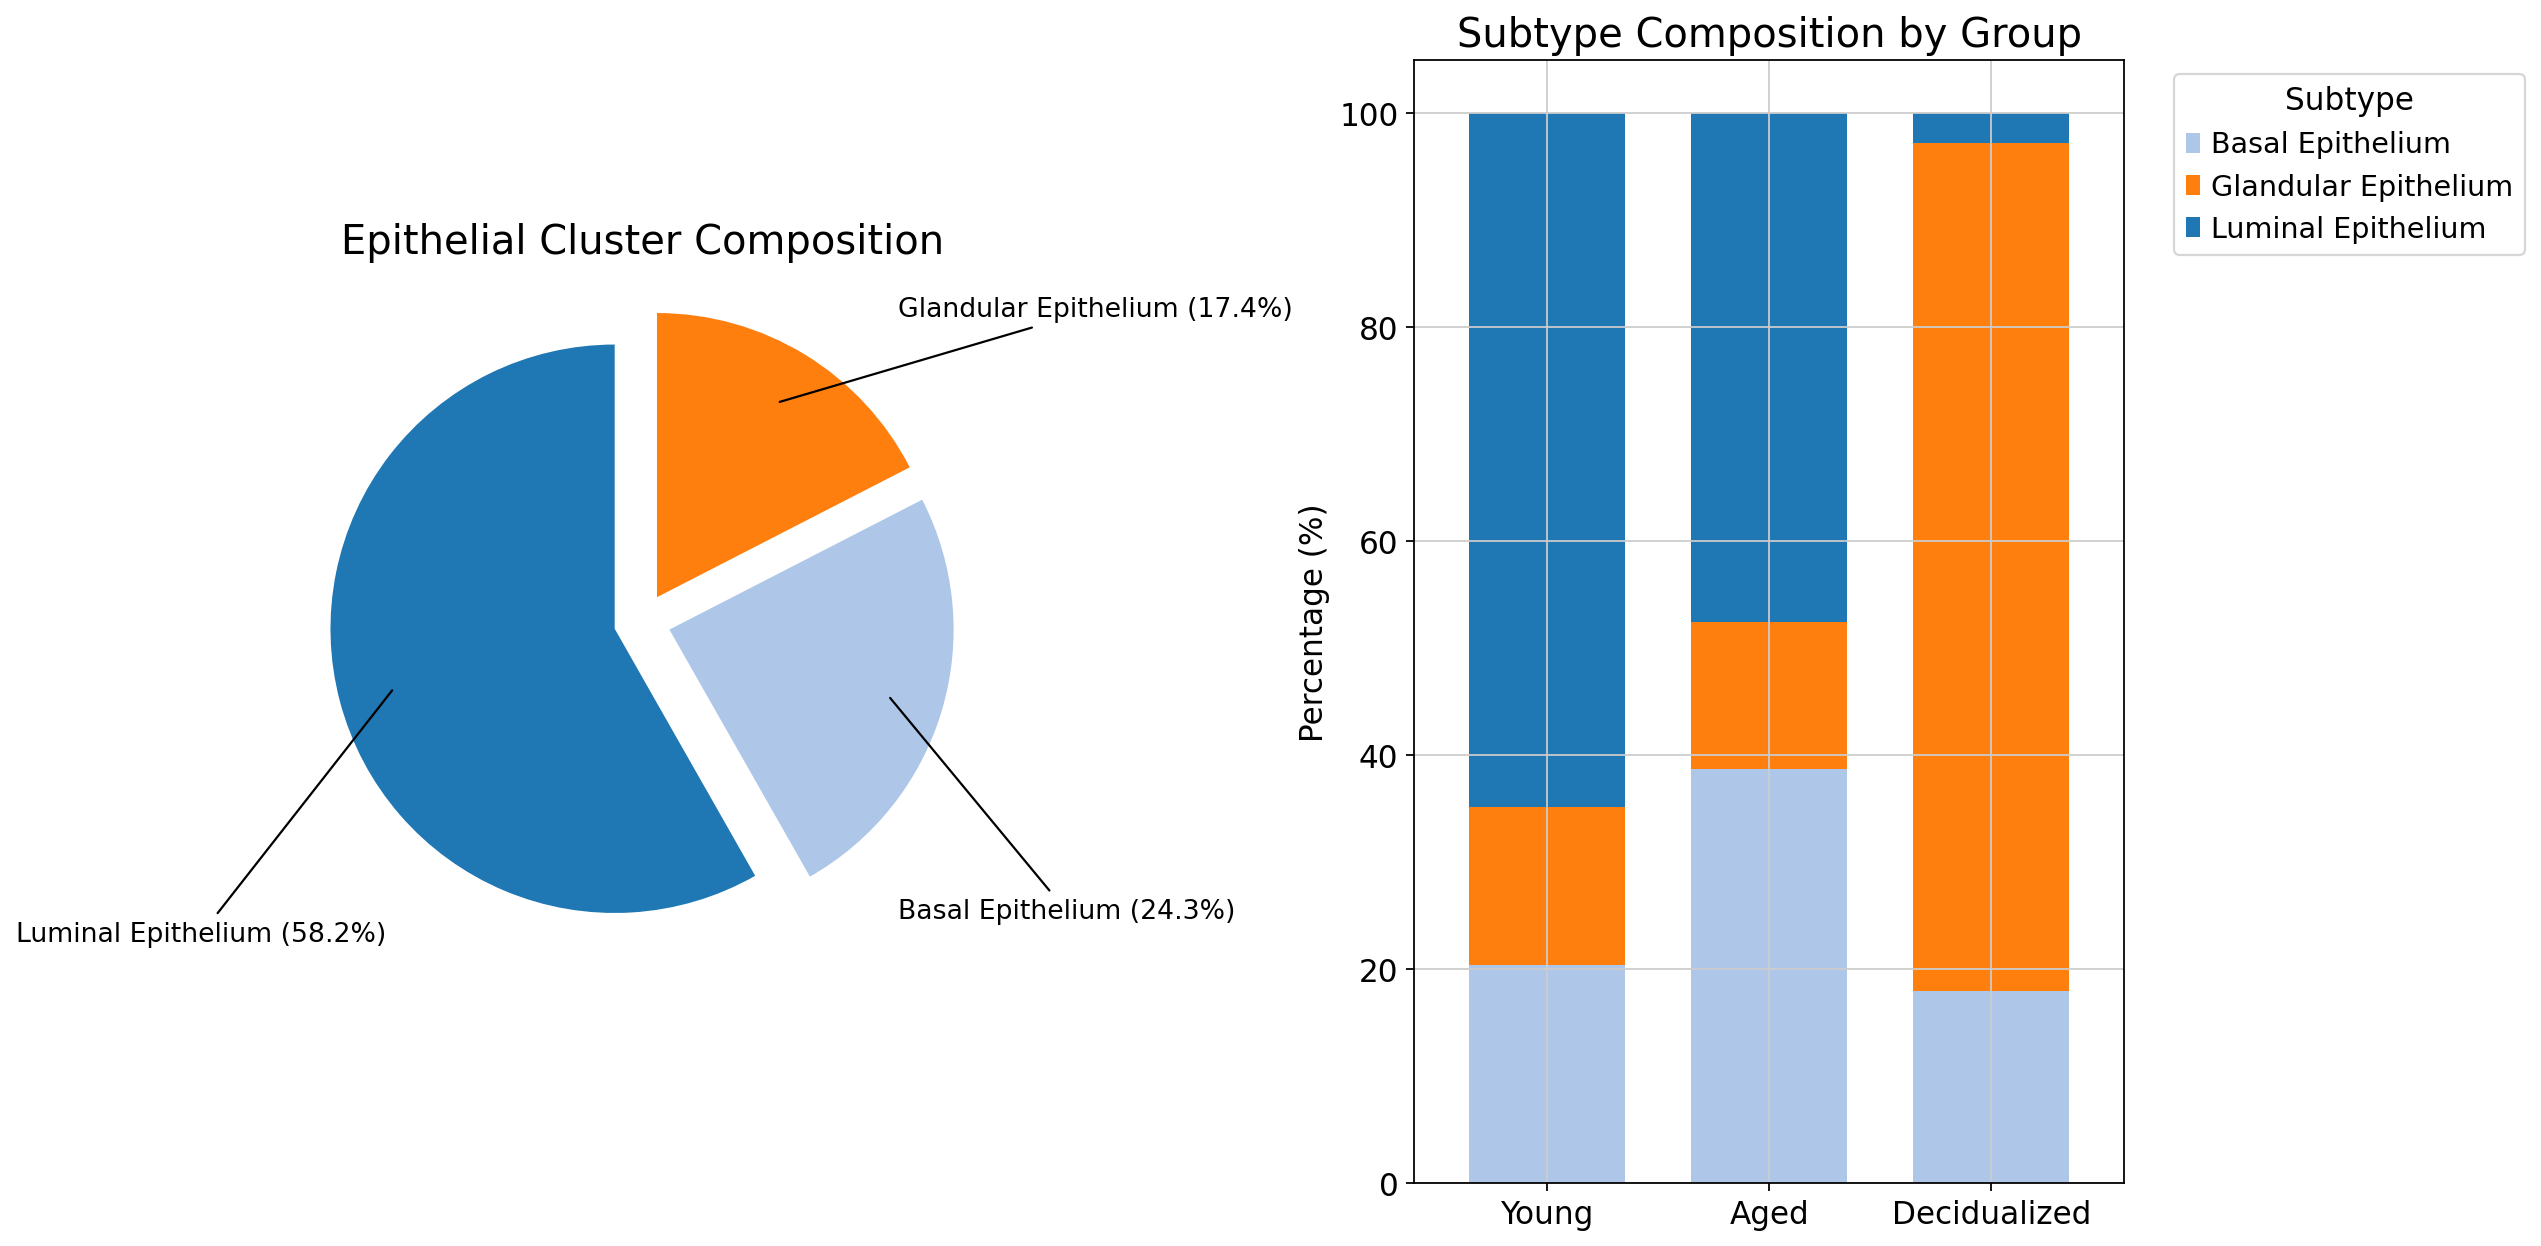

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

cluster_counts = Epithelial.obs['subtype'].value_counts()
labels = cluster_counts.index
sizes = cluster_counts.values
num_clusters = len(labels)
colors = plt.cm.tab20.colors[:num_clusters]
cluster_colors = {label: colors[i] for i, label in enumerate(labels)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

explode = [0.1] * len(sizes)
wedges, _ = ax1.pie(
    sizes,
    colors=[cluster_colors[label] for label in labels],
    startangle=90,
    explode=explode,
    labels=[None]*len(labels)
)

top_y = 1.1
bottom_y = -1.1
for i, w in enumerate(wedges):
    angle = (w.theta2 + w.theta1)/2
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))
    pct = sizes[i] / sizes.sum() * 100
    text_label = f"{labels[i]} ({pct:.1f}%)"
    if y >= 0:
        y_text = top_y
        top_y -= 0.08
    else:
        y_text = bottom_y
        bottom_y += 0.08
    x_text = 0.9 * np.sign(x)
    ax1.annotate(
        text_label,
        xy=(0.9*x, 0.9*y),
        xytext=(x_text, y_text),
        arrowprops=dict(arrowstyle="-", connectionstyle="arc3"),
        ha='left' if x_text > 0 else 'right',
        va='center',
        fontsize=12
    )

ax1.set_title("Epithelial Cluster Composition", fontsize=18)

df = Epithelial.obs[['subtype', 'clinical information', 'age_group']].copy()
df['group'] = df['clinical information'].apply(lambda x: 'Decidualized' if x == 'decidualized_pregnant' else None)
df.loc[df['group'].isna(), 'group'] = df.loc[df['group'].isna(), 'age_group']

group_subtype = df.groupby(['group', 'subtype']).size().unstack(fill_value=0)
group_subtype = group_subtype.div(group_subtype.sum(axis=1), axis=0) * 100
group_subtype = group_subtype.reindex(['Young', 'Aged', 'Decidualized'])

group_subtype.plot(kind='bar', stacked=True, ax=ax2, color=[cluster_colors.get(s, 'gray') for s in group_subtype.columns], width=0.7)
ax2.set_xlabel("")
ax2.set_ylabel("Percentage (%)")
ax2.set_title("Subtype Composition by Group", fontsize=18)
ax2.set_xticklabels(['Young', 'Aged', 'Decidualized'], rotation=0, fontsize=14)
ax2.legend(title="Subtype", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


# scWGCNA gene set profile

/tmp/ipykernel_1128955/3806142155.py:63: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


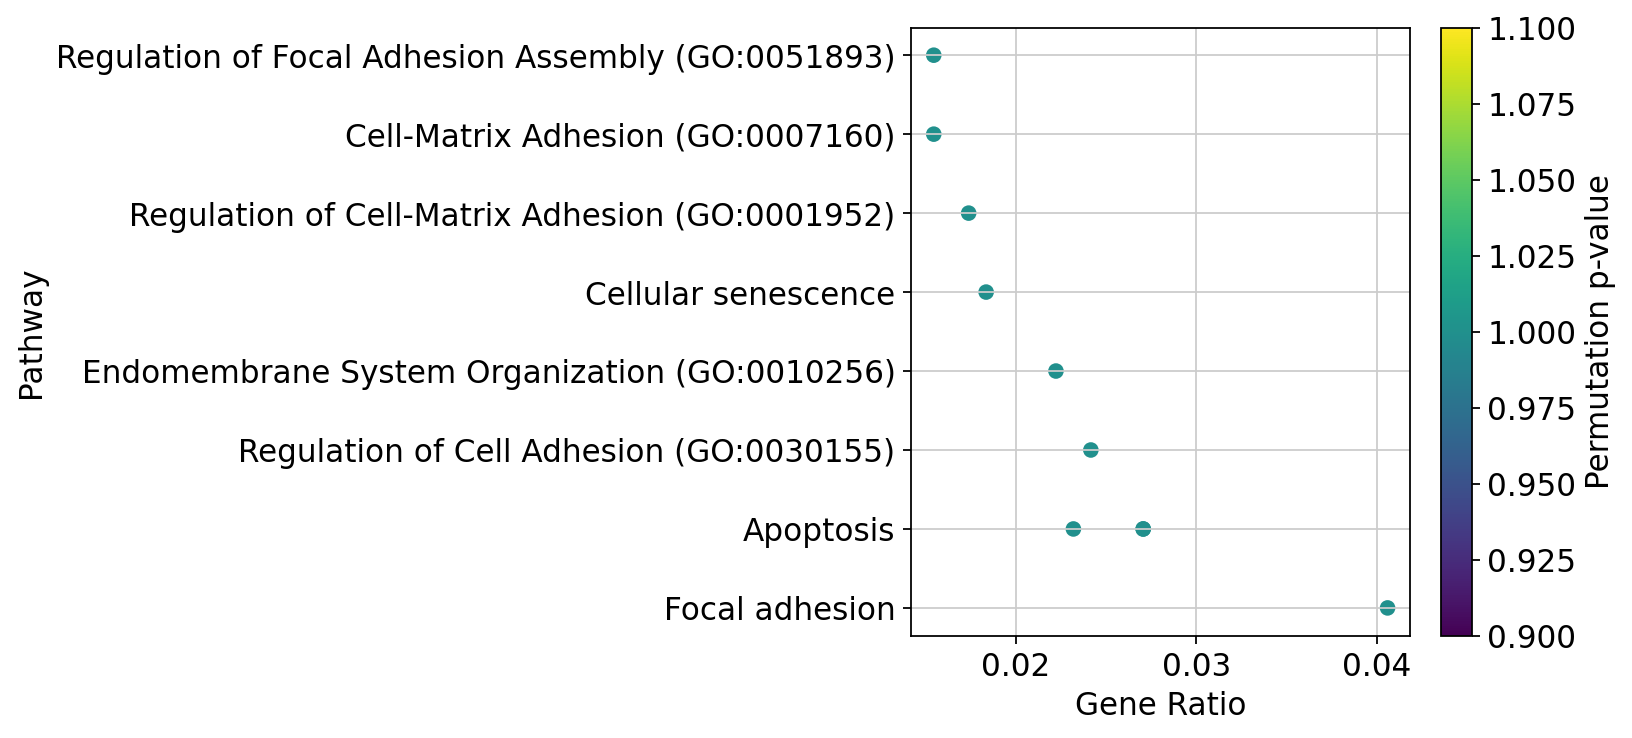

In [416]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import random

pathway_files = [
    "/home/Data_Drive_8TB/kykim/1. Oval/GSEA/pathway_adhesion.csv",
    "/home/Data_Drive_8TB/kykim/1. Oval/GSEA/pathway_apoptosis.csv",
    "/home/Data_Drive_8TB/kykim/1. Oval/GSEA/pathway_endometrial.csv",
    "/home/Data_Drive_8TB/kykim/1. Oval/GSEA/pathway_mucin.csv",
    "/home/Data_Drive_8TB/kykim/1. Oval/GSEA/pathway_senescence.csv"
]

dfs = [pd.read_csv(f) for f in pathway_files]
df = pd.concat(dfs, ignore_index=True)

df = df[["Pathway", "GeneList_mouse"]].copy()
df["GeneList_mouse"] = df["GeneList_mouse"].apply(ast.literal_eval)

module_genes = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module2.txt",
    header=None
)[0].tolist()

module_genes = set(module_genes)

background_genes = set()
for genes in df["GeneList_mouse"]:
    background_genes.update(genes)

background_genes = list(background_genes)

n_perm = 1000

results = []

for _, row in df.iterrows():
    pathway = row["Pathway"]
    pathway_genes = set(row["GeneList_mouse"])
    overlap = module_genes & pathway_genes
    ratio = len(overlap) / len(module_genes) if len(module_genes) > 0 else 0

    perm_ratios = []
    for _ in range(n_perm):
        perm_module = set(random.sample(background_genes, len(module_genes)))
        perm_overlap = perm_module & pathway_genes
        perm_ratio = len(perm_overlap) / len(module_genes)
        perm_ratios.append(perm_ratio)

    p_value = (np.sum(np.array(perm_ratios) >= ratio) + 1) / (n_perm + 1)

    results.append([pathway, ratio, p_value])

res_df = pd.DataFrame(results, columns=["Pathway", "GeneRatio", "Pvalue"])
res_df = res_df.sort_values("GeneRatio", ascending=False).head(10)

plt.figure()
plt.scatter(res_df["GeneRatio"], res_df["Pathway"], c=res_df["Pvalue"])
plt.xlabel("Gene Ratio")
plt.ylabel("Pathway")
plt.colorbar(label="Permutation p-value")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1128955/765892038.py:69: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


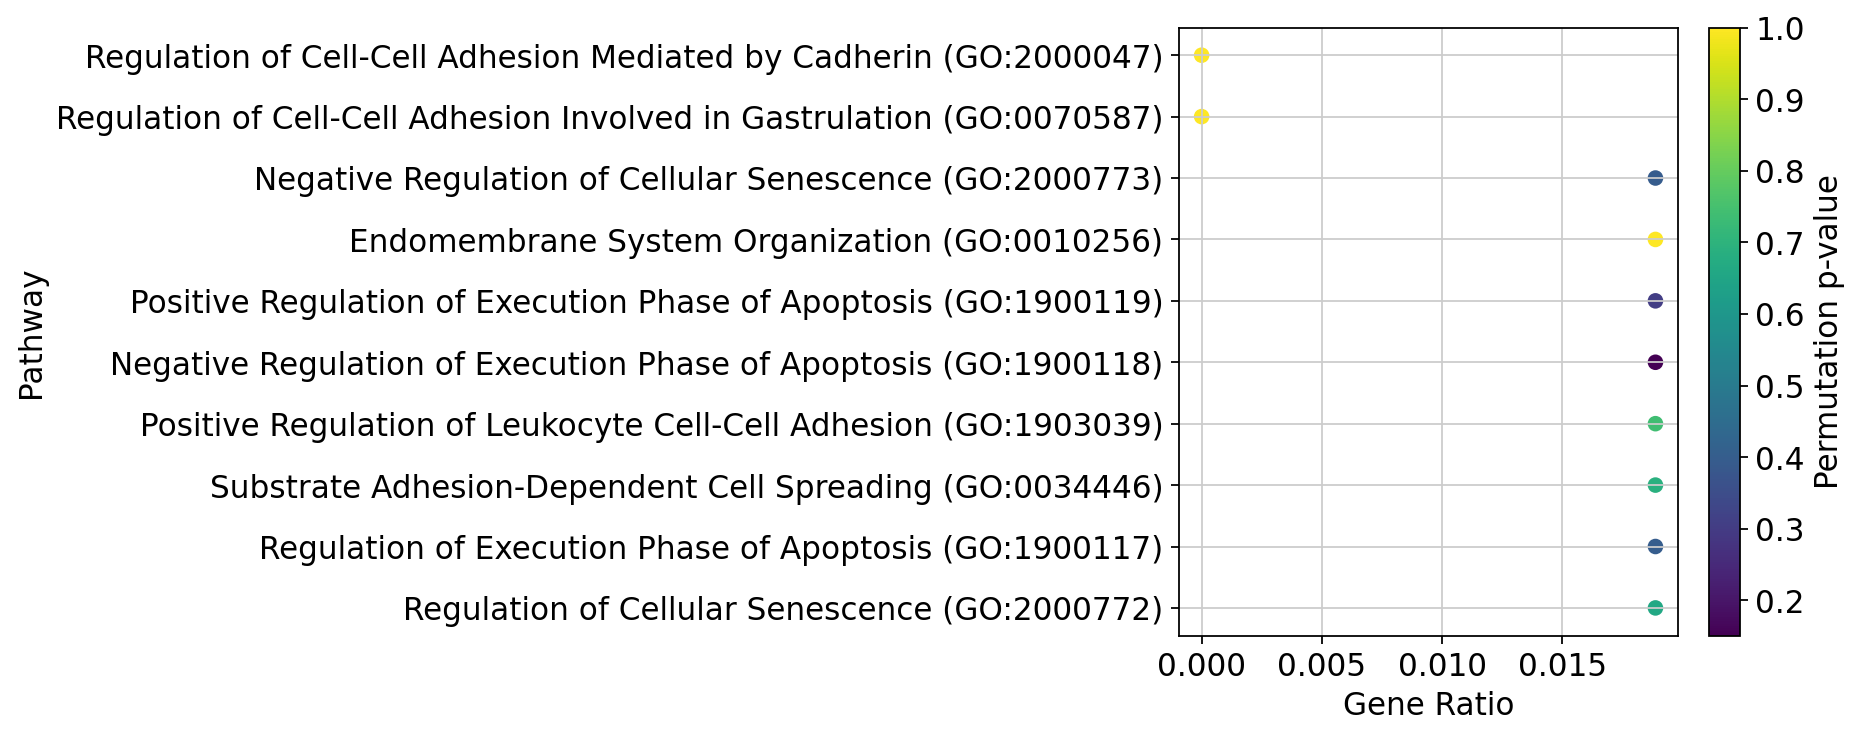

In [420]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import random

pathway_files = [
    "/home/Data_Drive_8TB/kykim/1. Oval/GSEA/pathway_adhesion.csv",
    "/home/Data_Drive_8TB/kykim/1. Oval/GSEA/pathway_apoptosis.csv",
    "/home/Data_Drive_8TB/kykim/1. Oval/GSEA/pathway_endometrial.csv",
    "/home/Data_Drive_8TB/kykim/1. Oval/GSEA/pathway_mucin.csv",
    "/home/Data_Drive_8TB/kykim/1. Oval/GSEA/pathway_senescence.csv"
]

dfs = [pd.read_csv(f) for f in pathway_files]
df = pd.concat(dfs, ignore_index=True)

df = df[["Pathway", "GeneList_mouse"]].copy()
df["GeneList_mouse"] = df["GeneList_mouse"].apply(ast.literal_eval)

module_genes = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module5.txt",
    header=None
)[0].tolist()

module_genes = set(module_genes)

background_genes = set()
for genes in df["GeneList_mouse"]:
    background_genes.update(genes)
background_genes = list(background_genes)

results = []

for _, row in df.iterrows():
    pathway = row["Pathway"]
    pathway_genes = set(row["GeneList_mouse"])
    overlap = module_genes & pathway_genes
    ratio = len(overlap) / len(module_genes) if len(module_genes) > 0 else 0
    results.append([pathway, ratio, pathway_genes])

res_df = pd.DataFrame(results, columns=["Pathway", "GeneRatio", "GeneSet"])
res_df = res_df.sort_values("GeneRatio", ascending=False).head(10)

n_perm = 1000
p_values = []

for _, row in res_df.iterrows():
    pathway_genes = row["GeneSet"]
    observed_ratio = row["GeneRatio"]

    perm_ratios = []
    for _ in range(n_perm):
        perm_module = set(random.sample(background_genes, len(module_genes)))
        perm_overlap = perm_module & pathway_genes
        perm_ratio = len(perm_overlap) / len(module_genes)
        perm_ratios.append(perm_ratio)

    p_value = (np.sum(np.array(perm_ratios) >= observed_ratio) + 1) / (n_perm + 1)
    p_values.append(p_value)

res_df["Pvalue"] = p_values

plt.figure()
plt.scatter(res_df["GeneRatio"], res_df["Pathway"], c=res_df["Pvalue"])
plt.xlabel("Gene Ratio")
plt.ylabel("Pathway")
plt.colorbar(label="Permutation p-value")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1128955/946811066.py:69: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


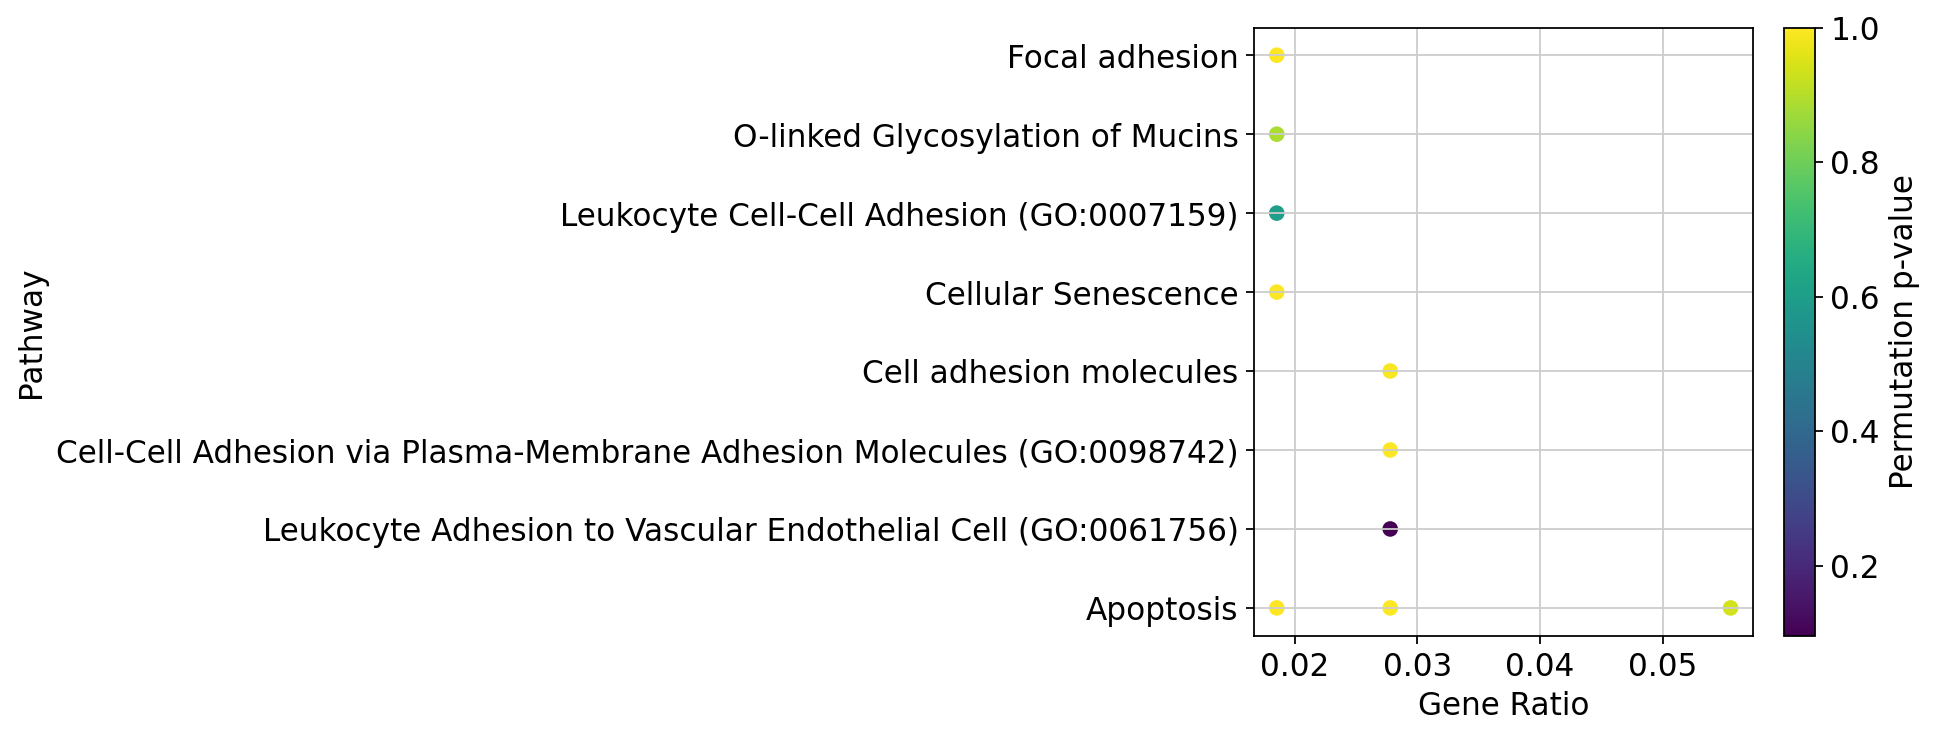

In [418]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import random

pathway_files = [
    "/home/Data_Drive_8TB/kykim/1. Oval/GSEA/pathway_adhesion.csv",
    "/home/Data_Drive_8TB/kykim/1. Oval/GSEA/pathway_apoptosis.csv",
    "/home/Data_Drive_8TB/kykim/1. Oval/GSEA/pathway_endometrial.csv",
    "/home/Data_Drive_8TB/kykim/1. Oval/GSEA/pathway_mucin.csv",
    "/home/Data_Drive_8TB/kykim/1. Oval/GSEA/pathway_senescence.csv"
]

dfs = [pd.read_csv(f) for f in pathway_files]
df = pd.concat(dfs, ignore_index=True)

df = df[["Pathway", "GeneList_mouse"]].copy()
df["GeneList_mouse"] = df["GeneList_mouse"].apply(ast.literal_eval)

module_genes = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module7.txt",
    header=None
)[0].tolist()

module_genes = set(module_genes)

background_genes = set()
for genes in df["GeneList_mouse"]:
    background_genes.update(genes)
background_genes = list(background_genes)

results = []

for _, row in df.iterrows():
    pathway = row["Pathway"]
    pathway_genes = set(row["GeneList_mouse"])
    overlap = module_genes & pathway_genes
    ratio = len(overlap) / len(module_genes) if len(module_genes) > 0 else 0
    results.append([pathway, ratio, pathway_genes])

res_df = pd.DataFrame(results, columns=["Pathway", "GeneRatio", "GeneSet"])
res_df = res_df.sort_values("GeneRatio", ascending=False).head(10)

n_perm = 1000
p_values = []

for _, row in res_df.iterrows():
    pathway_genes = row["GeneSet"]
    observed_ratio = row["GeneRatio"]

    perm_ratios = []
    for _ in range(n_perm):
        perm_module = set(random.sample(background_genes, len(module_genes)))
        perm_overlap = perm_module & pathway_genes
        perm_ratio = len(perm_overlap) / len(module_genes)
        perm_ratios.append(perm_ratio)

    p_value = (np.sum(np.array(perm_ratios) >= observed_ratio) + 1) / (n_perm + 1)
    p_values.append(p_value)

res_df["Pvalue"] = p_values

plt.figure()
plt.scatter(res_df["GeneRatio"], res_df["Pathway"], c=res_df["Pvalue"])
plt.xlabel("Gene Ratio")
plt.ylabel("Pathway")
plt.colorbar(label="Permutation p-value")
plt.tight_layout()
plt.show()

In [419]:
res_df

,Pathway,GeneRatio,GeneSet,Pvalue
79,Apoptosis,0.055556,"{Bmp2, Casp2, Slc20a1, Bcl2l2, Lmna, Brca1, If...",0.937063
22,Leukocyte Adhesion to Vascular Endothelial Cel...,0.027778,"{Vcam1, Gcnt1, Tnf, Itgb7, Itga4, Sele, Sell, ...",0.095904
14,Cell-Cell Adhesion via Plasma-Membrane Adhesio...,0.027778,"{Cldn20, Pcdhgc3, Emb, Pcdhb12, Nectin3, Cldn1...",0.997003
70,Apoptosis,0.027778,"{Dffb, Pik3r2, Casp2, Ctso, Hrk, Lmna, Chuk, C...",0.993007
0,Cell adhesion molecules,0.027778,"{Cldn20, Pdcd1, Nectin3, Cldn19, Itga6, Sdc4, ...",0.990010
88,Cellular Senescence,0.018519,"{Anapc11, H2bc9, Map2k3, Cdc23, Ezh2, Mov10, I...",1.000000
23,Leukocyte Cell-Cell Adhesion (GO:0007159),0.018519,"{Vcam1, Ezr, Tnip1, Calca, Icam1, Itga4, F11r,...",0.598402
86,O-linked Glycosylation of Mucins,0.018519,"{Galnt18, Galnt10, St3gal3, St3gal1, Galnt11, ...",0.884116
71,Apoptosis,0.018519,"{Dffb, Mapt, Sfn, Dbnl, Maged1, Dynll1, Trp63,...",0.999001
1,Focal adhesion,0.018519,"{Itga3, Pik3r2, Flnc, Chad, Pak4, Itga6, Vegfd...",1.000000


# Luminal Epithelium expression pseudobulk

In [32]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

file_path = '/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Before_HVG_raw_clustering(large).h5ad'
adata = sc.read_h5ad(file_path)
Epithelial = adata[adata.obs['celltype_grouped'] == 'Epithelial cells'].copy()
Epithelial.layers["counts"] = Epithelial.X.copy()
sc.pp.normalize_total(Epithelial)
sc.pp.log1p(Epithelial)
sc.pp.highly_variable_genes(Epithelial, n_top_genes=2000, batch_key="Each mouse")
Epithelial = Epithelial[:, Epithelial.var['highly_variable']].copy()

sc.tl.pca(Epithelial)
explained_variance_ratio = Epithelial.uns["pca"]["variance_ratio"]
sc.tl.pca(Epithelial, n_comps=11)
sc.pp.neighbors(Epithelial)
sc.tl.umap(Epithelial)

import anndata as ad
import scanpy as sc

file_path = '/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Before_HVG_raw_clustering(large).h5ad'
adata_raw = sc.read_h5ad(file_path)
Epithelial_raw = adata_raw[adata_raw.obs['celltype_grouped'] == 'Epithelial cells'].copy()

genes_to_add = ['Muc1', 'Muc3', 'Muc3a', 'Muc6', 'Muc2', 'Muc5ac', 'Muc5b', 'Muc16', 'Mucl1', 'Mucl2', 'Muc4', 'Muc20', 'Muc13', 'Lif','Hbegf','Atf3','Sox9','Foxa2', 
                'Cxcl15','Fosb', 'Egr4', 'Junb', 'Nrip1', 'Fos', 'Atf3', 'Ahr', 'Bcor', 'Rfx5', 'Klf6', 'Nfkb1', 'Rorb', 'Klf4', 'Nr4a1', 'Hdac4', 'Meis1', 'Rela', 'Egr1', 'Fosl1', 'Tcf4']

current_genes = Epithelial.var_names.tolist()
genes_to_add_filtered = [g for g in genes_to_add if g in Epithelial_raw.var_names and g not in current_genes]

if len(genes_to_add_filtered) > 0:
    genes_to_add_data = Epithelial_raw[:, genes_to_add_filtered].copy()
    genes_to_add_data.layers["counts"] = genes_to_add_data.X.copy()
    sc.pp.normalize_total(genes_to_add_data)
    sc.pp.log1p(genes_to_add_data)
    
    Epithelial_temp = Epithelial.copy()
    if 'varm' in dir(Epithelial_temp) and len(Epithelial_temp.varm.keys()) > 0:
        del Epithelial_temp.varm
    if 'varp' in dir(genes_to_add_data) and len(genes_to_add_data.varp.keys()) > 0:
        del genes_to_add_data.varp
    
    Epithelial_new = ad.concat(
        [Epithelial_temp, genes_to_add_data],
        axis=1,
        join='outer',
        merge='first'
    )
Epithelial_new = Epithelial_new[~Epithelial_new.obs['Each mouse'].isna(), :]
tmp = Epithelial_new.obs["age"].str.extract(r"(\d+)")
tmp = tmp[0].dropna().astype(int)
Epithelial_new.obs["age_num"] = tmp
Epithelial_new.obs['age_group'] = np.where(Epithelial_new.obs['age_num'] > 70, 'Aged', 'Young')
sc.external.pp.bbknn(Epithelial_new, batch_key="sample_id")
sc.tl.umap(Epithelial_new)
for res in [0.05, 0.10,0.25,0.5,0.75,1.00]:
    sc.tl.leiden(
        Epithelial_new, key_added=f"leiden_res_{res:4.2f}", resolution=res, 
        flavor="igraph"
    )
ge_clusters = ['6', '7', '2']

Epithelial_new.obs['subtype'] = np.where(
    Epithelial_new.obs['leiden_res_0.75'].isin(ge_clusters),
    'Glandular Epithelium',
    'Luminal Epithelium'
)



sc.tl.rank_genes_groups(Epithelial_new, groupby='subtype', method='wilcoxon')
top_genes = {}
groups = Epithelial_new.uns['rank_genes_groups']['names'].dtype.names  # 클러스터 이름들
for group in groups:
    genes = Epithelial_new.uns['rank_genes_groups']['names'][group][:20]
    top_genes[group] = genes.tolist()
epithelial_subtype_markers = {
    "Glandular Epithelium": ['Agr2', 'Spink1', 'Fabp5','Foxa2','Sox9','Cxcl15'],
    "Luminal Epithelium": ['Hbegf','Lif','Ltf','Muc4','Muc1']               
   }                          
existing_subtype_markers = {
    subtype: [gene for gene in genes if gene in Epithelial_new.var_names]
    for subtype, genes in epithelial_subtype_markers.items()
}

/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/tmp/ipykernel_1714495/2725212472.py:54: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  Epithelial_new.obs["age_num"] = tmp


/tmp/ipykernel_1714495/3945755618.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_1714495/3945755618.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


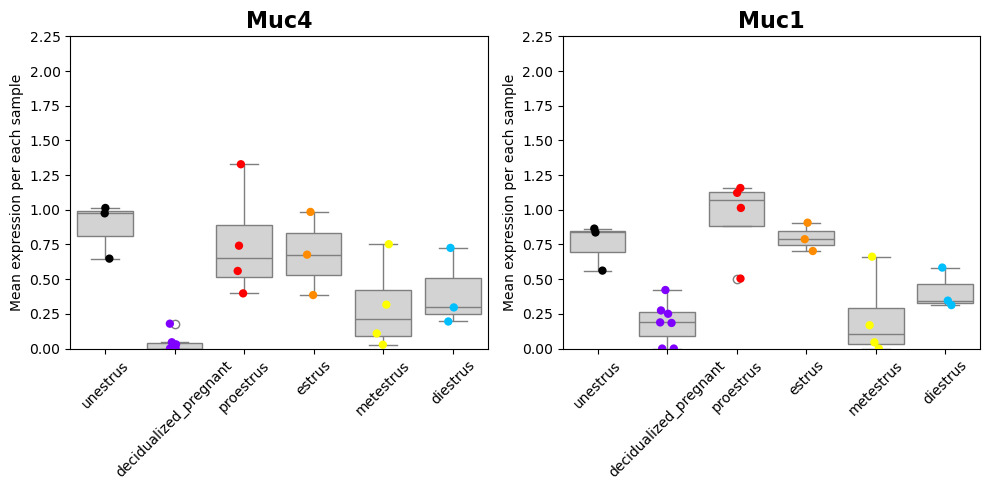

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

genes = ["Muc4", "Muc1"]

clin_palette = {
    'decidualized_pregnant': '#8000ff',
    'diestrus': '#00bfff',
    'estrus': '#ff8c00',
    'metestrus': '#ffff00',
    'proestrus': '#ff0000',
    'unestrus': '#000000'
}

plot_list = []

le_cells = Epithelial_new.obs["subtype"] == "Luminal Epithelium"

expr_df = Epithelial_new.to_df()
obs_df = Epithelial_new.obs

for gene in genes:
    df_gene = expr_df.loc[le_cells, gene]
    sample_ids = obs_df.loc[le_cells, "sample_id"].unique()
    for sample_id in sample_ids:
        idx = obs_df.index[(obs_df["sample_id"] == sample_id) & le_cells]
        if len(idx) == 0:
            continue
        exp = df_gene.loc[idx].mean()
        ci = obs_df.loc[idx, "clinical information"].iloc[0]
        plot_list.append({
            "Gene": gene,
            "sample_id": sample_id,
            "clinical_info": ci,
            "MeanExpression": exp
        })

plot_df = pd.DataFrame(plot_list)

cycle_order = ["unestrus", "decidualized_pregnant", "proestrus", "estrus", "metestrus", "diestrus"]

fig, axes = plt.subplots(1, len(genes), figsize=(5 * len(genes), 5))

if len(genes) == 1:
    axes = [axes]

for i, gene in enumerate(genes):
    ax = axes[i]
    sub_df = plot_df[plot_df["Gene"] == gene]

    sns.boxplot(
        data=sub_df,
        x="clinical_info",
        y="MeanExpression",
        color="lightgray",
        order=cycle_order,
        ax=ax
    )

    sns.stripplot(
        data=sub_df,
        x="clinical_info",
        y="MeanExpression",
        hue="clinical_info",
        palette=clin_palette,
        order=cycle_order,
        size=6,
        dodge=False,
        ax=ax
    )

    ax.set_title(gene, fontsize=16, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Mean expression per each sample")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.set_ylim(0, 2.25)

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

plt.tight_layout()
plt.show()

In [34]:
from scipy.stats import ranksums

for gene in genes:
    sub_df = plot_df[plot_df["Gene"] == gene]

    estrus_vals = sub_df.loc[
        sub_df["clinical_info"] == "estrus",
        "MeanExpression"
    ]

    diestrus_vals = sub_df.loc[
        sub_df["clinical_info"] == "diestrus",
        "MeanExpression"
    ]

    stat, pval = ranksums(estrus_vals, diestrus_vals)

    print(f"{gene} Wilcoxon p-value: {pval:.3e}")

Muc4 Wilcoxon p-value: 2.752e-01
Muc1 Wilcoxon p-value: 4.953e-02


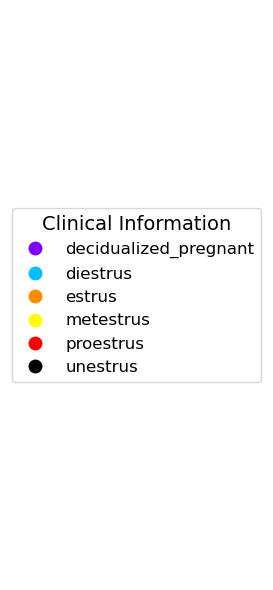

In [42]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

clin_palette = {
    'decidualized_pregnant': '#8000ff',
    'diestrus': '#00bfff',
    'estrus': '#ff8c00',
    'metestrus': '#ffff00',
    'proestrus': '#ff0000',
    'unestrus': '#000000'
}

fig, ax = plt.subplots(figsize=(3, 6))
ax.axis('off')

handles = []
labels = []
for clin_info, color in clin_palette.items():
    handles.append(mlines.Line2D([0], [0], marker='o', color='w', 
                                  markerfacecolor=color, markersize=10, 
                                  markeredgewidth=0))
    labels.append(clin_info)

legend = ax.legend(handles, labels, loc='center', 
                   frameon=True, fontsize=12, 
                   title='Clinical Information', title_fontsize=14,
                   ncol=1)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1714495/2490813286.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.9,1])


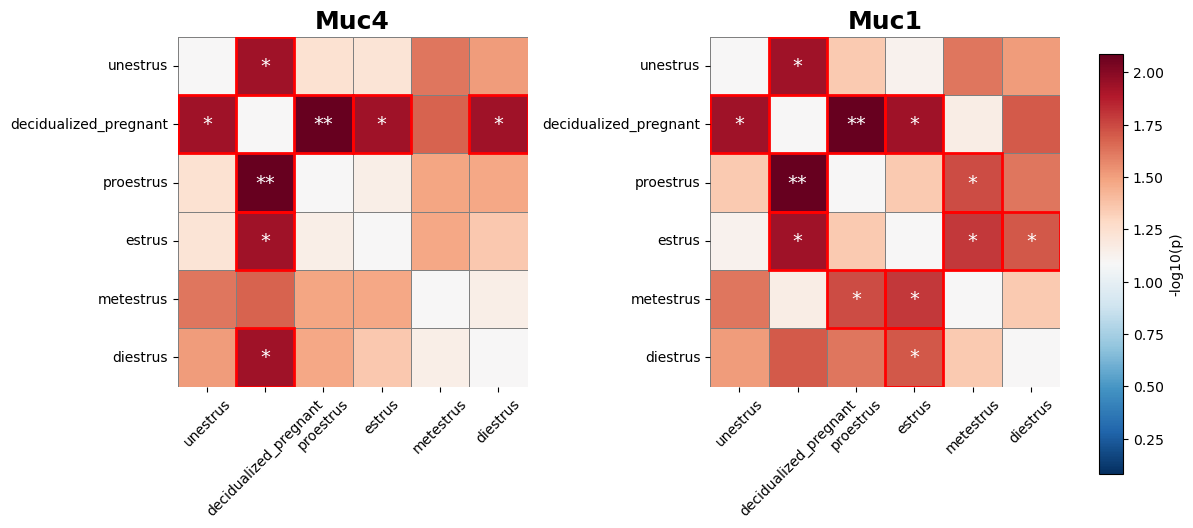

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ranksums
import numpy as np

genes = ["Muc4", "Muc1"]
cycle_order = ["unestrus", "decidualized_pregnant", "proestrus", "estrus", "metestrus", "diestrus"]
ci_unique = Epithelial_new.obs["clinical information"].unique()
ci_map = dict(zip(ci_unique, sns.color_palette("Set2", len(ci_unique))))

plot_list = []

le_cells = Epithelial_new.obs["subtype"] == "Luminal Epithelium"

for gene in genes:
    df_gene = Epithelial_new.to_df()[gene][le_cells]
    for sample_id in Epithelial_new.obs.loc[le_cells, "sample_id"].unique():
        idx = Epithelial_new.obs.index[(Epithelial_new.obs["sample_id"] == sample_id) & le_cells]
        if len(idx) == 0:
            continue
        exp = df_gene.loc[idx].mean()
        ci = Epithelial_new.obs.loc[idx, "clinical information"].iloc[0]
        plot_list.append({
            "Gene": gene,
            "sample_id": sample_id,
            "clinical_info": ci,
            "MeanExpression": exp
        })

plot_df = pd.DataFrame(plot_list)

wilcoxon_list = []

for gene in genes:
    for i in range(len(cycle_order)):
        for j in range(i+1, len(cycle_order)):
            g1 = cycle_order[i]
            g2 = cycle_order[j]
            vals1 = plot_df[(plot_df["Gene"]==gene) & (plot_df["clinical_info"]==g1)]["MeanExpression"]
            vals2 = plot_df[(plot_df["Gene"]==gene) & (plot_df["clinical_info"]==g2)]["MeanExpression"]
            p = ranksums(vals1, vals2).pvalue
            wilcoxon_list.append({
                "Gene": gene,
                "group_1": g1,
                "group_2": g2,
                "p_value": p,
                "-log10_p": -np.log10(p) if p>0 else 300
            })

wilcoxon_df = pd.DataFrame(wilcoxon_list)

fig, axes = plt.subplots(1, len(genes), figsize=(12,6))

for i, gene in enumerate(genes):
    ax = axes[i]
    sub = wilcoxon_df[wilcoxon_df["Gene"]==gene]
    groups = cycle_order
    heatmap_data = pd.DataFrame(np.nan, index=groups, columns=groups)
    
    for _, row in sub.iterrows():
        g1 = row["group_1"]
        g2 = row["group_2"]
        heatmap_data.loc[g1, g2] = row["-log10_p"]
        heatmap_data.loc[g2, g1] = row["-log10_p"]
        
    for g in groups:
        heatmap_data.loc[g,g] = 0

    sns.heatmap(heatmap_data, ax=ax, cmap="RdBu_r", center=0, annot=False,
                linewidths=0.5, linecolor="gray", cbar=False, square=True)
    
    for _, row in sub.iterrows():
        g1 = row["group_1"]
        g2 = row["group_2"]
        if row["p_value"] < 0.05:
            x = groups.index(g2)
            y = groups.index(g1)
            rect = plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='red', lw=2)
            ax.add_patch(rect)
            rect2 = plt.Rectangle((y, x), 1, 1, fill=False, edgecolor='red', lw=2)
            ax.add_patch(rect2)
            
            if row["p_value"] < 0.001:
                stars = '***'
            elif row["p_value"] < 0.01:
                stars = '**'
            else:
                stars = '*'
            ax.text(x+0.5, y+0.5, stars, color='white', ha='center', va='center', fontsize=14)
            ax.text(y+0.5, x+0.5, stars, color='white', ha='center', va='center', fontsize=14)

    ax.set_title(gene, fontsize=18, fontweight='bold')
    ax.set_xticklabels(groups, rotation=45)
    ax.set_yticklabels(groups, rotation=0)

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
norm = plt.Normalize(np.nanmin(wilcoxon_df["-log10_p"]), np.nanmax(wilcoxon_df["-log10_p"]))
sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label='-log10(p)')
plt.tight_layout(rect=[0,0,0.9,1])
plt.show()

/tmp/ipykernel_1714495/820952013.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged
/tmp/ipykernel_1714495/820952013.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged
/tmp/ipykernel_1714495/820952013.py:198: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_1714495/820952013.py:198: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


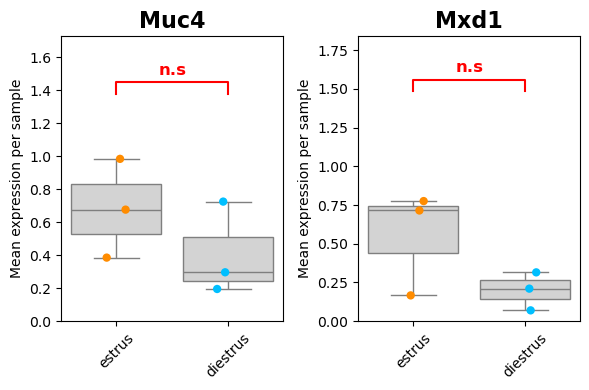

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ranksums

genes = ["Muc4", "Mxd1"]

clin_palette = {
    'decidualized_pregnant': '#8000ff',
    'diestrus': '#00bfff',
    'estrus': '#ff8c00',
    'metestrus': '#ffff00',
    'proestrus': '#ff0000',
    'unestrus': '#000000'
}

plot_list = []

le_mask = (
    Epithelial_new.obs["subtype"]
    == "Luminal Epithelium"
)

obs_sub = Epithelial_new.obs.loc[le_mask].copy()

obs_sub["clinical information"] = (
    obs_sub["clinical information"]
    .astype(str)
    .str.strip()
    .str.lower()
)

expr_sub = (
    Epithelial_new.to_df()
    .loc[le_mask, genes]
    .copy()
)

merged = pd.concat(
    [obs_sub, expr_sub],
    axis=1
)

for gene in genes:

    grouped = (
        merged
        .groupby(
            ["sample_id", "clinical information"]
        )[gene]
        .mean()
        .reset_index()
    )

    grouped["Gene"] = gene

    grouped = grouped.rename(
        columns={
            "clinical information": "clinical_info"
        }
    )

    plot_list.append(grouped)

plot_df = pd.concat(
    plot_list,
    axis=0
)

cycle_order = [
    "estrus",
    "diestrus"
]

fig, axes = plt.subplots(
    1,
    len(genes),
    figsize=(3 * len(genes), 4)
)

if len(genes) == 1:
    axes = [axes]

for i, gene in enumerate(genes):

    ax = axes[i]

    sub_df = (
        plot_df[
            plot_df["Gene"] == gene
        ]
        .copy()
    )

    sub_df = sub_df.dropna(
        subset=[gene]
    )

    estrus_vals = (
        sub_df[
            sub_df["clinical_info"] == "estrus"
        ][gene]
        .dropna()
    )

    diestrus_vals = (
        sub_df[
            sub_df["clinical_info"] == "diestrus"
        ][gene]
        .dropna()
    )

    sns.boxplot(
        data=sub_df,
        x="clinical_info",
        y=gene,
        color="lightgray",
        order=cycle_order,
        showfliers=False,
        ax=ax
    )

    sns.stripplot(
        data=sub_df,
        x="clinical_info",
        y=gene,
        hue="clinical_info",
        palette=clin_palette,
        order=cycle_order,
        size=6,
        dodge=False,
        ax=ax
    )

    if (
        len(estrus_vals) > 0
        and len(diestrus_vals) > 0
    ):

        stat, pval = ranksums(
            estrus_vals,
            diestrus_vals
        )

    else:

        pval = float("nan")

    if pval < 0.001:
        p_text = "***"

    elif pval < 0.01:
        p_text = "**"

    elif pval < 0.05:
        p_text = "*"

    else:
        p_text = "n.s"

    y_max = sub_df[gene].max()

    ax.plot(
        [0, 0, 1, 1],
        [
            y_max + 0.05,
            y_max + 0.12,
            y_max + 0.12,
            y_max + 0.05
        ],
        lw=1.5,
        c="red"
    )

    ax.text(
        0.5,
        y_max + 0.15,
        p_text,
        ha="center",
        va="bottom",
        color="red",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_title(
        gene,
        fontsize=16,
        fontweight="bold"
    )

    ax.set_xlabel("")

    ax.set_ylabel(
        "Mean expression per sample"
    )

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45
    )

    ax.set_ylim(
        0,
        y_max + 0.4
    )

    leg = ax.get_legend()

    if leg is not None:
        leg.remove()

plt.tight_layout()
plt.show()

# Epithelial Pyscenic

In [1]:
import scanpy as sc
file_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Epithelial_subtype_raw.h5ad"
adata = sc.read_h5ad(file_path)

In [2]:
Raw_adata = adata[adata.obs['subtype'] == 'Luminal Epithelium'].copy()
Raw_adata

AnnData object with n_obs × n_vars = 4613 × 23777
    obs: 'sample_id', 'Each mouse', 'organism', 'age', 'developmental stage', 'sex', 'disease', 'organism part', 'clinical information', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'celltype_grouped', 'subtype'
    var: 'gene_id', 'feature_type', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet'

In [3]:
import pandas as pd
import scipy.sparse
expr_matrix = Raw_adata.X
if scipy.sparse.issparse(expr_matrix):
    expr_matrix = expr_matrix.toarray()

expr_df = pd.DataFrame(expr_matrix, index=Raw_adata.obs_names, columns=Raw_adata.var_names)
expr_df.to_csv("/home/Data_Drive_8TB/kykim/1. Oval/pySCENIC/uterus_epithelial_matrix.tsv", sep="\t")

In [158]:
######################################
###########After pySCENIC ############
######################################

In [226]:
import pandas as pd

regulons = pd.read_csv("/home/Data_Drive_8TB/kykim/1. Oval/pySCENIC/output/regulons.csv")
regulons.columns

Index(['TF', 'MotifID', 'AUC', 'NES', 'MotifSimilarityQvalue',
       'OrthologousIdentity', 'Annotation', 'Context', 'TargetGenes',
       'RankAtMax'],
      dtype='object')

In [229]:
import pandas as pd
import ast

def safe_literal_eval(s):
    try:
        return ast.literal_eval(s)
    except (ValueError, SyntaxError):
        return None

regulons['TargetGenes_list'] = regulons['TargetGenes'].apply(
    lambda x: safe_literal_eval(x) if isinstance(x, str) else x
)
regulons = regulons[regulons['TargetGenes_list'].notnull()]
regulons['TargetGeneNames'] = regulons['TargetGenes_list'].apply(
    lambda x: [g[0] for g in x if isinstance(g, tuple)]
)

df_result = regulons[['TF', 'TargetGeneNames']]
results = []

for idx, row in df_result.iterrows():
    tf_name = row['TF']
    targets = row['TargetGeneNames']
    junb_hits = [g for g in targets if g == 'Muc4']
    if junb_hits:
        results.append({'TF': tf_name, 'Gene': ', '.join(junb_hits)})

df_hits = pd.DataFrame(results)
df_grouped_unique = (
    df_hits
    .groupby('TF')['Gene']
    .apply(lambda x: ', '.join(sorted(set(', '.join(x).split(', ')))))
    .reset_index()
)
df_grouped_unique.rename(columns={'Gene': 'TargetGenes'}, inplace=True)

df_grouped_unique

,TF,TargetGenes
0,Atf4,Muc4
1,Bach1,Muc4
2,Gata3,Muc4
3,Ltf,Muc4


In [236]:
regulons

,TF,MotifID,AUC,NES,MotifSimilarityQvalue,OrthologousIdentity,Annotation,Context,TargetGenes,RankAtMax,TargetGenes_list,TargetGeneNames
0,Atf3,transfac_pro__M01861,0.044289402,3.8463075044241064,4.68974e-06,1,gene is annotated for similar motif transfac_p...,"frozenset({'weight>75.0%', 'mm10__refseq-r80__...","[('Rnf167', 0.5461860513691245), ('Hmg20a', 0....",2461,"[(Rnf167, 0.5461860513691245), (Hmg20a, 0.6895...","[Rnf167, Hmg20a, Ublcp1, Gm15417, Thoc5, Eif3i..."
1,Bach1,elemento__TGACTCA,0.056985878,4.217949228623465,3.43977e-07,1,gene is annotated for similar motif transfac_p...,"frozenset({'weight>75.0%', 'mm10__refseq-r80__...","[('Nfkb2', 10.391453523988623), ('Nfkbia', 0.6...",2624,"[(Nfkb2, 10.391453523988623), (Nfkbia, 0.62508...","[Nfkb2, Nfkbia, Nfkbie, Ikbke, Nfkbiz, Smurf1,..."
2,Bach1,taipale_tf_pairs__BACH1_ATGACTCAT_HT,0.054563913026544245,3.7679215765375824,0,0.805707,motif is annotated for orthologous gene ENSG00...,"frozenset({'weight>75.0%', 'mm10__refseq-r80__...","[('1110002J07Rik', 0.4598216056758837), ('Slc3...",578,"[(1110002J07Rik, 0.4598216056758837), (Slc38a2...","[1110002J07Rik, Slc38a2, Prrg4, Hook2, Ubash3b..."
3,Creb3l1,transfac_pro__M07679,0.051211335,3.3919614626333745,0,0.275194,motif is annotated for orthologous gene FBgn00...,"frozenset({'weight>75.0%', 'mm10__refseq-r80__...","[('Zbtb7a', 0.6138273438501551), ('Pcgf2', 0.4...",1028,"[(Zbtb7a, 0.6138273438501551), (Pcgf2, 0.44551...","[Zbtb7a, Pcgf2, Irs1, Hotairm1, Gabbr1, Maf, C..."
4,Creb3l1,taipale__CREB3L1_DBD_NTGCCACGTCANCA,0.053575489,3.8091501636250076,0,0.922929,motif is annotated for orthologous gene ENSG00...,"frozenset({'weight>75.0%', 'mm10__refseq-r80__...","[('Gngt2', 3.72033998564714), ('Dlgap1', 0.474...",754,"[(Gngt2, 3.72033998564714), (Dlgap1, 0.4744581...","[Gngt2, Dlgap1, Dock1, Fbxw4, Elavl3, Cenpo, 9..."
...,...,...,...,...,...,...,...,...,...,...,...,...
2399,Yy1,taipale__YY2_DBD_NNCCGCCATNW_repr,0.058719257,3.4030345611434734,1.1826e-06,0.398551,gene is orthologous to FBgn0002521 in D. melan...,frozenset({'mm10__refseq-r80__500bp_up_and_100...,"[('Nr1h2', 3.930291820769458), ('Atp13a1', 1.6...",3190,"[(Nr1h2, 3.930291820769458), (Atp13a1, 1.62875...","[Nr1h2, Atp13a1, Ebna1bp2, Urm1, Ccnt1, Rpf1, ..."
2400,Yy1,transfac_pro__M04696,0.056041726,3.089854605834004,0,0.987923,gene is orthologous to ENSG00000100811 in H. s...,frozenset({'mm10__refseq-r80__500bp_up_and_100...,"[('Nr1h2', 3.930291820769458), ('Atp13a1', 1.6...",4558,"[(Nr1h2, 3.930291820769458), (Atp13a1, 1.62875...","[Nr1h2, Atp13a1, Tnpo3, Ebna1bp2, Urm1, Rpf1, ..."
2401,Yy1,transfac_pro__M08982,0.056256008,3.1149183138530723,0,0.987923,gene is orthologous to ENSG00000100811 in H. s...,frozenset({'mm10__refseq-r80__500bp_up_and_100...,"[('Tnpo3', 2.3804535907726625), ('Ppp4c', 1.90...",3393,"[(Tnpo3, 2.3804535907726625), (Ppp4c, 1.902907...","[Tnpo3, Ppp4c, Ywhab, Nr1h2, Tssc4, Atp13a1, C..."
2402,Zeb1,tfdimers__MD00221,0.061354465,3.1299195122684424,1.27413e-07,0.869293,gene is orthologous to ENSG00000148516 in H. s...,frozenset({'mm10__refseq-r80__500bp_up_and_100...,"[('Grap2', 3.2728720993785534), ('Runx3', 0.75...",2283,"[(Grap2, 3.2728720993785534), (Runx3, 0.755416...","[Grap2, Runx3, P2ry10, Cytip, Gfi1, Themis, Rg..."


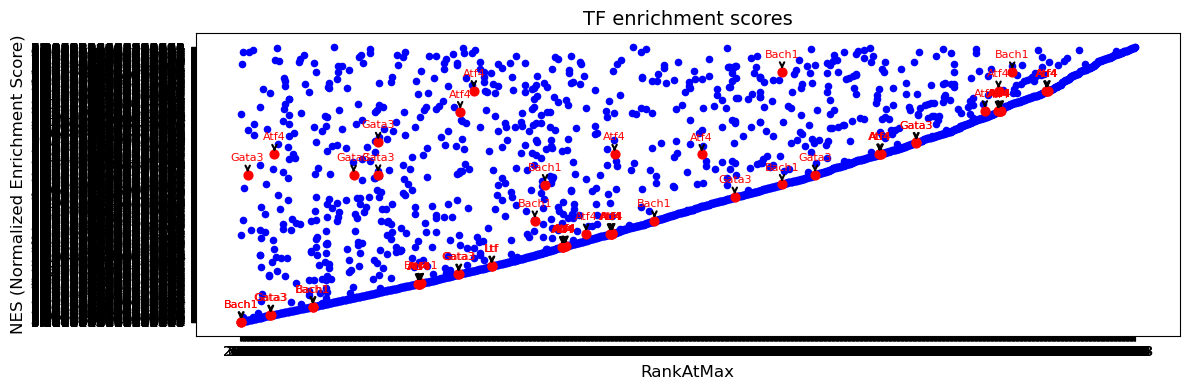

In [238]:
import matplotlib.pyplot as plt

highlight_tfs = {'Atf4','Bach1','Gata3','Ltf'}

plt.figure(figsize=(12, 4))
plt.scatter(regulons['RankAtMax'], regulons['NES'], color='blue', s=20)

highlight_df = regulons[regulons['TF'].isin(highlight_tfs)]

for i, row in highlight_df.iterrows():
    tf = row['TF']
    x = row['RankAtMax']
    y = row['NES']
    plt.scatter(x, y, color='red', s=40)
    plt.annotate(tf,
                 (x, y),
                 xytext=(0, 10),
                 textcoords="offset points",
                 ha='center',
                 fontsize=8,
                 color='red',
                 arrowprops=dict(facecolor='red', arrowstyle='->', lw=1.5))

plt.xlabel("RankAtMax", fontsize=12)
plt.ylabel("NES (Normalized Enrichment Score)", fontsize=12)
plt.title("TF enrichment scores", fontsize=14)
plt.tight_layout()
plt.show()


In [234]:
df_muc = regulons[regulons['TargetGenes'].str.contains("Muc4", case=False, na=False)]

print(f"총 {len(df_muc)} 개 regulon에서 Muc4 관련 유전자가 발견됨")

총 7 개 regulon에서 Muc4 관련 유전자가 발견됨


In [194]:
highlight_tfs = {
    'Atf3', 'Atf4', 'Bach1', 'Elf3', 'Elk3', 'Ets1', 'Ets2', 'Fos', 'Fosb',
    'Fosl1', 'Fosl2', 'Hnf1b', 'Irf6', 'Irf9', 'Junb', 'Klf3', 'Ltf',
    'Nfkb1', 'Rel', 'Rela', 'Relb', 'Srebf2', 'Yy1'
}

import pandas as pd
import ast

df_a['TargetGenes_list'] = df_a['TargetGenes'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
def select_priority_targets(tg_lists):
    for tg in tg_lists:
        genes = [g[0] for g in tg if isinstance(g, tuple)]
        if "Muc1" in genes and "Muc4" in genes:
            filtered_genes = [g for g in genes if g in ["Muc1","Muc4","Hbegf","Lif"]]
            return filtered_genes
    all_genes = []
    for tg in tg_lists:
        genes = [g[0] for g in tg if isinstance(g, tuple)]
        for g in genes:
            if g in ["Muc1","Muc4","Hbegf","Lif"] and g not in all_genes:
                all_genes.append(g)
    return all_genes
df_b = (
    df_a.groupby("TF", as_index=False)
        .agg({
            "NES": "max",
            "AUC": "max",
            "TargetGenes_list": lambda x: select_priority_targets(list(x))
        })
)

df_b['TargetGenes'] = df_b['TargetGenes_list'].apply(lambda x: str(x))
df_b = df_b.drop(columns=['TargetGenes_list'])

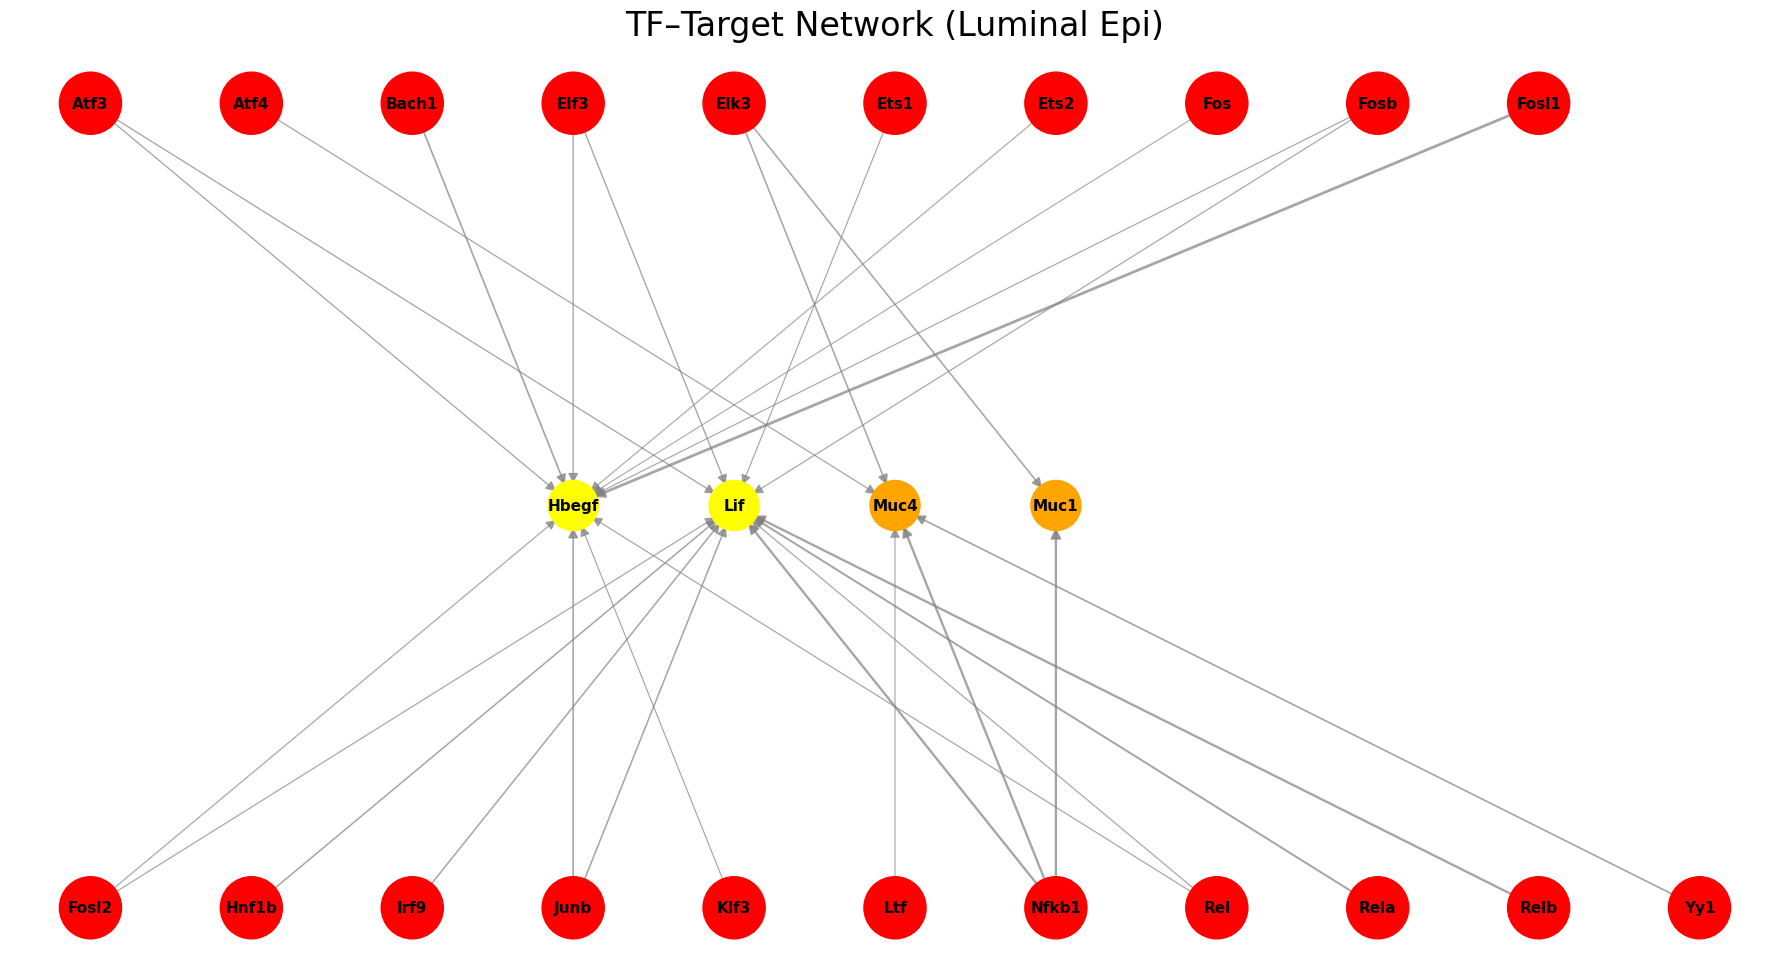

In [204]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import ast
import numpy as np

highlight_tfs = {
    'Atf3', 'Atf4', 'Bach1', 'Elf3', 'Elk3', 'Ets1', 'Ets2', 'Fos', 'Fosb',
    'Fosl1', 'Fosl2', 'Hnf1b', 'Irf6', 'Irf9', 'Junb', 'Klf3', 'Ltf',
    'Nfkb1', 'Rel', 'Rela', 'Relb', 'Srebf2', 'Yy1'
}

G = nx.DiGraph()

for idx, row in df_b.iterrows():
    tf = row['TF']
    weight = row['NES']
    targets = ast.literal_eval(row['TargetGenes']) if isinstance(row['TargetGenes'], str) else row['TargetGenes']
    filtered_targets = [g for g in targets if g in ["Muc1","Muc4","Hbegf","Lif"]]
    if not filtered_targets:
        continue
    G.add_node(tf, type='TF')
    for g in filtered_targets:
        G.add_node(g, type='gene')
        G.add_edge(tf, g, weight=weight)

tf_nodes = [n for n in G.nodes() if G.nodes[n]['type'] == 'TF']
gene_nodes = [n for n in G.nodes() if G.nodes[n]['type'] == 'gene']

half = len(tf_nodes) // 2
tf_top = tf_nodes[:half]
tf_bottom = tf_nodes[half:]

x_spacing = 6
pos = {}

for i, tf in enumerate(tf_top):
    pos[tf] = (i * x_spacing, 15)

# regulon은 중앙 정렬
regulon_x_start = (len(tf_top) - len(gene_nodes)) / 2 * x_spacing
for i, g in enumerate(gene_nodes):
    pos[g] = (regulon_x_start + i * x_spacing, 0)

for i, tf in enumerate(tf_bottom):
    pos[tf] = (i * x_spacing, -15)

plt.figure(figsize=(18, 14))
ax = plt.gca()
ax.set_aspect('equal')

node_colors, node_sizes = [], []
for n in G.nodes():
    if n in highlight_tfs:
        node_colors.append('red')
        node_sizes.append(2000)
    elif G.nodes[n]['type'] == 'TF':
        node_colors.append('orange')
        node_sizes.append(1500)
    else:
        if n in ["Hbegf", "Lif"]:
            node_colors.append('yellow')
        else:
            node_colors.append('orange')
        node_sizes.append(1300)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes)
nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold')

max_weight = max([d['weight'] for _, _, d in G.edges(data=True)]) if G.edges else 1
node_radius = {n: np.sqrt(size)/50 for n, size in zip(G.nodes(), node_sizes)}

for (u, v, d) in G.edges(data=True):
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    dx, dy = x2 - x1, y2 - y1
    dist = np.sqrt(dx**2 + dy**2)
    if dist == 0:
        continue
    offset_u = node_radius[u] / dist
    offset_v = node_radius[v] / dist
    start = (x1 + dx * offset_u, y1 + dy * offset_u)
    end   = (x2 - dx * offset_v, y2 - dy * offset_v)
    arrow = FancyArrowPatch(
        start, end,
        arrowstyle='-|>',
        color='gray',
        lw=d['weight'] / max_weight * 2,
        alpha=0.7,
        mutation_scale=15
    )
    ax.add_patch(arrow)

plt.axis('off')
plt.title("TF–Target Network (Luminal Epi)", fontsize=24, pad=20)
plt.tight_layout()
plt.show()


/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original objec

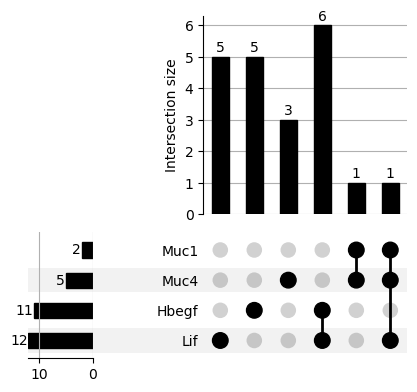

In [215]:
from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt

genes_of_interest = ["Hbegf", "Lif", "Muc1", "Muc4"]

memberships = []
for u, v in G.edges():
    if v in genes_of_interest:
        memberships.append((u, v))  # (TF, gene) 관계
tf_to_genes = {}
for gene in genes_of_interest:
    tfs = [u for u, v in G.edges() if v == gene]
    for tf in tfs:
        if tf not in tf_to_genes:
            tf_to_genes[tf] = set()
        tf_to_genes[tf].add(gene)
membership_list = [list(genes) for genes in tf_to_genes.values()]
upset_data = from_memberships(membership_list)
upset = UpSet(upset_data, subset_size='count', show_counts=True)
upset.plot()
plt.show()

In [240]:
file_path = "/home/Data_Drive_8TB/kykim/1. Oval/pySCENIC/output/auc_mtx.csv"
auc_mtx = pd.read_csv(file_path)
auc_mtx.set_index("Cell", inplace=True)
age_mapping = Epithelial.obs['age_group']
auc_mtx['age_group'] = age_mapping.reindex(auc_mtx.index)
clinical_info = Epithelial.obs['clinical information']
subtype_info = Epithelial.obs['subtype']
auc_mtx['subtype'] = subtype_info.reindex(auc_mtx.index)
if isinstance(auc_mtx['age_group'].dtype, pd.CategoricalDtype):
    auc_mtx['age_group'] = auc_mtx['age_group'].cat.add_categories(['decidualized_pregnant'])
mask = (auc_mtx['age_group'] == 'Young') & (clinical_info.reindex(auc_mtx.index) == 'decidualized_pregnant')
auc_mtx.loc[mask, 'age_group'] = 'decidualized_pregnant'

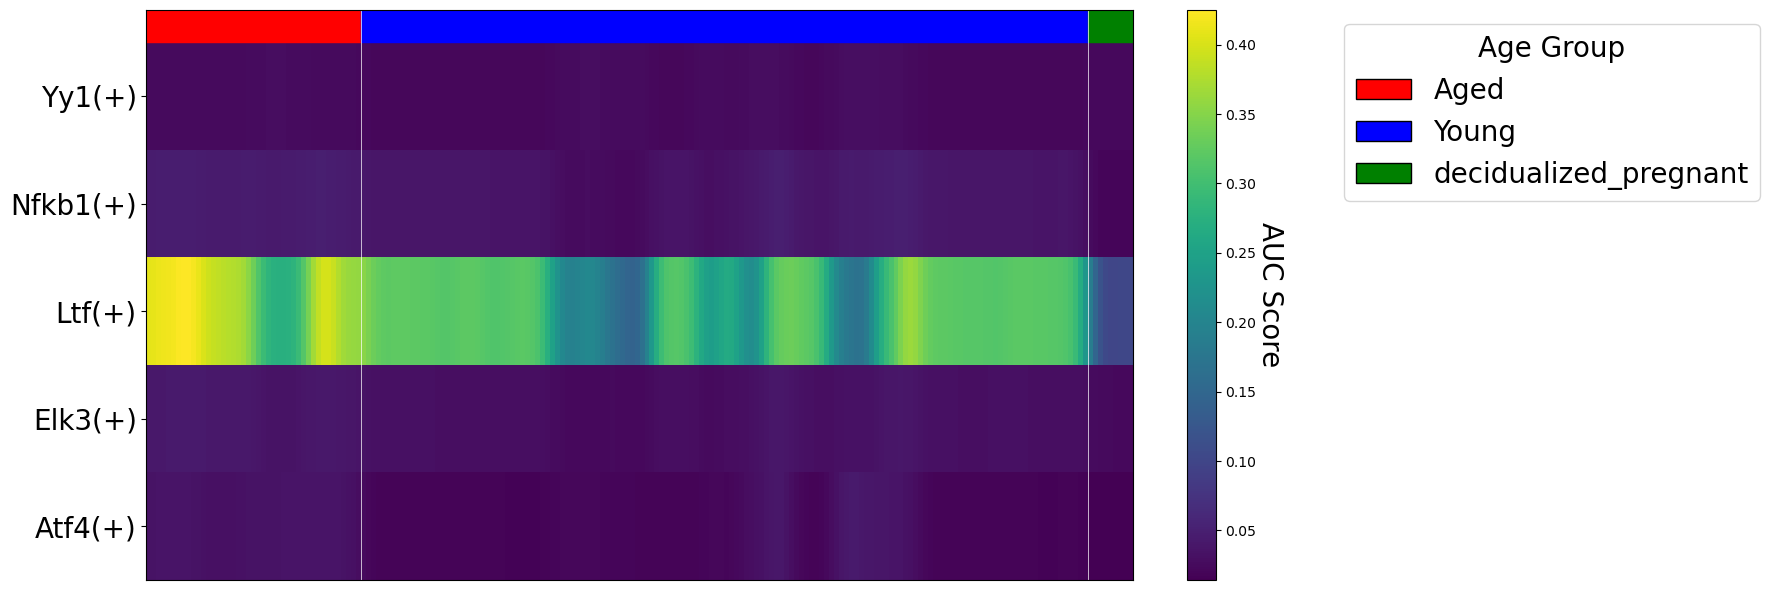

In [236]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from matplotlib.patches import Patch

n_bins = 200
sigma = 2
fig_width = 20
fig_height = 6
ytick_fontsize = 20
legend_fontsize = 20

selected_tfs = ['Atf4(+)', 'Elk3(+)', 'Ltf(+)', 'Nfkb1(+)', 'Yy1(+)']
group_colors = {'Aged': 'red', 'Young': 'blue', 'decidualized_pregnant': 'green'}

heat_data = auc_mtx.drop(columns=['age_group']).T
selected_tfs = [tf for tf in selected_tfs if tf in heat_data.index]
heat_data = heat_data.loc[selected_tfs]
age_group = auc_mtx['age_group']

if isinstance(age_group.dtype, pd.CategoricalDtype):
    if 'decidualized_pregnant' not in age_group.cat.categories:
        age_group = age_group.cat.add_categories(['decidualized_pregnant'])

mask = (age_group == 'Young') & (clinical_info.reindex(age_group.index) == 'decidualized_pregnant')
age_group.loc[mask] = 'decidualized_pregnant'

sorted_idx = age_group.sort_values().index
heat_data = heat_data[sorted_idx]
age_group = age_group[sorted_idx]

smoothed_data = pd.DataFrame(index=heat_data.index)
bin_group_labels = []

total_cells = len(age_group)
current_pos = 0  # X축 위치 tracker

for g_name in group_colors.keys():
    cells = age_group[age_group == g_name].index
    n_cells = len(cells)
    if n_cells == 0:
        continue
    bin_edges = np.linspace(0, n_cells, max(1, int(n_bins * n_cells / total_cells)) + 1, dtype=int)
    
    for i in range(len(bin_edges)-1):
        bin_cells = cells[bin_edges[i]:bin_edges[i+1]]
        if len(bin_cells) > 0:
            mean_profile = heat_data[bin_cells].mean(axis=1)
            smoothed_data = pd.concat([smoothed_data, pd.DataFrame(mean_profile)], axis=1)
            bin_group_labels.append(g_name)

smoothed_data = gaussian_filter1d(smoothed_data.values, sigma=sigma, axis=1)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

x = np.arange(smoothed_data.shape[1]+1)
y = np.arange(smoothed_data.shape[0]+1)
c = ax.pcolormesh(x, y, smoothed_data, cmap='viridis', shading='auto')

ax.set_yticks(np.arange(0.5, len(selected_tfs), 1))
ax.set_yticklabels(selected_tfs, fontsize=ytick_fontsize)
ax.set_xticks([])

for i, g_name in enumerate(bin_group_labels):
    ax.add_patch(plt.Rectangle((i, len(selected_tfs)), 1, 0.3, color=group_colors[g_name], transform=ax.transData))

ax.set_ylim(0, len(selected_tfs)+0.3)

cumulative_bins = np.cumsum([bin_group_labels.count(g) for g in group_colors.keys()])
for edge in cumulative_bins[:-1]:
    ax.axvline(edge, color='white', linewidth=0.5)

cbar = fig.colorbar(c, ax=ax, location='right', fraction=0.05, pad=0.05)
cbar.set_label('AUC Score', rotation=270, labelpad=20, fontsize=20)

age_patches = [Patch(facecolor=color, edgecolor='black', label=name) for name, color in group_colors.items()]
ax.legend(handles=age_patches, title='Age Group', loc='upper right', bbox_to_anchor=(1.65, 1), fontsize=legend_fontsize, title_fontsize=legend_fontsize)

plt.tight_layout()
plt.show()


/tmp/ipykernel_3524519/1282318380.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3524519/1282318380.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3524519/1282318380.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3524519/1282318380.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3524519/1282318380.py:26: Fut

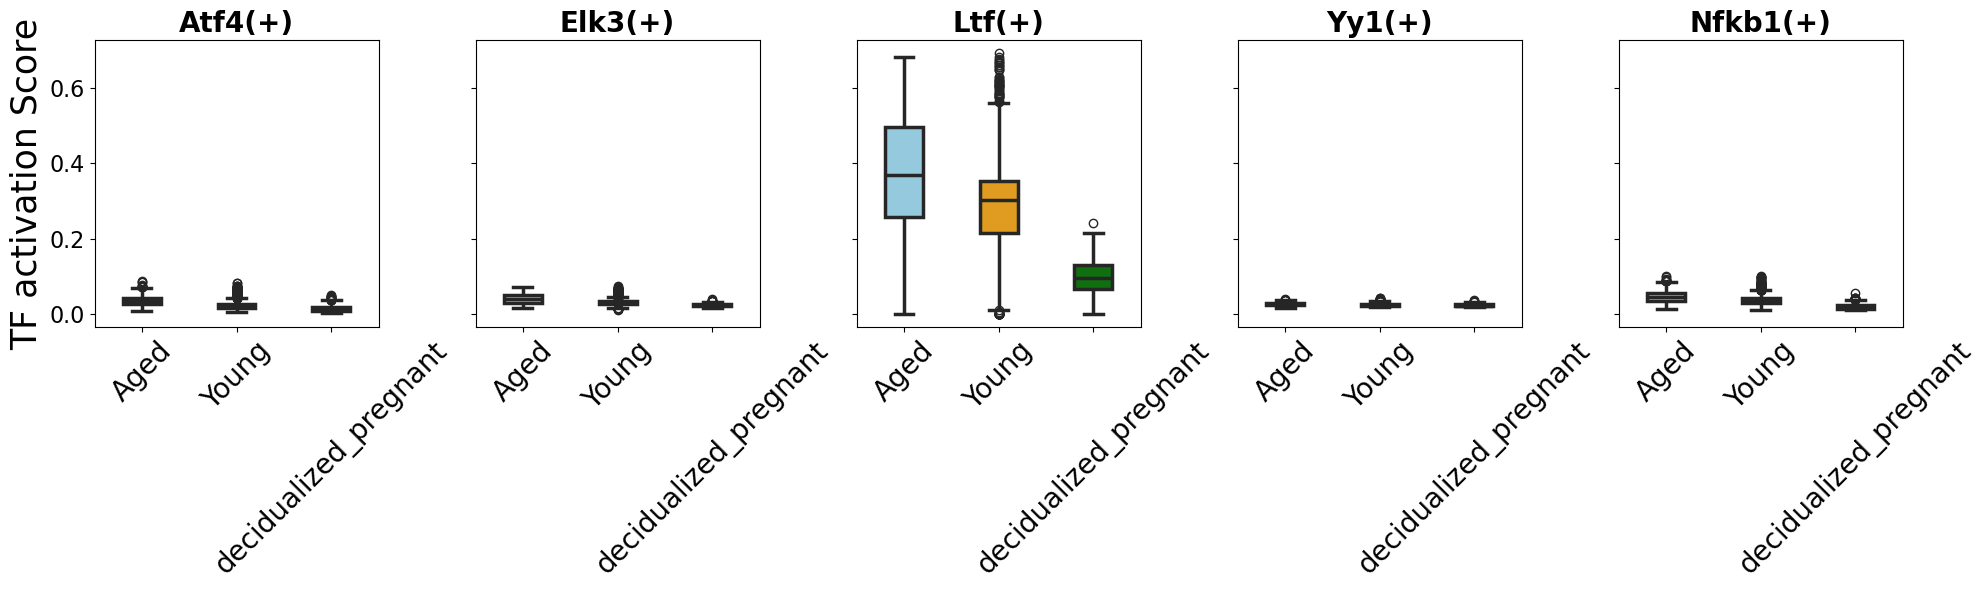

In [241]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tf_list = ['Atf4', 'Elk3', 'Ltf', 'Yy1','Nfkb1']
tf_list_plus = [f"{tf}(+)" for tf in tf_list]

auc_mtx_reset = auc_mtx.reset_index(drop=True)
age_group = auc_mtx_reset['age_group'].copy()
mask = (age_group == 'Young') & (clinical_info.reindex(auc_mtx_reset.index) == 'decidualized_pregnant')
age_group.loc[mask] = 'decidualized_pregnant'
auc_mtx_reset['age_group'] = age_group

tf_present = [tf for tf in tf_list_plus if tf in auc_mtx_reset.columns]
if len(tf_present) == 0:
    raise ValueError("선택한 TF가 auc_mtx에 없습니다!")

age_palette = {'Young':'orange', 'Aged':'skyblue', 'decidualized_pregnant':'green'}
n_tfs = len(tf_present)
fig, axes = plt.subplots(1, n_tfs, figsize=(4*n_tfs, 6), sharey=True)

if n_tfs == 1:
    axes = [axes]

for i, tf in enumerate(tf_present):
    sns.boxplot(
        x='age_group',
        y=tf,
        data=auc_mtx_reset,
        ax=axes[i],
        palette=age_palette,
        width=0.4,
        linewidth=2.5
    )
    
    axes[i].set_title(tf, fontsize=20, fontweight='bold')
    axes[i].set_xlabel('', fontsize=0)
    axes[i].set_ylabel('TF activation Score' if i==0 else '', fontsize=25)
    axes[i].tick_params(axis='x', labelsize=20, rotation=45)
    axes[i].tick_params(axis='y', labelsize=16)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3524519/3178983761.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3524519/3178983761.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3524519/3178983761.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3524519/3178983761.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3524519/3178983761.py:19: Fut

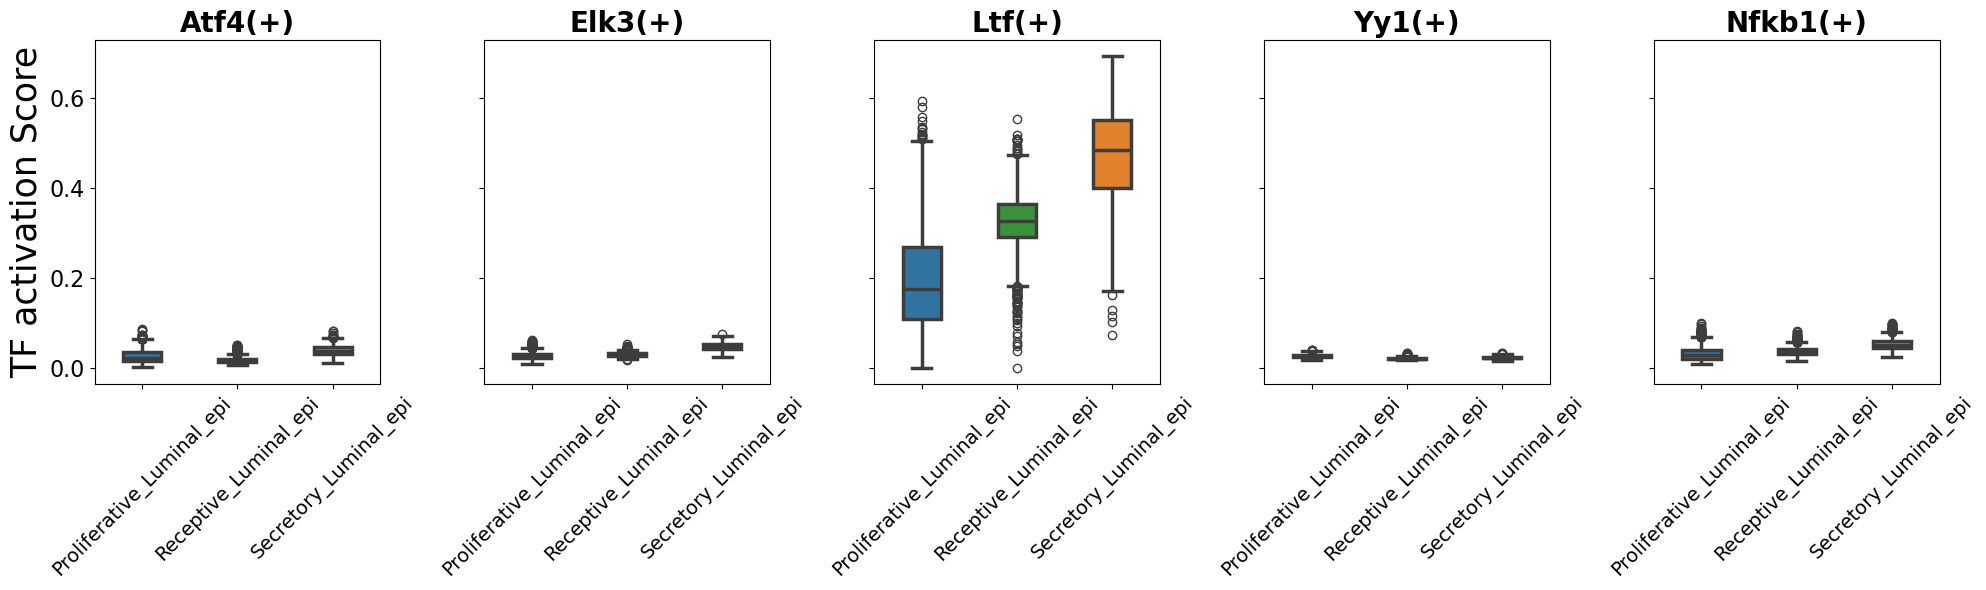

In [242]:
tf_list = ['Atf4', 'Elk3', 'Ltf', 'Yy1','Nfkb1']
tf_list_plus = [f"{tf}(+)" for tf in tf_list]

auc_mtx_reset = auc_mtx.reset_index(drop=True)
subtype = auc_mtx_reset['subtype'].copy()

tf_present = [tf for tf in tf_list_plus if tf in auc_mtx_reset.columns]
if len(tf_present) == 0:
    raise ValueError("선택한 TF가 auc_mtx에 없습니다!")

subtype_palette = {s: color for s, color in zip(subtype.unique(), sns.color_palette("tab10", n_colors=subtype.nunique()))}
n_tfs = len(tf_present)
fig, axes = plt.subplots(1, n_tfs, figsize=(4*n_tfs, 6), sharey=True)

if n_tfs == 1:
    axes = [axes]

for i, tf in enumerate(tf_present):
    sns.boxplot(
        x='subtype',
        y=tf,
        data=auc_mtx_reset,
        ax=axes[i],
        palette=subtype_palette,
        width=0.4,
        linewidth=2.5
    )
    
    axes[i].set_title(tf, fontsize=20, fontweight='bold')
    axes[i].set_xlabel('', fontsize=0)
    axes[i].set_ylabel('TF activation Score' if i==0 else '', fontsize=25)
    axes[i].tick_params(axis='x', labelsize=14, rotation=45)
    axes[i].tick_params(axis='y', labelsize=16)

plt.tight_layout()
plt.show()


In [243]:
########################################
############ Hbegf / Lif ###############
########################################

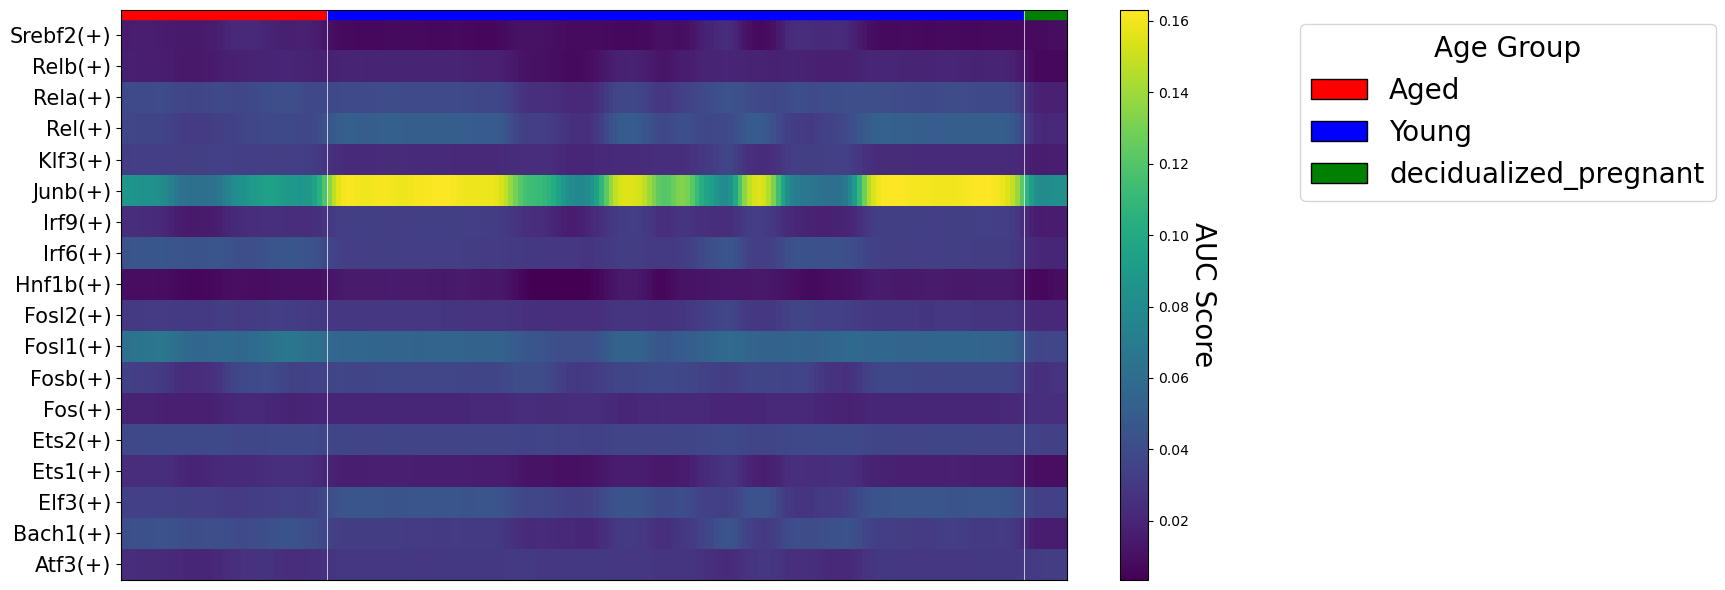

In [246]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from matplotlib.patches import Patch

all_tfs = [
    'Atf3', 'Atf4', 'Bach1', 'Elf3', 'Elk3', 'Ets1', 'Ets2', 'Fos', 'Fosb',
    'Fosl1', 'Fosl2', 'Hnf1b', 'Irf6', 'Irf9', 'Junb', 'Klf3', 'Ltf',
    'Nfkb1', 'Rel', 'Rela', 'Relb', 'Srebf2', 'Yy1'
]
exclude_tfs = ['Atf4', 'Elk3', 'Ltf', 'Nfkb1', 'Yy1']
selected_tfs = [f"{tf}(+)" for tf in all_tfs if tf not in exclude_tfs]

n_bins = 200
sigma = 2
fig_width = 20
fig_height = 6
ytick_fontsize = 15
legend_fontsize = 20
group_colors = {'Aged': 'red', 'Young': 'blue', 'decidualized_pregnant': 'green'}

heat_data = auc_mtx.drop(columns=['age_group']).T
selected_tfs = [tf for tf in selected_tfs if tf in heat_data.index]
heat_data = heat_data.loc[selected_tfs]
age_group = auc_mtx['age_group'].copy()

if isinstance(age_group.dtype, pd.CategoricalDtype):
    if 'decidualized_pregnant' not in age_group.cat.categories:
        age_group = age_group.cat.add_categories(['decidualized_pregnant'])

mask = (age_group == 'Young') & (clinical_info.reindex(age_group.index) == 'decidualized_pregnant')
age_group.loc[mask] = 'decidualized_pregnant'

sorted_idx = age_group.sort_values().index
heat_data = heat_data[sorted_idx]
age_group = age_group[sorted_idx]

smoothed_list = []
bin_group_labels = []

total_cells = len(age_group)

for g_name in group_colors.keys():
    cells = age_group[age_group == g_name].index
    n_cells = len(cells)
    if n_cells == 0:
        continue
    bin_edges = np.linspace(0, n_cells, max(1, int(n_bins * n_cells / total_cells)) + 1, dtype=int)
    for i in range(len(bin_edges)-1):
        bin_cells = cells[bin_edges[i]:bin_edges[i+1]]
        if len(bin_cells) > 0:
            mean_profile = heat_data[bin_cells].mean(axis=1).astype(float)
            smoothed_list.append(mean_profile.values)
            bin_group_labels.append(g_name)

smoothed_data = np.column_stack(smoothed_list)
smoothed_data = gaussian_filter1d(smoothed_data, sigma=sigma, axis=1)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
x = np.arange(smoothed_data.shape[1]+1)
y = np.arange(smoothed_data.shape[0]+1)
c = ax.pcolormesh(x, y, smoothed_data, cmap='viridis', shading='auto')

ax.set_yticks(np.arange(0.5, len(selected_tfs), 1))
ax.set_yticklabels(selected_tfs, fontsize=ytick_fontsize)
ax.set_xticks([])

for i, g_name in enumerate(bin_group_labels):
    ax.add_patch(plt.Rectangle((i, len(selected_tfs)), 1, 0.3, color=group_colors[g_name], transform=ax.transData))

ax.set_ylim(0, len(selected_tfs)+0.3)

cumulative_bins = np.cumsum([bin_group_labels.count(g) for g in group_colors.keys()])
for edge in cumulative_bins[:-1]:
    ax.axvline(edge, color='white', linewidth=0.5)

cbar = fig.colorbar(c, ax=ax, location='right', fraction=0.05, pad=0.05)
cbar.set_label('AUC Score', rotation=270, labelpad=20, fontsize=20)

age_patches = [Patch(facecolor=color, edgecolor='black', label=name) for name, color in group_colors.items()]
ax.legend(handles=age_patches, title='Age Group', loc='upper right', bbox_to_anchor=(1.7, 1), fontsize=legend_fontsize, title_fontsize=legend_fontsize)

plt.tight_layout()
plt.show()


/tmp/ipykernel_3524519/1256705244.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='subtype', y=tf, data=auc_mtx_reset, ax=axes[i], palette=subtype_palette, width=0.4, linewidth=2.5)
/tmp/ipykernel_3524519/1256705244.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='subtype', y=tf, data=auc_mtx_reset, ax=axes[i], palette=subtype_palette, width=0.4, linewidth=2.5)
/tmp/ipykernel_3524519/1256705244.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='subtype', y=tf, data=auc_mtx_reset, ax=axes[i], palette=subtype_palette, width=

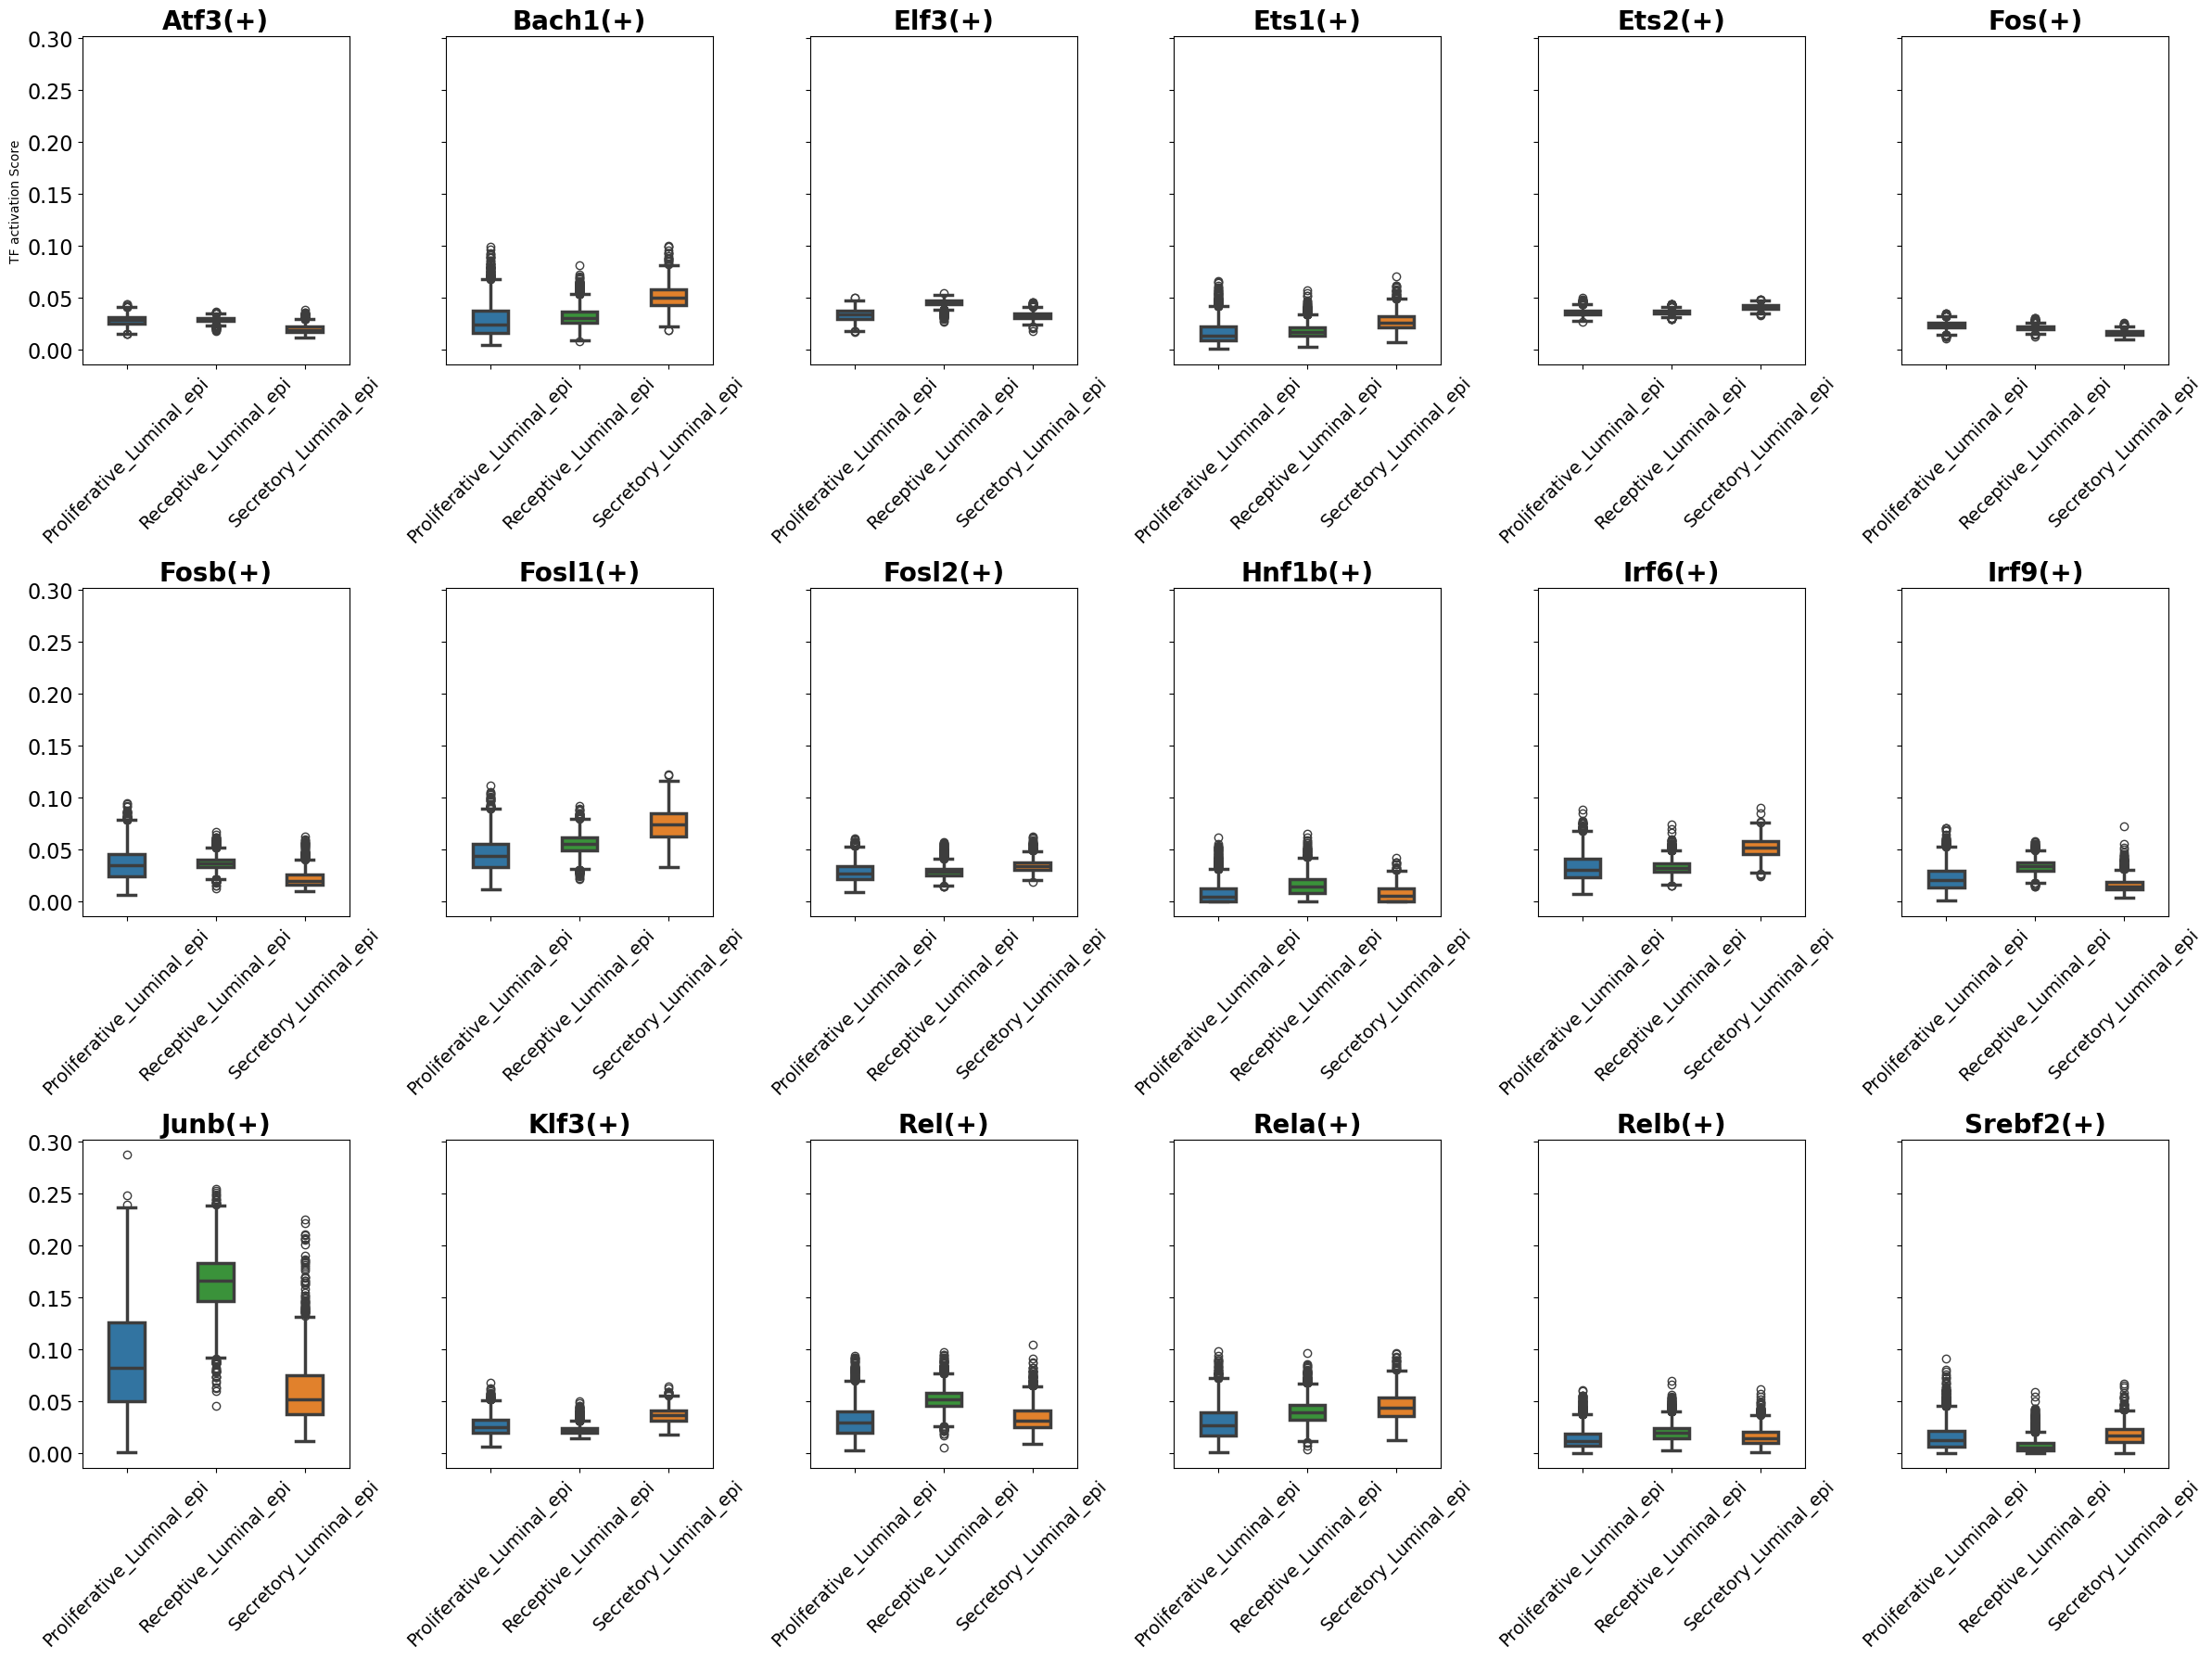

In [250]:
tf_list_plus = selected_tfs
auc_mtx_reset = auc_mtx.reset_index(drop=True)
subtype = auc_mtx_reset['subtype'].copy()
tf_present = [tf for tf in tf_list_plus if tf in auc_mtx_reset.columns]
subtype_palette = {s: color for s, color in zip(subtype.unique(), sns.color_palette("tab10", n_colors=subtype.nunique()))}
n_tfs = len(tf_present)
fig, axes = plt.subplots(3, 6, figsize=(24, 18), sharey=True)
axes = axes.flatten()
for i, tf in enumerate(tf_present):
    sns.boxplot(x='subtype', y=tf, data=auc_mtx_reset, ax=axes[i], palette=subtype_palette, width=0.4, linewidth=2.5)
    axes[i].set_title(tf, fontsize=20, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('TF activation Score' if i==0 else '')
    axes[i].tick_params(axis='x', labelsize=14, rotation=45)
    axes[i].tick_params(axis='y', labelsize=16)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()


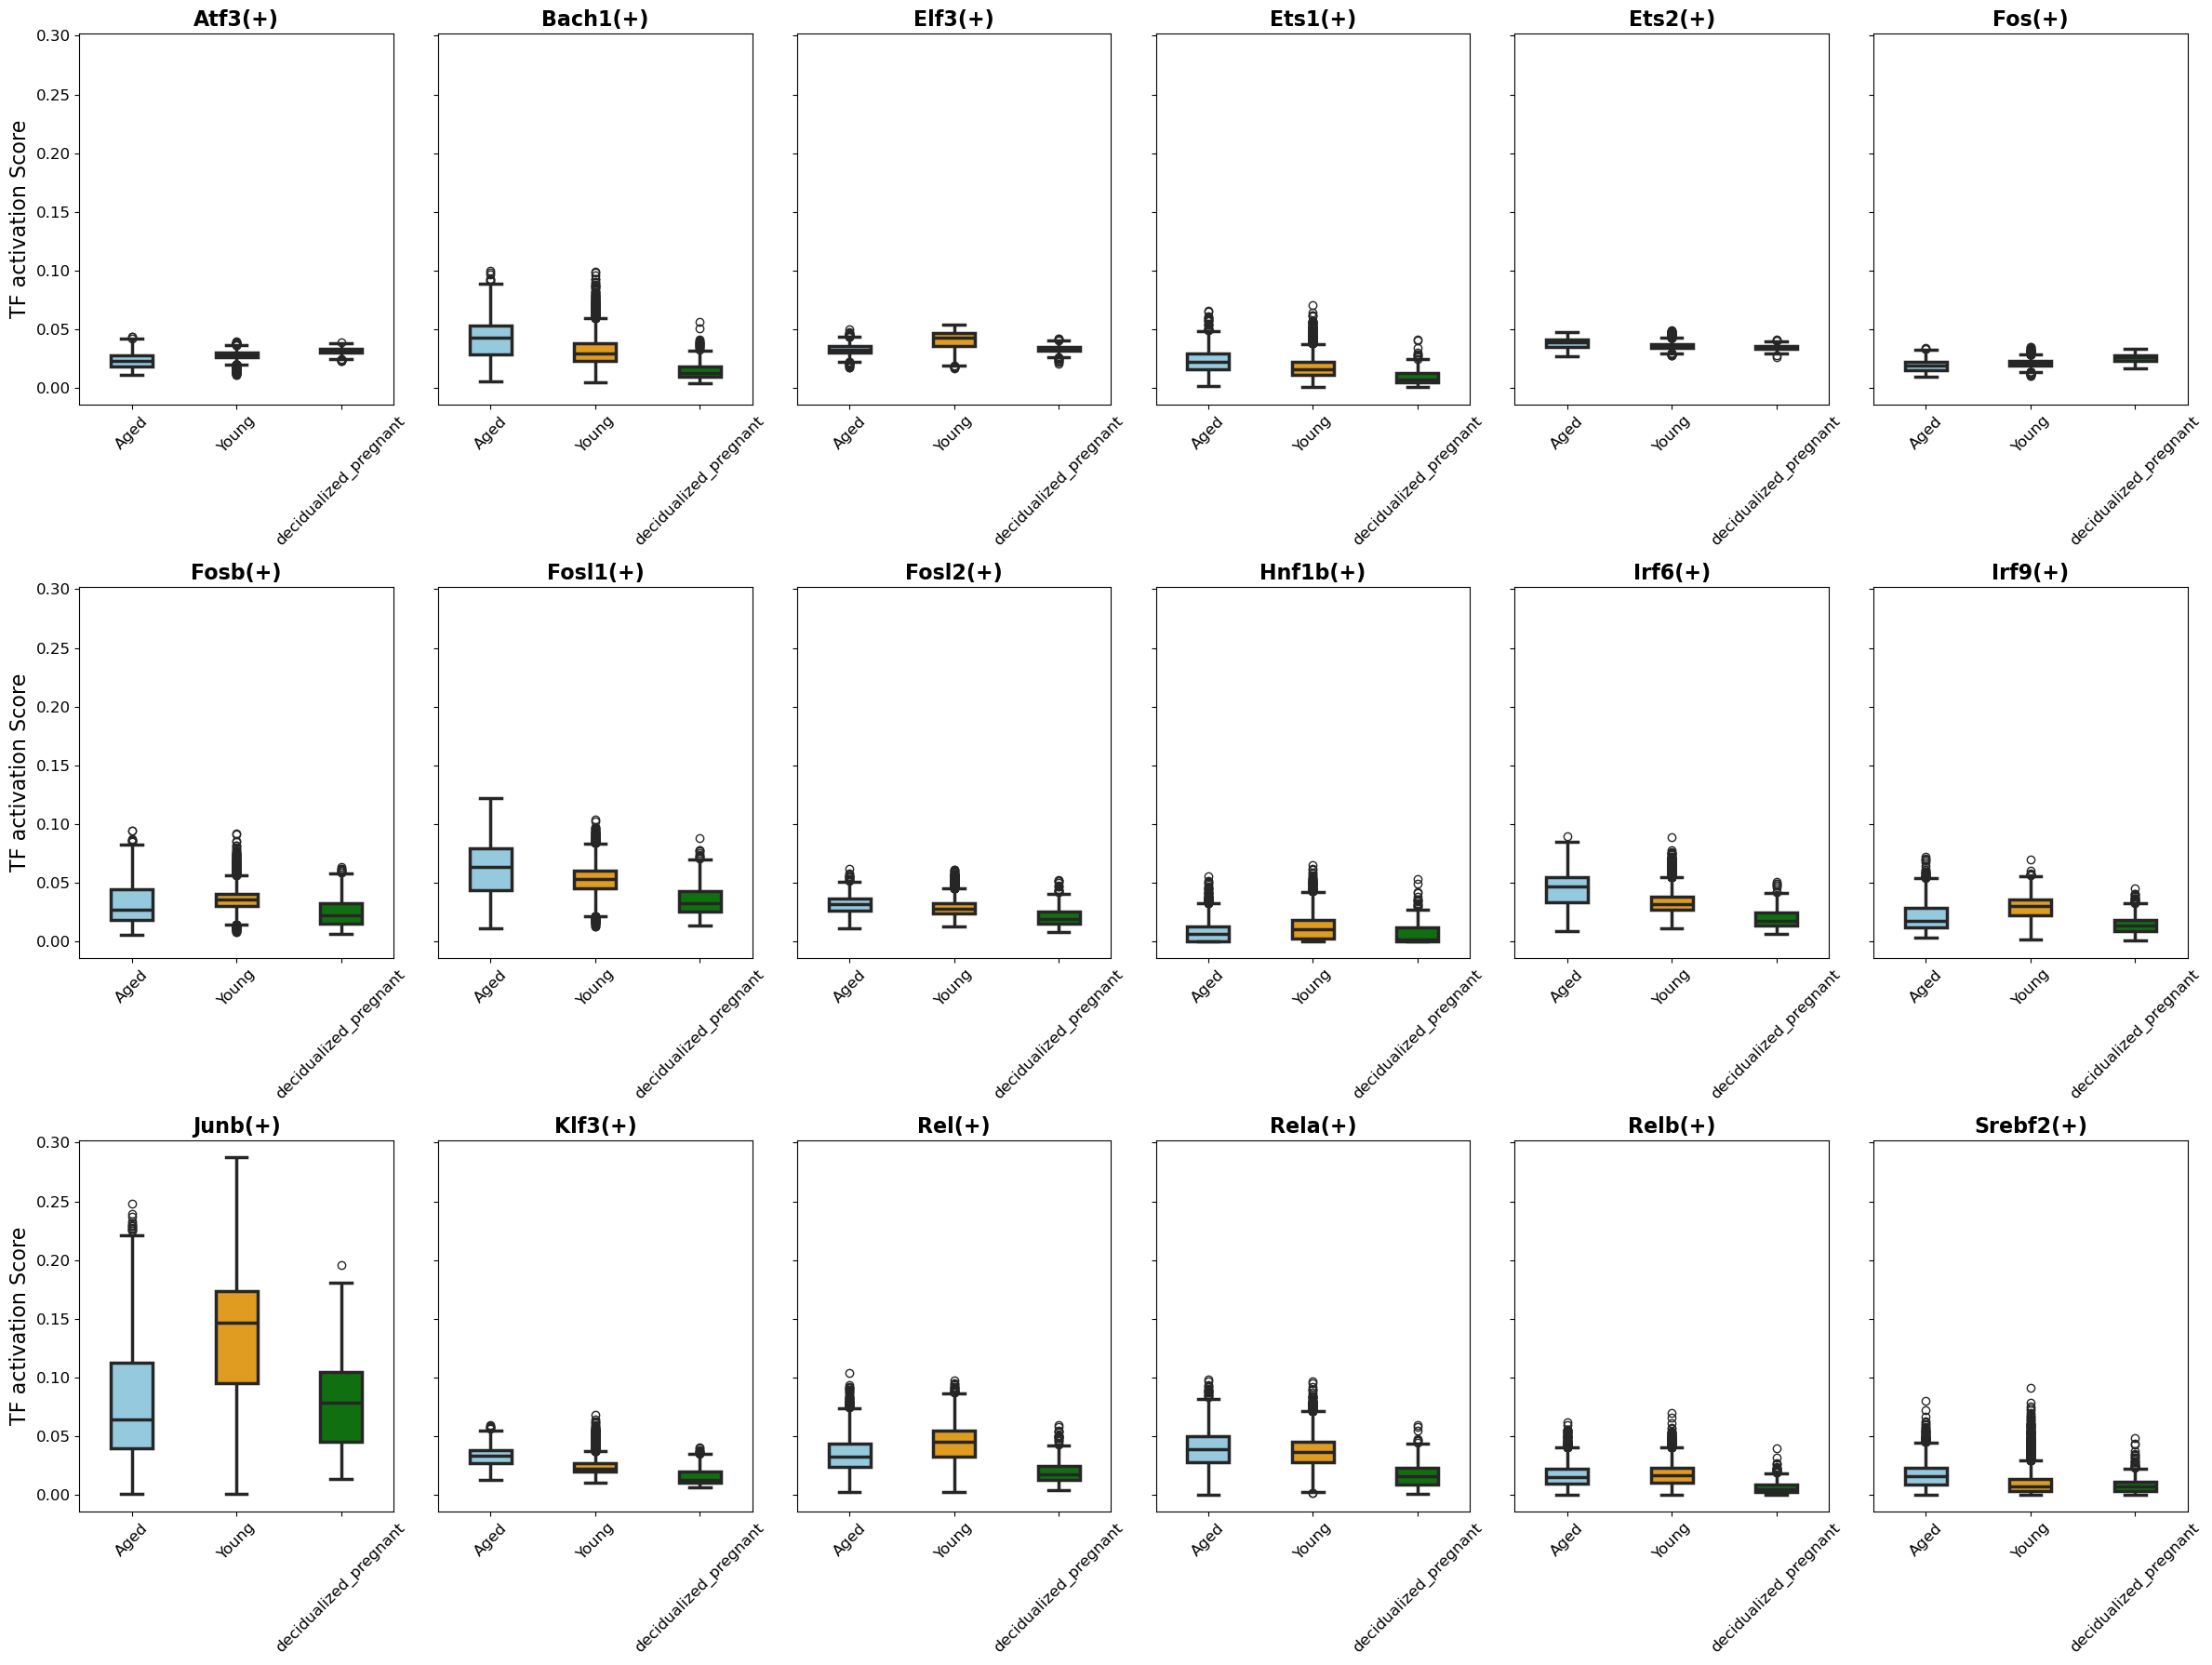

In [253]:
import warnings
warnings.filterwarnings("ignore")

tf_list_plus = selected_tfs
auc_mtx_reset = auc_mtx.reset_index(drop=True)
age_group = auc_mtx_reset['age_group'].copy()
mask = (age_group == 'Young') & (clinical_info.reindex(auc_mtx_reset.index) == 'decidualized_pregnant')
age_group.loc[mask] = 'decidualized_pregnant'
auc_mtx_reset['age_group'] = age_group

tf_present = [tf for tf in tf_list_plus if tf in auc_mtx_reset.columns]
age_palette = {'Young':'orange', 'Aged':'skyblue', 'decidualized_pregnant':'green'}
n_tfs = len(tf_present)
fig, axes = plt.subplots(3, 6, figsize=(24, 18), sharey=True)
axes = axes.flatten()

for i, tf in enumerate(tf_present):
    sns.boxplot(x='age_group', y=tf, data=auc_mtx_reset, ax=axes[i], palette=age_palette, width=0.4, linewidth=2.5)
    axes[i].set_title(tf, fontsize=16, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('TF activation Score' if i % 6 == 0 else '', fontsize=16)
    axes[i].tick_params(axis='x', labelsize=12, rotation=45)
    axes[i].tick_params(axis='y', labelsize=12)

for j in range(len(tf_present), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [10]:
#############################
###### Pyscenic 2 ###########
#############################

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

file_path = "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/after_HVG_Module_cell.h5ad"
adata = sc.read_h5ad(file_path)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [17]:
file_path = "/home/Data_Drive_8TB/kykim/1. Oval/pySCENIC/output/auc_mtx.csv"
auc_mtx = pd.read_csv(file_path, index_col=0)
auc_mtx.columns = [col.replace('(+)', '') for col in auc_mtx.columns]

In [23]:
tf_list = ['Bach1','Elf3','Fosl1','Myc','Rela','Fosl2','Jun','Junb','Atf4','Xbp1','Atf3','Rel']
common_idx = auc_mtx.index.intersection(adata.obs.index)
auc_filtered = auc_mtx.loc[common_idx, tf_list]
predict_module_series = adata.obs.loc[common_idx, 'predict_module']
auc_filtered_matched = auc_filtered.copy()
auc_filtered_matched['predict_module'] = predict_module_series

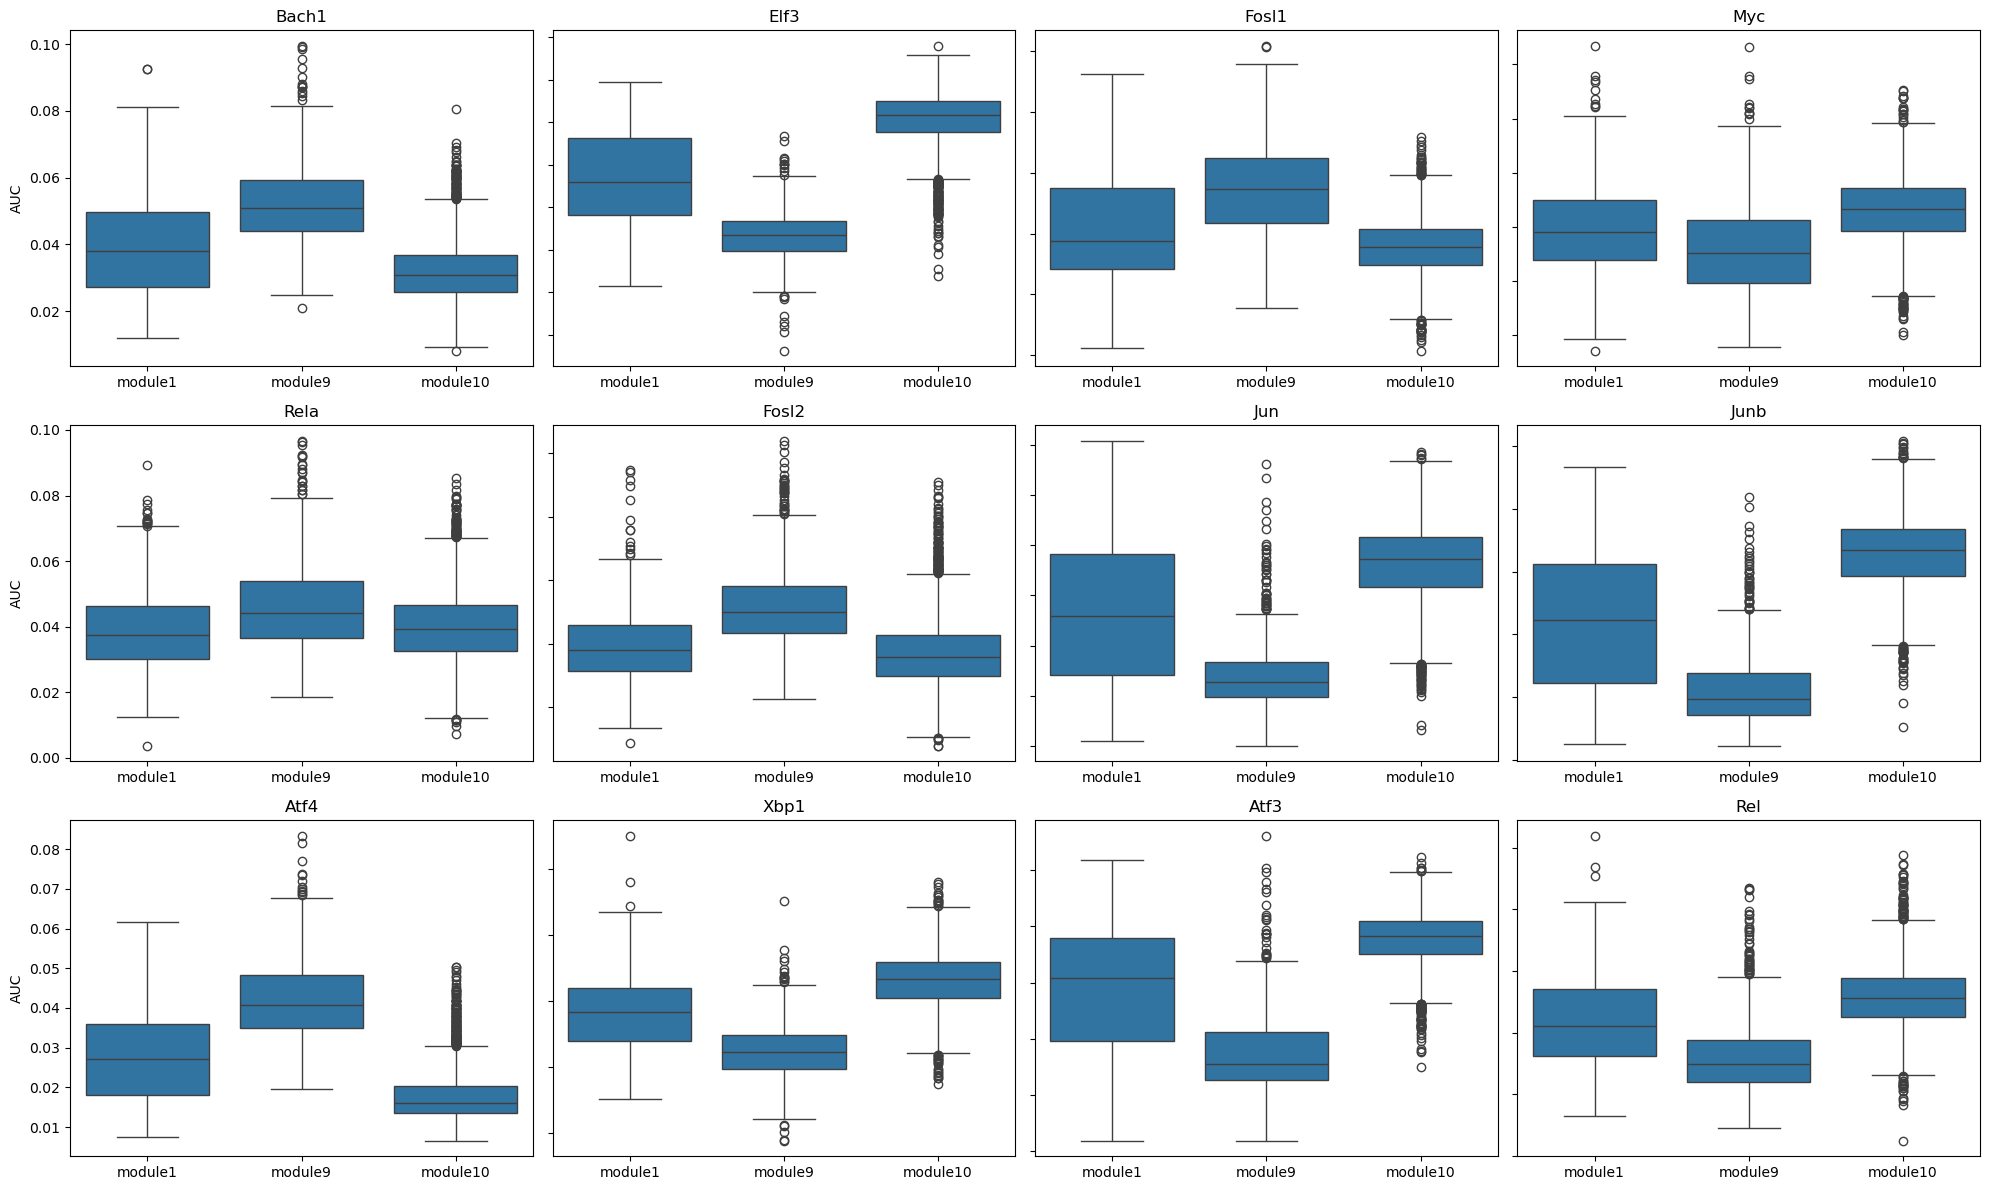

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

tf_list = ['Bach1','Elf3','Fosl1','Myc','Rela','Fosl2','Jun','Junb','Atf4','Xbp1','Atf3','Rel']

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, tf in enumerate(tf_list):
    sns.boxplot(
        data=auc_filtered_matched,
        x='predict_module',
        y=tf,
        ax=axes[i]
    )
    axes[i].set_title(tf)
    axes[i].set_xlabel('')
    if i % 4 != 0:
        axes[i].set_ylabel('')
        axes[i].tick_params(labelleft=False)
    else:
        axes[i].set_ylabel('AUC')

plt.tight_layout()
plt.show()


# Nichenet network

In [24]:
import scanpy as sc
file_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/after_HVG_lognorm_confilt.h5ad"
adata = sc.read_h5ad(file_path)

In [25]:
adata.obs[['subtype']].to_csv(
    '/home/Data_Drive_8TB/kykim/1. Oval/Nichenet/total_subtype.csv',
    index=True
)

In [26]:
adata.X = adata.layers['counts'].copy()

X = adata.X
X = X.toarray() if hasattr(X, "toarray") else X
X.min(), X.max()

(0, 32022)

In [27]:
import pandas as pd
keep = ["CD8_T_cells", "Luminal Epithelium"]
adata = adata[adata.obs["subtype"].isin(keep)].copy()

mod = pd.read_csv("/home/Data_Drive_8TB/kykim/1. Oval/Nichenet/module_metadata.csv", index_col=0)
adata.obs["module_cluster"] = adata.obs.index.map(mod["module_cluster"])
adata.obs["module_cluster"] = (adata.obs["module_cluster"].fillna("CD8_T_cells"))

In [28]:
adata.obs["module_cluster"].value_counts()

module_cluster
CD8_T_cells    4685
A              3527
B              1086
Name: count, dtype: int64

In [348]:
raw_adata = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Before_HVG_raw_clustering(large).h5ad")
module_info = adata.obs["module_cluster"]
common_barcodes = raw_adata.obs_names.intersection(module_info.index)
raw_adata_filtered = raw_adata[common_barcodes].copy()
raw_adata_filtered.obs["module_cluster"] = module_info.loc[common_barcodes]
raw_adata_filtered.write_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Nichenet/CD8_Module.h5ad")

In [349]:
########### Ligand x Receptor ############

/tmp/ipykernel_1128955/1002398817.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Epithelial.obs
/tmp/ipykernel_1128955/1002398817.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1128955/1002398817.py:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(module_order, rotation=45, fontsize=13)


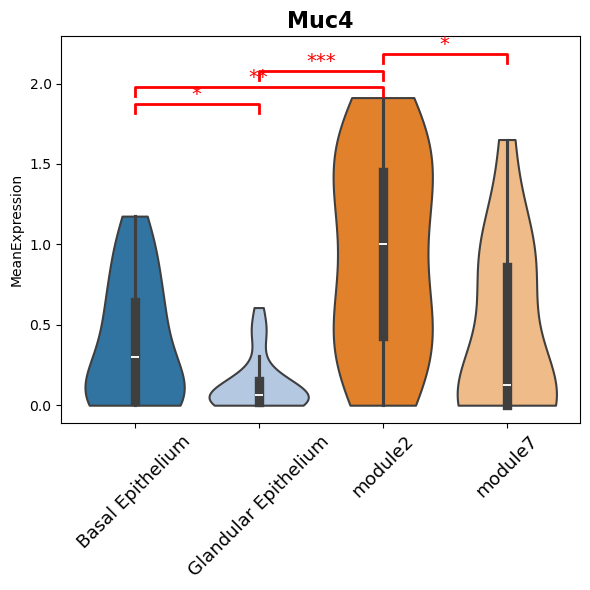

In [350]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ranksums

file_path = "/home/Data_Drive_8TB/kykim/1. Oval/Monocle/Luminal_adata.h5ad"
adata = sc.read_h5ad(file_path)

Epithelial = adata.copy()
Epithelial.layers["counts"] = Epithelial.X.copy()

genes = ["Muc4"]

module_order = sorted(Epithelial.obs["module_cluster"].unique())
module_palette = dict(zip(module_order, sns.color_palette("tab20", len(module_order))))

plot_list = []

for gene in genes:
    expr = Epithelial.to_df()[gene]
    for (sample_id, module_cluster), idx in (
        Epithelial.obs
        .groupby(["sample_id", "module_cluster"])
        .groups.items()
    ):
        plot_list.append({
            "Gene": gene,
            "sample_id": sample_id,
            "module_cluster": module_cluster,
            "MeanExpression": expr.loc[idx].mean()
        })

plot_df = pd.DataFrame(plot_list)

fig, axes = plt.subplots(1, len(genes), figsize=(6 * len(genes), 6))
if len(genes) == 1:
    axes = [axes]

for i, gene in enumerate(genes):
    ax = axes[i]
    sub_df = plot_df[plot_df["Gene"] == gene]

    sns.violinplot(
        data=sub_df,
        x="module_cluster",
        y="MeanExpression",
        order=module_order,
        palette=module_palette,
        cut=0,
        inner="box",
        linewidth=1.5,
        ax=ax
    )

    ymax = sub_df["MeanExpression"].max()
    h = ymax * 0.03
    bracket_y = ymax * 0.95

    for i1 in range(len(module_order)):
        for i2 in range(i1 + 1, len(module_order)):
            g1 = module_order[i1]
            g2 = module_order[i2]

            v1 = sub_df[sub_df["module_cluster"] == g1]["MeanExpression"]
            v2 = sub_df[sub_df["module_cluster"] == g2]["MeanExpression"]

            if len(v1) == 0 or len(v2) == 0:
                continue

            p = ranksums(v1, v2).pvalue

            if p < 0.05:
                star = "***" if p < 0.001 else "**" if p < 0.01 else "*"

                x1, x2 = i1, i2
                y = bracket_y

                ax.plot(
                    [x1, x1, x2, x2],
                    [y, y + h, y + h, y],
                    lw=2,
                    c="red"
                )

                ax.text(
                    (x1 + x2) / 2,
                    y + h,
                    star,
                    ha="center",
                    va="bottom",
                    color="red",
                    fontsize=14
                )

                bracket_y += h * 1.8

    ax.set_title(gene, fontsize=16, fontweight="bold")
    ax.set_xlabel("")
    ax.set_xticklabels(module_order, rotation=45, fontsize=13)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1128955/4180869715.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Epithelial.obs
/tmp/ipykernel_1128955/4180869715.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1128955/4180869715.py:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(module_order, rotation=45, fontsize=13)


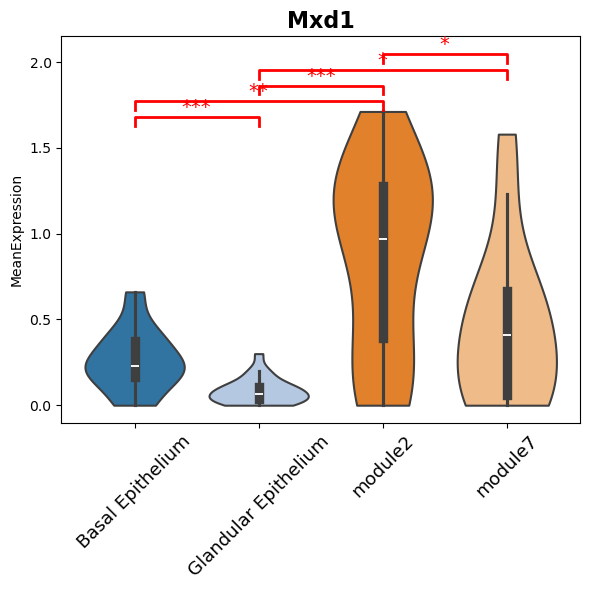

In [351]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ranksums

file_path = "/home/Data_Drive_8TB/kykim/1. Oval/Monocle/Luminal_adata.h5ad"
adata = sc.read_h5ad(file_path)

Epithelial = adata.copy()
Epithelial.layers["counts"] = Epithelial.X.copy()

genes = ["Mxd1"]

module_order = sorted(Epithelial.obs["module_cluster"].unique())
module_palette = dict(zip(module_order, sns.color_palette("tab20", len(module_order))))

plot_list = []

for gene in genes:
    expr = Epithelial.to_df()[gene]
    for (sample_id, module_cluster), idx in (
        Epithelial.obs
        .groupby(["sample_id", "module_cluster"])
        .groups.items()
    ):
        plot_list.append({
            "Gene": gene,
            "sample_id": sample_id,
            "module_cluster": module_cluster,
            "MeanExpression": expr.loc[idx].mean()
        })

plot_df = pd.DataFrame(plot_list)

fig, axes = plt.subplots(1, len(genes), figsize=(6 * len(genes), 6))
if len(genes) == 1:
    axes = [axes]

for i, gene in enumerate(genes):
    ax = axes[i]
    sub_df = plot_df[plot_df["Gene"] == gene]

    sns.violinplot(
        data=sub_df,
        x="module_cluster",
        y="MeanExpression",
        order=module_order,
        palette=module_palette,
        cut=0,
        inner="box",
        linewidth=1.5,
        ax=ax
    )

    ymax = sub_df["MeanExpression"].max()
    h = ymax * 0.03
    bracket_y = ymax * 0.95

    for i1 in range(len(module_order)):
        for i2 in range(i1 + 1, len(module_order)):
            g1 = module_order[i1]
            g2 = module_order[i2]

            v1 = sub_df[sub_df["module_cluster"] == g1]["MeanExpression"]
            v2 = sub_df[sub_df["module_cluster"] == g2]["MeanExpression"]

            if len(v1) == 0 or len(v2) == 0:
                continue

            p = ranksums(v1, v2).pvalue

            if p < 0.05:
                star = "***" if p < 0.001 else "**" if p < 0.01 else "*"

                x1, x2 = i1, i2
                y = bracket_y

                ax.plot(
                    [x1, x1, x2, x2],
                    [y, y + h, y + h, y],
                    lw=2,
                    c="red"
                )

                ax.text(
                    (x1 + x2) / 2,
                    y + h,
                    star,
                    ha="center",
                    va="bottom",
                    color="red",
                    fontsize=14
                )

                bracket_y += h * 1.8

    ax.set_title(gene, fontsize=16, fontweight="bold")
    ax.set_xlabel("")
    ax.set_xticklabels(module_order, rotation=45, fontsize=13)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1128955/4034563964.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Epithelial.obs
/tmp/ipykernel_1128955/4034563964.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1128955/4034563964.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(module_order, rotation=45, fontsize=13)


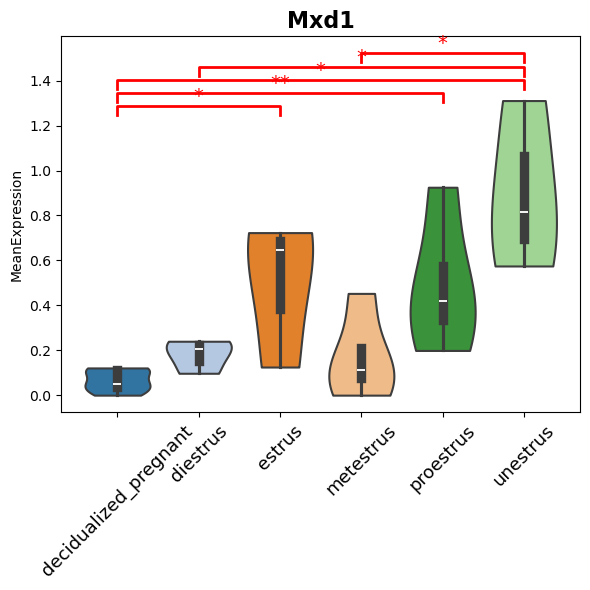

In [352]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ranksums

file_path = "/home/Data_Drive_8TB/kykim/1. Oval/Monocle/Luminal_adata.h5ad"
adata = sc.read_h5ad(file_path)

Epithelial = adata.copy()
Epithelial.layers["counts"] = Epithelial.X.copy()

genes = ["Mxd1"]

group_key = "clinical information"
module_order = sorted(Epithelial.obs[group_key].unique())
module_palette = dict(zip(module_order, sns.color_palette("tab20", len(module_order))))

plot_list = []

for gene in genes:
    expr = Epithelial.to_df()[gene]

    for (sample_id, group), idx in (
        Epithelial.obs
        .groupby(["sample_id", group_key])
        .groups.items()
    ):
        plot_list.append({
            "Gene": gene,
            "sample_id": sample_id,
            group_key: group,
            "MeanExpression": expr.loc[idx].mean()
        })

plot_df = pd.DataFrame(plot_list)

fig, axes = plt.subplots(1, len(genes), figsize=(6 * len(genes), 6))
if len(genes) == 1:
    axes = [axes]

for i, gene in enumerate(genes):
    ax = axes[i]
    sub_df = plot_df[plot_df["Gene"] == gene]

    sns.violinplot(
        data=sub_df,
        x=group_key,
        y="MeanExpression",
        order=module_order,
        palette=module_palette,
        cut=0,
        inner="box",
        linewidth=1.5,
        ax=ax
    )

    ymax = sub_df["MeanExpression"].max()
    h = ymax * 0.03
    bracket_y = ymax * 0.95

    for i1 in range(len(module_order)):
        for i2 in range(i1 + 1, len(module_order)):
            g1 = module_order[i1]
            g2 = module_order[i2]

            v1 = sub_df[sub_df[group_key] == g1]["MeanExpression"]
            v2 = sub_df[sub_df[group_key] == g2]["MeanExpression"]

            if len(v1) == 0 or len(v2) == 0:
                continue

            p = ranksums(v1, v2).pvalue

            if p < 0.05:
                star = "***" if p < 0.001 else "**" if p < 0.01 else "*"

                x1, x2 = i1, i2
                y = bracket_y

                ax.plot(
                    [x1, x1, x2, x2],
                    [y, y + h, y + h, y],
                    lw=2,
                    c="red"
                )

                ax.text(
                    (x1 + x2) / 2,
                    y + h,
                    star,
                    ha="center",
                    va="bottom",
                    color="red",
                    fontsize=14
                )

                bracket_y += h * 1.5

    ax.set_title(gene, fontsize=16, fontweight="bold")
    ax.set_xlabel("")
    ax.set_xticklabels(module_order, rotation=45, fontsize=13)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1128955/2059333945.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Epithelial.obs
/tmp/ipykernel_1128955/2059333945.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1128955/2059333945.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(module_order, rotation=45, fontsize=13)


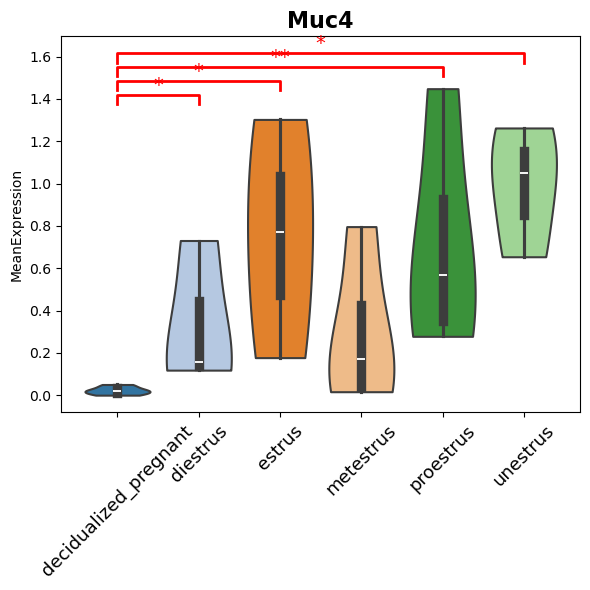

In [353]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ranksums

file_path = "/home/Data_Drive_8TB/kykim/1. Oval/Monocle/Luminal_adata.h5ad"
adata = sc.read_h5ad(file_path)

Epithelial = adata.copy()
Epithelial.layers["counts"] = Epithelial.X.copy()

genes = ["Muc4"]

group_key = "clinical information"
module_order = sorted(Epithelial.obs[group_key].unique())
module_palette = dict(zip(module_order, sns.color_palette("tab20", len(module_order))))

plot_list = []

for gene in genes:
    expr = Epithelial.to_df()[gene]

    for (sample_id, group), idx in (
        Epithelial.obs
        .groupby(["sample_id", group_key])
        .groups.items()
    ):
        plot_list.append({
            "Gene": gene,
            "sample_id": sample_id,
            group_key: group,
            "MeanExpression": expr.loc[idx].mean()
        })

plot_df = pd.DataFrame(plot_list)

fig, axes = plt.subplots(1, len(genes), figsize=(6 * len(genes), 6))
if len(genes) == 1:
    axes = [axes]

for i, gene in enumerate(genes):
    ax = axes[i]
    sub_df = plot_df[plot_df["Gene"] == gene]

    sns.violinplot(
        data=sub_df,
        x=group_key,
        y="MeanExpression",
        order=module_order,
        palette=module_palette,
        cut=0,
        inner="box",
        linewidth=1.5,
        ax=ax
    )

    ymax = sub_df["MeanExpression"].max()
    h = ymax * 0.03
    bracket_y = ymax * 0.95

    for i1 in range(len(module_order)):
        for i2 in range(i1 + 1, len(module_order)):
            g1 = module_order[i1]
            g2 = module_order[i2]

            v1 = sub_df[sub_df[group_key] == g1]["MeanExpression"]
            v2 = sub_df[sub_df[group_key] == g2]["MeanExpression"]

            if len(v1) == 0 or len(v2) == 0:
                continue

            p = ranksums(v1, v2).pvalue

            if p < 0.05:
                star = "***" if p < 0.001 else "**" if p < 0.01 else "*"

                x1, x2 = i1, i2
                y = bracket_y

                ax.plot(
                    [x1, x1, x2, x2],
                    [y, y + h, y + h, y],
                    lw=2,
                    c="red"
                )

                ax.text(
                    (x1 + x2) / 2,
                    y + h,
                    star,
                    ha="center",
                    va="bottom",
                    color="red",
                    fontsize=14
                )

                bracket_y += h * 1.5

    ax.set_title(gene, fontsize=16, fontweight="bold")
    ax.set_xlabel("")
    ax.set_xticklabels(module_order, rotation=45, fontsize=13)

plt.tight_layout()
plt.show()

In [354]:
########### Ligand pseudobulk
##############################

/tmp/ipykernel_1128955/1431522236.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1128955/1431522236.py:118: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(group_order, rotation=45, fontsize=13)


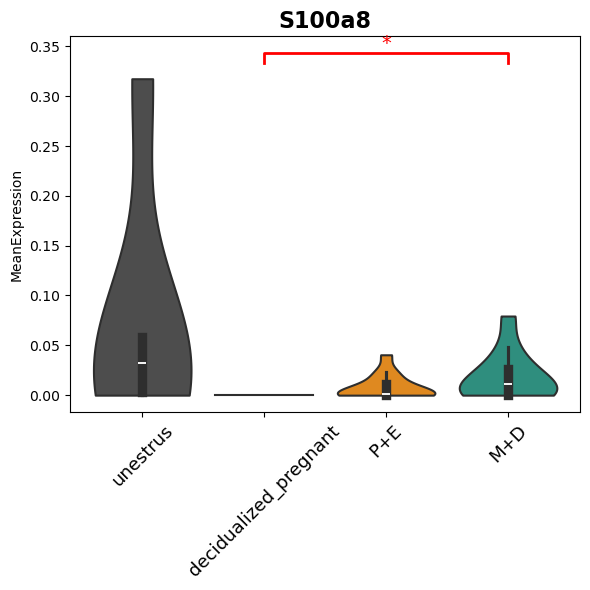

In [355]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import ranksums

file_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/after_HVG_lognorm_confilt.h5ad"
adata = sc.read_h5ad(file_path)

Epithelial = adata[adata.obs['subtype'] == 'CD8_T_cells'].copy()
Epithelial.layers["counts"] = Epithelial.X.copy()

genes = ["S100a8"]

group_map = {
    "proestrus": "P+E",
    "estrus": "P+E",
    "metestrus": "M+D",
    "diestrus": "M+D",
    "unestrus": "unestrus",
    "decidualized_pregnant": "decidualized_pregnant"
}

group_order = [
    "unestrus",
    "decidualized_pregnant",
    "P+E",
    "M+D"
]

group_palette = {
    "unestrus": "#4d4d4d",
    "decidualized_pregnant": "#7b68ee",
    "P+E": "#ff8c00",
    "M+D": "#1f9e89"
}

plot_list = []

for gene in genes:
    expr = Epithelial.to_df()[gene]
    for sample_id in Epithelial.obs["sample_id"].unique():
        idx = Epithelial.obs.index[Epithelial.obs["sample_id"] == sample_id]
        if len(idx) == 0:
            continue
        clin = Epithelial.obs.loc[idx, "clinical information"].iloc[0]
        plot_list.append({
            "Gene": gene,
            "sample_id": sample_id,
            "clinical_info": clin,
            "group": group_map[clin],
            "MeanExpression": expr.loc[idx].mean()
        })

plot_df = pd.DataFrame(plot_list)

fig, axes = plt.subplots(1, len(genes), figsize=(6 * len(genes), 6))
if len(genes) == 1:
    axes = [axes]

for i, gene in enumerate(genes):
    ax = axes[i]
    sub_df = plot_df[plot_df["Gene"] == gene]

    sns.violinplot(
        data=sub_df,
        x="group",
        y="MeanExpression",
        order=group_order,
        palette=group_palette,
        cut=0,
        inner="box",
        linewidth=1.5,
        ax=ax
    )

    ymax = sub_df["MeanExpression"].max()
    h = ymax * 0.03
    bracket_y = ymax * 1.05

    for i1 in range(len(group_order)):
        for i2 in range(i1 + 1, len(group_order)):
            g1 = group_order[i1]
            g2 = group_order[i2]

            v1 = sub_df[sub_df["group"] == g1]["MeanExpression"]
            v2 = sub_df[sub_df["group"] == g2]["MeanExpression"]

            if len(v1) == 0 or len(v2) == 0:
                continue

            p = ranksums(v1, v2).pvalue

            if p < 0.05:
                star = "***" if p < 0.001 else "**" if p < 0.01 else "*"

                ax.plot(
                    [i1, i1, i2, i2],
                    [bracket_y, bracket_y + h, bracket_y + h, bracket_y],
                    lw=2,
                    c="red"
                )
                ax.text(
                    (i1 + i2) / 2,
                    bracket_y + h,
                    star,
                    ha="center",
                    va="bottom",
                    color="red",
                    fontsize=14
                )

                bracket_y += h * 1.5

    ax.set_title(gene, fontsize=16, fontweight="bold")
    ax.set_xlabel("")
    ax.set_xticklabels(group_order, rotation=45, fontsize=13)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1128955/52336877.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Epithelial.obs
/tmp/ipykernel_1128955/52336877.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1128955/52336877.py:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(module_order, rotation=45, fontsize=13)


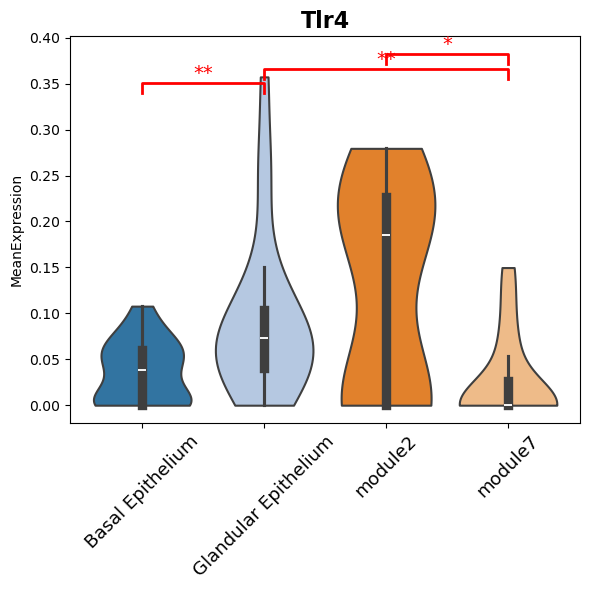

In [356]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ranksums

file_path = "/home/Data_Drive_8TB/kykim/1. Oval/Monocle/Luminal_adata.h5ad"
adata = sc.read_h5ad(file_path)

adata = adata[adata.obs['organism part'] != 'spleen'].copy()

Epithelial = adata.copy()
Epithelial.layers["counts"] = Epithelial.X.copy()

genes = ["Tlr4"]

module_order = sorted(Epithelial.obs["module_cluster"].unique())
module_palette = dict(zip(module_order, sns.color_palette("tab20", len(module_order))))

plot_list = []

for gene in genes:
    expr = Epithelial.to_df()[gene]
    for (sample_id, module_cluster), idx in (
        Epithelial.obs
        .groupby(["sample_id", "module_cluster"])
        .groups.items()
    ):
        plot_list.append({
            "Gene": gene,
            "sample_id": sample_id,
            "module_cluster": module_cluster,
            "MeanExpression": expr.loc[idx].mean()
        })

plot_df = pd.DataFrame(plot_list)

fig, axes = plt.subplots(1, len(genes), figsize=(6 * len(genes), 6))
if len(genes) == 1:
    axes = [axes]

for i, gene in enumerate(genes):
    ax = axes[i]
    sub_df = plot_df[plot_df["Gene"] == gene]

    sns.violinplot(
        data=sub_df,
        x="module_cluster",
        y="MeanExpression",
        order=module_order,
        palette=module_palette,
        cut=0,
        inner="box",
        linewidth=1.5,
        ax=ax
    )

    ymax = sub_df["MeanExpression"].max()
    h = ymax * 0.03
    bracket_y = ymax * 0.95

    for i1 in range(len(module_order)):
        for i2 in range(i1 + 1, len(module_order)):
            g1 = module_order[i1]
            g2 = module_order[i2]

            v1 = sub_df[sub_df["module_cluster"] == g1]["MeanExpression"]
            v2 = sub_df[sub_df["module_cluster"] == g2]["MeanExpression"]

            if len(v1) == 0 or len(v2) == 0:
                continue

            p = ranksums(v1, v2).pvalue

            if p < 0.05:
                star = "***" if p < 0.001 else "**" if p < 0.01 else "*"

                ax.plot(
                    [i1, i1, i2, i2],
                    [bracket_y, bracket_y + h, bracket_y + h, bracket_y],
                    lw=2,
                    c="red"
                )

                ax.text(
                    (i1 + i2) / 2,
                    bracket_y + h,
                    star,
                    ha="center",
                    va="bottom",
                    color="red",
                    fontsize=14
                )

                bracket_y += h * 1.5

    ax.set_title(gene, fontsize=16, fontweight="bold")
    ax.set_xlabel("")
    ax.set_xticklabels(module_order, rotation=45, fontsize=13)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1128955/3962179388.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Epithelial.obs
/tmp/ipykernel_1128955/3962179388.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1128955/3962179388.py:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(module_order, rotation=45, fontsize=13)


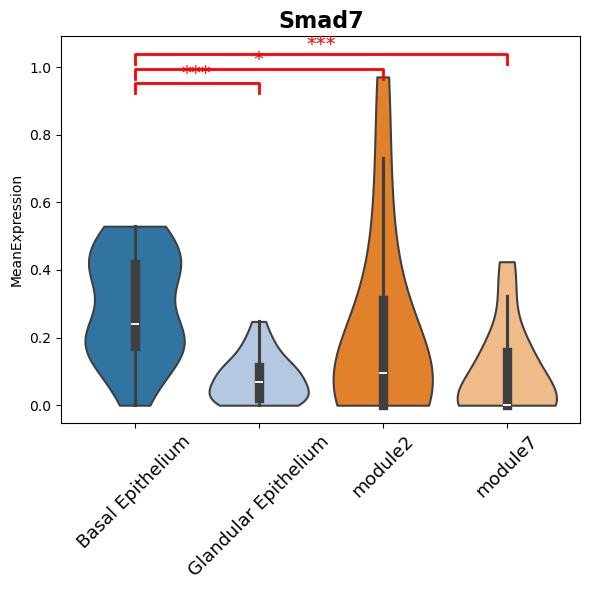

In [357]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ranksums

file_path = "/home/Data_Drive_8TB/kykim/1. Oval/Monocle/Luminal_adata.h5ad"
adata = sc.read_h5ad(file_path)

adata = adata[adata.obs['organism part'] != 'spleen'].copy()

Epithelial = adata.copy()
Epithelial.layers["counts"] = Epithelial.X.copy()

genes = ["Smad7"]

module_order = sorted(Epithelial.obs["module_cluster"].unique())
module_palette = dict(zip(module_order, sns.color_palette("tab20", len(module_order))))

plot_list = []

for gene in genes:
    expr = Epithelial.to_df()[gene]
    for (sample_id, module_cluster), idx in (
        Epithelial.obs
        .groupby(["sample_id", "module_cluster"])
        .groups.items()
    ):
        plot_list.append({
            "Gene": gene,
            "sample_id": sample_id,
            "module_cluster": module_cluster,
            "MeanExpression": expr.loc[idx].mean()
        })

plot_df = pd.DataFrame(plot_list)

fig, axes = plt.subplots(1, len(genes), figsize=(6 * len(genes), 6))
if len(genes) == 1:
    axes = [axes]

for i, gene in enumerate(genes):
    ax = axes[i]
    sub_df = plot_df[plot_df["Gene"] == gene]

    sns.violinplot(
        data=sub_df,
        x="module_cluster",
        y="MeanExpression",
        order=module_order,
        palette=module_palette,
        cut=0,
        inner="box",
        linewidth=1.5,
        ax=ax
    )

    ymax = sub_df["MeanExpression"].max()
    h = ymax * 0.03
    bracket_y = ymax * 0.95

    for i1 in range(len(module_order)):
        for i2 in range(i1 + 1, len(module_order)):
            g1 = module_order[i1]
            g2 = module_order[i2]

            v1 = sub_df[sub_df["module_cluster"] == g1]["MeanExpression"]
            v2 = sub_df[sub_df["module_cluster"] == g2]["MeanExpression"]

            if len(v1) == 0 or len(v2) == 0:
                continue

            p = ranksums(v1, v2).pvalue

            if p < 0.05:
                star = "***" if p < 0.001 else "**" if p < 0.01 else "*"

                ax.plot(
                    [i1, i1, i2, i2],
                    [bracket_y, bracket_y + h, bracket_y + h, bracket_y],
                    lw=2,
                    c="red"
                )

                ax.text(
                    (i1 + i2) / 2,
                    bracket_y + h,
                    star,
                    ha="center",
                    va="bottom",
                    color="red",
                    fontsize=14
                )

                bracket_y += h * 1.5

    ax.set_title(gene, fontsize=16, fontweight="bold")
    ax.set_xlabel("")
    ax.set_xticklabels(module_order, rotation=45, fontsize=13)

plt.tight_layout()
plt.show()

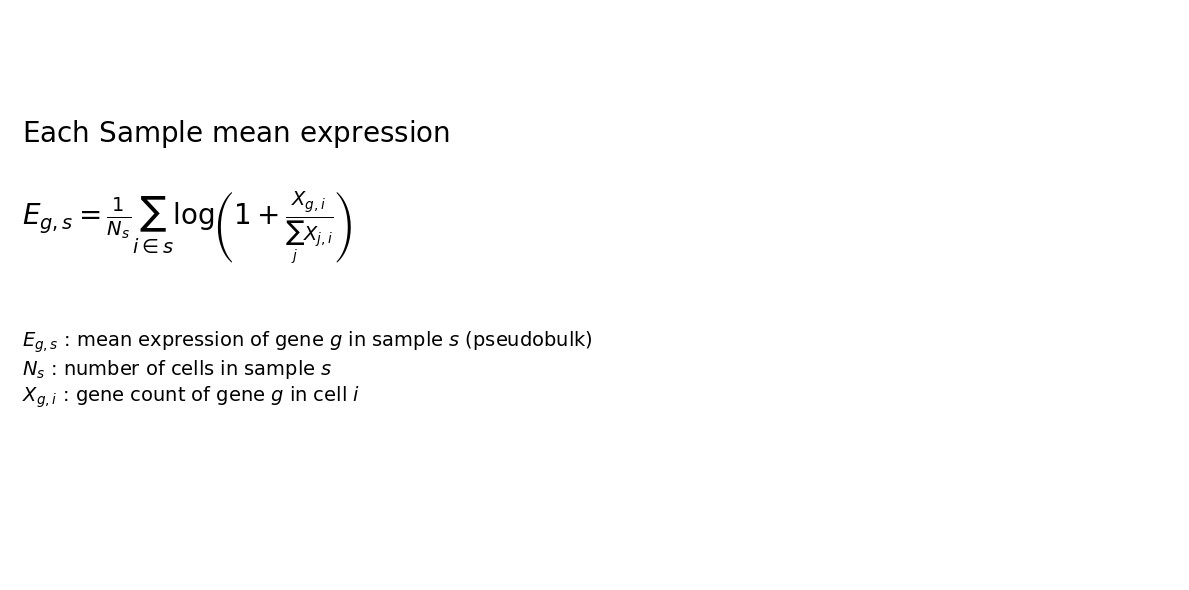

In [358]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

formula = (
    r"$\mathrm{Each\ Sample\ mean\ expression}$" "\n\n"
    r"$E_{g,s} = \frac{1}{N_s}\sum_{i \in s}"
    r"\log\!\left(1 + \frac{X_{g,i}}{\sum_{j} X_{j,i}}\right)$"
)

description = (
    r"$E_{g,s}$ : mean expression of gene $g$ in sample $s$ (pseudobulk)" "\n"
    r"$N_s$ : number of cells in sample $s$" "\n"
    r"$X_{g,i}$ : gene count of gene $g$ in cell $i$" "\n"
)

ax.text(
    0.01,
    0.68,
    formula,
    fontsize=20,
    fontweight="bold",
    ha="left",
    va="center"
)

ax.text(
    0.01,
    0.35,
    description,
    fontsize=14,
    ha="left",
    va="center"
)

plt.tight_layout()
plt.show()

In [359]:
########### Receptor pseudobulk
##############################

In [422]:
import pandas as pd
import scanpy as sc

file_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/after_HVG_lognorm_confilt.h5ad"
adata = sc.read_h5ad(file_path)

adata.obs[['subtype']].to_csv('/home/Data_Drive_8TB/kykim/1. Oval/Nichenet/total_subtype.csv', index=True)
adata.X = adata.layers['counts'].copy()
keep = ["CD8_T_cells", "Luminal Epithelium", "Basal Epithelium", "Glandular Epithelium"]
adata = adata[adata.obs["subtype"].isin(keep)].copy()
mod = pd.read_csv("/home/Data_Drive_8TB/kykim/1. Oval/Nichenet/module_metadata.csv",index_col=0)
adata.obs["module_cluster"] = adata.obs.index.map(mod["module_cluster"])
adata.obs.loc[
    adata.obs["module_cluster"].isna(),
    "module_cluster"
] = adata.obs.loc[
    adata.obs["module_cluster"].isna(),
    "subtype"]
adata.obs["module_cluster"] = adata.obs["module_cluster"].fillna("-")

raw_adata = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Before_HVG_raw_clustering(large).h5ad")
common_cells = raw_adata.obs_names.intersection(adata.obs_names)
raw_adata = raw_adata[common_cells].copy()
adata_sub = adata[common_cells].copy()
raw_adata.obs["module_cluster"] = adata_sub.obs["module_cluster"].values
adata = raw_adata

/tmp/ipykernel_1128955/3193245809.py:18: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  t_group = t_adata.obs["clinical information"].replace(group_map)
/tmp/ipykernel_1128955/3193245809.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t_mean = t_df.groupby("group")["expr"].mean()


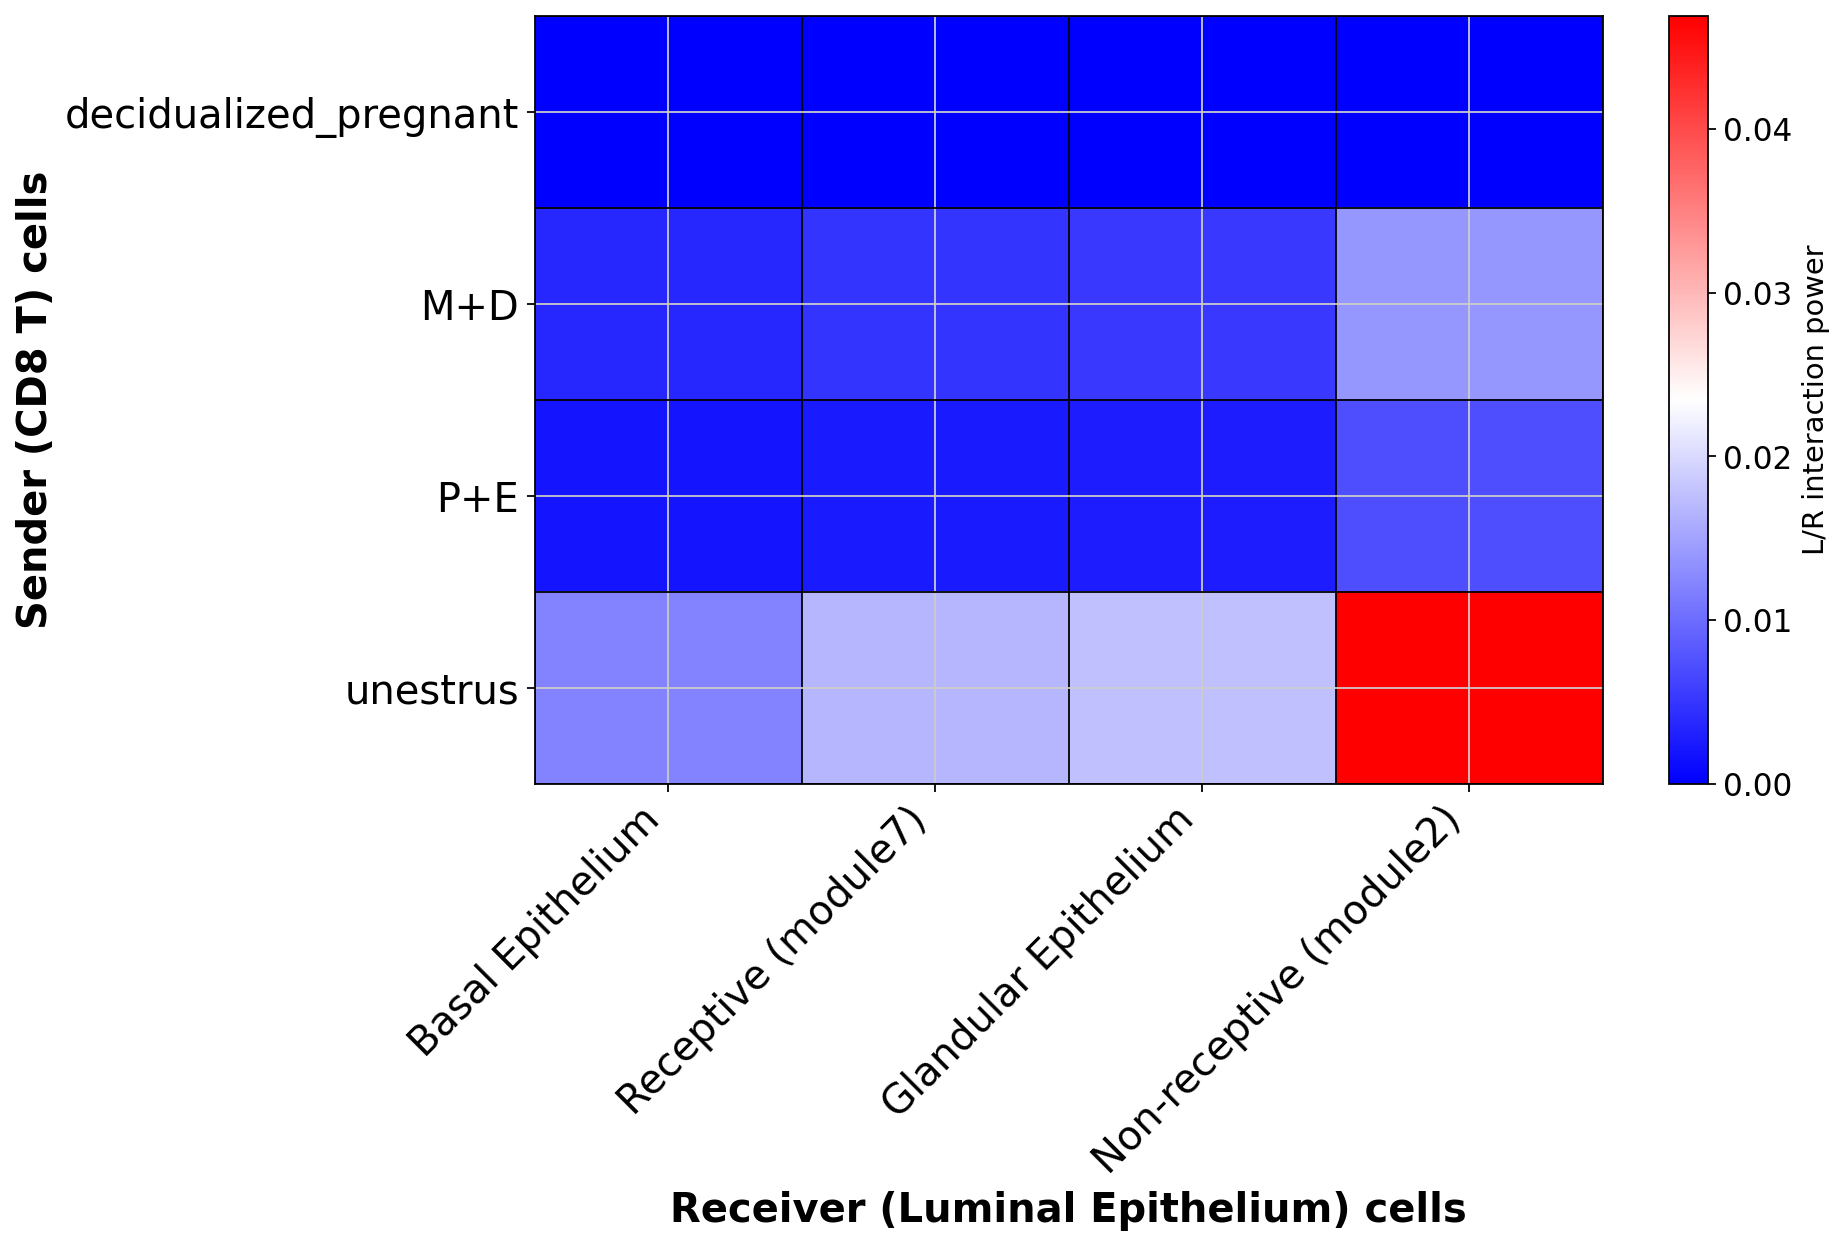

In [423]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import issparse

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

group_map = {
    "proestrus": "P+E",
    "estrus": "P+E",
    "metestrus": "M+D",
    "diestrus": "M+D"
}

t_adata = adata[adata.obs["module_cluster"] == "CD8_T_cells"].copy()
t_group = t_adata.obs["clinical information"].replace(group_map)

t_expr = t_adata[:, "S100a8"].X
t_expr = t_expr.toarray().ravel() if issparse(t_expr) else t_expr.ravel()

t_df = pd.DataFrame({
    "group": t_group.values,
    "expr": t_expr
})

t_mean = t_df.groupby("group")["expr"].mean()

x_modules = [
    "Basal Epithelium",
    "Receptive (module7)",
    "Glandular Epithelium",
    "Non-receptive (module2)"
]

module_replace = {
    "A": "Receptive (module7)",
    "B": "Non-receptive (module2)"
}

adata.obs["module_cluster"] = adata.obs["module_cluster"].replace(module_replace)

m_adata = adata[adata.obs["module_cluster"].isin(x_modules)].copy()

m_expr = m_adata[:, "Tlr4"].X
m_expr = m_expr.toarray().ravel() if issparse(m_expr) else m_expr.ravel()

m_df = pd.DataFrame({
    "module": m_adata.obs["module_cluster"].values,
    "expr": m_expr
})

m_mean = m_df.groupby("module")["expr"].mean()
m_mean = m_mean.loc[x_modules]

heatmap = np.outer(t_mean.values, m_mean.values)

fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(
    heatmap,
    aspect="auto",
    cmap="bwr"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("L/R interaction power", fontsize=13)

ax.set_yticks(range(len(t_mean.index)))
ax.set_yticklabels(t_mean.index, fontsize=18)

ax.set_xticks(range(len(x_modules)))
ax.set_xticklabels(x_modules, rotation=45, ha="right", fontsize=18)

ax.set_ylabel("Sender (CD8 T) cells", fontsize=18, fontweight="bold")
ax.set_xlabel("Receiver (Luminal Epithelium) cells", fontsize=18, fontweight="bold")

ax.set_xticks(np.arange(-0.5, heatmap.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, heatmap.shape[0], 1), minor=True)
ax.grid(which="minor", color="black", linestyle="-", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()
plt.show()

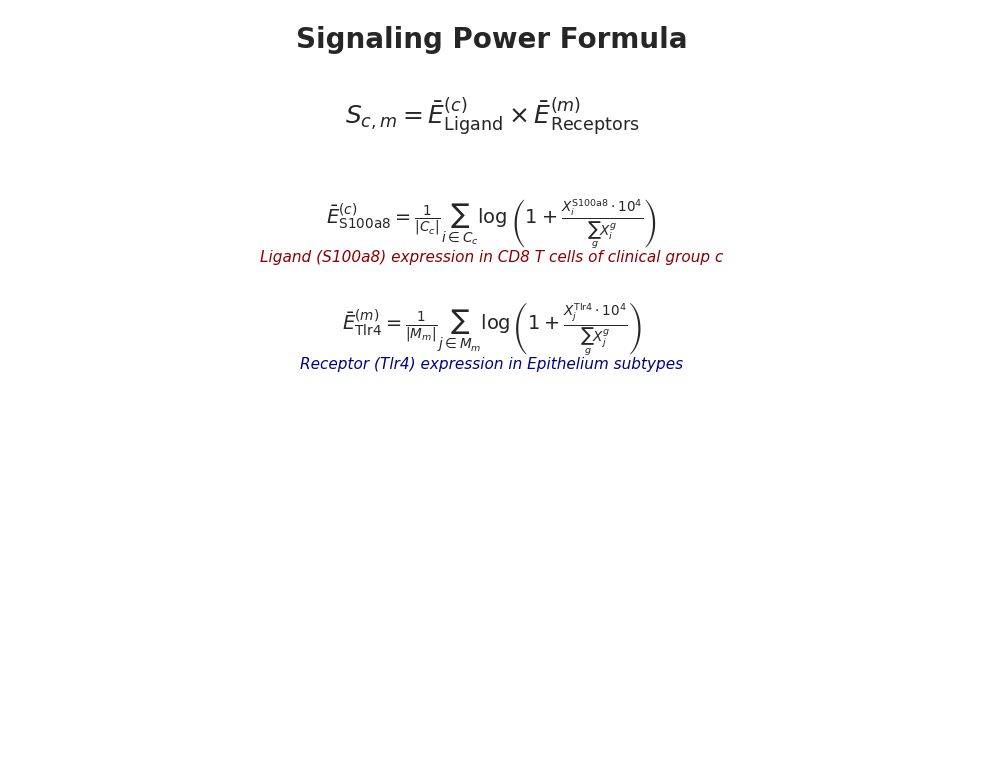

In [86]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

ax.text(5, 9.5, 'Signaling Power Formula', fontsize=20, fontweight='bold', ha='center')

ax.text(5, 8.5, r'$S_{c,m} = \bar{E}_{\text{Ligand}}^{(c)} \times \bar{E}_{\text{Receptors}}^{(m)}$',
        fontsize=18, ha='center')

y_pos = 7.2
ax.text(5, y_pos, r'$\bar{E}_{\text{S100a8}}^{(c)} = \frac{1}{|C_c|} \sum_{i \in C_c} \log\left(1 + \frac{X_i^{\text{S100a8}} \cdot 10^4}{\sum_g X_i^g}\right)$',
        fontsize=14, ha='center')
ax.text(5, y_pos-0.5, 'Ligand (S100a8) expression in CD8 T cells of clinical group c',
        fontsize=11, ha='center', style='italic', color='darkred')

y_pos = 5.8
ax.text(5, y_pos, r'$\bar{E}_{\text{Tlr4}}^{(m)} = \frac{1}{|M_m|} \sum_{j \in M_m} \log\left(1 + \frac{ X_j^{\text{Tlr4}} \cdot 10^4}{\sum_g X_j^g}\right)$',
        fontsize=14, ha='center')
ax.text(5, y_pos-0.5, 'Receptor (Tlr4) expression in Epithelium subtypes',
        fontsize=11, ha='center', style='italic', color='darkblue')

plt.tight_layout()
plt.show()

# Module to Cell

In [1]:
import pandas as pd
import scanpy as sc

In [2]:
file_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Epithelial_subtype_raw.h5ad"
adata = sc.read_h5ad(file_path)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=12000, batch_key="subtype")
adata = adata[:, adata.var['highly_variable']].copy()

In [3]:
adata = adata[adata.obs['subtype'] == 'Luminal Epithelium'].copy()

In [4]:
genes = ['Muc1', 'Muc4', 'Hbegf', 'Lif','Hif1a']
found_genes = [g for g in genes if g in adata.var_names]
missing_genes = [g for g in genes if g not in adata.var_names]

print("존재하는 유전자:", found_genes)
print("없는 유전자:", missing_genes)

존재하는 유전자: ['Muc1', 'Muc4', 'Hbegf', 'Lif', 'Hif1a']
없는 유전자: []


In [5]:
path_module1 = "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module1.txt"
path_module2 = "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module2.txt"
path_module3 = "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module3.txt"
path_module4= "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module4.txt"
path_module5 = "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module5.txt"
path_module6 = "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module6.txt"
path_module7 = "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module7.txt"
path_module8 = "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module8.txt"
path_module9 = "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module9.txt"
path_module10 = "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module10.txt"


module1 = pd.read_csv(path_module1, sep='\t', header=None)
module2 = pd.read_csv(path_module2, sep='\t', header=None)
module3 = pd.read_csv(path_module3, sep='\t', header=None)
module4 = pd.read_csv(path_module4, sep='\t', header=None)
module5 = pd.read_csv(path_module5, sep='\t', header=None)
module6 = pd.read_csv(path_module6, sep='\t', header=None)
module7 = pd.read_csv(path_module7, sep='\t', header=None)
module8 = pd.read_csv(path_module8, sep='\t', header=None)
module9 = pd.read_csv(path_module9, sep='\t', header=None)
module10 = pd.read_csv(path_module10, sep='\t', header=None)

In [6]:
########################################## 
############## Module score ############## 
########################################## 

In [7]:
import scanpy as sc
module1_genes = [g for g in module1[0].tolist() if g in adata.var_names]
module2_genes = [g for g in module2[0].tolist() if g in adata.var_names]
module3_genes = [g for g in module3[0].tolist() if g in adata.var_names]
module4_genes = [g for g in module4[0].tolist() if g in adata.var_names]
module5_genes = [g for g in module5[0].tolist() if g in adata.var_names]
module6_genes = [g for g in module6[0].tolist() if g in adata.var_names]
module7_genes = [g for g in module7[0].tolist() if g in adata.var_names]
module8_genes = [g for g in module8[0].tolist() if g in adata.var_names]
module9_genes = [g for g in module9[0].tolist() if g in adata.var_names]
module10_genes = [g for g in module10[0].tolist() if g in adata.var_names]

sc.tl.score_genes(adata, gene_list=module1_genes, score_name='module1_score')
sc.tl.score_genes(adata, gene_list=module2_genes, score_name='module2_score')
sc.tl.score_genes(adata, gene_list=module3_genes, score_name='module3_score')
sc.tl.score_genes(adata, gene_list=module4_genes, score_name='module4_score')
sc.tl.score_genes(adata, gene_list=module5_genes, score_name='module5_score')
sc.tl.score_genes(adata, gene_list=module6_genes, score_name='module6_score')
sc.tl.score_genes(adata, gene_list=module7_genes, score_name='module7_score')
sc.tl.score_genes(adata, gene_list=module8_genes, score_name='module8_score')
sc.tl.score_genes(adata, gene_list=module9_genes, score_name='module9_score')
sc.tl.score_genes(adata, gene_list=module10_genes, score_name='module10_score')

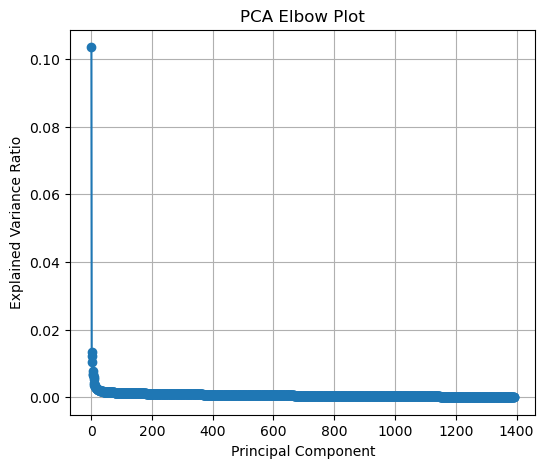

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

genes_to_use = module1_genes + module2_genes + module3_genes + module4_genes + module5_genes + module6_genes + module7_genes + module8_genes + module9_genes + module10_genes

X = adata[:, genes_to_use].X.toarray() if hasattr(adata[:, genes_to_use].X, "toarray") else adata[:, genes_to_use].X
X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

var = pca.explained_variance_ratio_

plt.figure(figsize=(6,5))
plt.plot(range(1, len(var)+1), var, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Elbow Plot")
plt.grid(True)
plt.show()

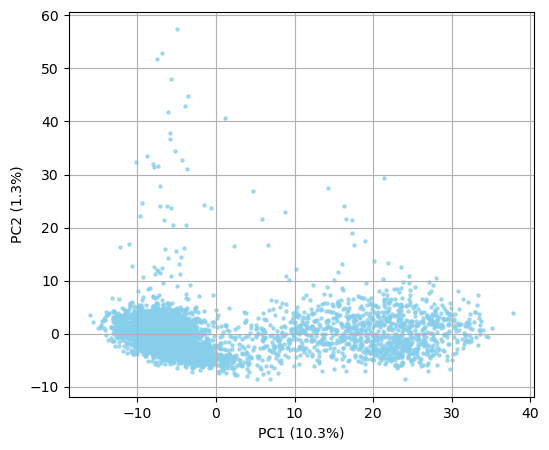

In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

genes_to_use = module1_genes + module2_genes + module3_genes + module4_genes + module5_genes + module6_genes + module7_genes + module8_genes + module9_genes + module10_genes

X = adata[:, genes_to_use].X.toarray() if hasattr(adata[:, genes_to_use].X, "toarray") else adata[:, genes_to_use].X
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

adata.obsm["X_pca_module2_7"] = X_pca

pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c='skyblue', s=5, alpha=0.7)

plt.xlabel(f'PC1 ({pc1_var:.1f}%)')
plt.ylabel(f'PC2 ({pc2_var:.1f}%)')

plt.grid(True)
plt.show()

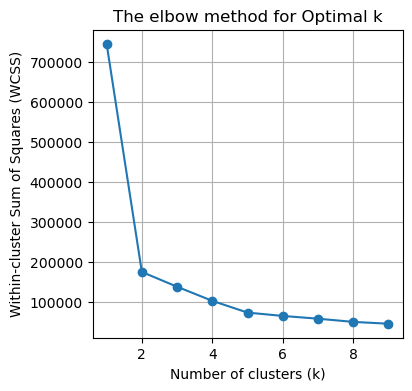

In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = adata.obsm["X_pca_module2_7"]

wcss = []
k_values = range(1, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(4,4))
plt.plot(k_values, wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-cluster Sum of Squares (WCSS)')
plt.title('The elbow method for Optimal k')
plt.grid(True)
plt.show()


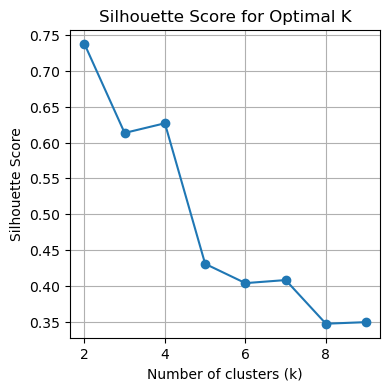

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X = adata.obsm["X_pca_module2_7"]

k_values = range(2, 10)
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

plt.figure(figsize=(4,4))
plt.plot(k_values, sil_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal K')
plt.grid(True)
plt.show()

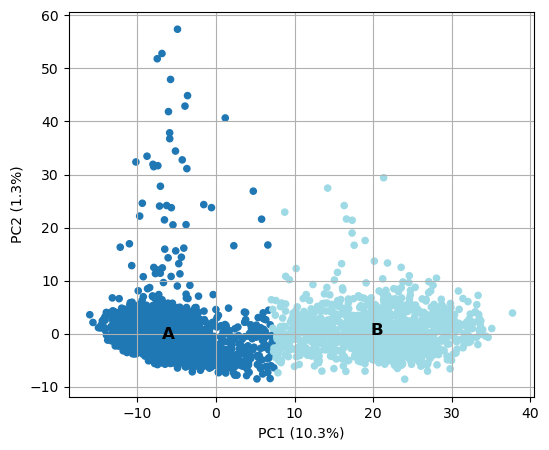

In [29]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

X = adata.obsm["X_pca_module2_7"]

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)

adata.obs["kmeans_cluster"] = clusters
adata.obs["kmeans_cluster"] = adata.obs["kmeans_cluster"].replace({0: "A", 1: "B"})

cat = pd.Categorical(adata.obs["kmeans_cluster"], categories=["A", "B"])
color_codes = cat.codes

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=color_codes, s=20, cmap="tab20")

centroids = kmeans.cluster_centers_
label_map = {0: "A", 1: "B"}

for i, (x, y) in enumerate(centroids):
    plt.text(x, y, label_map[i], fontsize=12, fontweight="bold",
             ha="center", va="center", color="black")

plt.xlabel("PC1 (10.3%)")
plt.ylabel("PC2 (1.3%)")
plt.grid(True)
plt.show()

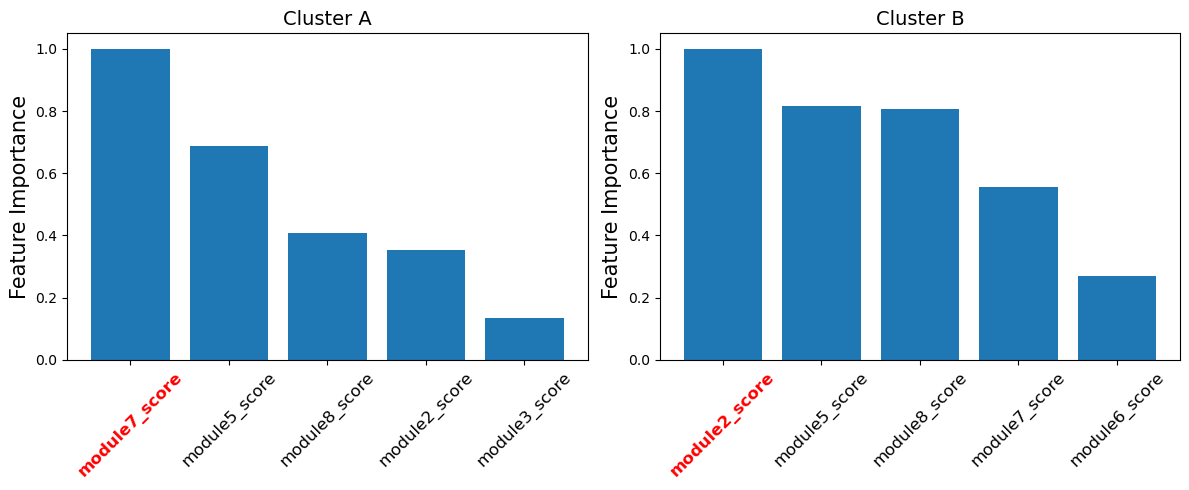

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

features = ['module1_score','module2_score','module3_score','module4_score',
            'module5_score','module6_score','module7_score','module8_score','module10_score']

X_features = adata.obs[features].values
y = adata.obs['kmeans_cluster'].values

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_features, y)

proba = clf.predict_proba(X_features)
class_labels = clf.classes_

adata.obs[[f'prob_{c}' for c in class_labels]] = proba

top_n = 5
scaler = MinMaxScaler()

fig, axes = plt.subplots(1, len(class_labels), figsize=(12,5))

if len(class_labels) == 1:
    axes = [axes]

for idx, cluster_label in enumerate(class_labels):

    mean_proba = proba[:, idx]
    avg_per_module = X_features.T * mean_proba
    avg_per_module = avg_per_module.mean(axis=1).reshape(-1,1)
    avg_per_module_scaled = scaler.fit_transform(avg_per_module).flatten()

    df = pd.DataFrame({'module': features, 'score': avg_per_module_scaled})
    df = df.sort_values(by='score', ascending=False).head(top_n)

    bars = axes[idx].bar(df['module'], df['score'])
    axes[idx].set_title(f'Cluster {cluster_label}', fontsize=14)
    axes[idx].set_ylabel('Feature Importance', fontsize=15)
    axes[idx].tick_params(axis='x', labelsize=12, rotation=45)

    top_module = df.iloc[0]['module']
    for label in axes[idx].get_xticklabels():
        if label.get_text() == top_module:
            label.set_color('red')
            label.set_fontweight('bold')

plt.tight_layout()
plt.show()

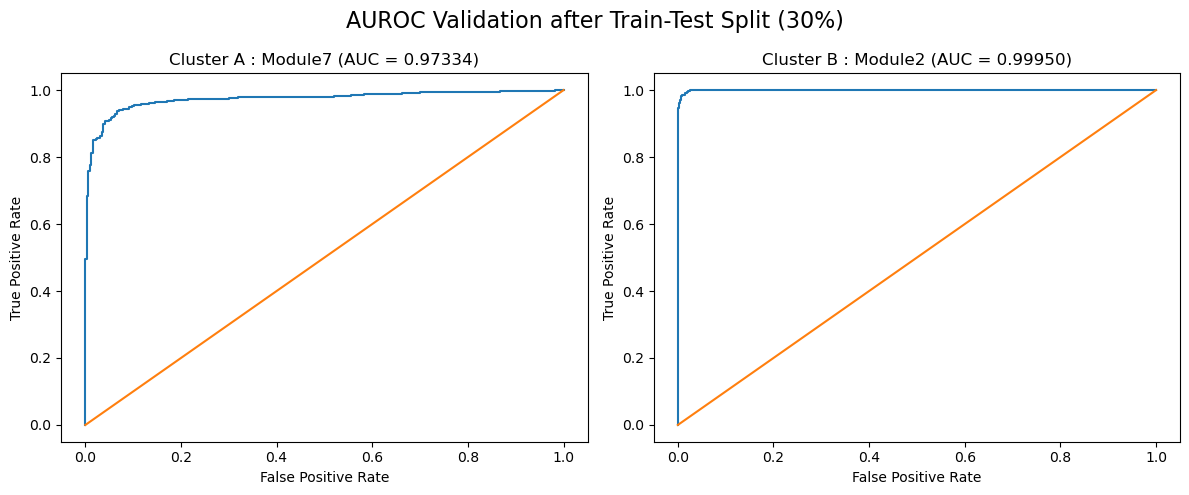

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

X = adata.obs[['module2_score','module7_score']].values
y = adata.obs['kmeans_cluster'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

module2_test = X_test[:, 0]
module7_test = X_test[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

y_true_A = (y_test == 'A').astype(int)
fprA, tprA, _ = roc_curve(y_true_A, module7_test)
aucA = roc_auc_score(y_true_A, module7_test)

axes[0].plot(fprA, tprA)
axes[0].plot([0,1],[0,1])
axes[0].set_title(f'Cluster A : Module7 (AUC = {aucA:.5f})')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')

y_true_B = (y_test == 'B').astype(int)
fprB, tprB, _ = roc_curve(y_true_B, module2_test)
aucB = roc_auc_score(y_true_B, module2_test)

axes[1].plot(fprB, tprB)
axes[1].plot([0,1],[0,1])
axes[1].set_title(f'Cluster B : Module2 (AUC = {aucB:.5f})')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')

fig.suptitle('AUROC Validation after Train-Test Split (30%)', fontsize=16)
plt.tight_layout()
plt.show()

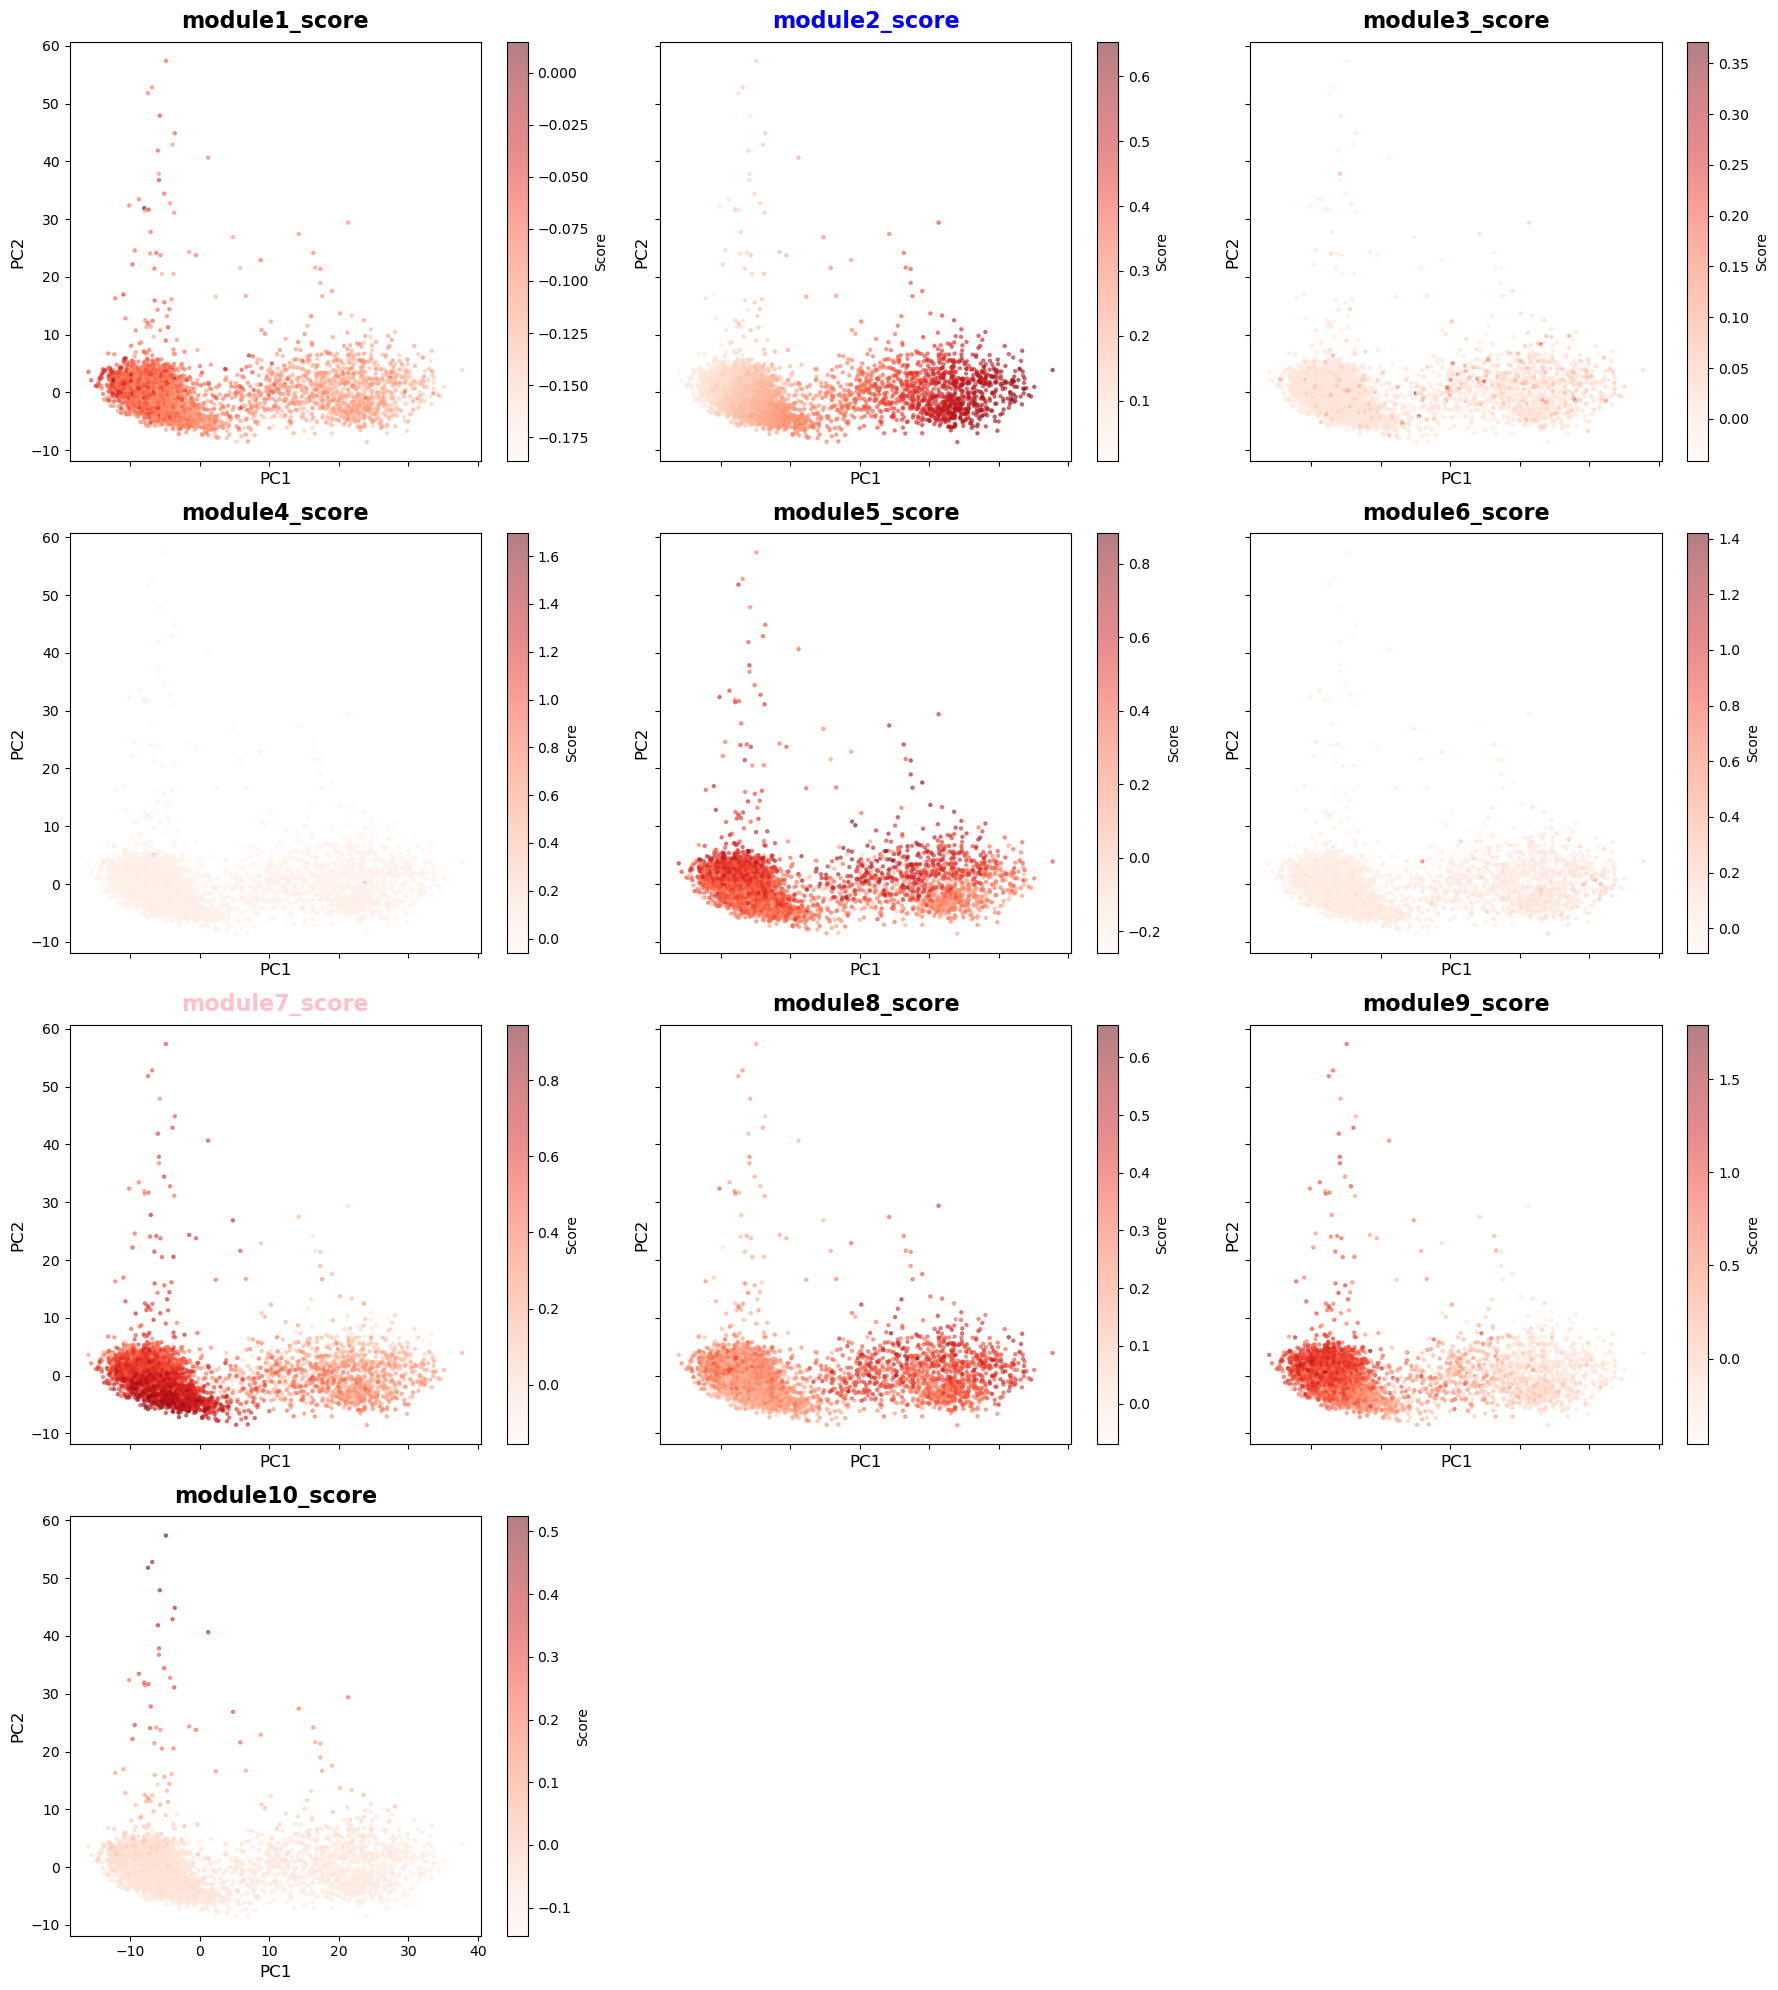

In [25]:
import matplotlib.pyplot as plt
import numpy as np

X_pca = X_pca
scores = ['module1_score', 'module2_score','module3_score', 'module4_score',
          'module5_score', 'module6_score','module7_score', 'module8_score',
          'module9_score', 'module10_score']
cmaps = ['Reds'] * len(scores)
title_colors = {
    'module1_score': 'black',
    'module2_score': 'blue',
    'module3_score': 'black',
    'module4_score': 'black',
    'module5_score': 'black',
    'module6_score': 'black',
    'module7_score': 'pink',
    'module8_score': 'black',
    'module9_score': 'black',
    'module10_score': 'black'
}

n_cols = 3
n_rows = int(np.ceil(len(scores) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, score in enumerate(scores):
    sc = axes[i].scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=adata.obs[score],
        cmap=cmaps[i],
        s=5,
        alpha=0.5
    )
    axes[i].set_title(score, color=title_colors[score], fontsize=16, fontweight='heavy', pad=10)
    axes[i].set_xlabel('PC1', fontsize=12)
    axes[i].set_ylabel('PC2', fontsize=12)
    plt.colorbar(sc, ax=axes[i], label='Score')

for j in range(len(scores), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

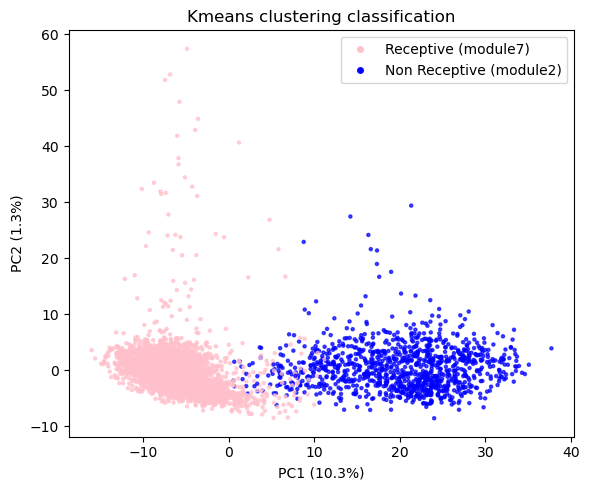

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

module_scores = adata.obs[["module2_score", "module7_score"]].values
module_scores_scaled = StandardScaler().fit_transform(module_scores)

kmeans = KMeans(n_clusters=3, n_init=10, random_state=0)
labels = kmeans.fit_predict(module_scores_scaled)

df = adata.obs[["module2_score", "module7_score"]].copy()
df['cluster'] = labels

cluster_names = {}
for c in np.unique(labels):
    cluster_mean = df[df['cluster']==c][["module2_score","module7_score"]].mean()
    dominant = cluster_mean.idxmax().replace("_score","")
    if dominant == "module7":
        cluster_names[c] = "A"
    elif dominant == "module2":
        cluster_names[c] = "B"
    else:
        cluster_names[c] = "Other"

adata.obs['module_cluster'] = [cluster_names[l] for l in labels]

colors_map = {"A": "pink", "B": "blue"}
colors = adata.obs['module_cluster'].map(colors_map)

pc1_var = 10.3
pc2_var = 1.3

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=colors, s=5, alpha=0.7)

plt.xlabel(f"PC1 ({pc1_var}%)")
plt.ylabel(f"PC2 ({pc2_var}%)")
plt.title("Kmeans clustering classification")

legend_elements = [
    Line2D([0],[0], marker='o', color='w', label='Receptive (module7)', markerfacecolor='pink', markersize=6),
    Line2D([0],[0], marker='o', color='w', label='Non Receptive (module2)', markerfacecolor='blue', markersize=6)
]

plt.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

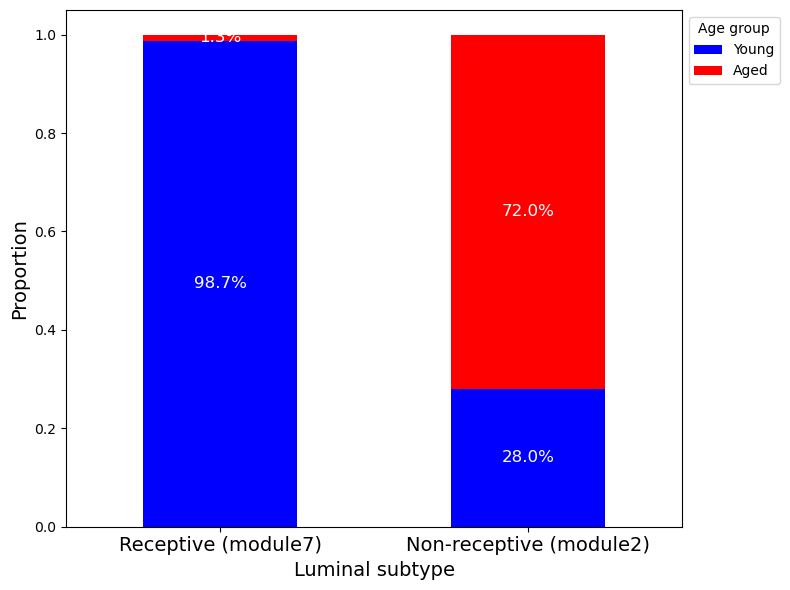

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

adata.obs["age_num"] = adata.obs["age"].str.extract(r"(\d+)").astype(int)
adata.obs["age_group"] = np.where(adata.obs["age_num"] > 70, "Aged", "Young")

ct = pd.crosstab(adata.obs["module_cluster"], adata.obs["age_group"])
ct_prop = ct.div(ct.sum(axis=1), axis=0)

ct_prop = ct_prop.loc[["A", "B"], ["Young", "Aged"]]
ct_prop.index = ["Receptive (module7)", "Non-receptive (module2)"]

color_dict = {"Young": "blue", "Aged": "red"}

ax = ct_prop.plot(
    kind="bar",
    stacked=True,
    rot=0,
    color=[color_dict[c] for c in ct_prop.columns],
    figsize=(8, 6)
)

ax.set_xlabel("Luminal subtype", fontsize=14)
ax.set_ylabel("Proportion", fontsize=14)
ax.tick_params(axis="x", labelsize=14)
ax.legend(title="Age group", bbox_to_anchor=(1, 1))

for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x = p.get_x() + width / 2
    y = p.get_y() + height / 2
    percent = height * 100
    ax.text(x, y, f"{percent:.1f}%", ha="center", va="center", fontsize=12, color="white")

plt.tight_layout()
plt.show()

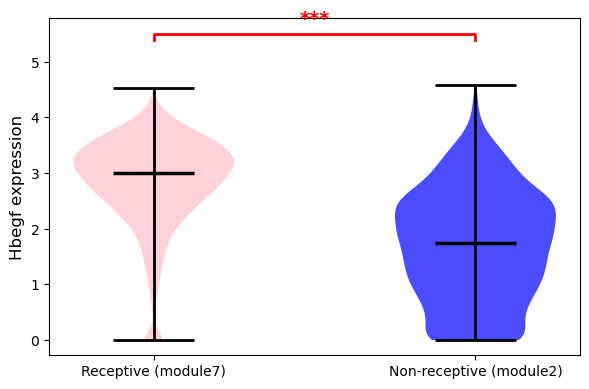

In [303]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ranksums

gene = "Hbegf"

df = adata.obs.copy()
df[gene] = adata[:, gene].X.toarray().flatten() if hasattr(adata[:, gene].X, "toarray") else adata[:, gene].X.flatten()

group1 = df[df["module_cluster"] == "A"][gene]
group2 = df[df["module_cluster"] == "B"][gene]

stat, p = ranksums(group1, group2)

if p < 0.001:
    stars = "***"
elif p < 0.01:
    stars = "**"
elif p < 0.05:
    stars = "*"
else:
    stars = "ns"

color_dict = {"A": "pink", "B": "blue"}

fig, ax = plt.subplots(figsize=(6,4))

parts = ax.violinplot(
    [group1, group2],
    positions=[0,1],
    showmeans=False,
    showmedians=True,
    showextrema=True
)

for pc, c in zip(parts["bodies"], [color_dict["A"], color_dict["B"]]):
    pc.set_facecolor(c)
    pc.set_alpha(0.7)

parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(2.5)

parts["cmins"].set_color("black")
parts["cmins"].set_linewidth(2)

parts["cmaxes"].set_color("black")
parts["cmaxes"].set_linewidth(2)

parts["cbars"].set_color("black")
parts["cbars"].set_linewidth(2)

ax.set_xticks([0,1])
ax.set_xticklabels(["Receptive (module7)","Non-receptive (module2)"])
ax.set_ylabel("Hbegf expression", fontsize=12)

y_max = max(df[gene])
y_bracket = y_max * 1.2

ax.plot([0,0,1,1], 
        [y_bracket*0.98,y_bracket,y_bracket,y_bracket*0.98], 
        color="red", 
        linewidth=2)

ax.text(0.5, y_bracket*1.03, stars, 
        ha="center", 
        color="red", 
        fontsize=14, 
        fontweight="bold")

plt.tight_layout()
plt.show()

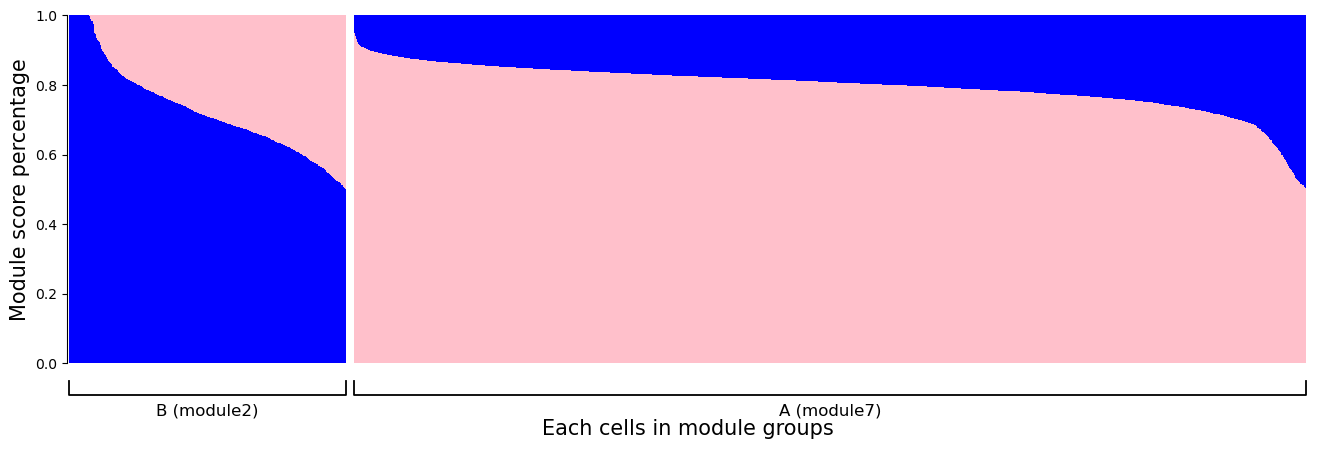

In [272]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

modules = ['module2', 'module7']
score_cols = [f'{m}_score' for m in modules]

label_map = {'module7': 'A', 'module2': 'B'}
display_map = {'module7': 'A (module7)', 'module2': 'B (module2)'}
color_dict = {'module7': 'pink', 'module2': 'blue'}

df = adata.obs[score_cols].copy()
prop = df.div(df.sum(axis=1), axis=0)
top_module = df.idxmax(axis=1).str.replace('_score','')

gap = 30
ordered_idx = []
group_bounds = {}
x_positions = []
current_x = 0

for m in modules:
    idx = top_module[top_module == m].index
    sub = prop.loc[idx].sort_values(by=f'{m}_score', ascending=False)
    ordered_idx.extend(sub.index)
    start_pos = current_x
    for _ in range(len(sub)):
        x_positions.append(current_x)
        current_x += 1
    end_pos = current_x
    group_bounds[m] = (start_pos, end_pos)
    current_x += gap

prop_ordered = prop.loc[ordered_idx]
top_order = top_module.loc[ordered_idx]

plt.figure(figsize=(16,6))

for i, cell in enumerate(ordered_idx):
    m = top_order[cell]
    order = [f'{m}_score'] + [f'{x}_score' for x in modules if x != m]
    b = 0
    for c in order:
        mod_name = c.replace('_score','')
        h = prop_ordered.loc[cell, c]
        plt.bar(x_positions[i], h, bottom=b,
                color=color_dict[mod_name], width=1)
        b += h

plt.ylim(0, 1)
plt.xlim(-5, max(x_positions) + 5)
plt.xticks([])
plt.ylabel('Module score percentage', fontsize=15)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.xlabel('Each cells in module groups', labelpad=40, fontsize=15)

for m in modules:
    start, end = group_bounds[m]
    start_adj = start
    end_adj = end - 1
    mid = (start_adj + end_adj) / 2
    y = -0.05
    h = 0.04
    plt.plot([start_adj, start_adj, end_adj, end_adj],
             [y, y - h, y - h, y],
             color='black', lw=1.3, clip_on=False)
    plt.text(mid, y - h - 0.025,
             display_map[m],
             ha='center', va='top', fontsize=12)

plt.subplots_adjust(bottom=0.3)
plt.show()

/tmp/ipykernel_1128955/3156230998.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/tmp/ipykernel_1128955/3156230998.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


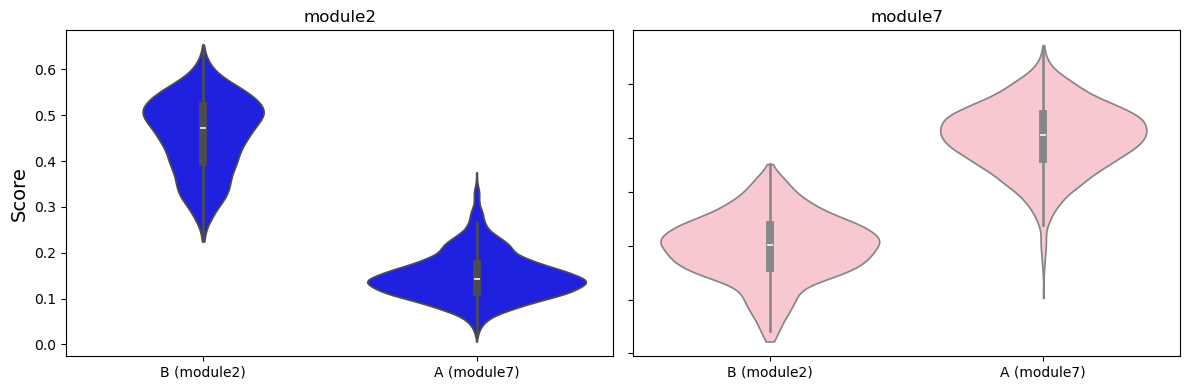

In [273]:
import seaborn as sns
import matplotlib.pyplot as plt

modules = ['module2_score', 'module7_score']

color_dict = {"module2": "blue", "module7": "pink"}
xtick_map = {"A": "A (module7)", "B": "B (module2)"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for i, (ax, m) in enumerate(zip(axes, modules)):
    module_name = m.replace('_score', '')
    
    sns.violinplot(
        data=adata.obs,
        x='module_cluster',
        y=m,
        inner='box',
        cut=0,
        color=color_dict[module_name],
        ax=ax
    )

    ax.set_title(module_name)
    ax.set_xlabel('')
    
    labels = [xtick_map[t.get_text()] for t in ax.get_xticklabels()]
    ax.set_xticklabels(labels)
    
    if i == 0:
        ax.set_ylabel('Score', fontsize=14)
    else:
        ax.set_ylabel('')
        ax.tick_params(labelleft=False)

plt.tight_layout()
plt.show()

In [274]:
adata.obs[['module_cluster']].to_csv('/home/Data_Drive_8TB/kykim/1. Oval/Nichenet/module_metadata.csv', index=True)
adata.X = adata.layers["counts"]
adata.write("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/modeling_luminal.h5ad")
adata.obs.to_csv("/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module_to_cell_metadata.csv")

df = pd.DataFrame(adata.obsm["X_pca_module2_7"], index=adata.obs_names, columns=["PC1", "PC2"])
df.to_csv("/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/pca_coordinate_metadata.csv")

In [ ]:
########## DEG

In [317]:
import scanpy as sc

file_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Epithelial_subtype_raw.h5ad"
adata = sc.read_h5ad(file_path)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=12000, batch_key="subtype")
adata = adata[:, adata.var['highly_variable']].copy()

In [318]:
import pandas as pd

df = pd.read_csv("/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module_to_cell_metadata.csv", index_col=0)
common_idx = adata.obs.index.intersection(df.index)

adata.obs["module_cluster"] = pd.NA
adata.obs.loc[common_idx, "module_cluster"] = df.loc[common_idx, "module_cluster"]
adata.obs["module_cluster"] = adata.obs["module_cluster"].fillna(adata.obs["subtype"])

In [319]:
import pandas as pd

df = pd.read_csv("/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module_to_cell_metadata.csv", index_col=0)
common_idx = adata.obs.index.intersection(df.index)
adata.obs["module_cluster"] = adata.obs["module_cluster"].astype(str)
adata.obs["subtype"] = adata.obs["subtype"].astype(str)
mask = adata.obs.loc[common_idx, "subtype"] == df.loc[common_idx, "subtype"]
adata.obs.loc[common_idx[mask], "module_cluster"] = df.loc[common_idx[mask], "module_cluster"]
adata.obs["module_cluster"] = adata.obs["module_cluster"].replace("nan", pd.NA)
adata.obs["module_cluster"] = adata.obs["module_cluster"].fillna(adata.obs["subtype"])

In [323]:
adata.obs['module_cluster'] = (
    adata.obs['module_cluster']
    .replace({
        'B': 'Non-receptive (module2)',
        'A': 'Receptive (module7)'
    }))

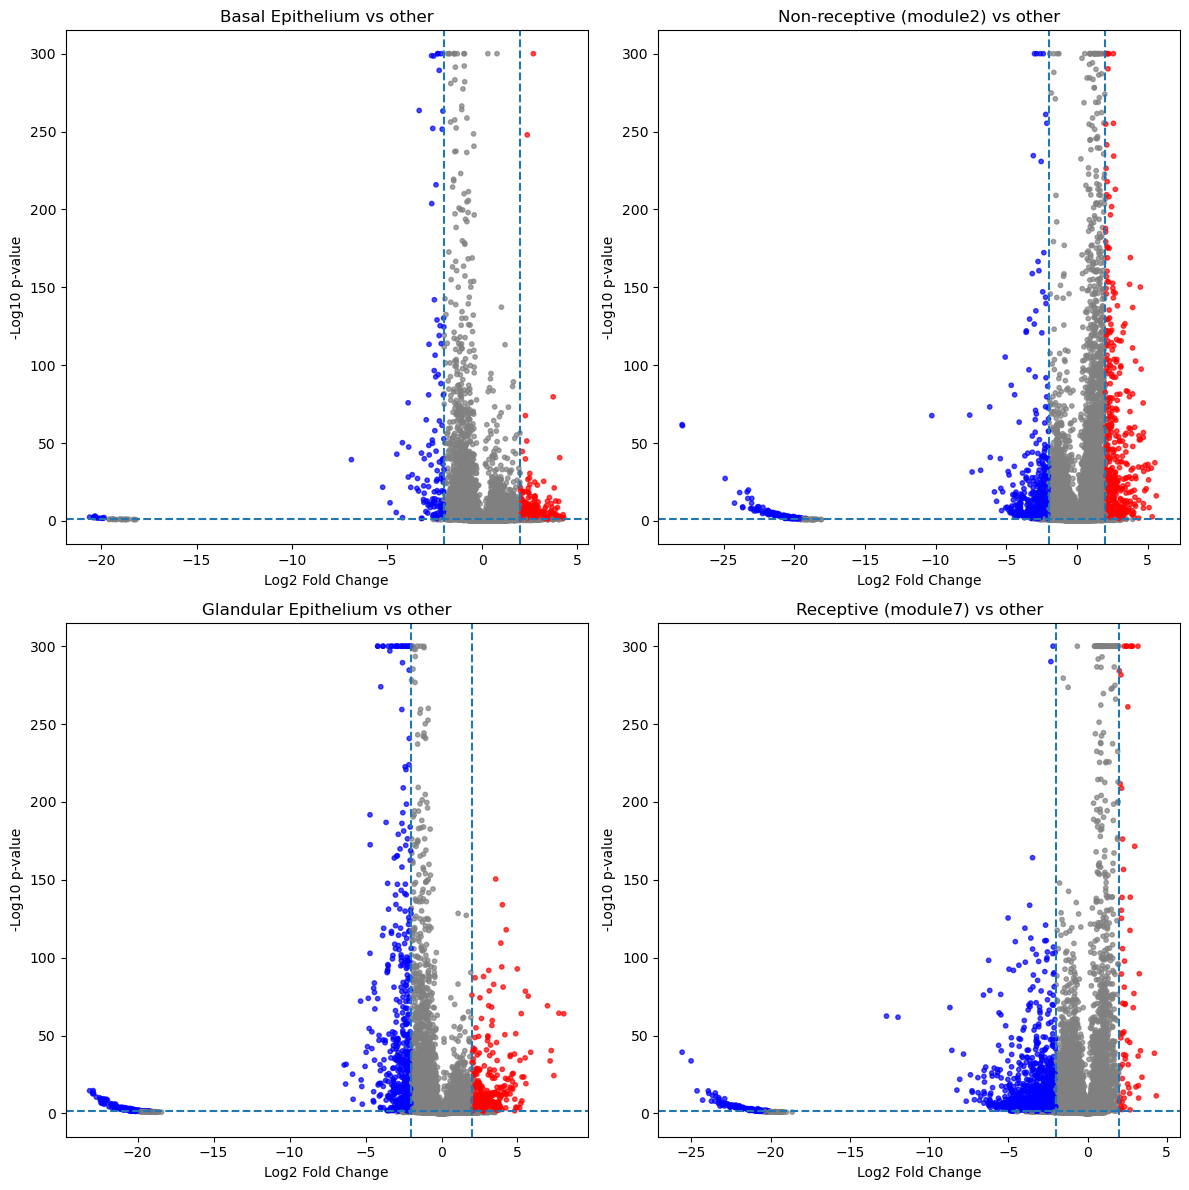

In [325]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

clusters = adata.obs['module_cluster'].unique()[:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, target_cluster in zip(axes, clusters):
    adata_target = adata[adata.obs['module_cluster'] == target_cluster]
    adata_other = adata[adata.obs['module_cluster'] != target_cluster]

    X_target = adata_target.X.toarray() if hasattr(adata_target.X, "toarray") else adata_target.X
    X_other = adata_other.X.toarray() if hasattr(adata_other.X, "toarray") else adata_other.X

    mean_target = X_target.mean(axis=0)
    mean_other = X_other.mean(axis=0)

    lfc = np.log2(mean_target + 1e-9) - np.log2(mean_other + 1e-9)

    pvals = np.array([
        ttest_ind(X_target[:, i], X_other[:, i], equal_var=False).pvalue
        for i in range(adata.n_vars)
    ])

    neglog10_pval = -np.log10(pvals + 1e-300)

    colors = np.full(adata.n_vars, "grey", dtype=object)
    colors[(lfc > 2) & (pvals < 0.05)] = "red"
    colors[(lfc < -2) & (pvals < 0.05)] = "blue"

    ax.scatter(lfc, neglog10_pval, c=colors, alpha=0.7, s=10)
    ax.axhline(-np.log10(0.05), linestyle="--")
    ax.axvline(2, linestyle="--")
    ax.axvline(-2, linestyle="--")
    ax.set_title(f"{target_cluster} vs other")
    ax.set_xlabel("Log2 Fold Change")
    ax.set_ylabel("-Log10 p-value")

for ax in axes[len(clusters):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [326]:
import scanpy as sc
sc.tl.rank_genes_groups(adata, 'module_cluster', method="wilcoxon",use_raw =False)
sc.tl.dendrogram(adata, groupby='module_cluster')
result = adata.uns["rank_genes_groups"]
groups = result["names"].dtype.names
result_df = pd.DataFrame(
    {
        f"{group}_{key}": result[key][group]
        for group in groups
        for key in ["names", "pvals_adj", "logfoldchanges", "scores"]
    }
)

up_dict = {}
down_dict = {}

for group in groups:
    n_col = f"{group}_names"
    p_col = f"{group}_pvals_adj"
    l_col = f"{group}_logfoldchanges"
    s_col = f"{group}_scores"
    degs_sig = result_df[result_df[p_col] < 0.05]
    degs_up = degs_sig[degs_sig[l_col] > 1].sort_values(by=s_col, ascending=False)
    degs_dw = degs_sig[degs_sig[l_col] < -1].sort_values(by=s_col, ascending=True)
    up_dict[group] = degs_up[n_col].reset_index(drop=True)
    down_dict[group] = degs_dw[n_col].reset_index(drop=True)

df_merge_up = pd.concat(up_dict.values(), axis=1)
df_merge_up.columns = list(up_dict.keys())

df_merge_down = pd.concat(down_dict.values(), axis=1)
df_merge_down.columns = list(down_dict.keys())
sc.tl.dendrogram(adata, groupby='module_cluster')
result = adata.uns["rank_genes_groups"]
groups = result["names"].dtype.names
result_df = pd.DataFrame(
    {
        f"{group}_{key}": result[key][group]
        for group in groups
        for key in ["names", "pvals_adj", "logfoldchanges", "scores"]
    }
)

up_dict = {}
down_dict = {}

for group in groups:
    n_col = f"{group}_names"
    p_col = f"{group}_pvals_adj"
    l_col = f"{group}_logfoldchanges"
    s_col = f"{group}_scores"
    degs_sig = result_df[result_df[p_col] < 0.05]
    degs_up = degs_sig[degs_sig[l_col] > 1].sort_values(by=s_col, ascending=False)
    degs_dw = degs_sig[degs_sig[l_col] < -1].sort_values(by=s_col, ascending=True)
    up_dict[group] = degs_up[n_col].reset_index(drop=True)
    down_dict[group] = degs_dw[n_col].reset_index(drop=True)

df_merge_up = pd.concat(up_dict.values(), axis=1)
df_merge_up.columns = list(up_dict.keys())

df_merge_down = pd.concat(down_dict.values(), axis=1)
df_merge_down.columns = list(down_dict.keys())

from qed.data import readtxt, readseurat, readscanpy
from qed.data import get_enrichment_dataframes
from qed.data import merge_df
from qed.data import query
import inspect

class GeneSet:
    def __init__(self, genes, name, annot=None):
        self.genes = genes
        self.name = name
        self.params = {}
        self.GO = []
        self.annot = annot or {}
dblist = [
    'KEGG_2021_Human',
    'Reactome_2022', 'Mouse_Gene_Atlas',
    'MSigDB_Hallmark_2020',
    'GO_Biological_Process_2023',
    'WikiPathway_2024_Human','WikiPathways_2024_Mouse','KEGG_2019_Mouse']

df_merge_up_100 = df_merge_up.head(20)
df_merge_up_100.to_csv('breast_cancer_DEG_up_leiden.csv', index=False, header=True)
alist = pd.read_csv('breast_cancer_DEG_up_leiden.csv')
geneset_list = []
for col in alist.columns:
    genes = alist[col].dropna().tolist()
    gs = GeneSet(genes=genes, name=col, annot={"Leiden": col})
    geneset_list.append(gs)
aalist = get_enrichment_dataframes(
    geneset_list=geneset_list,
    dblist=dblist,
    annot_colname="Leiden",
    n_jobs=None,
    handle_error=True,
    max_iter=1
)
df = merge_df(aalist)
df['Term'] = df['Term'].str.split(r'\(GO:').str[0].str.strip()
df['Term'] = df['Term'].str.split('R-H').str[0].str.strip()
df['Term'] = df['Term'].str.split('WP').str[0].str.strip()

from typing import List, Tuple, Dict
def heatmap_with_groupwise_ordering(df: pd.DataFrame,
                                     n: int,
                                     group_by: str,
                                     order_by: str = "Adjusted p-value",
                                     cmap: str = 'Blues',
                                     xlabel_rotation: int = 90,
                                     xlabel_fontsize: int = 15,
                                     ylabel_fontsize: int = 15,
                                     figsize: Tuple = (15, 10),
                                     vmin: float = None,
                                     vmax: float = None,
                                     cbar_kws: Dict = None,
                                     linewidths: float = 0.1,
                                     title: str = None,
                                     save_to_file: str = None,
                                     enable_column_order: bool = False,
                                     column_order: list = None,
                                     enable_highlight_columns: bool = False,
                                     highlight_column_names: list = None):

    if not isinstance(df, pd.DataFrame):
        raise TypeError("입력 'df'는 pandas DataFrame이어야 합니다.")
    if group_by not in df.columns:
        raise ValueError(f"'{group_by}' 컬럼이 DataFrame에 존재하지 않습니다.")
    if order_by not in df.columns:
        raise ValueError(f"'{order_by}' 컬럼이 DataFrame에 존재하지 않습니다.")
    if 'Term' not in df.columns:
        raise ValueError("'Term' 컬럼이 DataFrame에 존재하지 않습니다.")

    has_overlapping_genes = 'Overlapping genes' in df.columns
    df_copy = df.copy()
    df_copy[order_by] = pd.to_numeric(df_copy[order_by], errors='coerce')
    df = df_copy

    df['Term_lower'] = df['Term'].str.lower()

    df_filtered_by_order = df[df[order_by].notna()]
    df_ranked_per_group = (
        df_filtered_by_order
        .sort_values(order_by)
        .groupby(group_by)
        .head(n)
        .reset_index(drop=True)
    )
    if df_ranked_per_group.empty:
        print(f"⚠️ 각 그룹에서 상위 {n}개의 Term을 선택할 수 없습니다.")
        return None, None

    all_selected_terms_lower = df_ranked_per_group['Term_lower'].unique()
    overlapping_genes_pivot = pd.DataFrame()
    if has_overlapping_genes:
        overlapping_genes_df = df[df['Term_lower'].isin(all_selected_terms_lower)][['Term_lower', group_by, 'Overlapping genes']]
        overlapping_genes_df['Overlapping genes'] = overlapping_genes_df['Overlapping genes'].apply(
            lambda x: ', '.join(map(str, x)) if isinstance(x, list) else str(x)
        )
        overlapping_genes_df = overlapping_genes_df.groupby(['Term_lower', group_by])['Overlapping genes'].apply(', '.join).reset_index()
        overlapping_genes_df.rename(columns={'Term_lower': 'Term'}, inplace=True)
        overlapping_genes_pivot = overlapping_genes_df.pivot(index='Term', columns=group_by, values='Overlapping genes').fillna('')
        overlapping_genes_pivot.index = overlapping_genes_pivot.index.map(lambda x: x.capitalize())
    aggregated_df = df[df['Term_lower'].isin(all_selected_terms_lower)].groupby(['Term_lower', group_by], as_index=False)[order_by].min()
    aggregated_df.rename(columns={'Term_lower': 'Term'}, inplace=True)
    pivot_df = aggregated_df.pivot(index="Term", columns=group_by, values=order_by).fillna(1).rename_axis(None, axis=1)
    is_pvalue_column = order_by.lower() in ['adjusted p-value', 'p-value']
    pivot_df_for_heatmap = -np.log10(np.maximum(pivot_df, np.finfo(float).eps)) if is_pvalue_column else pivot_df.copy()
    pivot_df_for_heatmap.index = pivot_df_for_heatmap.index.map(lambda x: x.capitalize())
    final_pivot_df = pd.concat([pivot_df_for_heatmap, overlapping_genes_pivot], axis=1)

    if save_to_file:
        try:
            final_pivot_df.to_csv(save_to_file, encoding='utf-8-sig')
            print(f"✅ 히트맵 데이터 저장 완료: '{save_to_file}'")
        except Exception as e:
            print(f"❌ 저장 실패: {e}")

    row_order = []
    seen_terms = set()

    if enable_column_order and column_order:
        group_order_for_plot = [group for group in column_order if group in df[group_by].unique()]
    else:
        group_order_for_plot = df[group_by].unique()

    for group in group_order_for_plot:
        current_group_terms = df_ranked_per_group[df_ranked_per_group[group_by] == group].sort_values(order_by)
        for term_lower_val in current_group_terms['Term_lower']:
            capitalized_term = term_lower_val.capitalize()
            if capitalized_term in pivot_df_for_heatmap.index and capitalized_term not in seen_terms:
                row_order.append(capitalized_term)
                seen_terms.add(capitalized_term)

    clustered_data = final_pivot_df.loc[row_order]
    heatmap_data = clustered_data.select_dtypes(include=[np.number]) 
    if enable_column_order and column_order:
        valid_cols = [c for c in column_order if c in heatmap_data.columns]
        if valid_cols:
            heatmap_data = heatmap_data[valid_cols]
    else:
        try:
        # 모든 열 이름을 float으로 바꿔 보고 성공하면 오름차순 재정렬
            numeric_col_keys = [float(c) for c in heatmap_data.columns]
            sorted_cols = [col for _, col in sorted(zip(numeric_col_keys, heatmap_data.columns))]
            heatmap_data = heatmap_data[sorted_cols]
        except ValueError:
            pass

    if is_pvalue_column:
        p_values_for_annotation = 10 ** (-np.clip(heatmap_data, None, 300))
        annotations = np.where(p_values_for_annotation <= 0.05, '*', '')
        annotations = annotations.astype(object)
    else:
        annotations = False

    highlight_column_indices = []
    if enable_highlight_columns and highlight_column_names:
        highlight_column_indices = [
            list(heatmap_data.columns).index(col)
            for col in highlight_column_names if col in heatmap_data.columns
        ]

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(heatmap_data, cmap=cmap, vmin=vmin, vmax=vmax,
                linewidths=linewidths, annot=annotations, fmt='',
                linecolor='white', ax=ax, cbar_kws=cbar_kws, square=True,
                annot_kws={"size": 12, "color": "white", "weight": "bold"})

    for x in highlight_column_indices:
        ax.vlines(x + 1, *ax.get_ylim(), colors='black', linewidth=2)

    plt.xticks(rotation=xlabel_rotation, fontsize=xlabel_fontsize)
    plt.yticks(fontsize=ylabel_fontsize)
    if title:
        ax.set_title(title, fontsize=18, pad=20)
    plt.grid(False)

    if 'Term_lower' in df.columns:
        df.drop(columns='Term_lower', inplace=True)

    return fig, ax

/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 12000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(
Processing genesets: 16it [00:01, 14.33it/s]                      

Error processing Non-receptive (module2) for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
Error processing Basal Epithelium for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
Error processing Receptive (module7) for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
Error processing Glandular Epithelium for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
Status code: 400
Response content: b'<!DOCTYPE html>\n<html lang="en">\n<head>\n\t<title>Enrichr</title>\n\t<meta http-equiv="Content-Type" content="text/html;charset=UTF-8">\n\t<meta name="author" content="Edward Y. Chen"/>\n\t<meta name="viewport" content="width=750">\n\t<link rel="shortcut icon" type="image/x-icon" href="favicon.ico"/>\n\t<link rel="icon" type="image/ico" href="favicon.ico"/>\n\t<link rel="stylesheet" type="text/css" href="css/reset-min.css"/>\n\t<link href=\'https://fonts.googleapis.com/css?family=Droid+Sans\' rel=\'stylesheet\' type=\'text/css\'/>\n\t<link rel="stylesheet" type="text/css" href="css/common.css

Processing genesets: 32it [00:01, 17.25it/s]


Trying to re-request...
Basal Epithelium with MSigDB_Hallmark_2020 completed!
Error processing Basal Epithelium for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
Basal Epithelium with WikiPathway_2024_Human completed!
Error processing Glandular Epithelium for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
Glandular Epithelium with WikiPathway_2024_Human completed!
Error processing Non-receptive (module2) for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
Non-receptive (module2) with WikiPathway_2024_Human completed!
Receptive (module7) with Reactome_2022 completed!
Error processing Receptive (module7) for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
Receptive (module7) with WikiPathway_2024_Human completed!


In [327]:
import pandas as pd

df.to_csv("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/df_sc.csv", index=False)

In [331]:
import pandas as pd

dict_leiden = {
    "Basal Epithelium": [
        "Positive Regulation Of Mitotic Cell Cycle",
        "Positive Regulation Of RNA Splicing",
        "Regulation Of Telomere Maintenance",
        "Positive Regulation Of Hormone Metabolic Process",
        "Regulation Of Steroid Biosynthetic Process",
        "Regulation Of Stem Cell Differentiation"
    ],
    "Glandular Epithelium": [
        "Estrogen Metabolism",
        "Prostaglandin Metabolic Process",
        "Positive Regulation Of Epidermal Growth Factor Receptor Signaling Pathway",
        "Regulation Of Developmental Growth",
        "Ovarian steroidogenesis",
        "Synthesis, Secretion, And Deacylation Of Ghrelin",
        "Regulation Of Epidermal Growth Factor Receptor Signaling Pathway",
        "Positive Regulation Of TOR Signaling"
    ],
    "Non-receptive (module2)": [
        "KRAS Signaling Up",
        "Apoptotic Process",
        "Hypoxia",
        "Endometrial cancer",
        "Cellular senescence",
        "Mucin type O-glycan biosynthesis",
        "Apoptotic Cleavage Of Cell Adhesion Proteins",
        "Other types of O-glycan biosynthesis",
        "Negative Regulation Of Homotypic Cell-Cell Adhesion",
    ],
    "Receptive (module7)": [
        "IL-17 signaling pathway",
        "Immune System",
        "Cell adhesion molecules (CAMs)",
        "Cytokine-cytokine receptor interaction",
        "Toll-like Receptor Cascades",
        "Positive Regulation Of Receptor Binding",
        "Positive Regulation Of Cell Adhesion Mediated By Integrin",
        "Regulation Of Hormone Secretion",
        "Regulation Of Angiogenesis"
    ]
}

df_filtered = pd.concat([
    df[(df['Leiden'] == leiden) & (df['Term'].isin(terms))]
    for leiden, terms in dict_leiden.items()
])

df_filtered.reset_index(drop=True, inplace=True)

In [332]:
df_filtered = df_filtered[
    df_filtered['Leiden'].isin(['Non-receptive (module2)', 'Receptive (module7)'])]

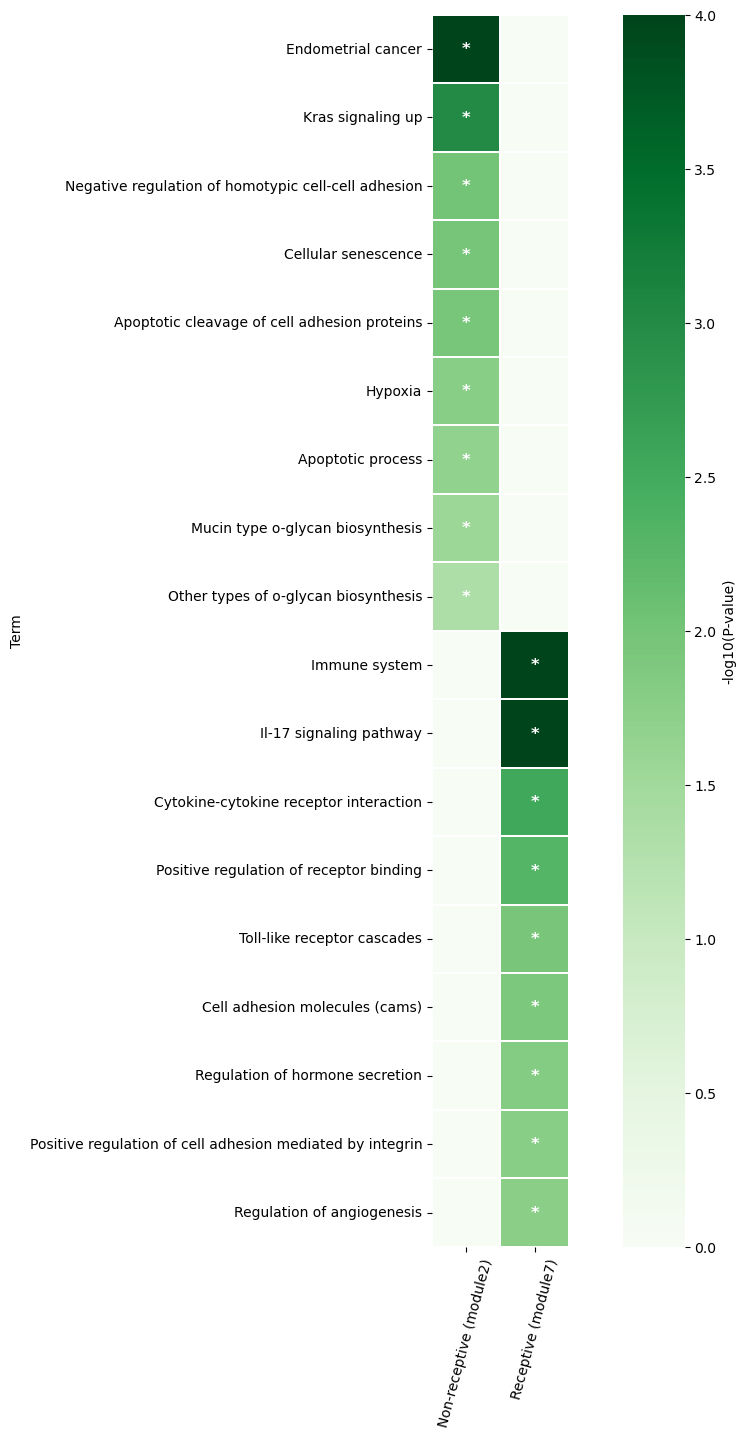

In [338]:
fig, ax = heatmap_with_groupwise_ordering(
    df=df_filtered,
    n=20,
    group_by='Leiden',
    order_by="P-value",
    cmap='Greens',
    xlabel_rotation=75,
    xlabel_fontsize=10,
    ylabel_fontsize=10,
    figsize=(14, 16),
    vmin=0,
    vmax=4,
    cbar_kws={'shrink': 1, 'label': '-log10(P-value)'},
    enable_column_order=True,
)

In [54]:
adata.write("/home/Data_Drive_8TB/kykim/1. Oval/Monocle/Luminal_adata.h5ad")

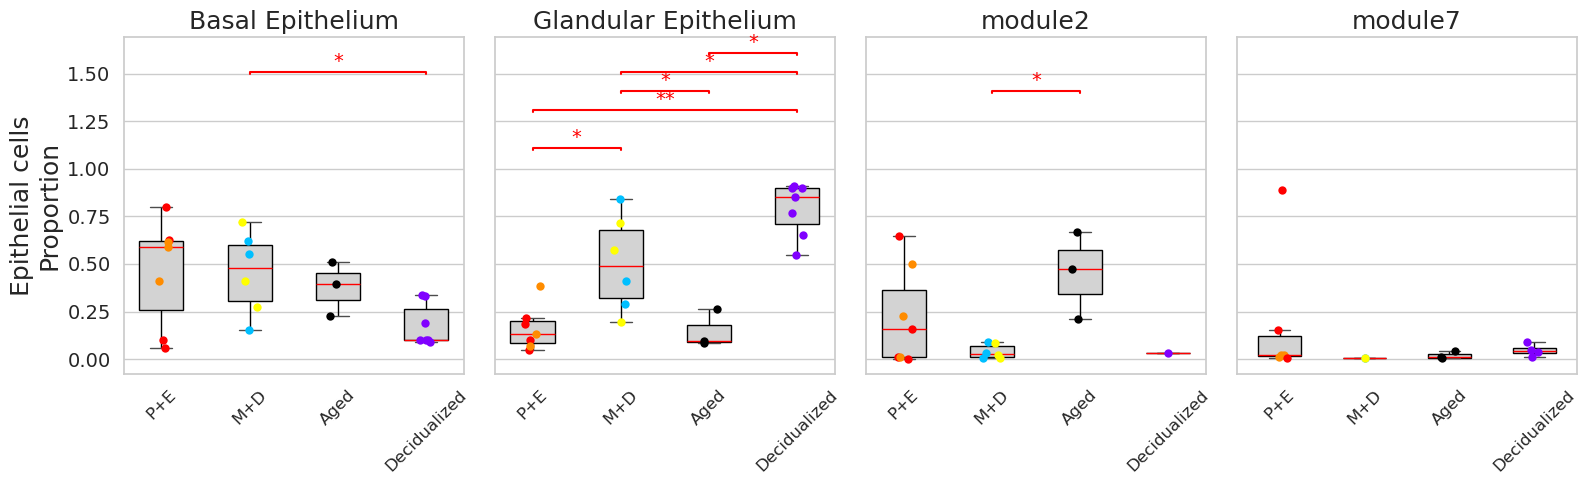

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ranksums
import warnings

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

import pandas as pd
import scanpy as sc

file_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/after_HVG_lognorm_confilt.h5ad"
adata = sc.read_h5ad(file_path)

adata.obs[['subtype']].to_csv('/home/Data_Drive_8TB/kykim/1. Oval/Nichenet/total_subtype.csv', index=True)
adata.X = adata.layers['counts'].copy()
#keep = ["CD8_T_cells", "Luminal Epithelium", "Basal Epithelium",] #"Glandular Epithelium"]
keep = ["Luminal Epithelium", "Basal Epithelium","Glandular Epithelium"]

adata = adata[adata.obs["subtype"].isin(keep)].copy()
mod = pd.read_csv("/home/Data_Drive_8TB/kykim/1. Oval/Nichenet/module_metadata.csv",index_col=0)
adata.obs["module_cluster"] = adata.obs.index.map(mod["module_cluster"])
adata.obs.loc[
    adata.obs["module_cluster"].isna(),
    "module_cluster"
] = adata.obs.loc[
    adata.obs["module_cluster"].isna(),
    "subtype"]
adata.obs["module_cluster"] = adata.obs["module_cluster"].fillna("-")
raw_adata = sc.read_h5ad("/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Before_HVG_raw_clustering(large).h5ad")
common_cells = raw_adata.obs_names.intersection(adata.obs_names)
raw_adata = raw_adata[common_cells].copy()
adata_sub = adata[common_cells].copy()
raw_adata.obs["module_cluster"] = adata_sub.obs["module_cluster"].values
adata = raw_adata

adata.obs['age_num'] = (
    adata.obs['age']
    .astype(str)
    .str.extract(r'(\d+)')[0]
    .astype(int))

clin_palette = {
    'decidualized_pregnant': '#8000ff',
    'diestrus': '#00bfff',
    'estrus': '#ff8c00',
    'metestrus': '#ffff00',
    'proestrus': '#ff0000',
    'unestrus': '#000000'}

def assign_age_group(row):
    clin = row['clinical information']
    age = row['age_num']
    if clin == 'decidualized_pregnant':
        return 'Decidualized'
    elif age > 70:
        return 'Aged'
    elif clin in ['proestrus', 'estrus']:
        return 'P+E'
    elif clin in ['metestrus', 'diestrus']:
        return 'M+D'
    else:
        return 'REMOVE'

adata_filtered = adata[adata.obs['organism part'] != 'spleen'].copy()
adata_filtered = adata_filtered[
    ~adata_filtered.obs['celltype_grouped'].isin(['Erythroid lineage'])]

adata_filtered.obs['age_group'] = adata_filtered.obs.apply(assign_age_group, axis=1)
adata_filtered = adata_filtered[adata_filtered.obs['age_group'] != 'REMOVE']

group_order = ['P+E', 'M+D', 'Aged', 'Decidualized']

celltype_groups = ['Epithelial cells', 'Stromal / Fibroblasts']
celltype_groups = [
    g for g in celltype_groups
    if g in adata_filtered.obs['celltype_grouped'].unique()]

clusters_per_group = {
    g: sorted(adata_filtered.obs.loc[adata_filtered.obs['celltype_grouped'] == g, 'module_cluster'].dropna().unique())
    for g in celltype_groups}

def normalize_mouse(df):
    total = df['count'].sum()
    df['proportion'] = df['count'] / total if total > 0 else 0
    return df

n_rows = len(celltype_groups)
n_cols_max = max(len(v) for v in clusters_per_group.values())

fig, axes = plt.subplots(
    n_rows,
    n_cols_max,
    figsize=(4 * n_cols_max, 5 * n_rows),
    sharey=True)

if n_rows == 1:
    axes = np.array([axes])
if n_cols_max == 1:
    axes = axes[:, np.newaxis]

for row_idx, group in enumerate(celltype_groups):

    data_group = adata_filtered.obs[
        adata_filtered.obs['celltype_grouped'] == group].copy()

    clusters = clusters_per_group[group]
    mouse_props_list = []

    for (mouse, age_group), grp_df in data_group.groupby(['Each mouse', 'age_group']):
        count_df = grp_df.groupby('module_cluster').size().reset_index(name='count')
        count_df['Each mouse'] = mouse
        count_df['age_group'] = age_group
        count_df['clinical information'] = grp_df['clinical information'].iloc[0]
        mouse_props_list.append(normalize_mouse(count_df))
    mouse_props = pd.concat(mouse_props_list, ignore_index=True)
    x_locs = {g: i for i, g in enumerate(group_order)}
    y_start = 1.1
    y_step = 0.1

    for col_idx, cluster in enumerate(clusters):
        ax = axes[row_idx, col_idx]
        data_sub = mouse_props[mouse_props['module_cluster'] == cluster]
        if data_sub.empty:
            continue
        sns.boxplot(
            x='age_group',
            y='proportion',
            data=data_sub,
            ax=ax,
            width=0.5,
            showcaps=True,
            boxprops={'facecolor': 'lightgray', 'edgecolor': 'black'},
            whiskerprops={'color': 'black'},
            medianprops={'color': 'red'},
            fliersize=0,
            order=group_order,
            zorder=1)

        for clin_info in data_sub['clinical information'].unique():
            sub_df = data_sub[data_sub['clinical information'] == clin_info]
            color = clin_palette.get(clin_info, 'black')
            sns.stripplot(
                x='age_group',
                y='proportion',
                data=sub_df,
                color=color,
                size=6,
                jitter=True,
                ax=ax,
                order=group_order,
                zorder=2)

        comparisons = [
            ('P+E', 'M+D'),
            ('P+E', 'Aged'),
            ('P+E', 'Decidualized'),
            ('M+D', 'Aged'),
            ('M+D', 'Decidualized'),
            ('Aged', 'Decidualized')]

        for i, (g1, g2) in enumerate(comparisons):
            vals1 = data_sub[data_sub['age_group'] == g1]['proportion']
            vals2 = data_sub[data_sub['age_group'] == g2]['proportion']

            if len(vals1) > 0 and len(vals2) > 0:
                _, pval = ranksums(vals1, vals2)
                if pval >= 0.05:
                    continue

                if pval < 0.0001:
                    sig = "****"
                elif pval < 0.001:
                    sig = "***"
                elif pval < 0.01:
                    sig = "**"
                else:
                    sig = "*"

                x1, x2 = x_locs[g1], x_locs[g2]
                y = y_start + i * y_step

                ax.plot(
                    [x1, x1, x2, x2],
                    [y, y + 0.01, y + 0.01, y],
                    lw=1.5,
                    c='red'
                )
                ax.text(
                    (x1 + x2) / 2,
                    y + 0.015,
                    sig,
                    ha='center',
                    va='bottom',
                    color='red',
                    fontsize=14
                )

        ax.set_title(f"{cluster}", fontsize=18)
        ax.set_xlabel("")
        if col_idx == 0:
            ax.set_ylabel(f"{group}\nProportion", fontsize=18)
        else:
            ax.set_ylabel("")

        ax.tick_params(axis='y', labelsize=14)
        ax.set_xticklabels(group_order, fontsize=12, rotation=45)

    for col_idx in range(len(clusters), n_cols_max):
        fig.delaxes(axes[row_idx, col_idx])

plt.tight_layout()
plt.show()

# Cell module score (Aging)

In [73]:
import scanpy as sc
import pandas as pd

file_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Epithelial_subtype_raw.h5ad"
adata = sc.read_h5ad(file_path)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
df = pd.read_csv("/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module_to_cell_metadata.csv", index_col=0)
common_idx = adata.obs.index.intersection(df.index)
adata.obs["module_cluster"] = pd.NA
adata.obs.loc[common_idx, "module_cluster"] = df.loc[common_idx, "module_cluster"]
adata.obs["module_cluster"] = adata.obs["module_cluster"].fillna(adata.obs["subtype"])

In [74]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import scanpy.external as sce
from typing import Tuple, Dict 
import gseapy as gp
sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=True)
plt.rcParams['figure.figsize'] = [5, 5]

dblist = ['KEGG_2021_Human','Reactome_Pathways_2024','MSigDB_Hallmark_2020',
         'GO_Biological_Process_2025']

pathway_gene_sets = {}

for db in dblist:
    print(f"Fetching gene sets from {db}...")
    gene_sets = gp.get_library(name=db, organism='Mouse')  # Fetch gene sets for Human
    pathway_gene_sets[db] = gene_sets

print("All gene sets retrieved successfully.")
all_pathway_gene_data = []

for db, pathways in pathway_gene_sets.items():
    print(f"Processing {db}...")
    # Create a DataFrame with Pathway, Gene List, and Database columns
    pathway_data = [{"Pathway": pathway, "GeneList": genes, "Database": db} for pathway, genes in pathways.items()]
    all_pathway_gene_data.extend(pathway_data)

final_gene_list_df = pd.DataFrame(all_pathway_gene_data)

Fetching gene sets from KEGG_2021_Human...
Fetching gene sets from Reactome_Pathways_2024...
Fetching gene sets from MSigDB_Hallmark_2020...
Fetching gene sets from GO_Biological_Process_2025...
All gene sets retrieved successfully.
Processing KEGG_2021_Human...
Processing Reactome_Pathways_2024...
Processing MSigDB_Hallmark_2020...
Processing GO_Biological_Process_2025...


In [75]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

human_genes = list(set(final_gene_list_df["GeneList"].explode()))

def human_to_mouse_ortholog(human_genes):
    res = gp.orth(organism="hsapiens", target="mmusculus", query=human_genes)
    return res.dropna(subset=["converted"]).groupby("incoming")["name"].first().to_dict()

orth_map = human_to_mouse_ortholog(human_genes)

final_gene_list_df["GeneList_mouse"] = final_gene_list_df["GeneList"].apply(
    lambda genes: [orth_map[g] for g in genes if g in orth_map])

In [148]:
with pd.option_context("display.max_rows", None):
    display(pathway_rows)

pathway_rows = final_gene_list_df[final_gene_list_df['Pathway'].str.contains('adhesion', case=False, na=False)]
pathway_rows

,Pathway,GeneList,Database,GeneList_mouse
46,Cell adhesion molecules,"[CADM3, CADM1, VCAM1, L1CAM, CD2, CD4, CD6, CN...",KEGG_2021_Human,"[Cadm3, Cadm1, Vcam1, L1cam, Cd2, Cd4, Cd6, Cn..."
94,Focal adhesion,"[EGF, ACTN4, BAD, ACTN1, COL1A2, MYL5, COL1A1,...",KEGG_2021_Human,"[Egf, Actn4, Bad, Actn1, Col1a2, N/A, Col1a1, ..."
443,Apoptotic Cleavage of Cell Adhesion Proteins,"[TJP2, DSP, OCLN, TJP1, CDH1, CTNNB1, DSG1, CA...",Reactome_Pathways_2024,"[Tjp2, Dsp, Ocln, Tjp1, Cdh1, Ctnnb1, Dsg1c, C..."
736,Defects of Platelet Adhesion to Exposed Collagen,"[COL1A2, COL1A1, VWF, GP1BB, GP5, GP1BA, ADAMT...",Reactome_Pathways_2024,"[Col1a2, Col1a1, Vwf, Gp1bb, Gp5, Gp1ba, Adamt..."
1580,Platelet Adhesion to Exposed Collagen,"[ITGA1, ITGB1, LYN, VWF, ITGA2, GP1BB, GP5, GP...",Reactome_Pathways_2024,"[Itga1, Itgb1, Lyn, Vwf, Itga2, Gp1bb, Gp5, Gp..."
1781,Regulation of Homotypic Cell-Cell Adhesion,"[JUP, FOXF1, ADAM33, MIR200C, SOX10, ILF3, HEY...",Reactome_Pathways_2024,"[Jup, Foxf1, Adam33, Mir200c, Sox10, Ilf3, Hey..."
1909,SEMA3A-Plexin Repulsion Signaling by Inhibitin...,"[NRP1, FARP2, SEMA3A, RND1, FES, RRAS, PLXNA3,...",Reactome_Pathways_2024,"[Nrp1, Farp2, Sema3a, Rnd1, Fes, Rras, Plxna3,..."
2110,Synaptic Adhesion-Like Molecules,"[RTN3, GRIA3, PTPRS, GRIA1, GRIN2D, GRIN2C, GR...",Reactome_Pathways_2024,"[Rtn3, Gria3, Ptprs, Gria1, Grin2d, Grin2c, Gr..."
2976,Bundle of His cell-Purkinje Myocyte Adhesion I...,"[JUP, DSG2, PKP2, DSC3, DSPP]",GO_Biological_Process_2025,"[Jup, Dsg2, Pkp2, Dsc3, Dspp]"
2997,Calcium-Dependent Cell-Cell Adhesion via Plasm...,"[PCDHB16, PCDHB14, PCDHB13, PCDHB11, PCDHB10, ...",GO_Biological_Process_2025,"[Pcdhb17, Pcdhb20, Pcdhb16, Pcdhb19, Pcdhb18, ..."


,Pathway,GeneList,Database,GeneList_mouse
46,Cell adhesion molecules,"[CADM3, CADM1, VCAM1, L1CAM, CD2, CD4, CD6, CN...",KEGG_2021_Human,"[Cadm3, Cadm1, Vcam1, L1cam, Cd2, Cd4, Cd6, Cn..."
94,Focal adhesion,"[EGF, ACTN4, BAD, ACTN1, COL1A2, MYL5, COL1A1,...",KEGG_2021_Human,"[Egf, Actn4, Bad, Actn1, Col1a2, N/A, Col1a1, ..."
443,Apoptotic Cleavage of Cell Adhesion Proteins,"[TJP2, DSP, OCLN, TJP1, CDH1, CTNNB1, DSG1, CA...",Reactome_Pathways_2024,"[Tjp2, Dsp, Ocln, Tjp1, Cdh1, Ctnnb1, Dsg1c, C..."
736,Defects of Platelet Adhesion to Exposed Collagen,"[COL1A2, COL1A1, VWF, GP1BB, GP5, GP1BA, ADAMT...",Reactome_Pathways_2024,"[Col1a2, Col1a1, Vwf, Gp1bb, Gp5, Gp1ba, Adamt..."
1580,Platelet Adhesion to Exposed Collagen,"[ITGA1, ITGB1, LYN, VWF, ITGA2, GP1BB, GP5, GP...",Reactome_Pathways_2024,"[Itga1, Itgb1, Lyn, Vwf, Itga2, Gp1bb, Gp5, Gp..."
...,...,...,...,...
6784,Regulation of Leukocyte Adhesion to Vascular E...,"[FUT7, ITGB2, RELA, RHOA, FUT9, MDK, NFAT5, IL...",GO_Biological_Process_2025,"[Fut7, Itgb2l, Rela, Rhoa, Fut9, Mdk, Nfat5, I..."
6785,Regulation of Leukocyte Cell-Cell Adhesion (GO...,"[FUT7, ASS1, FUT9, LCK, MDK, PPARA, WNK1, AKT1...",GO_Biological_Process_2025,"[Fut7, Ass1, Fut9, Lck, Mdk, Ppara, Wnk1, Akt1..."
7159,Regulation of Substrate Adhesion-Dependent Cel...,"[CARMIL1, NCOA3, ACTN4, AP1AR, OLFM4, ITGB1BP1...",GO_Biological_Process_2025,"[Carmil1, Ncoa3, Actn4, Ap1ar, Olfm4, Itgb1bp1..."
7566,Substrate Adhesion-Dependent Cell Spreading (G...,"[RHOA, SRCIN1, ITGA4, FN1, PARVB, LAMB1, PARVA...",GO_Biological_Process_2025,"[Rhoa, Srcin1, Itga4, Fn1, Parvb, Lamb1, Parva..."


In [158]:
import pandas as pd

target_index = 4496   # 사용하고 싶은 경로 숫자 입력 

if 0 <= target_index < len(final_gene_list_df):
    target_pathway = final_gene_list_df.loc[target_index, "Pathway"]
    gene_list = final_gene_list_df.loc[target_index, "GeneList_mouse"]
    print(f"Selected Index: {target_index}")
    print(f"Pathway: {target_pathway}")
    print(f"Gene List: {gene_list}")
    gene_df_1 = pd.DataFrame(gene_list, columns=["Gene"])
    
else:
    print(f"Invalid index: {target_index}. Must be between 0 and {len(final_gene_list_df)-1}.")

Selected Index: 4496
Pathway: Negative Regulation of Cell-Cell Adhesion (GO:0022408)
Gene List: ['Tgfb1', 'Map2k5', 'Jag1', 'Il10', 'Ppara', 'Rdx', 'Prg2', 'Klf4', 'Vegfa', 'Bmp6', 'Gtpbp4', 'Ptk2', 'Ass1', 'Rgcc', 'Bmp2', 'N/A', 'Spint2', 'Wnk1', 'Apoa1', 'Nf2', 'Adtrp', 'Myadm', 'N/A', 'Mad2l2', 'Il1rn', 'N/A', 'Akna', 'Notch1', 'Nexmif', 'Mia3', 'Plg', 'Ppm1f', 'Epcam', 'Fzr1', 'Podxl', 'Akt1', 'Zfp703', 'B4galnt2', 'Wnt1', 'Mapk7']


In [159]:
geneset = ['Tgfb1', 'Map2k5', 'Jag1', 'Il10', 'Ppara', 'Rdx', 'Prg2', 'Klf4', 'Vegfa', 'Bmp6', 'Gtpbp4', 'Ptk2', 'Ass1', 'Rgcc', 'Bmp2', 'N/A', 'Spint2', 'Wnk1', 'Apoa1', 'Nf2', 'Adtrp', 'Myadm', 'N/A', 'Mad2l2', 'Il1rn', 'N/A', 'Akna', 'Notch1', 'Nexmif', 'Mia3', 'Plg', 'Ppm1f', 'Epcam', 'Fzr1', 'Podxl', 'Akt1', 'Zfp703', 'B4galnt2', 'Wnt1', 'Mapk7']

sc.tl.score_genes(adata, geneset , score_name='EMT_score',use_raw=False)

/tmp/ipykernel_3763457/34672146.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3763457/34672146.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=15)


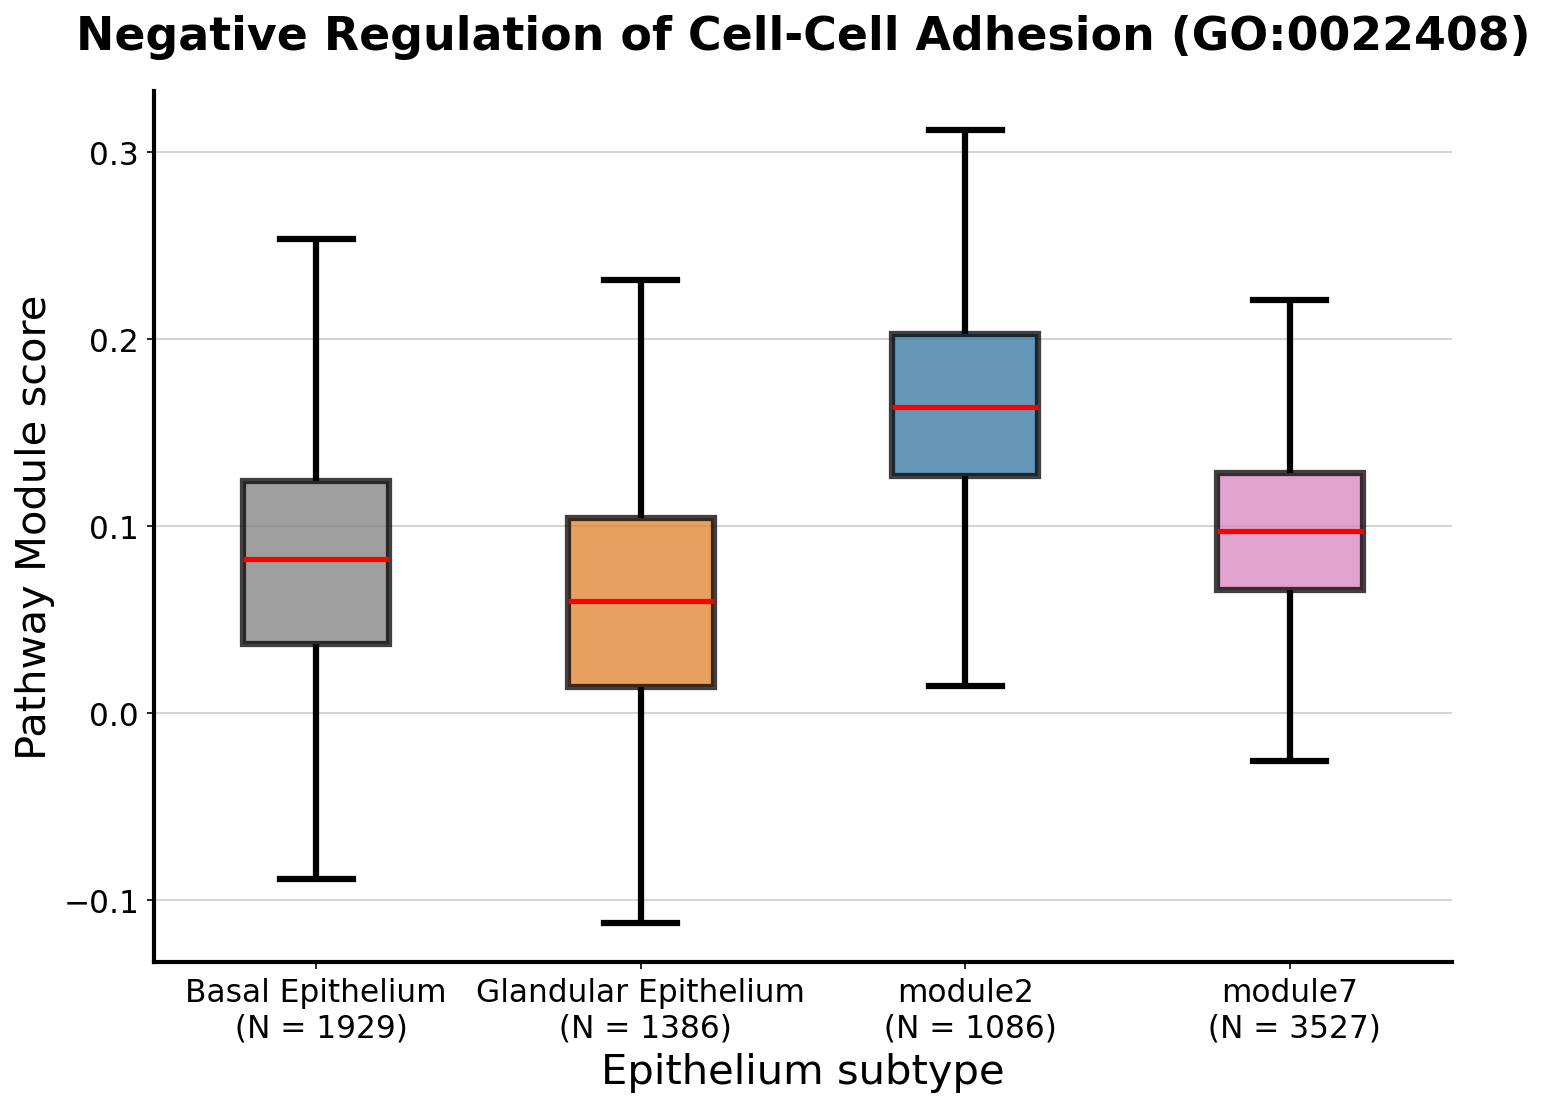

In [161]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, normaltest

leiden_groups = adata.obs['module_cluster']
muscle_system_process_score = adata.obs['EMT_score']

data_df = pd.DataFrame({
    'leiden': leiden_groups, 
    'EMT_score': muscle_system_process_score
})
data_df['leiden'] = pd.Categorical(data_df['leiden'], ordered=True)

plt.rcParams["figure.dpi"] = 75
plt.rcParams["savefig.dpi"] = 75
plt.rcParams["lines.antialiased"] = True

plt.figure(figsize=(10, 8))

palette = {
    "Basal Epithelium": "tab:grey",
    "Glandular Epithelium": "tab:orange",
    "module2": "tab:blue",
    "module7": "tab:pink"
}

sns.boxplot(
    x="leiden",
    y="EMT_score",
    data=data_df,
    palette=palette,
    width=0.45,
    showfliers=False,
    linewidth=2,
    boxprops=dict(edgecolor="black", linewidth=3, alpha=0.75),
    whiskerprops=dict(color="black", linewidth=3),
    capprops=dict(color="black", linewidth=3),
    medianprops=dict(color="red", linewidth=2.5)
)

plt.title("Negative Regulation of Cell-Cell Adhesion (GO:0022408)",
    fontsize=22,
    fontweight="bold",
    pad=20)

# x축 라벨에 N 추가
counts = data_df['leiden'].value_counts().reindex(data_df['leiden'].cat.categories)
ax = plt.gca()
new_labels = [f"{cat}\n (N = {counts[cat]})" for cat in data_df['leiden'].cat.categories]
ax.set_xticklabels(new_labels, fontsize=15)

plt.yticks(fontsize=15)
plt.xlabel("Epithelium subtype", fontsize=20)
plt.ylabel("Pathway Module score", fontsize=20)

sns.despine(ax=ax, top=True, right=True)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/tmp/ipykernel_3763457/2808987332.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3763457/2808987332.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=15)


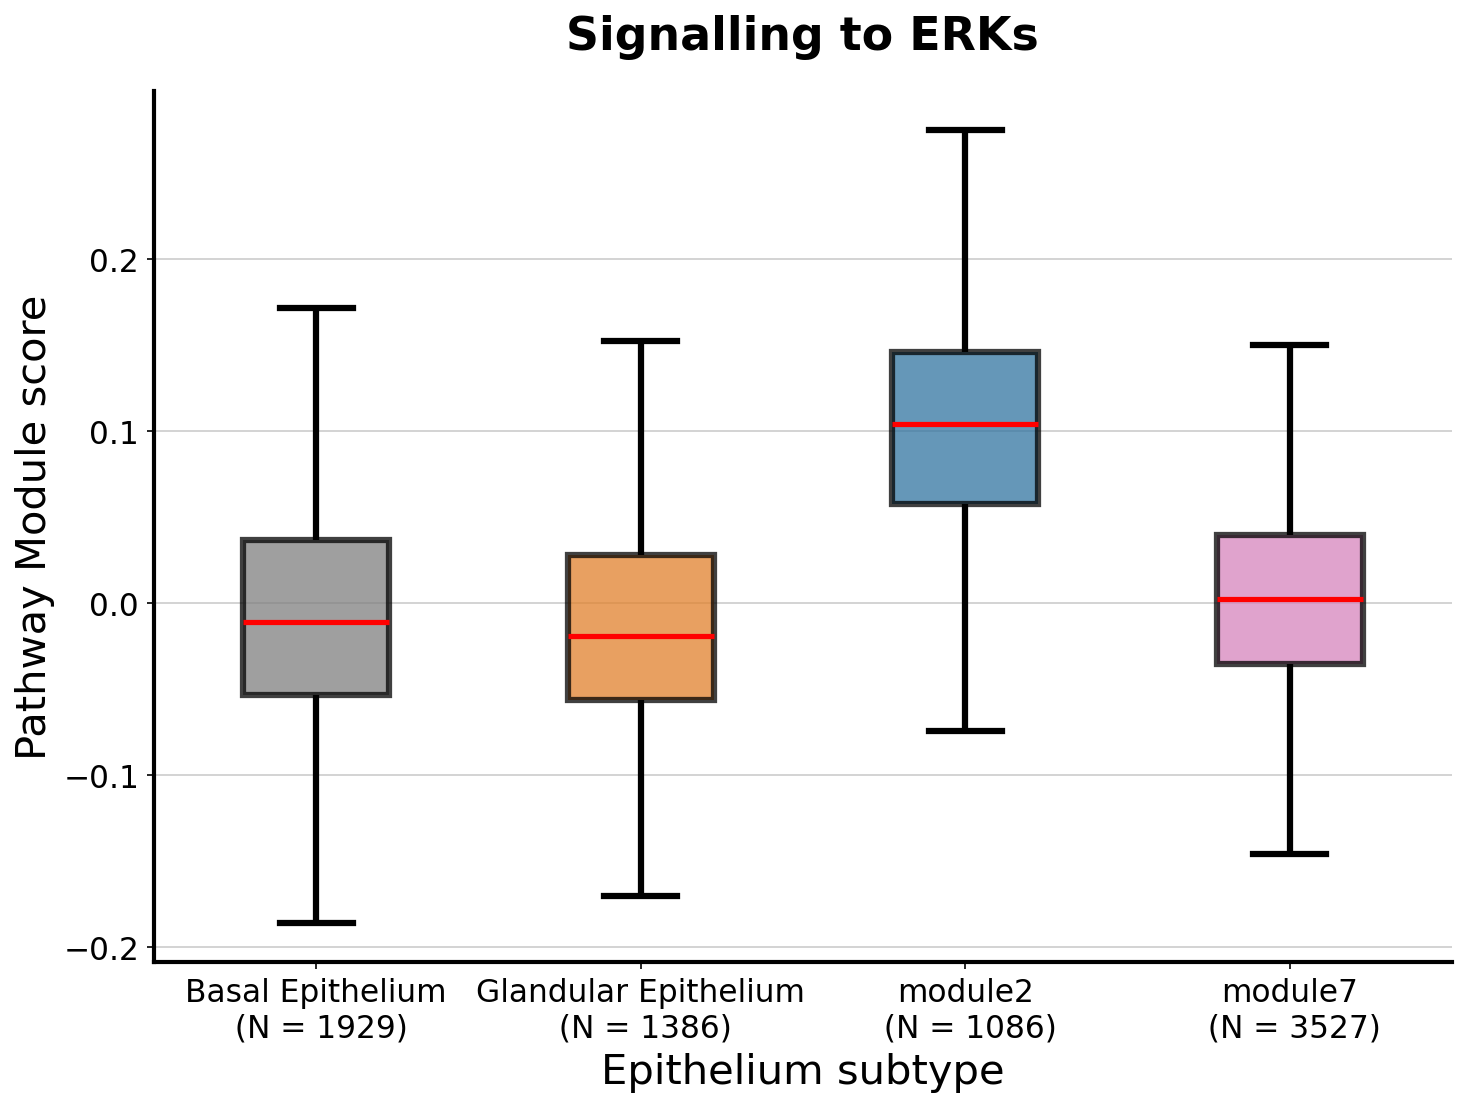

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, normaltest

leiden_groups = adata.obs['module_cluster']
muscle_system_process_score = adata.obs['EMT_score']

data_df = pd.DataFrame({
    'leiden': leiden_groups, 
    'EMT_score': muscle_system_process_score
})
data_df['leiden'] = pd.Categorical(data_df['leiden'], ordered=True)

plt.rcParams["figure.dpi"] = 75
plt.rcParams["savefig.dpi"] = 75
plt.rcParams["lines.antialiased"] = True

plt.figure(figsize=(10, 8))

palette = {
    "Basal Epithelium": "tab:grey",
    "Glandular Epithelium": "tab:orange",
    "module2": "tab:blue",
    "module7": "tab:pink"
}

sns.boxplot(
    x="leiden",
    y="EMT_score",
    data=data_df,
    palette=palette,
    width=0.45,
    showfliers=False,
    linewidth=2,
    boxprops=dict(edgecolor="black", linewidth=3, alpha=0.75),
    whiskerprops=dict(color="black", linewidth=3),
    capprops=dict(color="black", linewidth=3),
    medianprops=dict(color="red", linewidth=2.5)
)

plt.title("Signalling to ERKs",
    fontsize=22,
    fontweight="bold",
    pad=20)

# x축 라벨에 N 추가
counts = data_df['leiden'].value_counts().reindex(data_df['leiden'].cat.categories)
ax = plt.gca()
new_labels = [f"{cat}\n (N = {counts[cat]})" for cat in data_df['leiden'].cat.categories]
ax.set_xticklabels(new_labels, fontsize=15)

plt.yticks(fontsize=15)
plt.xlabel("Epithelium subtype", fontsize=20)
plt.ylabel("Pathway Module score", fontsize=20)

sns.despine(ax=ax, top=True, right=True)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/tmp/ipykernel_3763457/1920254955.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3763457/1920254955.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=15)


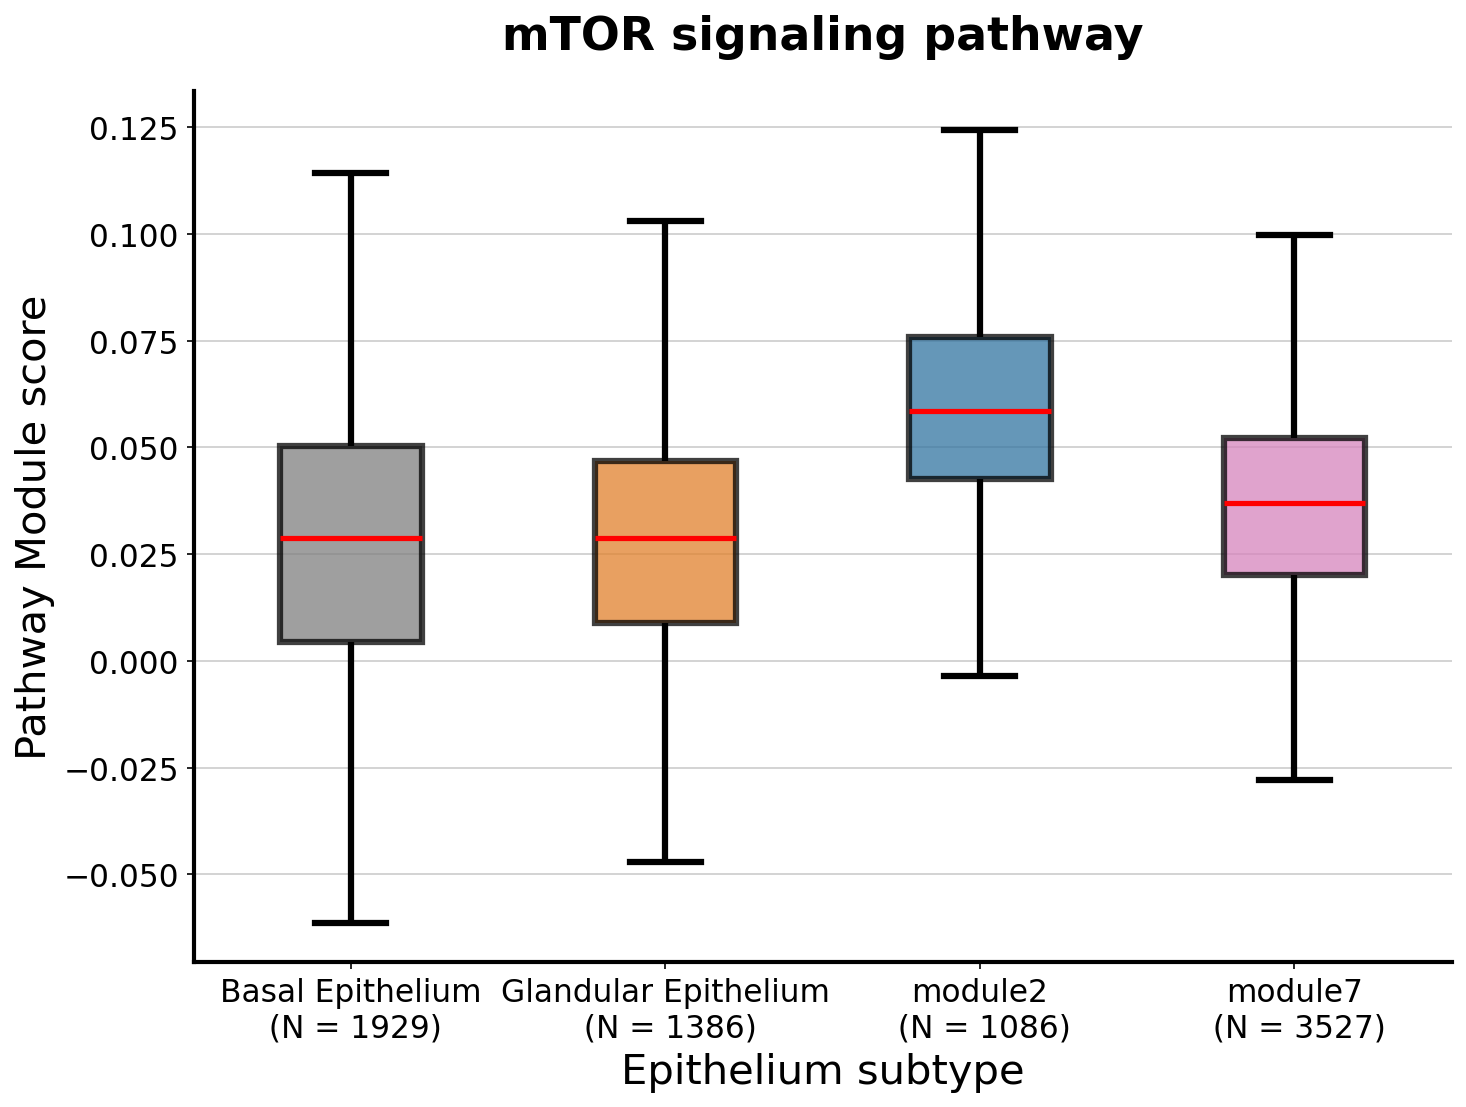

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, normaltest

leiden_groups = adata.obs['module_cluster']
muscle_system_process_score = adata.obs['EMT_score']

data_df = pd.DataFrame({
    'leiden': leiden_groups, 
    'EMT_score': muscle_system_process_score
})
data_df['leiden'] = pd.Categorical(data_df['leiden'], ordered=True)

plt.rcParams["figure.dpi"] = 75
plt.rcParams["savefig.dpi"] = 75
plt.rcParams["lines.antialiased"] = True

plt.figure(figsize=(10, 8))

palette = {
    "Basal Epithelium": "tab:grey",
    "Glandular Epithelium": "tab:orange",
    "module2": "tab:blue",
    "module7": "tab:pink"
}

sns.boxplot(
    x="leiden",
    y="EMT_score",
    data=data_df,
    palette=palette,
    width=0.45,
    showfliers=False,
    linewidth=2,
    boxprops=dict(edgecolor="black", linewidth=3, alpha=0.75),
    whiskerprops=dict(color="black", linewidth=3),
    capprops=dict(color="black", linewidth=3),
    medianprops=dict(color="red", linewidth=2.5)
)

plt.title("mTOR signaling pathway",
    fontsize=22,
    fontweight="bold",
    pad=20)

# x축 라벨에 N 추가
counts = data_df['leiden'].value_counts().reindex(data_df['leiden'].cat.categories)
ax = plt.gca()
new_labels = [f"{cat}\n (N = {counts[cat]})" for cat in data_df['leiden'].cat.categories]
ax.set_xticklabels(new_labels, fontsize=15)

plt.yticks(fontsize=15)
plt.xlabel("Epithelium subtype", fontsize=20)
plt.ylabel("Pathway Module score", fontsize=20)

sns.despine(ax=ax, top=True, right=True)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/tmp/ipykernel_3230748/3811874879.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3230748/3811874879.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=15)


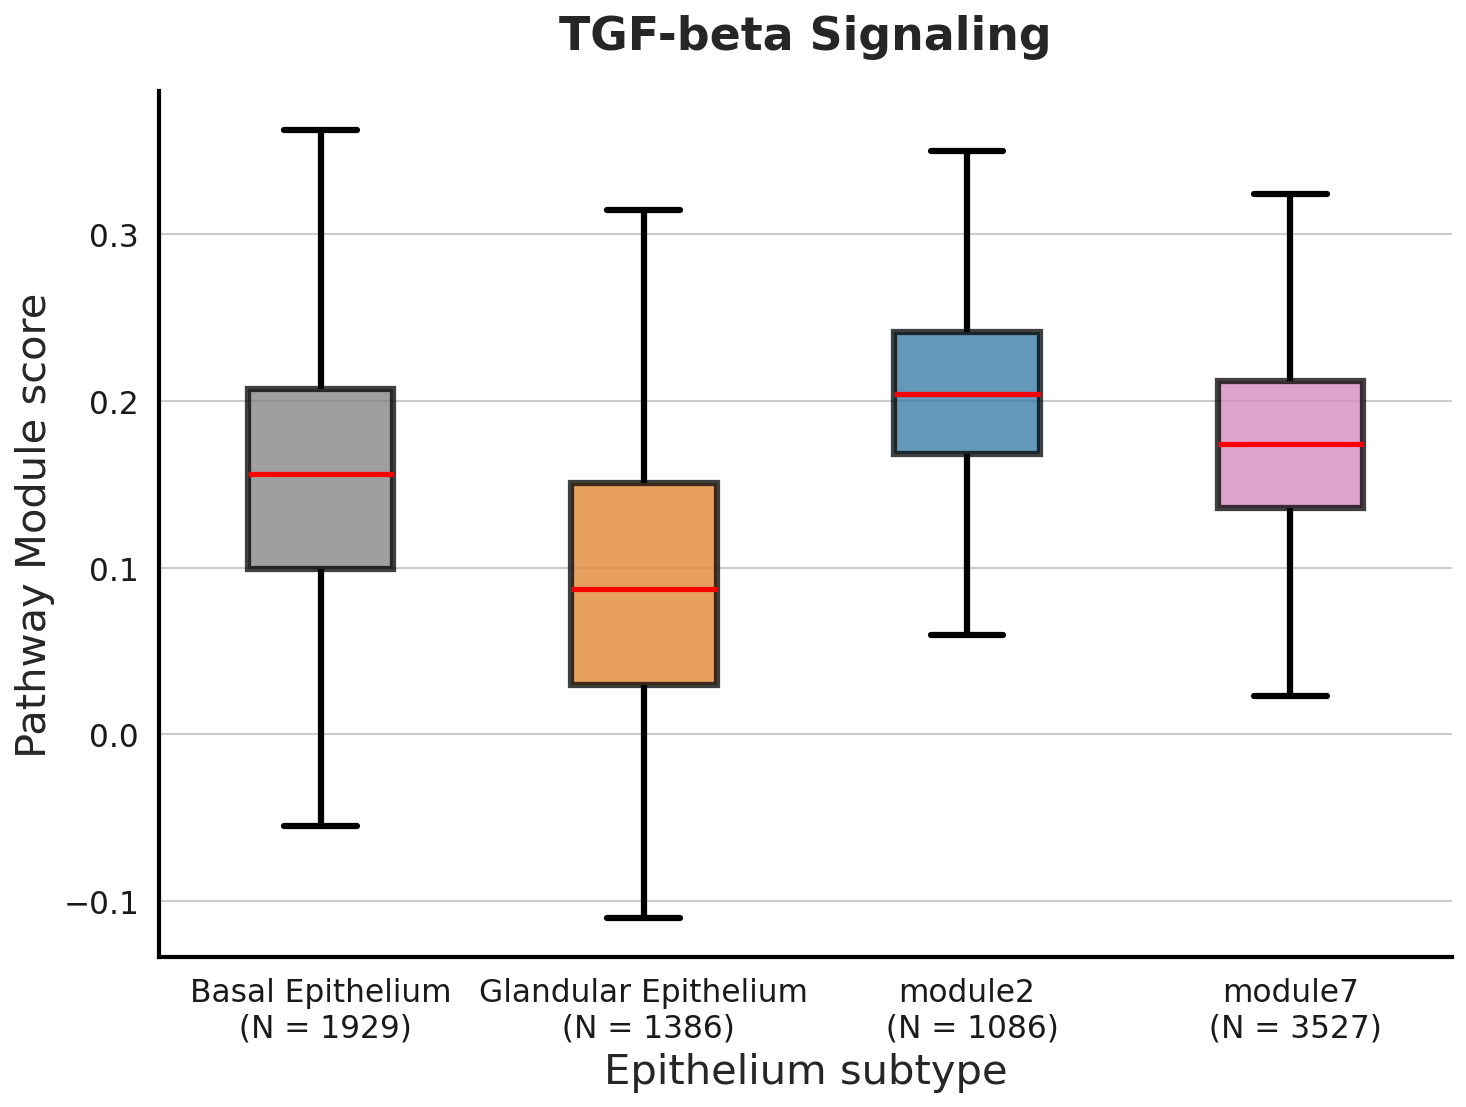

In [654]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, normaltest

leiden_groups = adata.obs['module_cluster']
muscle_system_process_score = adata.obs['EMT_score']

data_df = pd.DataFrame({
    'leiden': leiden_groups, 
    'EMT_score': muscle_system_process_score
})
data_df['leiden'] = pd.Categorical(data_df['leiden'], ordered=True)

plt.rcParams["figure.dpi"] = 75
plt.rcParams["savefig.dpi"] = 75
plt.rcParams["lines.antialiased"] = True

plt.figure(figsize=(10, 8))

palette = {
    "Basal Epithelium": "tab:grey",
    "Glandular Epithelium": "tab:orange",
    "module2": "tab:blue",
    "module7": "tab:pink"
}

sns.boxplot(
    x="leiden",
    y="EMT_score",
    data=data_df,
    palette=palette,
    width=0.45,
    showfliers=False,
    linewidth=2,
    boxprops=dict(edgecolor="black", linewidth=3, alpha=0.75),
    whiskerprops=dict(color="black", linewidth=3),
    capprops=dict(color="black", linewidth=3),
    medianprops=dict(color="red", linewidth=2.5)
)

plt.title("TGF-beta Signaling",
    fontsize=22,
    fontweight="bold",
    pad=20)

# x축 라벨에 N 추가
counts = data_df['leiden'].value_counts().reindex(data_df['leiden'].cat.categories)
ax = plt.gca()
new_labels = [f"{cat}\n (N = {counts[cat]})" for cat in data_df['leiden'].cat.categories]
ax.set_xticklabels(new_labels, fontsize=15)

plt.yticks(fontsize=15)
plt.xlabel("Epithelium subtype", fontsize=20)
plt.ylabel("Pathway Module score", fontsize=20)

sns.despine(ax=ax, top=True, right=True)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/tmp/ipykernel_3230748/1856811930.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3230748/1856811930.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=15)


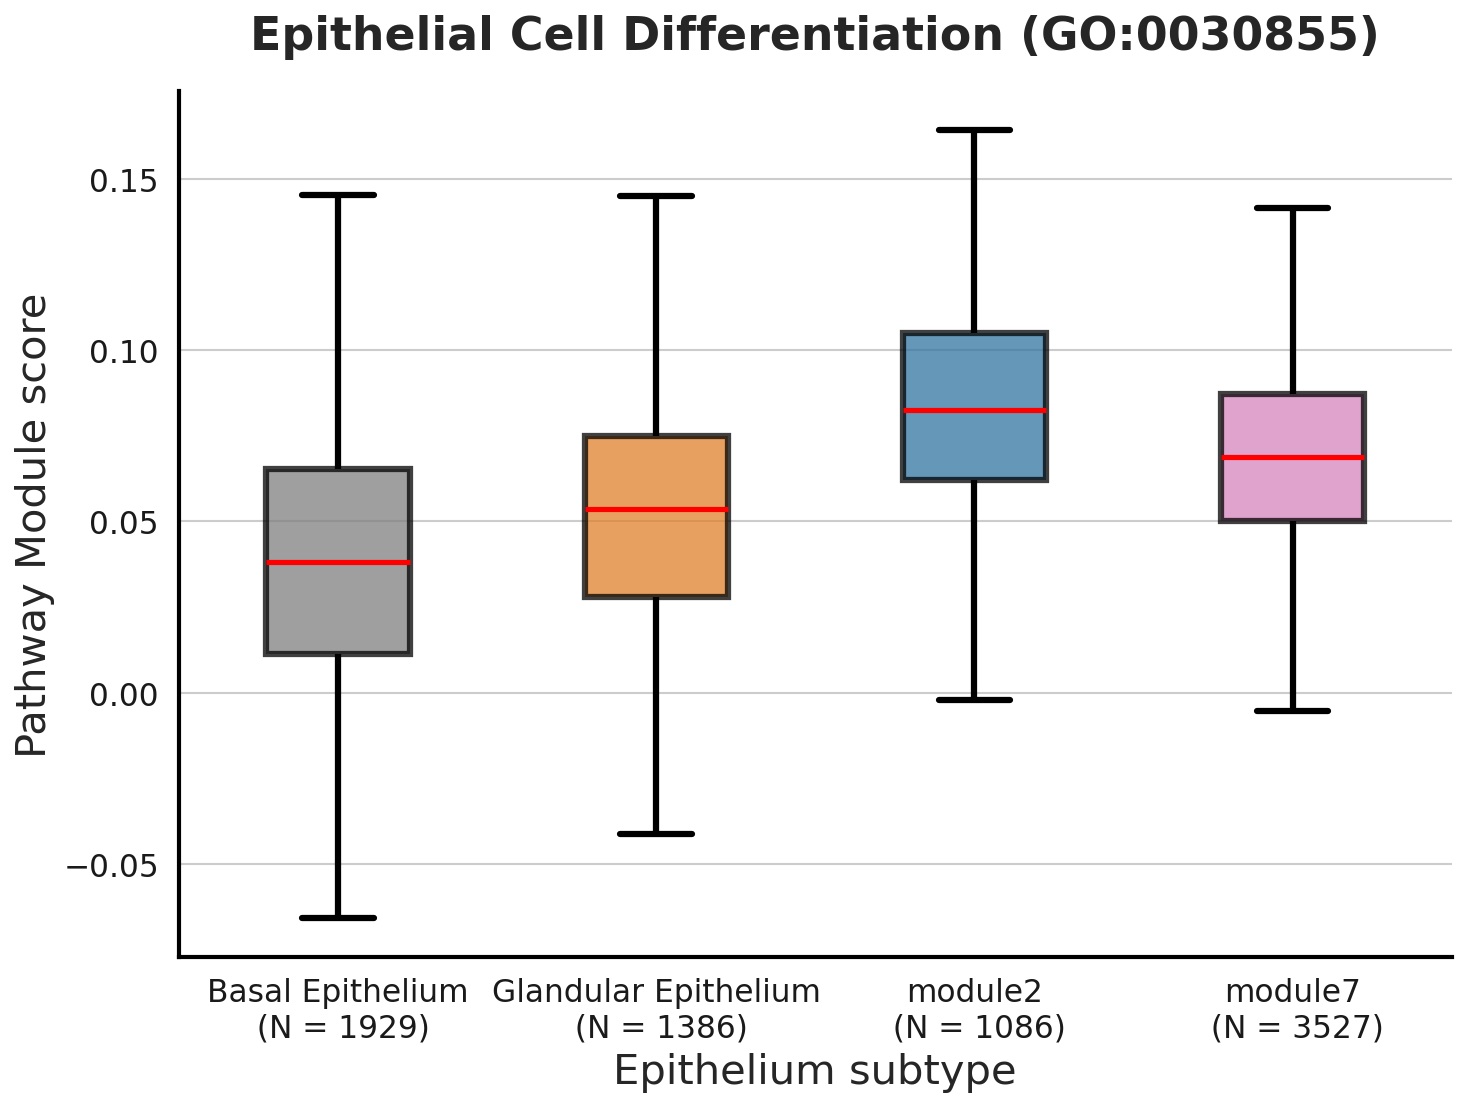

In [564]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, normaltest

leiden_groups = adata.obs['module_cluster']
muscle_system_process_score = adata.obs['EMT_score']

data_df = pd.DataFrame({
    'leiden': leiden_groups, 
    'EMT_score': muscle_system_process_score
})
data_df['leiden'] = pd.Categorical(data_df['leiden'], ordered=True)

plt.rcParams["figure.dpi"] = 75
plt.rcParams["savefig.dpi"] = 75
plt.rcParams["lines.antialiased"] = True

plt.figure(figsize=(10, 8))

palette = {
    "Basal Epithelium": "tab:grey",
    "Glandular Epithelium": "tab:orange",
    "module2": "tab:blue",
    "module7": "tab:pink"
}

sns.boxplot(
    x="leiden",
    y="EMT_score",
    data=data_df,
    palette=palette,
    width=0.45,
    showfliers=False,
    linewidth=2,
    boxprops=dict(edgecolor="black", linewidth=3, alpha=0.75),
    whiskerprops=dict(color="black", linewidth=3),
    capprops=dict(color="black", linewidth=3),
    medianprops=dict(color="red", linewidth=2.5)
)

plt.title("Epithelial Cell Differentiation (GO:0030855)",
    fontsize=22,
    fontweight="bold",
    pad=20)

# x축 라벨에 N 추가
counts = data_df['leiden'].value_counts().reindex(data_df['leiden'].cat.categories)
ax = plt.gca()
new_labels = [f"{cat}\n (N = {counts[cat]})" for cat in data_df['leiden'].cat.categories]
ax.set_xticklabels(new_labels, fontsize=15)

plt.yticks(fontsize=15)
plt.xlabel("Epithelium subtype", fontsize=20)
plt.ylabel("Pathway Module score", fontsize=20)

sns.despine(ax=ax, top=True, right=True)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/tmp/ipykernel_3230748/2502900978.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3230748/2502900978.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=15)


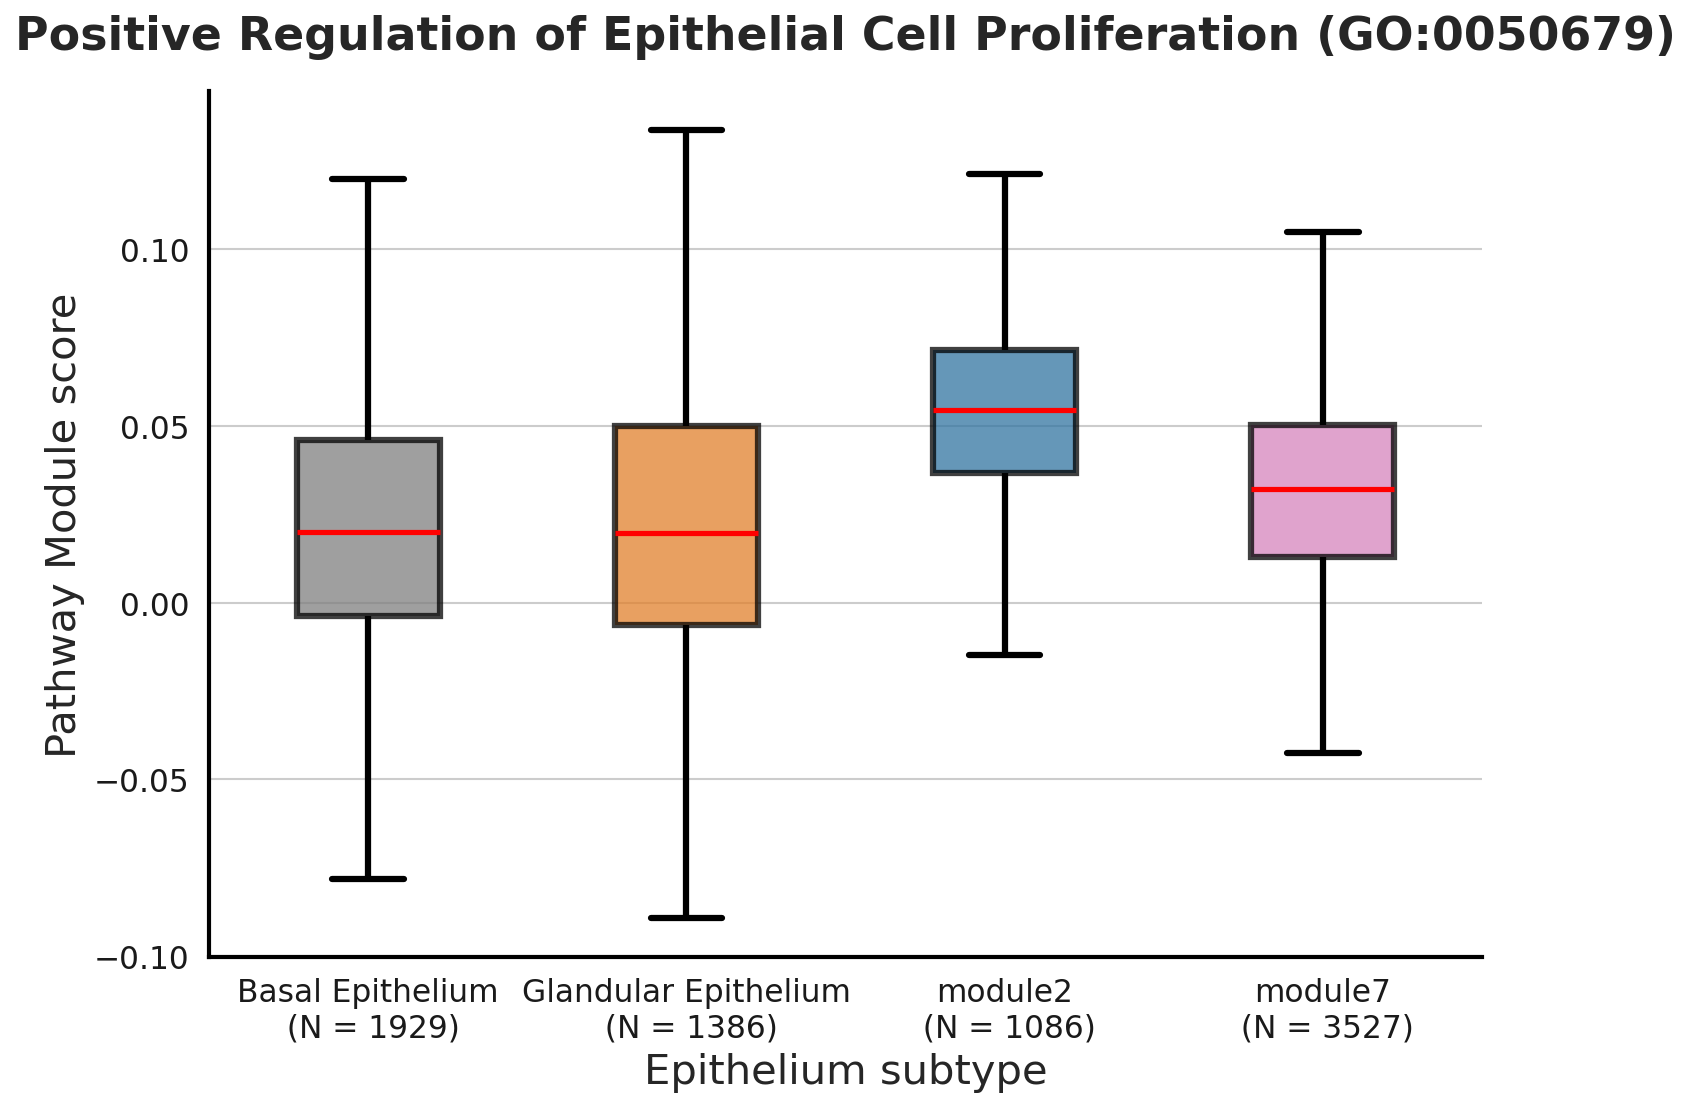

In [557]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, normaltest

leiden_groups = adata.obs['module_cluster']
muscle_system_process_score = adata.obs['EMT_score']

data_df = pd.DataFrame({
    'leiden': leiden_groups, 
    'EMT_score': muscle_system_process_score
})
data_df['leiden'] = pd.Categorical(data_df['leiden'], ordered=True)

plt.rcParams["figure.dpi"] = 75
plt.rcParams["savefig.dpi"] = 75
plt.rcParams["lines.antialiased"] = True

plt.figure(figsize=(10, 8))

palette = {
    "Basal Epithelium": "tab:grey",
    "Glandular Epithelium": "tab:orange",
    "module2": "tab:blue",
    "module7": "tab:pink"
}

sns.boxplot(
    x="leiden",
    y="EMT_score",
    data=data_df,
    palette=palette,
    width=0.45,
    showfliers=False,
    linewidth=2,
    boxprops=dict(edgecolor="black", linewidth=3, alpha=0.75),
    whiskerprops=dict(color="black", linewidth=3),
    capprops=dict(color="black", linewidth=3),
    medianprops=dict(color="red", linewidth=2.5)
)

plt.title("Positive Regulation of Epithelial Cell Proliferation (GO:0050679)",
    fontsize=22,
    fontweight="bold",
    pad=20)

# x축 라벨에 N 추가
counts = data_df['leiden'].value_counts().reindex(data_df['leiden'].cat.categories)
ax = plt.gca()
new_labels = [f"{cat}\n (N = {counts[cat]})" for cat in data_df['leiden'].cat.categories]
ax.set_xticklabels(new_labels, fontsize=15)

plt.yticks(fontsize=15)
plt.xlabel("Epithelium subtype", fontsize=20)
plt.ylabel("Pathway Module score", fontsize=20)

sns.despine(ax=ax, top=True, right=True)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/tmp/ipykernel_3230748/1329313634.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3230748/1329313634.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=15)


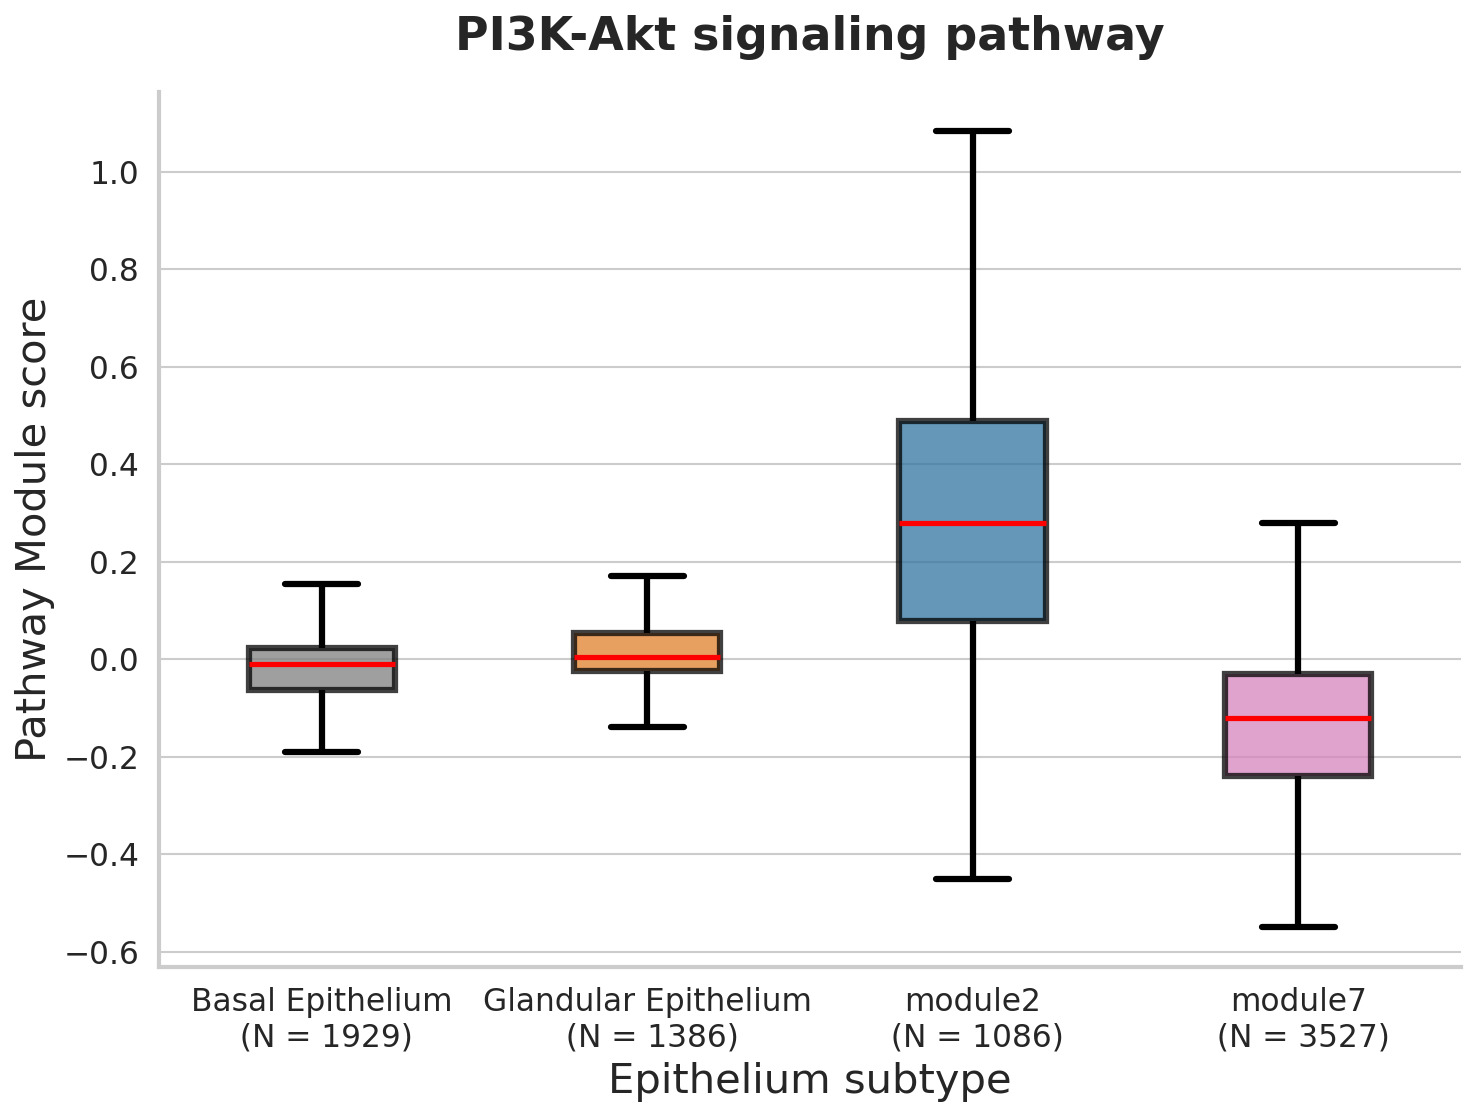

In [449]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, normaltest

leiden_groups = adata.obs['module_cluster']
muscle_system_process_score = adata.obs['EMT_score']

data_df = pd.DataFrame({
    'leiden': leiden_groups, 
    'EMT_score': muscle_system_process_score
})
data_df['leiden'] = pd.Categorical(data_df['leiden'], ordered=True)

plt.rcParams["figure.dpi"] = 75
plt.rcParams["savefig.dpi"] = 75
plt.rcParams["lines.antialiased"] = True

plt.figure(figsize=(10, 8))

palette = {
    "Basal Epithelium": "tab:grey",
    "Glandular Epithelium": "tab:orange",
    "module2": "tab:blue",
    "module7": "tab:pink"
}

sns.boxplot(
    x="leiden",
    y="EMT_score",
    data=data_df,
    palette=palette,
    width=0.45,
    showfliers=False,
    linewidth=2,
    boxprops=dict(edgecolor="black", linewidth=3, alpha=0.75),
    whiskerprops=dict(color="black", linewidth=3),
    capprops=dict(color="black", linewidth=3),
    medianprops=dict(color="red", linewidth=2.5)
)

plt.title("PI3K-Akt signaling pathway",
    fontsize=22,
    fontweight="bold",
    pad=20)

# x축 라벨에 N 추가
counts = data_df['leiden'].value_counts().reindex(data_df['leiden'].cat.categories)
ax = plt.gca()
new_labels = [f"{cat}\n (N = {counts[cat]})" for cat in data_df['leiden'].cat.categories]
ax.set_xticklabels(new_labels, fontsize=15)

plt.yticks(fontsize=15)
plt.xlabel("Epithelium subtype", fontsize=20)
plt.ylabel("Pathway Module score", fontsize=20)

sns.despine(ax=ax, top=True, right=True)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/tmp/ipykernel_3230748/4264715019.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3230748/4264715019.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=15)


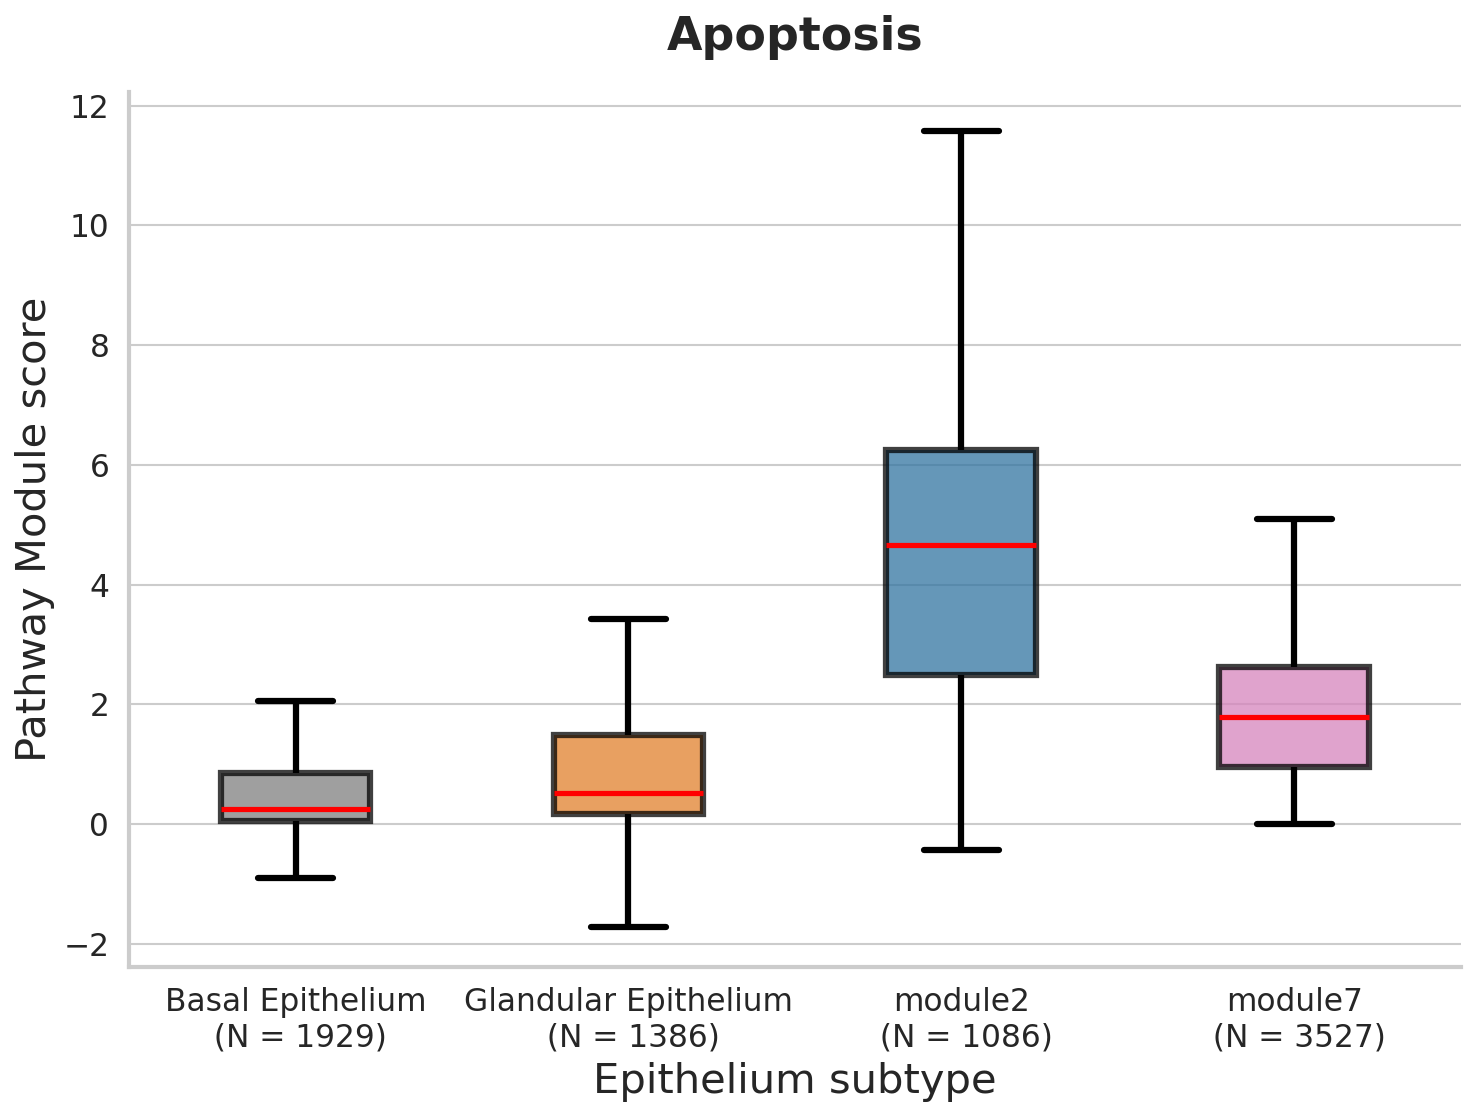

In [421]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, normaltest

leiden_groups = adata.obs['module_cluster']
muscle_system_process_score = adata.obs['EMT_score']

data_df = pd.DataFrame({
    'leiden': leiden_groups, 
    'EMT_score': muscle_system_process_score
})
data_df['leiden'] = pd.Categorical(data_df['leiden'], ordered=True)

plt.rcParams["figure.dpi"] = 75
plt.rcParams["savefig.dpi"] = 75
plt.rcParams["lines.antialiased"] = True

plt.figure(figsize=(10, 8))

palette = {
    "Basal Epithelium": "tab:grey",
    "Glandular Epithelium": "tab:orange",
    "module2": "tab:blue",
    "module7": "tab:pink"
}

sns.boxplot(
    x="leiden",
    y="EMT_score",
    data=data_df,
    palette=palette,
    width=0.45,
    showfliers=False,
    linewidth=2,
    boxprops=dict(edgecolor="black", linewidth=3, alpha=0.75),
    whiskerprops=dict(color="black", linewidth=3),
    capprops=dict(color="black", linewidth=3),
    medianprops=dict(color="red", linewidth=2.5)
)

plt.title("Apoptosis",
    fontsize=22,
    fontweight="bold",
    pad=20)

# x축 라벨에 N 추가
counts = data_df['leiden'].value_counts().reindex(data_df['leiden'].cat.categories)
ax = plt.gca()
new_labels = [f"{cat}\n (N = {counts[cat]})" for cat in data_df['leiden'].cat.categories]
ax.set_xticklabels(new_labels, fontsize=15)

plt.yticks(fontsize=15)
plt.xlabel("Epithelium subtype", fontsize=20)
plt.ylabel("Pathway Module score", fontsize=20)

sns.despine(ax=ax, top=True, right=True)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/tmp/ipykernel_3230748/1723362212.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3230748/1723362212.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=15)


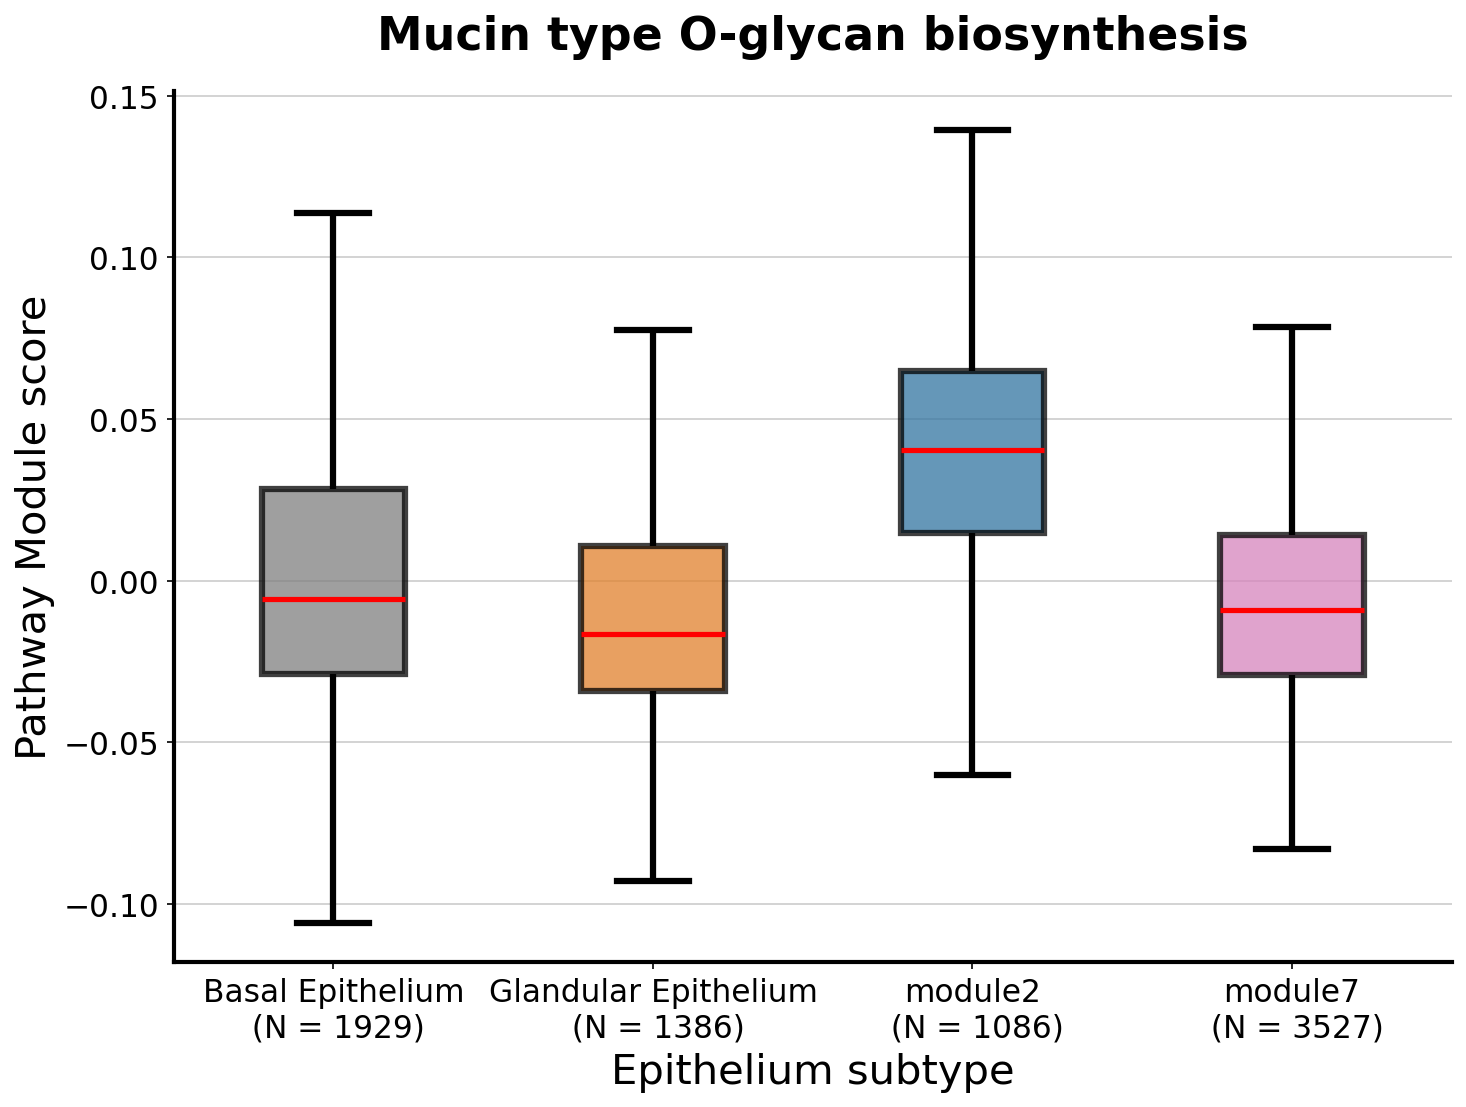

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, normaltest

leiden_groups = adata.obs['module_cluster']
muscle_system_process_score = adata.obs['EMT_score']

data_df = pd.DataFrame({
    'leiden': leiden_groups, 
    'EMT_score': muscle_system_process_score
})
data_df['leiden'] = pd.Categorical(data_df['leiden'], ordered=True)

plt.rcParams["figure.dpi"] = 75
plt.rcParams["savefig.dpi"] = 75
plt.rcParams["lines.antialiased"] = True

plt.figure(figsize=(10, 8))

palette = {
    "Basal Epithelium": "tab:grey",
    "Glandular Epithelium": "tab:orange",
    "module2": "tab:blue",
    "module7": "tab:pink"
}

sns.boxplot(
    x="leiden",
    y="EMT_score",
    data=data_df,
    palette=palette,
    width=0.45,
    showfliers=False,
    linewidth=2,
    boxprops=dict(edgecolor="black", linewidth=3, alpha=0.75),
    whiskerprops=dict(color="black", linewidth=3),
    capprops=dict(color="black", linewidth=3),
    medianprops=dict(color="red", linewidth=2.5)
)

plt.title("Mucin type O-glycan biosynthesis",
    fontsize=22,
    fontweight="bold",
    pad=20)

# x축 라벨에 N 추가
counts = data_df['leiden'].value_counts().reindex(data_df['leiden'].cat.categories)
ax = plt.gca()
new_labels = [f"{cat}\n (N = {counts[cat]})" for cat in data_df['leiden'].cat.categories]
ax.set_xticklabels(new_labels, fontsize=15)

plt.yticks(fontsize=15)
plt.xlabel("Epithelium subtype", fontsize=20)
plt.ylabel("Pathway Module score", fontsize=20)

sns.despine(ax=ax, top=True, right=True)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/tmp/ipykernel_3230748/4237532440.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3230748/4237532440.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=15)


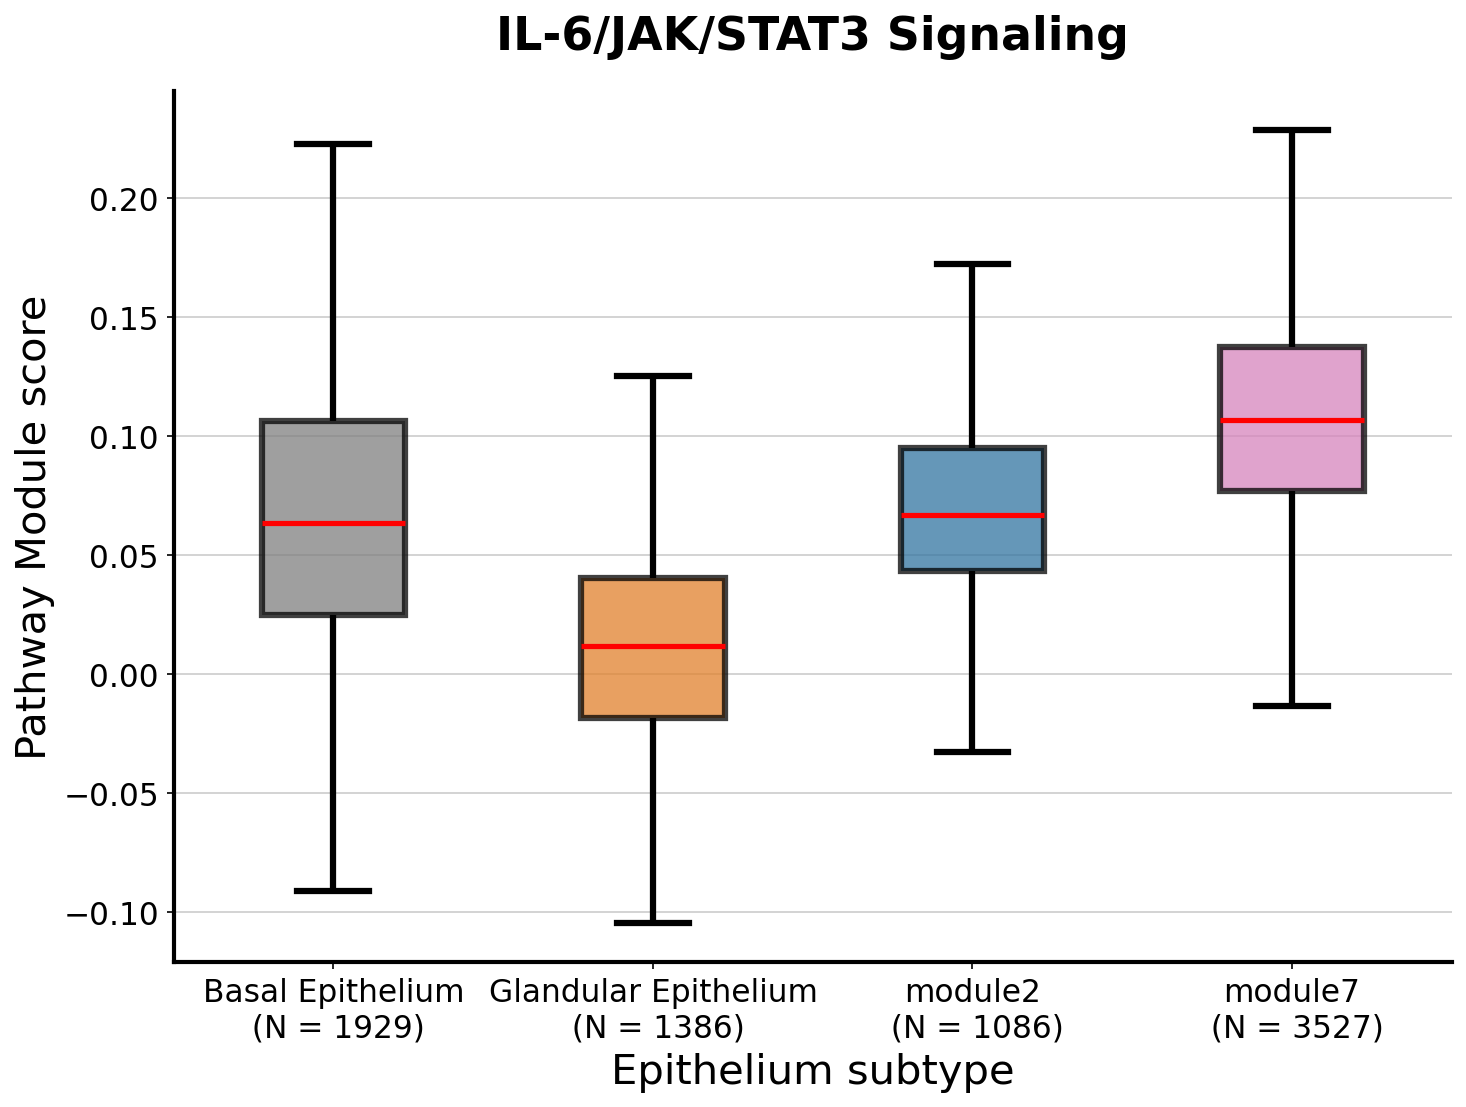

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, normaltest

leiden_groups = adata.obs['module_cluster']
muscle_system_process_score = adata.obs['EMT_score']

data_df = pd.DataFrame({
    'leiden': leiden_groups, 
    'EMT_score': muscle_system_process_score
})
data_df['leiden'] = pd.Categorical(data_df['leiden'], ordered=True)

plt.rcParams["figure.dpi"] = 75
plt.rcParams["savefig.dpi"] = 75
plt.rcParams["lines.antialiased"] = True

plt.figure(figsize=(10, 8))

palette = {
    "Basal Epithelium": "tab:grey",
    "Glandular Epithelium": "tab:orange",
    "module2": "tab:blue",
    "module7": "tab:pink"
}

sns.boxplot(
    x="leiden",
    y="EMT_score",
    data=data_df,
    palette=palette,
    width=0.45,
    showfliers=False,
    linewidth=2,
    boxprops=dict(edgecolor="black", linewidth=3, alpha=0.75),
    whiskerprops=dict(color="black", linewidth=3),
    capprops=dict(color="black", linewidth=3),
    medianprops=dict(color="red", linewidth=2.5)
)

plt.title("IL-6/JAK/STAT3 Signaling",
    fontsize=22,
    fontweight="bold",
    pad=20)

# x축 라벨에 N 추가
counts = data_df['leiden'].value_counts().reindex(data_df['leiden'].cat.categories)
ax = plt.gca()
new_labels = [f"{cat}\n (N = {counts[cat]})" for cat in data_df['leiden'].cat.categories]
ax.set_xticklabels(new_labels, fontsize=15)

plt.yticks(fontsize=15)
plt.xlabel("Epithelium subtype", fontsize=20)
plt.ylabel("Pathway Module score", fontsize=20)

sns.despine(ax=ax, top=True, right=True)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/tmp/ipykernel_3230748/2244207346.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3230748/2244207346.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=15)


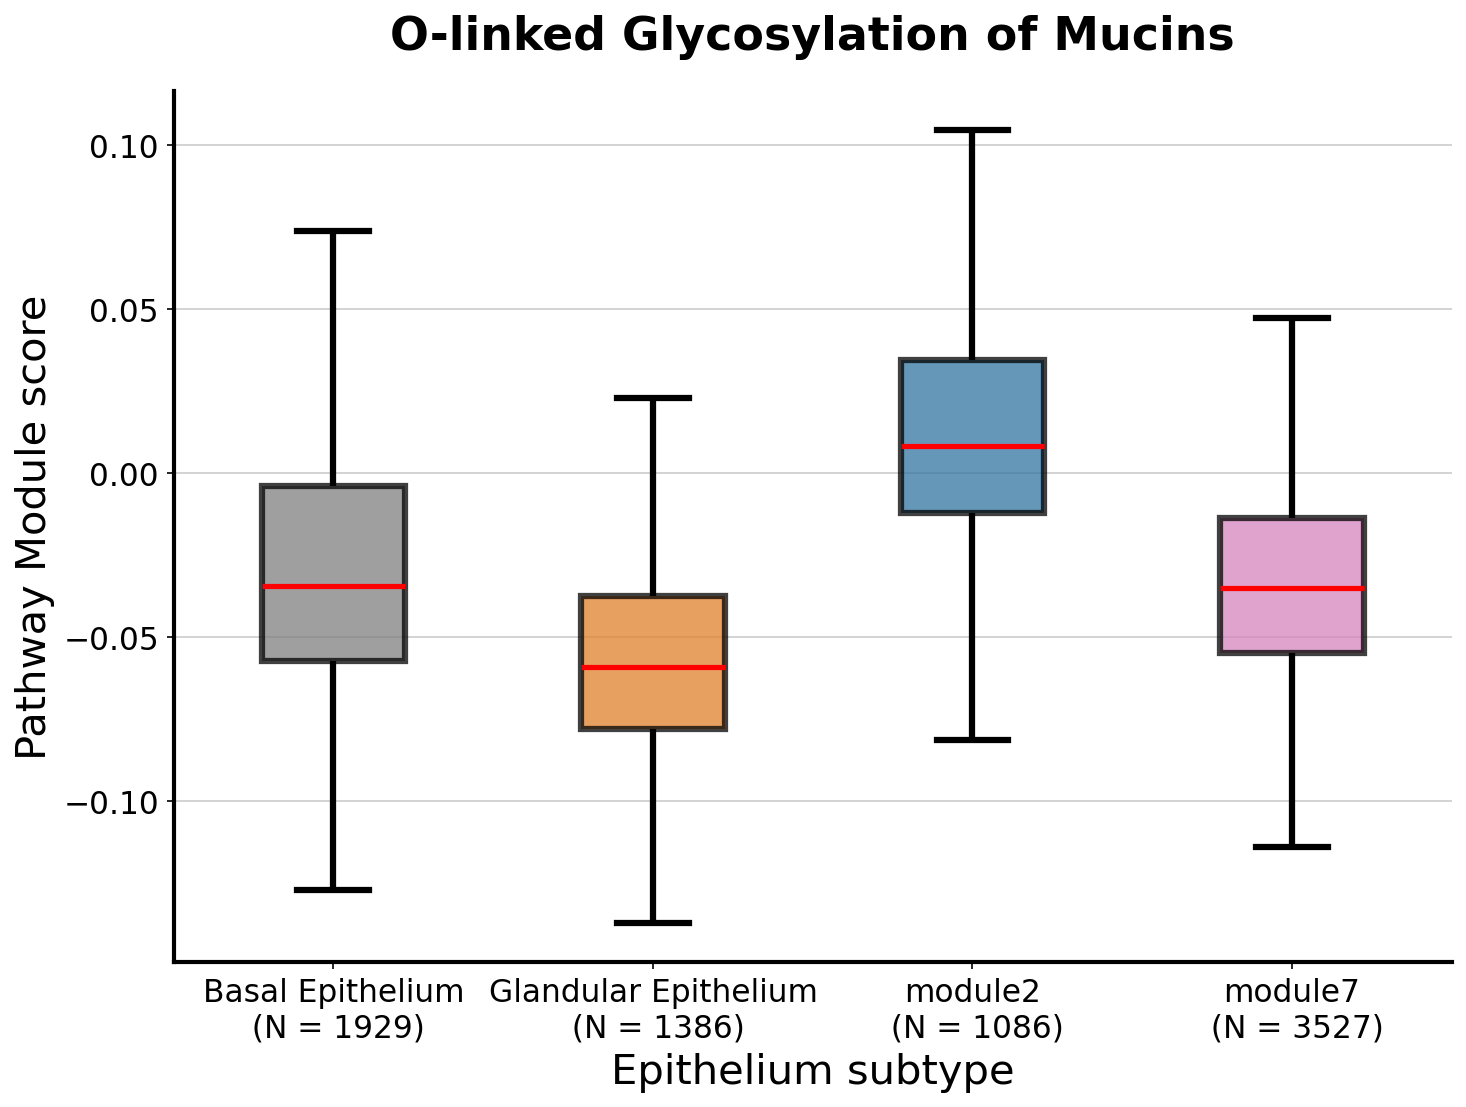

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, normaltest

leiden_groups = adata.obs['module_cluster']
muscle_system_process_score = adata.obs['EMT_score']

data_df = pd.DataFrame({
    'leiden': leiden_groups, 
    'EMT_score': muscle_system_process_score
})
data_df['leiden'] = pd.Categorical(data_df['leiden'], ordered=True)

plt.rcParams["figure.dpi"] = 75
plt.rcParams["savefig.dpi"] = 75
plt.rcParams["lines.antialiased"] = True

plt.figure(figsize=(10, 8))

palette = {
    "Basal Epithelium": "tab:grey",
    "Glandular Epithelium": "tab:orange",
    "module2": "tab:blue",
    "module7": "tab:pink"
}

sns.boxplot(
    x="leiden",
    y="EMT_score",
    data=data_df,
    palette=palette,
    width=0.45,
    showfliers=False,
    linewidth=2,
    boxprops=dict(edgecolor="black", linewidth=3, alpha=0.75),
    whiskerprops=dict(color="black", linewidth=3),
    capprops=dict(color="black", linewidth=3),
    medianprops=dict(color="red", linewidth=2.5)
)

plt.title("O-linked Glycosylation of Mucins",
    fontsize=22,
    fontweight="bold",
    pad=20)

# x축 라벨에 N 추가
counts = data_df['leiden'].value_counts().reindex(data_df['leiden'].cat.categories)
ax = plt.gca()
new_labels = [f"{cat}\n (N = {counts[cat]})" for cat in data_df['leiden'].cat.categories]
ax.set_xticklabels(new_labels, fontsize=15)

plt.yticks(fontsize=15)
plt.xlabel("Epithelium subtype", fontsize=20)
plt.ylabel("Pathway Module score", fontsize=20)

sns.despine(ax=ax, top=True, right=True)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/tmp/ipykernel_3230748/1826178930.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3230748/1826178930.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=15)


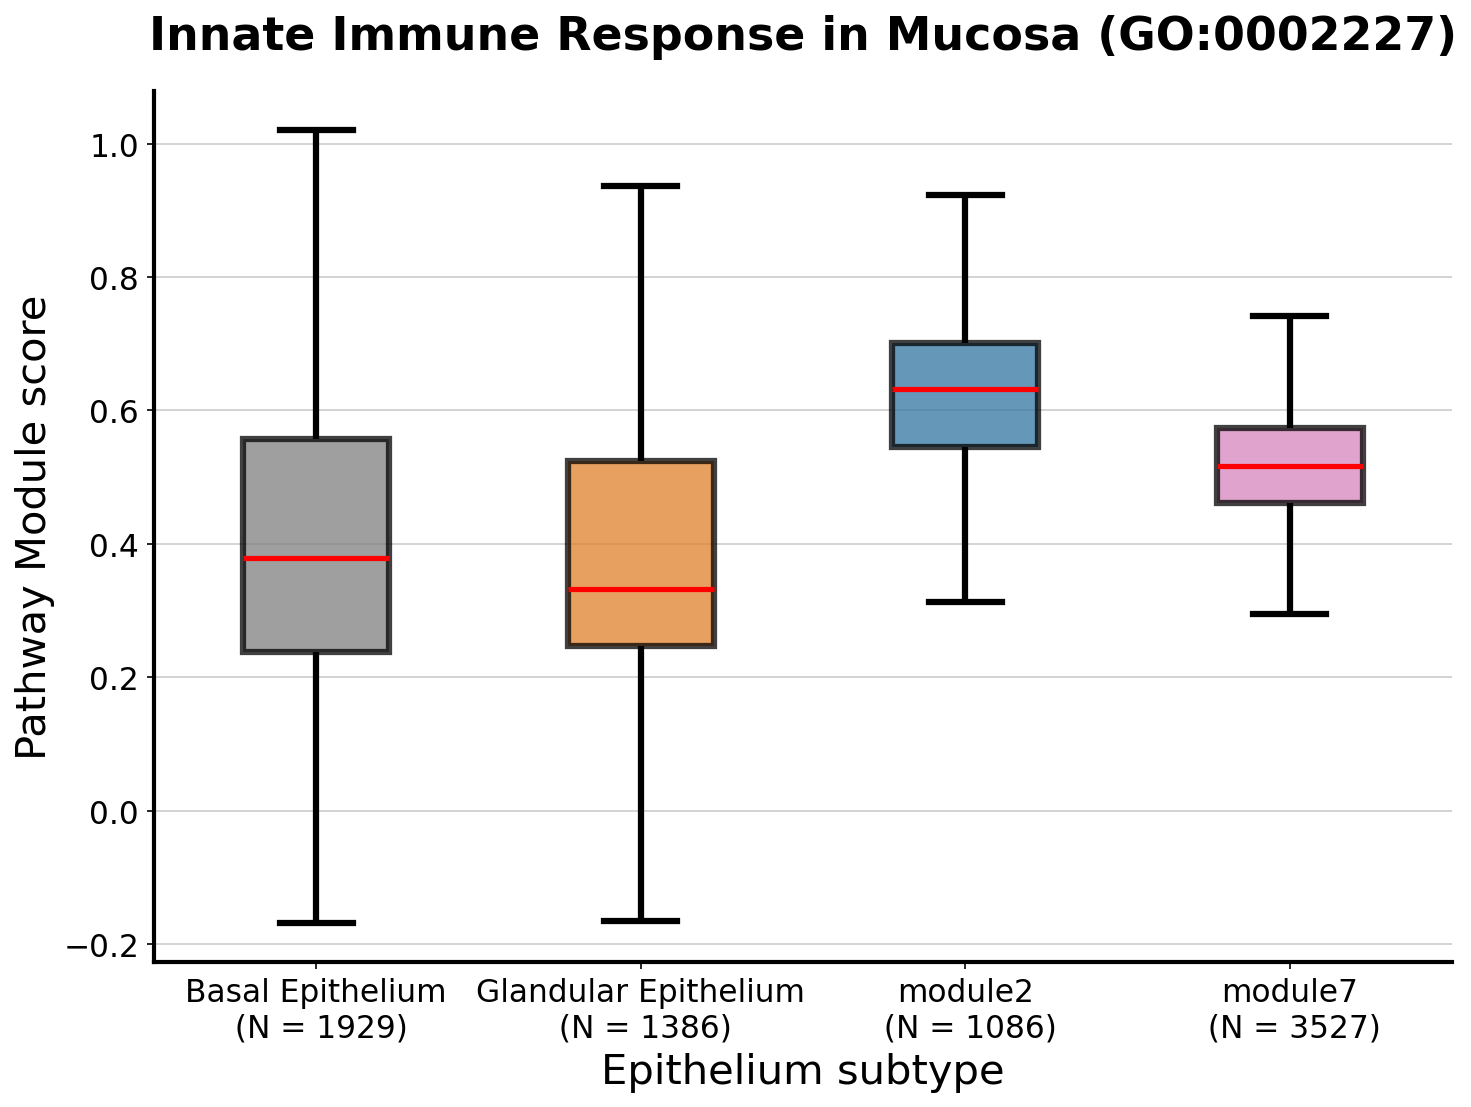

In [137]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, normaltest

leiden_groups = adata.obs['module_cluster']
muscle_system_process_score = adata.obs['EMT_score']

data_df = pd.DataFrame({
    'leiden': leiden_groups, 
    'EMT_score': muscle_system_process_score
})
data_df['leiden'] = pd.Categorical(data_df['leiden'], ordered=True)

plt.rcParams["figure.dpi"] = 75
plt.rcParams["savefig.dpi"] = 75
plt.rcParams["lines.antialiased"] = True

plt.figure(figsize=(10, 8))

palette = {
    "Basal Epithelium": "tab:grey",
    "Glandular Epithelium": "tab:orange",
    "module2": "tab:blue",
    "module7": "tab:pink"
}

sns.boxplot(
    x="leiden",
    y="EMT_score",
    data=data_df,
    palette=palette,
    width=0.45,
    showfliers=False,
    linewidth=2,
    boxprops=dict(edgecolor="black", linewidth=3, alpha=0.75),
    whiskerprops=dict(color="black", linewidth=3),
    capprops=dict(color="black", linewidth=3),
    medianprops=dict(color="red", linewidth=2.5)
)

plt.title("Innate Immune Response in Mucosa (GO:0002227)",
    fontsize=22,
    fontweight="bold",
    pad=20)

# x축 라벨에 N 추가
counts = data_df['leiden'].value_counts().reindex(data_df['leiden'].cat.categories)
ax = plt.gca()
new_labels = [f"{cat}\n (N = {counts[cat]})" for cat in data_df['leiden'].cat.categories]
ax.set_xticklabels(new_labels, fontsize=15)

plt.yticks(fontsize=15)
plt.xlabel("Epithelium subtype", fontsize=20)
plt.ylabel("Pathway Module score", fontsize=20)

sns.despine(ax=ax, top=True, right=True)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Cell module score (Normal)

In [382]:
import scanpy as sc
import pandas as pd

file_path = "/home/Data_Drive_8TB/kykim/1. Oval/Monocle/Luminal_adata.h5ad"
adata = sc.read_h5ad(file_path)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
df = pd.read_csv("/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module_to_cell_metadata.csv", index_col=0)
common_idx = adata.obs.index.intersection(df.index)
adata.obs["module_cluster"] = pd.NA
adata.obs.loc[common_idx, "module_cluster"] = df.loc[common_idx, "module_cluster"]
adata.obs["module_cluster"] = adata.obs["module_cluster"].fillna(adata.obs["subtype"])

In [383]:
adata = adata[adata.obs['subtype'] == 'Luminal Epithelium'].copy()

In [384]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import scanpy.external as sce
from typing import Tuple, Dict 
import gseapy as gp
sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=True)
plt.rcParams['figure.figsize'] = [5, 5]

dblist = ['KEGG_2021_Human','Reactome_Pathways_2024','MSigDB_Hallmark_2020',
         'GO_Biological_Process_2025']

pathway_gene_sets = {}

for db in dblist:
    print(f"Fetching gene sets from {db}...")
    gene_sets = gp.get_library(name=db, organism='Mouse')  # Fetch gene sets for Human
    pathway_gene_sets[db] = gene_sets

print("All gene sets retrieved successfully.")
all_pathway_gene_data = []

for db, pathways in pathway_gene_sets.items():
    print(f"Processing {db}...")
    # Create a DataFrame with Pathway, Gene List, and Database columns
    pathway_data = [{"Pathway": pathway, "GeneList": genes, "Database": db} for pathway, genes in pathways.items()]
    all_pathway_gene_data.extend(pathway_data)

final_gene_list_df = pd.DataFrame(all_pathway_gene_data)
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

human_genes = list(set(final_gene_list_df["GeneList"].explode()))

def human_to_mouse_ortholog(human_genes):
    res = gp.orth(organism="hsapiens", target="mmusculus", query=human_genes)
    return res.dropna(subset=["converted"]).groupby("incoming")["name"].first().to_dict()

orth_map = human_to_mouse_ortholog(human_genes)

final_gene_list_df["GeneList_mouse"] = final_gene_list_df["GeneList"].apply(
    lambda genes: [orth_map[g] for g in genes if g in orth_map])

Fetching gene sets from KEGG_2021_Human...
Fetching gene sets from Reactome_Pathways_2024...
Fetching gene sets from MSigDB_Hallmark_2020...
Fetching gene sets from GO_Biological_Process_2025...
All gene sets retrieved successfully.
Processing KEGG_2021_Human...
Processing Reactome_Pathways_2024...
Processing MSigDB_Hallmark_2020...
Processing GO_Biological_Process_2025...


In [414]:
pathway_rows = final_gene_list_df[final_gene_list_df['Pathway'].str.contains('endome', case=False, na=False)]
pathway_rows

,Pathway,GeneList,Database,GeneList_mouse
79,Endometrial cancer,"[EGF, BAD, AXIN2, AXIN1, BRAF, APC, PIK3CB, PI...",KEGG_2021_Human,"[Egf, Bad, Axin2, Axin1, Braf, Apc, Pik3cb, Pi..."
3475,Endomembrane System Organization (GO:0010256),"[DYNC2H1, TMEM170A, PLEKHA3, GOLPH3L, MAPK15, ...",GO_Biological_Process_2025,"[Dync2h1, Tmem170, Plekha3, Golph3l, Mapk15, D..."


In [415]:
pathway_rows.to_csv(
    "/home/Data_Drive_8TB/kykim/1. Oval/GSEA/pathway_endometrial.csv",
    index=False
)

In [385]:
import pandas as pd

target_index = 2425   # 사용하고 싶은 경로 숫자 입력 

if 0 <= target_index < len(final_gene_list_df):
    target_pathway = final_gene_list_df.loc[target_index, "Pathway"]
    gene_list = final_gene_list_df.loc[target_index, "GeneList_mouse"]
    print(f"Selected Index: {target_index}")
    print(f"Pathway: {target_pathway}")
    print(f"Gene List: {gene_list}")
    gene_df_1 = pd.DataFrame(gene_list, columns=["Gene"])
    
else:
    print(f"Invalid index: {target_index}. Must be between 0 and {len(final_gene_list_df)-1}.")

Selected Index: 2425
Pathway: TGF-beta Signaling
Gene List: ['Tgfb1', 'Acvr1', 'Rhoa', 'Smurf2', 'Smurf1', 'Hipk2', 'Tgfbr1', 'Ppp1ca', 'Cdk9', 'Ski', 'Rab31', 'Apc', 'Bmp2', 'Ncor2', 'Id1', 'Id3', 'Id2', 'Bmpr1a', 'Bcar3', 'Bmpr2', 'Serpine1', 'N/A', 'Ppp1r15a', 'Arid4b', 'Cdh1', 'Map3k7', 'Skil', 'Sptbn1', 'Smad3', 'Wwtr1', 'Tgif1', 'Lefty1', 'Nog', 'Ifngr2', 'Smad1', 'Klf10', 'Smad7', 'Smad6', 'Ppm1a', 'Fkbp1a', 'Tjp1', 'Xiap', 'Eng', 'Trim33', 'Cdkn1c', 'Hdac1', 'Furin', 'Ctnnb1', 'Slc20a1', 'Thbs1', 'Ltbp2', 'Fnta', 'Pmepa1', 'Junb']


In [386]:
geneset = ['Tgfb1', 'Acvr1', 'Rhoa', 'Smurf2', 'Smurf1', 'Hipk2', 'Tgfbr1', 'Ppp1ca', 'Cdk9', 'Ski', 'Rab31', 'Apc', 'Bmp2', 'Ncor2', 'Id1', 'Id3', 'Id2', 'Bmpr1a', 'Bcar3', 'Bmpr2', 'Serpine1', 'N/A', 'Ppp1r15a', 'Arid4b', 'Cdh1', 'Map3k7', 'Skil', 'Sptbn1', 'Smad3', 'Wwtr1', 'Tgif1', 'Lefty1', 'Nog', 'Ifngr2', 'Smad1', 'Klf10', 'Smad7', 'Smad6', 'Ppm1a', 'Fkbp1a', 'Tjp1', 'Xiap', 'Eng', 'Trim33', 'Cdkn1c', 'Hdac1', 'Furin', 'Ctnnb1', 'Slc20a1', 'Thbs1', 'Ltbp2', 'Fnta', 'Pmepa1', 'Junb']


sc.tl.score_genes(adata, geneset , score_name='EMT_score',use_raw=False)

/tmp/ipykernel_1128955/428480713.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_1128955/428480713.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{cat}\n(N = {counts[cat]})" for cat in order], fontsize=15)


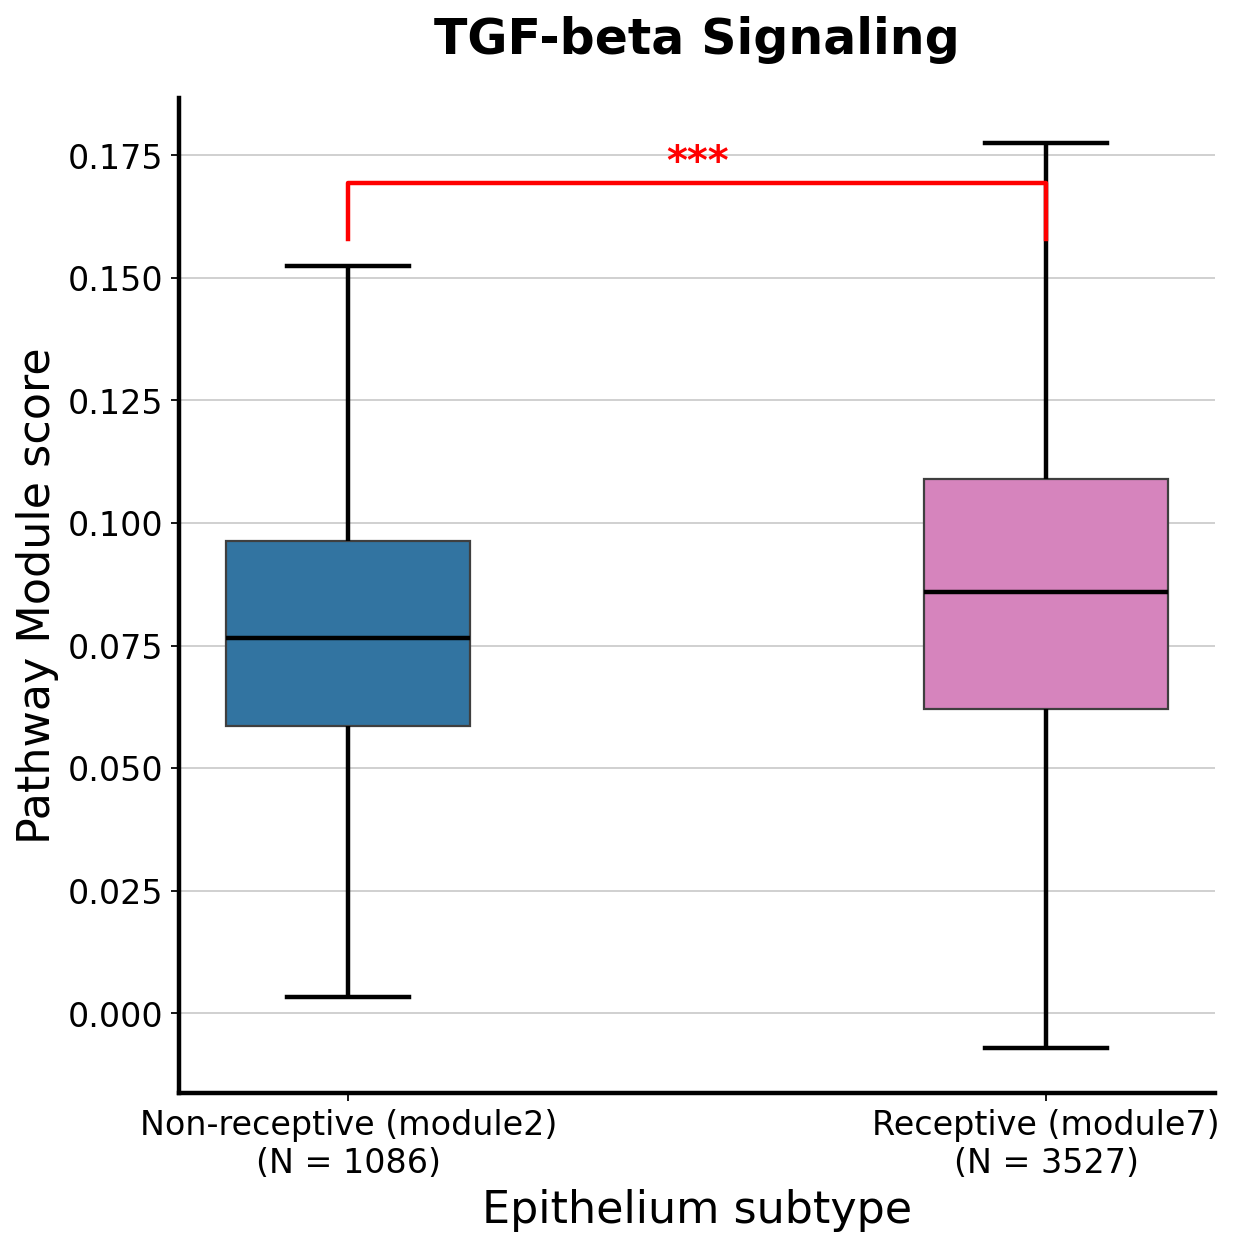

In [393]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import mannwhitneyu

label_map = {
    "B": "Non-receptive (module2)",
    "A": "Receptive (module7)"
}

data_df = pd.DataFrame({
    "leiden": adata.obs["module_cluster"].map(label_map),
    "EMT_score": adata.obs["EMT_score"]
})

data_df = data_df.dropna()

palette = {
    "Non-receptive (module2)": "tab:blue",
    "Receptive (module7)": "tab:pink",
}

order = ["Non-receptive (module2)", "Receptive (module7)"]

plt.figure(figsize=(8, 8))

ax = sns.boxplot(
    x="leiden",
    y="EMT_score",
    data=data_df,
    order=order,
    palette=palette,
    width=0.35,
    showfliers=False
)

for artist in ax.artists:
    artist.set_edgecolor("black")
    artist.set_linewidth(2)

for line in ax.lines:
    line.set_color("black")
    line.set_linewidth(2)

group1 = data_df[data_df["leiden"] == order[0]]["EMT_score"]
group2 = data_df[data_df["leiden"] == order[1]]["EMT_score"]

stat, pval = mannwhitneyu(group1, group2)

if pval < 0.001:
    stars = "***"
elif pval < 0.01:
    stars = "**"
elif pval < 0.05:
    stars = "*"
else:
    stars = "ns"

y_max = data_df["EMT_score"].max()
y_bracket = y_max * 0.7
h = y_max * 0.05

ax.plot([0, 0, 1, 1],
        [y_bracket, y_bracket+h, y_bracket+h, y_bracket],
        lw=2,
        c="red")

ax.text(0.5,
        y_bracket+h,
        stars,
        ha="center",
        va="bottom",
        color="red",
        fontsize=18,
        fontweight="bold")

counts = data_df["leiden"].value_counts().reindex(order)
ax.set_xticklabels([f"{cat}\n(N = {counts[cat]})" for cat in order], fontsize=15)

plt.title("TGF-beta Signaling", fontsize=22, fontweight="bold", pad=20)
plt.yticks(fontsize=15)
plt.xlabel("Epithelium subtype", fontsize=20)
plt.ylabel("Pathway Module score", fontsize=20)

sns.despine(ax=ax, top=True, right=True)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout()
plt.show()

# TENET

In [ ]:
########################################## 
############ TENET preprocess.1 ########## 
########################################## 

In [185]:
import scanpy as sc
import pandas as pd

file_path = "/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Epithelial_subtype_raw.h5ad"
adata = sc.read_h5ad(file_path)

In [186]:
adata = adata[adata.obs['subtype'] != 'Glandular Epithelium'].copy()
adata.layers['counts'] = adata.X

In [187]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000, batch_key="subtype")
adata = adata[:, adata.var['highly_variable']].copy()
adata = adata[adata.obs['subtype'] == 'Luminal Epithelium'].copy()
adata.X = adata.layers['counts'].copy()
genes_to_check = ["Muc1", "Muc4", "Hbegf", "Lif"]

for gene in genes_to_check:
    if gene in adata.var_names:
        print(f"{gene} is present in adata.")
    else:
        print(f"{gene} is NOT present in adata.")

Muc1 is NOT present in adata.
Muc4 is present in adata.
Hbegf is present in adata.
Lif is present in adata.


In [188]:
import anndata as ad

file_path = '/home/Data_Drive_8TB/kykim/1. Oval/Save_data/Before_HVG_raw_clustering(large).h5ad'
adata_raw = sc.read_h5ad(file_path)

genes_to_add = ['Hif1a','Muc1','Muc3','Muc3a','Muc6','Muc2','Muc5ac','Muc5b','Muc16',
                'Mucl1','Mucl2','Muc4','Muc20','Muc13','Lif','Hbegf','Atf3','Sox9','Foxa2',
                'Cxcl15','Fosb','Egr4','Junb','Nrip1','Fos','Ahr','Bcor','Rfx5','Klf6',
                'Nfkb1','Rorb','Klf4','Nr4a1','Hdac4','Meis1','Rela','Egr1','Fosl1','Tcf4']

genes_filtered = [g for g in genes_to_add if g in adata_raw.var_names and g not in adata.var_names]

raw_sub = adata_raw[:, genes_filtered].copy()

adata = ad.concat([adata, raw_sub], axis=1)


for gene in genes_to_check:
    if gene in adata.var_names:
        print(f"{gene} is present in adata.")
    else:
        print(f"{gene} is NOT present in adata.")

Muc1 is present in adata.
Muc4 is present in adata.
Hbegf is present in adata.
Lif is present in adata.


In [189]:
path_module1 = "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module1.txt"
path_module2 = "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module2.txt"
path_module3 = "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module3.txt"
path_module4= "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module4.txt"
path_module5 = "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module5.txt"
path_module6 = "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module6.txt"
path_module7 = "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module7.txt"
path_module8 = "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module8.txt"
path_module9 = "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module9.txt"
path_module10 = "/home/Data_Drive_8TB/kykim/1. Oval/WGCNA/module10.txt"


module1 = pd.read_csv(path_module1, sep='\t', header=None)
module2 = pd.read_csv(path_module2, sep='\t', header=None)
module3 = pd.read_csv(path_module3, sep='\t', header=None)
module4 = pd.read_csv(path_module4, sep='\t', header=None)
module5 = pd.read_csv(path_module5, sep='\t', header=None)
module6 = pd.read_csv(path_module6, sep='\t', header=None)
module7 = pd.read_csv(path_module7, sep='\t', header=None)
module8 = pd.read_csv(path_module8, sep='\t', header=None)
module9 = pd.read_csv(path_module9, sep='\t', header=None)
module10 = pd.read_csv(path_module10, sep='\t', header=None)

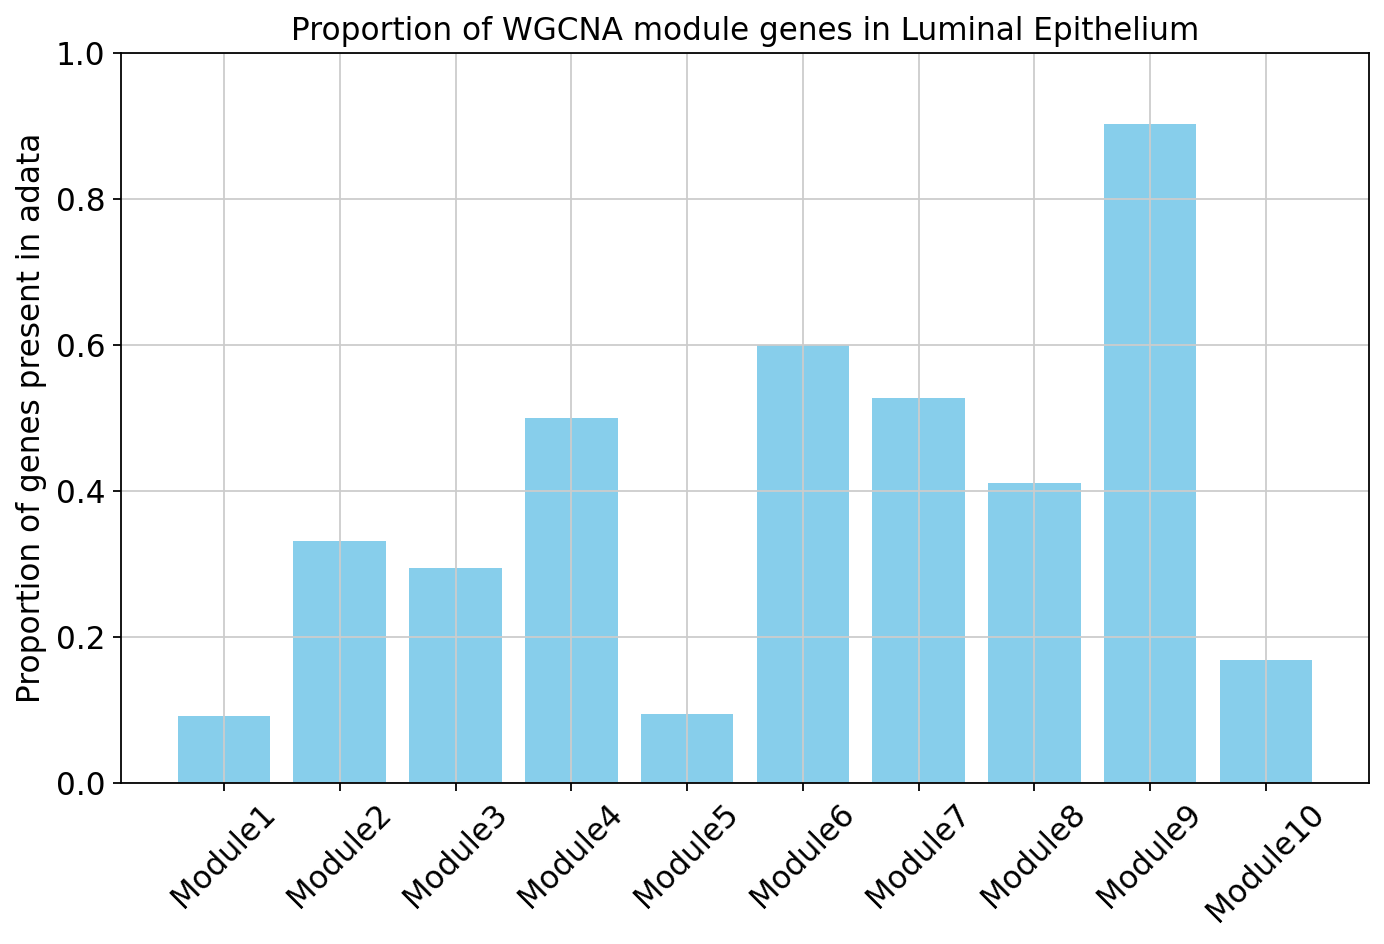

In [190]:
import pandas as pd
import matplotlib.pyplot as plt

modules = [module1, module2, module3, module4, module5,
           module6, module7, module8, module9, module10]

module_names = [f'Module{i}' for i in range(1, 11)]

proportions = []

for mod in modules:
    genes_in_module = mod[0].tolist()
    genes_present = [g for g in genes_in_module if g in adata.var_names]
    prop = len(genes_present) / len(genes_in_module)
    proportions.append(prop)

df_prop = pd.DataFrame({
    'Module': module_names,
    'Proportion': proportions
})

plt.figure(figsize=(10,6))
plt.bar(df_prop['Module'], df_prop['Proportion'], color='skyblue')
plt.ylim(0,1)
plt.ylabel('Proportion of genes present in adata')
plt.title('Proportion of WGCNA module genes in Luminal Epithelium')
plt.xticks(rotation=45)
plt.show()


In [191]:
########################################## 
############ TENET preprocess.2 ############ 
########################################## 

In [192]:
adata.layers["counts"] = adata.X
X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X
count = pd.DataFrame(X, index=adata.obs_names, columns=adata.var_names)
count.to_csv("/home/Data_Drive_8TB/kykim/TENET/TENET-master/expression_data.csv")

In [193]:
data = np.ones(4613, dtype=int)
df = pd.DataFrame(data)
df.to_csv("/home/Data_Drive_8TB/kykim/TENET/TENET-master/cell_select.txt", index=False, header=False)

In [194]:
import pandas as pd

csv_path = "/home/Data_Drive_8TB/kykim/1. Oval/Monocle/trajectory_UMAP_coordinate.csv"
txt_out = "/home/Data_Drive_8TB/kykim/TENET/TENET-master/trajectory.txt"

df = pd.read_csv(csv_path, index_col=0)
df = df.loc[df.index.intersection(adata.obs_names)]
df = df.loc[adata.obs_names]

pseudotime = df["pseudotime"]
pseudotime.to_csv(txt_out, sep='\t', header=False, index=False)

In [151]:
import pandas as pd

df = pd.read_csv("/home/Data_Drive_8TB/kykim/1. Oval/Tenet/From_Basal_to_2/TE_result_matrix.byGRN.fdr0.01.sif", 
                 sep='\t', header=None, names=['source', 'interaction', 'target'])

In [152]:
A = df[df['target'] == 'Muc4']
A.sort_values("interaction", ascending=False)

,source,interaction,target
3843,Tead1,0.097933,Muc4
3193,Mxd1,0.081525,Muc4
2494,Lmo4,0.080983,Muc4
8827,Fosl1,0.076987,Muc4
626,Ifi204,0.072792,Muc4
7756,Hif1a,0.071816,Muc4
6162,Foxc1,0.068415,Muc4


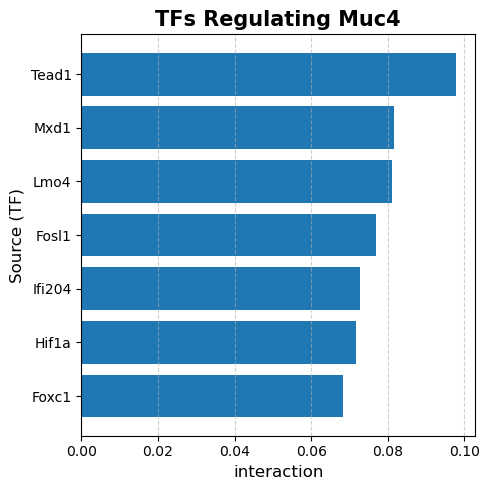

In [163]:
import matplotlib.pyplot as plt

A = df[df['target'] == 'Muc4']
A = A.sort_values("interaction", ascending=False)

plt.figure(figsize=(5, 5))
plt.barh(A["source"], A["interaction"])
plt.gca().invert_yaxis()

plt.xlabel("interaction", fontsize=12)
plt.ylabel("Source (TF)", fontsize=12)
plt.title("TFs Regulating Muc4", fontsize=15, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [197]:
#####################################
########## Mxd1 network  ############
#####################################

In [1]:
import pandas as pd

df = pd.read_csv("/home/Data_Drive_8TB/kykim/1. Oval/Tenet/From_Basal_to_2/TE_result_matrix.byGRN.fdr0.01.sif", 
                 sep='\t', header=None, names=['source', 'interaction', 'target'])

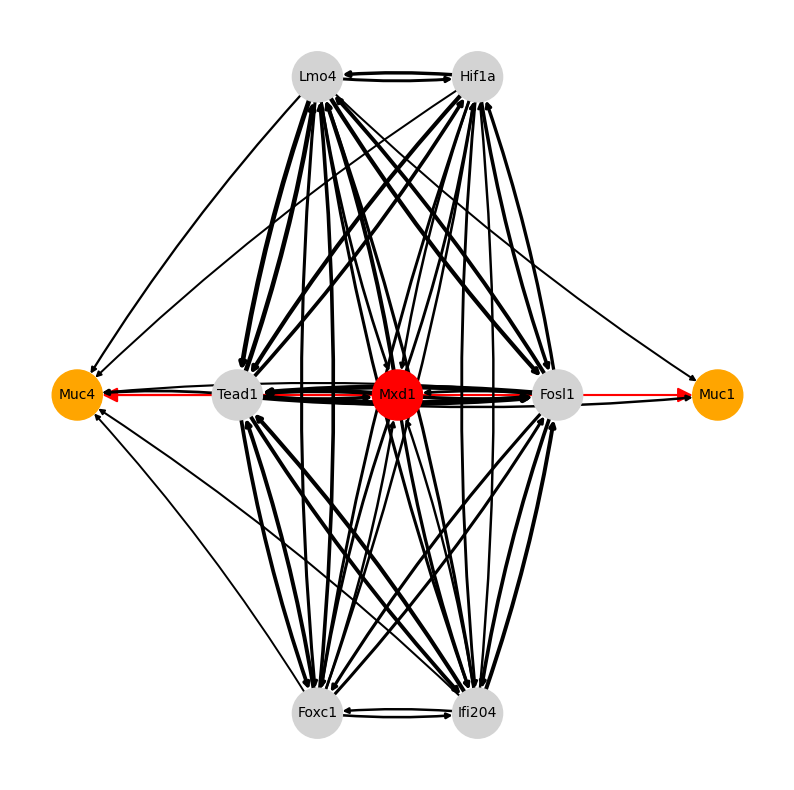

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

G_full = nx.DiGraph()
for _, r in df.iterrows():
    G_full.add_edge(r["source"], r["target"], weight=r["interaction"])

muc_nodes = [n for n in G_full.nodes if n in ["Muc1", "Muc4"]]

nodes_keep = {"Mxd1"}
paths = []

for muc in muc_nodes:
    if nx.has_path(G_full, "Mxd1", muc):
        for p in nx.all_simple_paths(G_full, "Mxd1", muc, cutoff=5):
            if len(p) <= 3:
                paths.append(p)
                nodes_keep.update(p)

G = G_full.subgraph(nodes_keep).copy()

center = ["Mxd1"]
outer = [n for n in G.nodes if n in ["Muc1", "Muc4"]]
middle = [n for n in G.nodes if n not in center + outer]

pos = {}
pos["Mxd1"] = np.array([0.0, 0.0])

theta_mid = np.linspace(0, 2*np.pi, max(len(middle), 1), endpoint=False)
for n, t in zip(middle, theta_mid):
    pos[n] = np.array([0.5*np.cos(t), 0.5*np.sin(t)])

theta_out = np.linspace(0, 2*np.pi, max(len(outer), 1), endpoint=False)
for n, t in zip(outer, theta_out):
    pos[n] = np.array([1.0*np.cos(t), 1.0*np.sin(t)])

direct_edges = []
indirect_edges = []

for u, v in G.edges():
    if u == "Mxd1" and v in ["Muc1", "Muc4"]:
        direct_edges.append((u, v))
    else:
        indirect_edges.append((u, v))

weights = {(u, v): G[u][v]["weight"] * 20 for u, v in G.edges()}

node_colors = []
for n in G.nodes():
    if n == "Mxd1":
        node_colors.append("red")
    elif n in ["Muc1", "Muc4"]:
        node_colors.append("orange")
    else:
        node_colors.append("lightgray")

plt.figure(figsize=(10, 10))

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=1300
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10
)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=direct_edges,
    width=[weights[e] for e in direct_edges],
    edge_color="red",
    arrows=True,
    arrowstyle="-|>",
    arrowsize=22,
    node_size=1300
)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=indirect_edges,
    width=[weights[e] for e in indirect_edges],
    edge_color="black",
    arrows=True,
    arrowstyle="-|>",
    arrowsize=8,
    node_size=1300,
    connectionstyle="arc3,rad=0.05"
)

plt.axis("off")
plt.show()

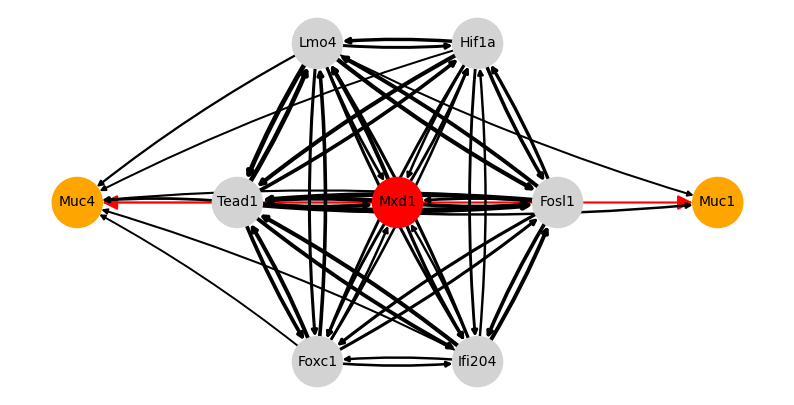

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

G_full = nx.DiGraph()
for _, r in df.iterrows():
    G_full.add_edge(r["source"], r["target"], weight=r["interaction"])

muc_nodes = [n for n in G_full.nodes if n in ["Muc1", "Muc4"]]

nodes_keep = {"Mxd1"}
paths = []

for muc in muc_nodes:
    if nx.has_path(G_full, "Mxd1", muc):
        for p in nx.all_simple_paths(G_full, "Mxd1", muc, cutoff=5):
            if len(p) <= 3:
                paths.append(p)
                nodes_keep.update(p)

G = G_full.subgraph(nodes_keep).copy()

center = ["Mxd1"]
outer = [n for n in G.nodes if n in ["Muc1", "Muc4"]]
middle = [n for n in G.nodes if n not in center + outer]

pos = {}
pos["Mxd1"] = np.array([0.0, 0.0])

theta_mid = np.linspace(0, 2*np.pi, max(len(middle), 1), endpoint=False)
for n, t in zip(middle, theta_mid):
    pos[n] = np.array([0.5*np.cos(t), 0.5*np.sin(t)])

theta_out = np.linspace(0, 2*np.pi, max(len(outer), 1), endpoint=False)
for n, t in zip(outer, theta_out):
    pos[n] = np.array([1.0*np.cos(t), 1.0*np.sin(t)])

direct_edges = []
indirect_edges = []

for u, v in G.edges():
    if u == "Mxd1" and v in ["Muc1", "Muc4"]:
        direct_edges.append((u, v))
    else:
        indirect_edges.append((u, v))

weights = {(u, v): G[u][v]["weight"] * 20 for u, v in G.edges()}

node_colors = []
for n in G.nodes():
    if n == "Mxd1":
        node_colors.append("red")
    elif n in ["Muc1", "Muc4"]:
        node_colors.append("orange")
    else:
        node_colors.append("lightgray")

plt.figure(figsize=(10, 5))

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=1300
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10
)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=direct_edges,
    width=[weights[e] for e in direct_edges],
    edge_color="red",
    arrows=True,
    arrowstyle="-|>",
    arrowsize=22,
    node_size=1300
)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=indirect_edges,
    width=[weights[e] for e in indirect_edges],
    edge_color="black",
    arrows=True,
    arrowstyle="-|>",
    arrowsize=8,
    node_size=1300,
    connectionstyle="arc3,rad=0.05"
)

plt.axis("off")
plt.show()

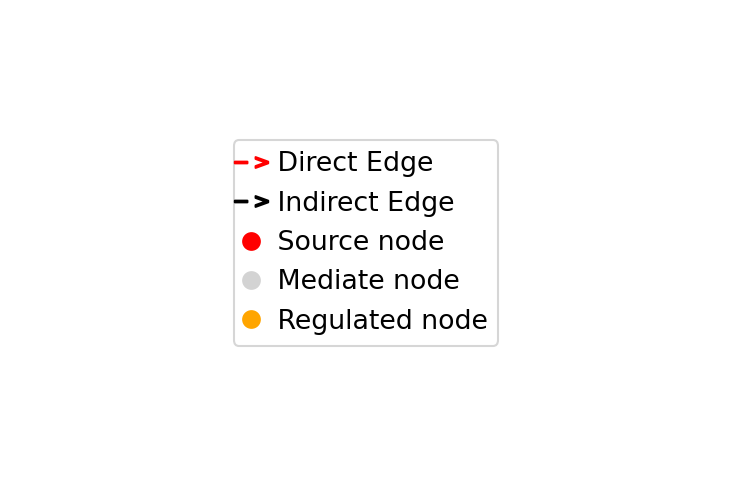

In [272]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(6, 4))

legend_elements = [
    Line2D([0], [0], linestyle="None",
           marker=r"$->$", markersize=16,
           color="red", label=" Direct Edge"),
    Line2D([0], [0], linestyle="None",
           marker=r"$->$", markersize=16,
           color="black", label=" Indirect Edge"),
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="red", markersize=10,
           label=" Source node"),
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="lightgray", markersize=10,
           label=" Mediate node"),
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="orange", markersize=10,
           label=" Regulated node")
]

ax.legend(handles=legend_elements, loc="center", frameon=True)
ax.axis("off")
plt.show()

# DESeq - Pseudobulk

In [2]:
import scanpy as sc
import pandas as pd

file_path = "/home/Data_Drive_8TB/kykim/1. Oval/Monocle/Luminal_adata.h5ad"
adata = sc.read_h5ad(file_path)
adata.X = adata.layers['counts']

In [3]:
adata.obs['module_cluster'].value_counts()

module_cluster
module7                 3527
Basal Epithelium        1929
Glandular Epithelium    1386
module2                 1086
Name: count, dtype: int64

In [4]:
adata = adata[
    (adata.obs['module_cluster'] == 'module2') |
    (adata.obs['module_cluster'] == 'module7'),
    :
].copy()

In [5]:
age_num = adata.obs["age"].str.extract(r"(\d+)").astype(int)[0]

adata.obs["age_group"] = pd.Categorical(
    age_num.apply(lambda x: "Aged" if x >= 20 else "Young"),
    categories=["Young", "Aged"])


In [6]:
import pandas as pd
import os

outdir = "/home/Data_Drive_8TB/kykim/1. Oval/DESeq2/"
os.makedirs(outdir, exist_ok=True)
counts = adata.layers["counts"]
genes = adata.var_names
for mc in adata.obs["celltype_grouped"].unique():
    ad = adata[adata.obs["celltype_grouped"] == mc]
    
    mat = ad.layers["counts"]
    df = pd.DataFrame(
        mat.T.toarray() if hasattr(mat, "toarray") else mat.T,
        index=genes, columns=ad.obs_names)
    
    pb = df.groupby(ad.obs["sample_id"], axis=1).sum()
    pb.to_csv(f"{outdir}/pseudobulk_module_cluster_{mc}.csv")

/tmp/ipykernel_2541176/4092456650.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  pb = df.groupby(ad.obs["sample_id"], axis=1).sum()
/tmp/ipykernel_2541176/4092456650.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pb = df.groupby(ad.obs["sample_id"], axis=1).sum()


In [7]:
outdir = "/home/Data_Drive_8TB/kykim/1. Oval/DESeq2/"
os.makedirs(outdir, exist_ok=True)

df = (
    adata.obs[["sample_id", "age_group","clinical information"]]
    .drop_duplicates()
    .sort_values("sample_id"))
df.to_csv(f"{outdir}/sample_id_age_group.csv", index=False)

In [8]:
###########################
######### After prepreocess

/tmp/ipykernel_2541176/399401400.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_meta.pivot_table(index='sample_id', values='age_group', aggfunc='first')


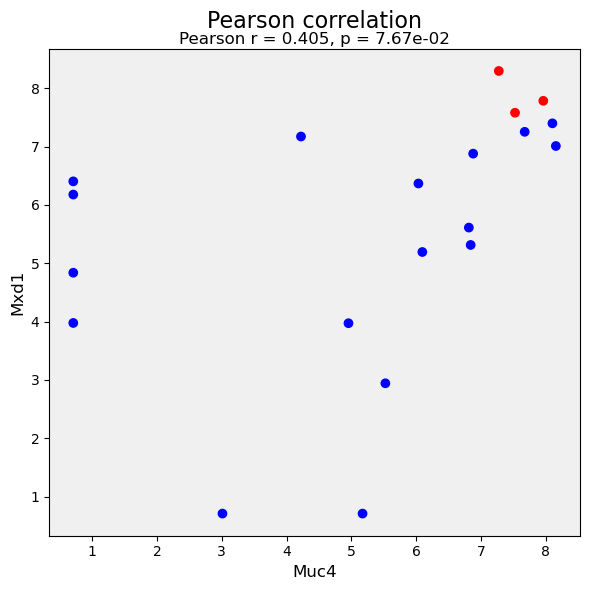

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

df_meta = adata.obs[['sample_id', 'age_group']].drop_duplicates()
pivot = df_meta.pivot_table(index='sample_id', values='age_group', aggfunc='first')
age_map = pivot.to_dict()['age_group']

file = "/home/Data_Drive_8TB/kykim/1. Oval/DESeq2/Total_bulk_rna_vsd_preprocess.csv"

df = pd.read_csv(file, index_col=0)

x = df.loc["Muc4"].values
y = df.loc["Mxd1"].values
colors = ['red' if age_map[s] == "Aged" else 'blue' for s in df.columns]

r, p = pearsonr(x, y)

plt.figure(figsize=(6, 6))
plt.scatter(x, y, c=colors)

if p < 0.05:
    coef = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ys = coef[0] * xs + coef[1]
    plt.plot(xs, ys, linestyle='--', linewidth=4, alpha=0.5)

plt.xlabel("Muc4", fontsize=12)
plt.ylabel("Mxd1", fontsize=12)
plt.title("Pearson correlation", fontsize=16, pad=15)
plt.text(
    0.5, 1.02, f"Pearson r = {r:.3f}, p = {p:.2e}",
    fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)

plt.gca().set_facecolor("#f0f0f0")
plt.tight_layout()
plt.show()

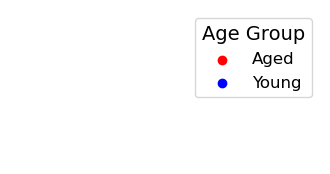

In [10]:
colors = ["red", "blue"]
labels = ["Aged", "Young"]

fig, ax = plt.subplots(figsize=(4, 2))
for color, label in zip(colors, labels):
    ax.scatter([], [], c=color, label=label)

ax.legend(title="Age Group", frameon=True, fontsize=12, title_fontsize=14)
ax.axis('off') 
plt.show()

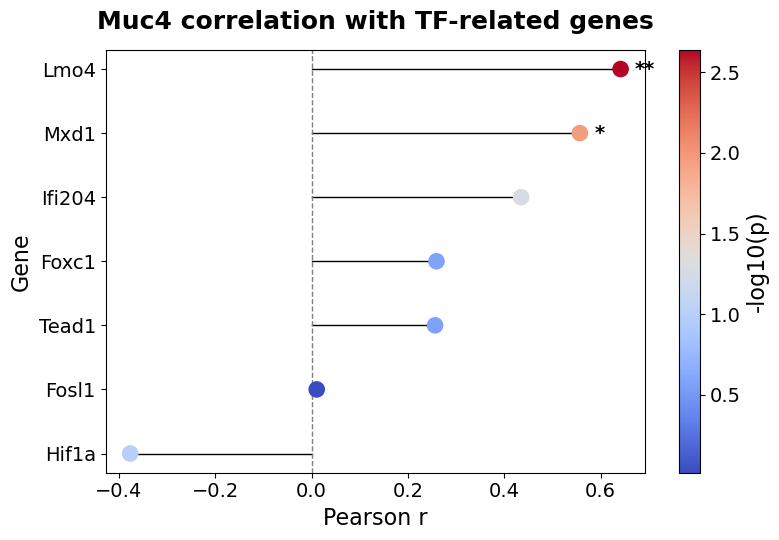

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.colors import Normalize

file = "/home/Data_Drive_8TB/kykim/1. Oval/DESeq2/Total_bulk_rna_rld_preprocess.csv"

targets = ["Tead1", "Mxd1", "Lmo4", "Fosl1", "Ifi204", "Hif1a", "Foxc1"]

df = pd.read_csv(file, index_col=0)

records = []

x = df.loc["Muc4"].values

for gene in targets:
    y = df.loc[gene].values
    r, p = pearsonr(x, y)
    records.append({
        "gene": gene,
        "r": r,
        "p": p,
        "neglogp": -np.log10(p)
    })

df_plot = pd.DataFrame(records)
df_plot = df_plot.sort_values("r", ascending=True).reset_index(drop=True)

norm = Normalize(
    vmin=df_plot["neglogp"].min(),
    vmax=df_plot["neglogp"].max()
)
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(figsize=(8, 5.5))

y_pos = np.arange(len(df_plot))

sc = ax.scatter(
    df_plot["r"],
    y_pos,
    c=df_plot["neglogp"],
    cmap=cmap,
    norm=norm,
    s=120,
    zorder=3
)

for i, r in enumerate(df_plot["r"]):
    ax.plot([0, r], [i, i], color="black", linewidth=1, zorder=2)

    p = df_plot.loc[i, "p"]
    if p < 0.001:
        star = "***"
    elif p < 0.01:
        star = "**"
    elif p < 0.05:
        star = "*"
    else:
        star = ""

    if star:
        ax.text(
            r + 0.03 * np.sign(r if r != 0 else 1),
            i,
            star,
            va="center",
            ha="left" if r >= 0 else "right",
            fontsize=14,
            weight="bold"
        )

ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot["gene"], fontsize=14)

ax.axvline(0, color="grey", linestyle="--", linewidth=1)

ax.set_xlabel("Pearson r", fontsize=16)
ax.set_ylabel("Gene", fontsize=16)

ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("-log10(p)", fontsize=16)
cbar.ax.tick_params(labelsize=14)

ax.set_title(
    "Muc4 correlation with TF-related genes",
    fontsize=18,
    pad=15,
    weight="bold"
)

plt.tight_layout()
plt.show()

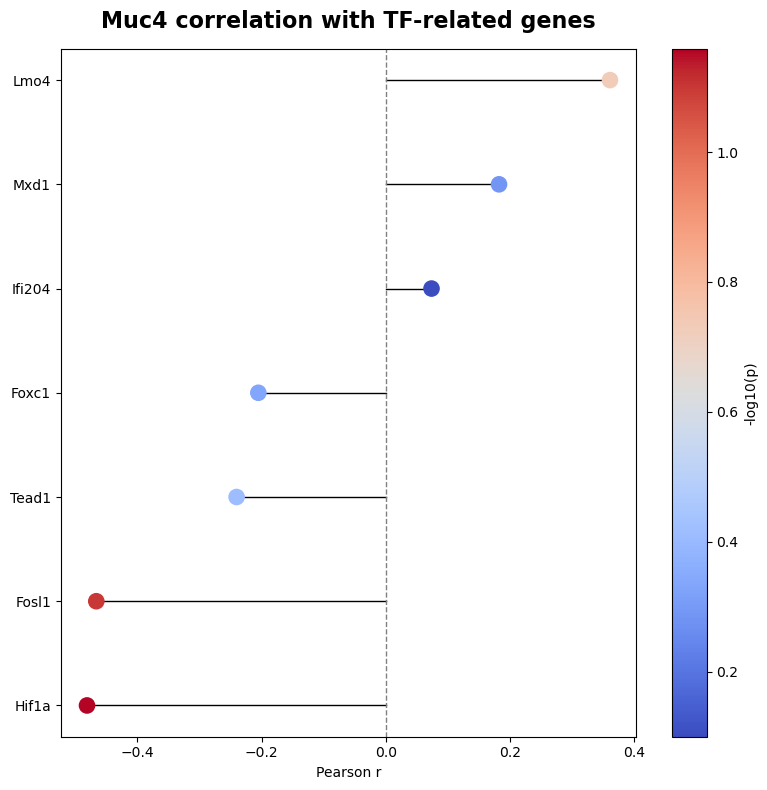

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.colors import Normalize

file = "/home/Data_Drive_8TB/kykim/1. Oval/DESeq2/bulk_rna_rld_preprocess.csv"

targets = ["Tead1", "Mxd1", "Lmo4", "Fosl1", "Ifi204", "Hif1a", "Foxc1"]

df = pd.read_csv(file, index_col=0)

records = []

x = df.loc["Muc4"].values

for gene in targets:
    y = df.loc[gene].values
    r, p = pearsonr(x, y)
    records.append({
        "gene": gene,
        "r": r,
        "p": p,
        "neglogp": -np.log10(p)
    })

df_plot = pd.DataFrame(records)

df_plot = df_plot.sort_values("r", ascending=True).reset_index(drop=True)

norm = Normalize(vmin=df_plot["neglogp"].min(),
                 vmax=df_plot["neglogp"].max())
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(figsize=(8, 8))

y_pos = np.arange(len(df_plot))

sc = ax.scatter(
    df_plot["r"],
    y_pos,
    c=df_plot["neglogp"],
    cmap=cmap,
    norm=norm,
    s=120,
    zorder=3
)

for i, r in enumerate(df_plot["r"]):
    ax.plot([0, r], [i, i], color="black", linewidth=1, zorder=2)

    p = df_plot.loc[i, "p"]
    if p < 0.001:
        star = "***"
    elif p < 0.01:
        star = "**"
    elif p < 0.05:
        star = "*"
    else:
        star = ""

    if star:
        ax.text(
            r + 0.03 * np.sign(r if r != 0 else 1),
            i,
            star,
            va="center",
            ha="left" if r >= 0 else "right",
            fontsize=14,
            weight="bold"
        )

ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot["gene"])
ax.axvline(0, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("Pearson r")

fig.colorbar(sc, ax=ax, label="-log10(p)")

ax.set_title("Muc4 correlation with TF-related genes",
             fontsize=16, pad=15, weight="bold")

plt.tight_layout()
plt.show()

# TGFb signaling pathway

In [29]:
import scanpy as sc
import pandas as pd

file_path = "/home/Data_Drive_8TB/kykim/1. Oval/AUCell/Tgfb/CD8_Module.h5ad"
auc_path = "/home/Data_Drive_8TB/kykim/1. Oval/AUCell/Tgfb/all_cells_all_genesets_AUC_transposed.csv"

adata = sc.read_h5ad(file_path)
adata = adata[adata.obs['organism part'] != 'spleen'].copy()


auc = pd.read_csv(auc_path, index_col=0)

matched = adata.obs.index.intersection(auc.index)
unmatched_n = adata.obs.shape[0] - matched.size

adata.obs["AUcell"] = auc.loc[matched].iloc[:, 0]
print(unmatched_n)

0


In [31]:
adata.obs['module_cluster'].value_counts()

module_cluster
module7             3527
Basal Epithelium    1927
module2             1086
CD8_T_cells          446
Name: count, dtype: int64

/tmp/ipykernel_1714495/1488741469.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df
/tmp/ipykernel_1714495/1488741469.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df["module_cluster"] == "CD8_T_cells"]
/tmp/ipykernel_1714495/1488741469.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df


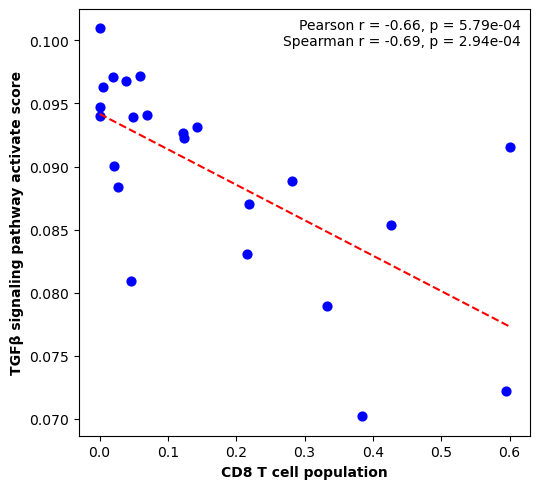

In [23]:
from scipy.stats import pearsonr, spearmanr
import numpy as np
import matplotlib.pyplot as plt

df = adata.obs.copy()

sample_total = (
    df
    .groupby("sample_id")
    .size()
)

sample_cd8 = (
    df[df["module_cluster"] == "CD8_T_cells"]
    .groupby("sample_id")
    .size()
)

cd8_prop = (
    sample_cd8 / sample_total
).fillna(0)

auc_mean = (
    df
    .groupby("sample_id")["AUcell"]
    .mean()
)

common = auc_mean.index.intersection(cd8_prop.index)

x = cd8_prop.loc[common].values
y = auc_mean.loc[common].values

pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

plt.figure(figsize=(5.5, 5))

plt.scatter(x, y, s=40, color="blue")

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

x_sorted = np.sort(x)

plt.plot(
    x_sorted,
    p(x_sorted),
    linestyle="--",
    color="red"
)

plt.xlabel("CD8 T cell population", fontweight="bold")
plt.ylabel("TGFβ signaling pathway activate score", fontweight="bold")

plt.text(
    0.98, 0.98,
    f"Pearson r = {pearson_r:.2f}, p = {pearson_p:.2e}\n"
    f"Spearman r = {spearman_r:.2f}, p = {spearman_p:.2e}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=10
)

plt.grid(False)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1128955/3147969926.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df
/tmp/ipykernel_1128955/3147969926.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df
/tmp/ipykernel_1128955/3147969926.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df["subtype"] == "CD8_T_cells"]


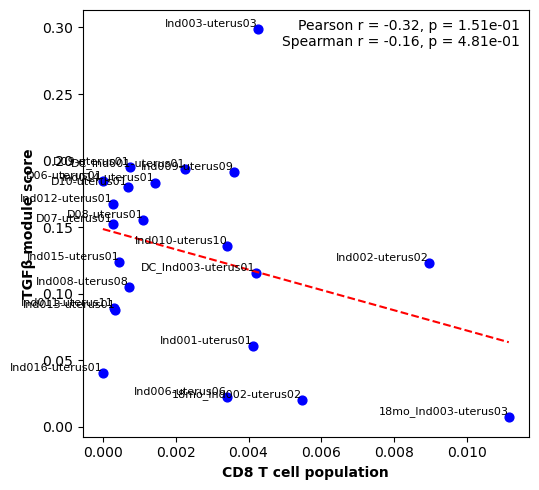

In [103]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

TF = [
'Tgfb1','Acvr1','Rhoa','Smurf2','Smurf1','Hipk2','Tgfbr1','Ppp1ca','Cdk9','Ski',
'Rab31','Apc','Bmp2','Ncor2','Id1','Id3','Id2','Bmpr1a','Bcar3','Bmpr2','Serpine1',
'Ppp1r15a','Arid4b','Cdh1','Map3k7','Skil','Sptbn1','Smad3','Wwtr1','Tgif1',
'Lefty1','Nog','Ifngr2','Smad1','Klf10','Smad7','Smad6','Ppm1a','Fkbp1a','Tjp1',
'Xiap','Eng','Trim33','Cdkn1c','Hdac1','Furin','Ctnnb1','Slc20a1','Thbs1','Ltbp2',
'Fnta','Pmepa1','Junb'
]

TF_valid = [g for g in TF if g in adata.var_names]

sc.tl.score_genes(
    adata,
    gene_list=TF_valid,
    score_name="TGFb_module"
)

df = adata.obs.copy()

module_mean = (
    df
    .groupby("sample_id")["TGFb_module"]
    .mean()
)

sample_total = (
    df
    .groupby("sample_id")
    .size()
)

sample_cd8 = (
    df[df["subtype"] == "CD8_T_cells"]
    .groupby("sample_id")
    .size()
)

cd8_prop = (
    sample_cd8 / sample_total
).fillna(0)

common = module_mean.index.intersection(cd8_prop.index)

x = cd8_prop.loc[common].values
y = module_mean.loc[common].values
labels = common.tolist()

pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

plt.figure(figsize=(5.5, 5))

plt.scatter(
    x,
    y,
    s=40,
    color="blue"
)

for i in range(len(x)):
    plt.text(
        x[i],
        y[i],
        labels[i],
        fontsize=8,
        ha="right",
        va="bottom"
    )

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

x_sorted = np.sort(x)

plt.plot(
    x_sorted,
    p(x_sorted),
    linestyle="--",
    color="red"
)

plt.xlabel(
    "CD8 T cell population",
    fontweight="bold"
)

plt.ylabel(
    "TGFβ module score",
    fontweight="bold"
)

plt.text(
    0.98, 0.98,
    f"Pearson r = {pearson_r:.2f}, p = {pearson_p:.2e}\n"
    f"Spearman r = {spearman_r:.2f}, p = {spearman_p:.2e}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=10
)

plt.grid(False)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1128955/2505540863.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df


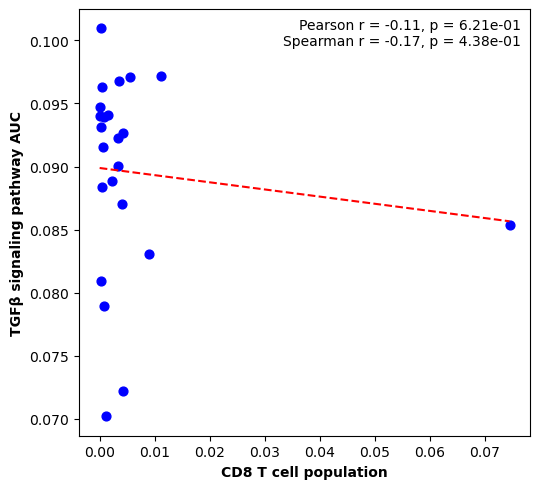

In [130]:
from scipy.stats import pearsonr, spearmanr
import numpy as np
import matplotlib.pyplot as plt

df = adata.obs.copy()

auc_mean = (
    df
    .groupby("Each mouse")["AUcell"]
    .mean()
)

cd8_prop = (
    df_prop[df_prop["subtype"] == "CD8_T_cells"]
    .set_index("Each mouse")["proportion"]
)

common = auc_mean.index.intersection(cd8_prop.index)

x = cd8_prop.loc[common].values
y = auc_mean.loc[common].values

pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

plt.figure(figsize=(5.5, 5))

plt.scatter(
    x,
    y,
    s=40,
    color="blue"
)

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

x_sorted = np.sort(x)
plt.plot(
    x_sorted,
    p(x_sorted),
    linestyle="--",
    color="red"
)

plt.xlabel(
    "CD8 T cell population",
    fontweight="bold"
)
plt.ylabel(
    "TGFβ signaling pathway AUC",
    fontweight="bold"
)

plt.text(
    0.98, 0.98,
    f"Pearson r = {pearson_r:.2f}, p = {pearson_p:.2e}\n"
    f"Spearman r = {spearman_r:.2f}, p = {spearman_p:.2e}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=10
)

plt.grid(False)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1128955/2505540863.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df


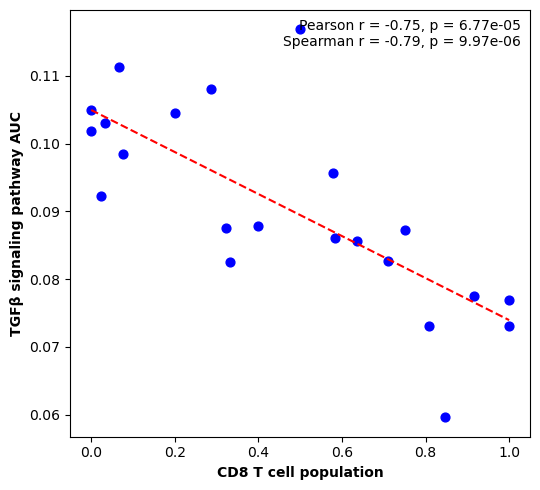

In [75]:
from scipy.stats import pearsonr, spearmanr
import numpy as np
import matplotlib.pyplot as plt

df = adata.obs.copy()

auc_mean = (
    df
    .groupby("Each mouse")["AUcell"]
    .mean()
)

cd8_prop = (
    df_prop[df_prop["subtype"] == "CD8_T_cells"]
    .set_index("Each mouse")["proportion"]
)

common = auc_mean.index.intersection(cd8_prop.index)

x = cd8_prop.loc[common].values
y = auc_mean.loc[common].values

pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

plt.figure(figsize=(5.5, 5))

plt.scatter(
    x,
    y,
    s=40,
    color="blue"
)

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

x_sorted = np.sort(x)
plt.plot(
    x_sorted,
    p(x_sorted),
    linestyle="--",
    color="red"
)

plt.xlabel(
    "CD8 T cell population",
    fontweight="bold"
)
plt.ylabel(
    "TGFβ signaling pathway AUC",
    fontweight="bold"
)

plt.text(
    0.98, 0.98,
    f"Pearson r = {pearson_r:.2f}, p = {pearson_p:.2e}\n"
    f"Spearman r = {spearman_r:.2f}, p = {spearman_p:.2e}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=10
)

plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
adata = adata[adata.obs['organism part'] != 'spleen'].copy()

/tmp/ipykernel_1128955/1912045888.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df
/tmp/ipykernel_1128955/1912045888.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df


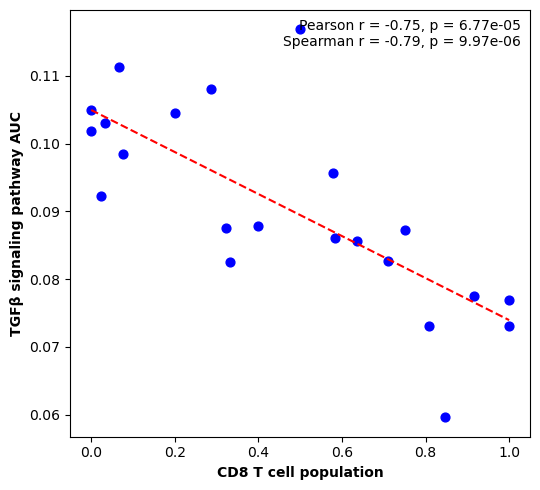

In [5]:
from scipy.stats import pearsonr, spearmanr
import numpy as np
import matplotlib.pyplot as plt

df = adata.obs.copy()

auc_mean = (
    df
    .groupby("sample_id")["AUcell"]
    .mean()
)

cd8_prop = (
    df
    .assign(is_cd8=df["module_cluster"] == "CD8_T_cells")
    .groupby("sample_id")["is_cd8"]
    .mean()
)

common = auc_mean.index.intersection(cd8_prop.index)

# x,y transpose
x = cd8_prop.loc[common].values
y = auc_mean.loc[common].values

pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

plt.figure(figsize=(5.5, 5))

plt.scatter(
    x,
    y,
    s=40,
    color="blue"
)

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

x_sorted = np.sort(x)
plt.plot(
    x_sorted,
    p(x_sorted),
    linestyle="--",
    color="red"
)

plt.xlabel(
    "CD8 T cell population",
    fontweight="bold"
)
plt.ylabel(
    "TGFβ signaling pathway AUC",
    fontweight="bold"
)

plt.text(
    0.98, 0.98,
    f"Pearson r = {pearson_r:.2f}, p = {pearson_p:.2e}\n"
    f"Spearman r = {spearman_r:.2f}, p = {spearman_p:.2e}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=10
)

plt.grid(False)
plt.tight_layout()
plt.show()

In [5]:
adata = adata[adata.obs['module_cluster'] != 'CD8_T_cells'].copy()

/tmp/ipykernel_1128955/4099442959.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["module_cluster","Each mouse"])["AUcell"]


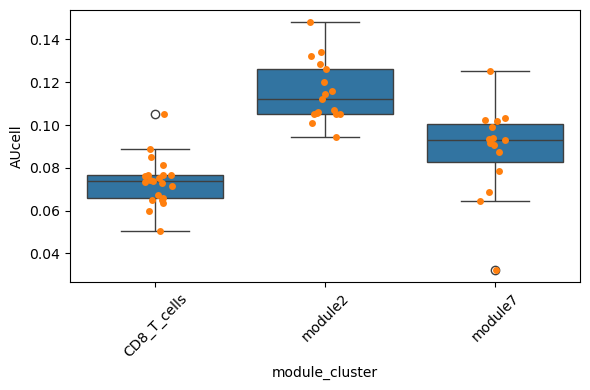

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = adata.obs[["module_cluster","Each mouse","AUcell"]].copy()

mean_df = (
    df.groupby(["module_cluster","Each mouse"])["AUcell"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(6,4))
sns.boxplot(data=mean_df, x="module_cluster", y="AUcell")
sns.stripplot(data=mean_df, x="module_cluster", y="AUcell", dodge=True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Local TE

In [119]:
import pandas as pd
file_path = "/home/NAS/kykim/to_hs/Tenet/LocalTE_TF_GN_fdr_0_01_indirect_trim_0.parquet"
df = pd.read_parquet(file_path)

In [120]:
df['real_time'] = df['Time'].str.replace('t', '').astype(int)

In [121]:
real_time_sorted = sorted(df['real_time'].unique())
count_sorted = count.sort_values('pseudotime').reset_index()
pseudotime_to_barcodes = count_sorted.groupby('pseudotime')['index'].apply(list).to_dict()
for pt, barcodes in list(pseudotime_to_barcodes.items())[:5]:
    print(f"pseudotime {pt}: {len(barcodes)}개 바코드")

np.random.seed(42)

mapping = {}
count_idx = 0

for real_time_val in real_time_sorted:
    pseudotime_val = count_sorted.loc[count_idx, 'pseudotime']
    available_barcodes = pseudotime_to_barcodes[pseudotime_val]
    if len(available_barcodes) > 0:
        selected_barcode = np.random.choice(available_barcodes)
        pseudotime_to_barcodes[pseudotime_val].remove(selected_barcode)
    else:
        selected_barcode = None
    
    mapping[real_time_val] = {
        'pseudotime': pseudotime_val,
        'barcode': selected_barcode
    }
    count_idx += 1

df['pseudotime'] = df['real_time'].map(lambda x: mapping[x]['pseudotime'])
df['barcode'] = df['real_time'].map(lambda x: mapping[x]['barcode'])
print(f"\n매핑 완료: {len(mapping)}개의 real_time에 대해 pseudotime과 barcode 할당")

pseudotime 0.0: 79개 바코드
pseudotime 1.28e-06: 12개 바코드
pseudotime 2.55e-06: 10개 바코드
pseudotime 3.83e-06: 7개 바코드
pseudotime 5.1e-06: 5개 바코드

매핑 완료: 4726개의 real_time에 대해 pseudotime과 barcode 할당


In [122]:
adata.obs["age_num"] = adata.obs["age"].str.extract(r"(\d+)").astype(int)
adata.obs['age_group'] = np.where(adata.obs['age_num'] > 70, 'Aged', 'Young')
df = df.merge(
    adata.obs[['subtype', 'age_group','predict_module']],
    left_on='barcode',
    right_index=True,
    how='left'
)

In [123]:
cell_info = df[['barcode', 'real_time', 'subtype', 'age_group','pseudotime','predict_module']].drop_duplicates(subset='barcode')

In [124]:
################################################
################ Muc4 ##########################
################################################

In [125]:
muc = df[df['Target'] == 'Muc4'].copy()

In [126]:
len(muc['Source'].unique())

279

In [127]:
subset = muc[(muc['real_time'] >= 3250.00) & (muc['real_time'] <= 3750.00)]
result = subset.groupby('Source')['TE'].apply(lambda x: x.max() - x.min()).sort_values(ascending=False).head(20)
result_list = result.index.tolist()
result, result_list

(Source
 Fosb     8.290649
 Egr4     8.281860
 Junb     8.257080
 Nrip1    8.213501
 Fos      8.187134
 Atf3     8.174194
 Ahr      8.172852
 Bcor     8.091309
 Rfx5     8.049316
 Klf6     8.028564
 Nfkb1    7.863159
 Rorb     7.730469
 Klf4     7.688965
 Nr4a1    7.614746
 Hdac4    7.472168
 Meis1    7.244690
 Rela     7.213013
 Egr1     7.206787
 Fosl1    7.206055
 Tcf4     7.181396
 Name: TE, dtype: float64,
 ['Fosb',
  'Egr4',
  'Junb',
  'Nrip1',
  'Fos',
  'Atf3',
  'Ahr',
  'Bcor',
  'Rfx5',
  'Klf6',
  'Nfkb1',
  'Rorb',
  'Klf4',
  'Nr4a1',
  'Hdac4',
  'Meis1',
  'Rela',
  'Egr1',
  'Fosl1',
  'Tcf4'])

In [128]:
subset = muc[(muc['real_time'] >= 0)]
top_sources = set(subset.groupby('Source')['TE'].mean().sort_values(ascending=False).head(279).index)

for name, module in {'module1': module1, 'module9': module9, 'module10': module10}.items():
    module_genes = set(module.iloc[:, 0].astype(str))
    overlap = module_genes & top_sources
    print(f"{name} overlaps ({len(overlap)}):", sorted(overlap))


module1 overlaps (1): ['Rel']
module9 overlaps (37): ['Atf3', 'Atf5', 'Bach1', 'Chd2', 'Egr1', 'Emx2', 'Fos', 'Fosb', 'Fosl1', 'Foxa1', 'Foxc1', 'Foxn1', 'Hmgb2', 'Ier2', 'Ifi204', 'Ifi211', 'Irf1', 'Irf6', 'Jun', 'Klf3', 'Klf4', 'Klf7', 'Lmo4', 'Macc1', 'Meis2', 'Mxd1', 'Myb', 'Nfkb1', 'Nr3c1', 'Nsd2', 'Pbx1', 'Runx1', 'Setx', 'Smad3', 'Sp3', 'Tead1', 'Tfap2c']
module10 overlaps (2): ['Cebpd', 'Maff']


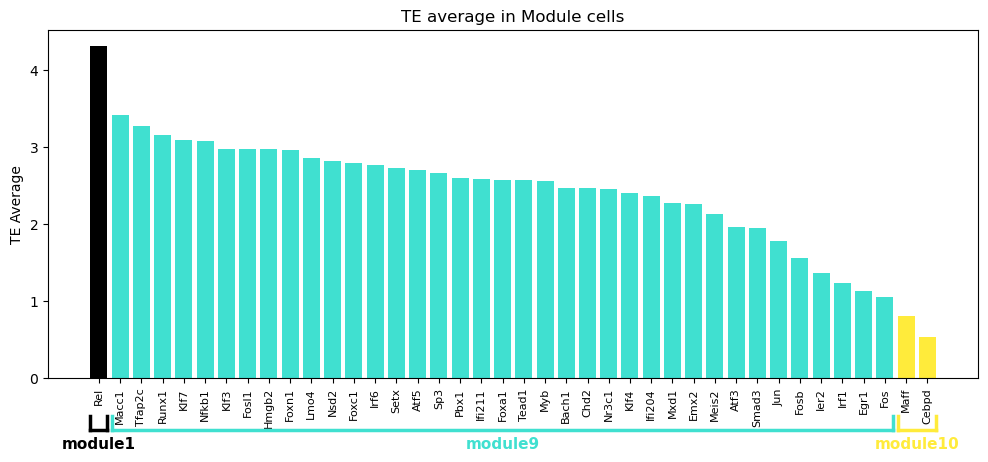

In [129]:
import pandas as pd
import matplotlib.pyplot as plt

module_overlaps = {
    "module1": ['Rel'],
    "module9": ['Atf3', 'Atf5', 'Bach1', 'Chd2', 'Egr1', 'Emx2', 'Fos', 'Fosb', 'Fosl1',
                'Foxa1', 'Foxc1', 'Foxn1', 'Hmgb2', 'Ier2', 'Ifi204', 'Ifi211', 'Irf1',
                'Irf6', 'Jun', 'Klf3', 'Klf4', 'Klf7', 'Lmo4', 'Macc1', 'Meis2', 'Mxd1',
                'Myb', 'Nfkb1', 'Nr3c1', 'Nsd2', 'Pbx1', 'Runx1', 'Setx', 'Smad3',
                'Sp3', 'Tead1', 'Tfap2c'],
    "module10": ['Cebpd', 'Maff']
}

data_list = []
for module, genes in module_overlaps.items():
    subset = muc[(muc['Source'].isin(genes)) & (muc['predict_module'] == module)]
    if not subset.empty:
        df_mean = subset.groupby('Source', as_index=False)['TE'].mean()
        df_mean['Module'] = module
        data_list.append(df_mean)

plot_df = pd.concat(data_list, ignore_index=True)
colors = {'module1': 'black', 'module9': 'turquoise', 'module10': '#FFEB3B'}

plot_df['Module_order'] = plot_df['Module'].map({'module1': 1, 'module9': 2, 'module10': 3})
plot_df = plot_df.sort_values(['Module_order', 'TE'], ascending=[True, False]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
x_pos = range(len(plot_df))

ax.bar(x_pos, plot_df['TE'], color=plot_df['Module'].map(colors))
ax.set_xticks(x_pos)
ax.set_xticklabels(plot_df['Source'], fontsize=8, rotation=90)
ax.set_ylabel('TE Average')
ax.set_title('TE average in Module cells')

module_boundaries = []
start = 0
for module in plot_df['Module'].unique():
    n = len(plot_df[plot_df['Module'] == module])
    end = start + n - 1
    module_boundaries.append((module, start, end))
    start = end + 1

for module, start_idx, end_idx in module_boundaries:
    x_start = start_idx
    x_end = end_idx
    x_mid = (x_start + x_end) / 2
    
    trans = ax.get_xaxis_transform()
    bracket_y = -0.15
    bracket_height = 0.04
    
    ax.plot([x_start - 0.4, x_end + 0.4], [bracket_y, bracket_y], 
            color=colors[module], linewidth=2.5, transform=trans, clip_on=False)
    ax.plot([x_start - 0.4, x_start - 0.4], [bracket_y, bracket_y + bracket_height], 
            color=colors[module], linewidth=2.5, transform=trans, clip_on=False)
    ax.plot([x_end + 0.4, x_end + 0.4], [bracket_y, bracket_y + bracket_height], 
            color=colors[module], linewidth=2.5, transform=trans, clip_on=False)
    
    ax.text(x_mid, bracket_y - 0.02, module, 
            ha='center', va='top', fontsize=11, fontweight='bold', 
            color=colors[module], transform=trans, clip_on=False)

plt.subplots_adjust(bottom=0.3)
plt.show()

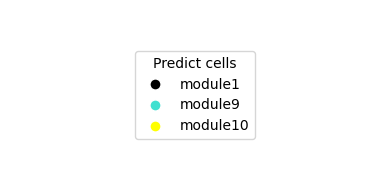

In [132]:
import matplotlib.pyplot as plt

color_dict = {'module1': 'black', 'module9': 'turquoise', 'module10': 'yellow'}
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=module)
           for module, color in color_dict.items()]

plt.figure(figsize=(4,2))  # 범례 크기 조절
plt.legend(handles=handles, title='Predict cells', loc='center')
plt.axis('off')  # 축 제거
plt.tight_layout()
plt.show()

In [133]:
unique_df = df[['real_time', 'predict_module']].drop_duplicates().reset_index(drop=True)

/tmp/ipykernel_1444045/406078083.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_mean = unique_df.groupby(pd.cut(unique_df['real_time'], bins))['mask'].mean().fillna(0).values
/tmp/ipykernel_1444045/406078083.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_counts = unique_df.groupby(pd.cut(unique_df['real_time'], bins))['mask'].count().values
/tmp/ipykernel_1444045/406078083.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future defau

Pseudotime range: 3250.00 to 3750.00


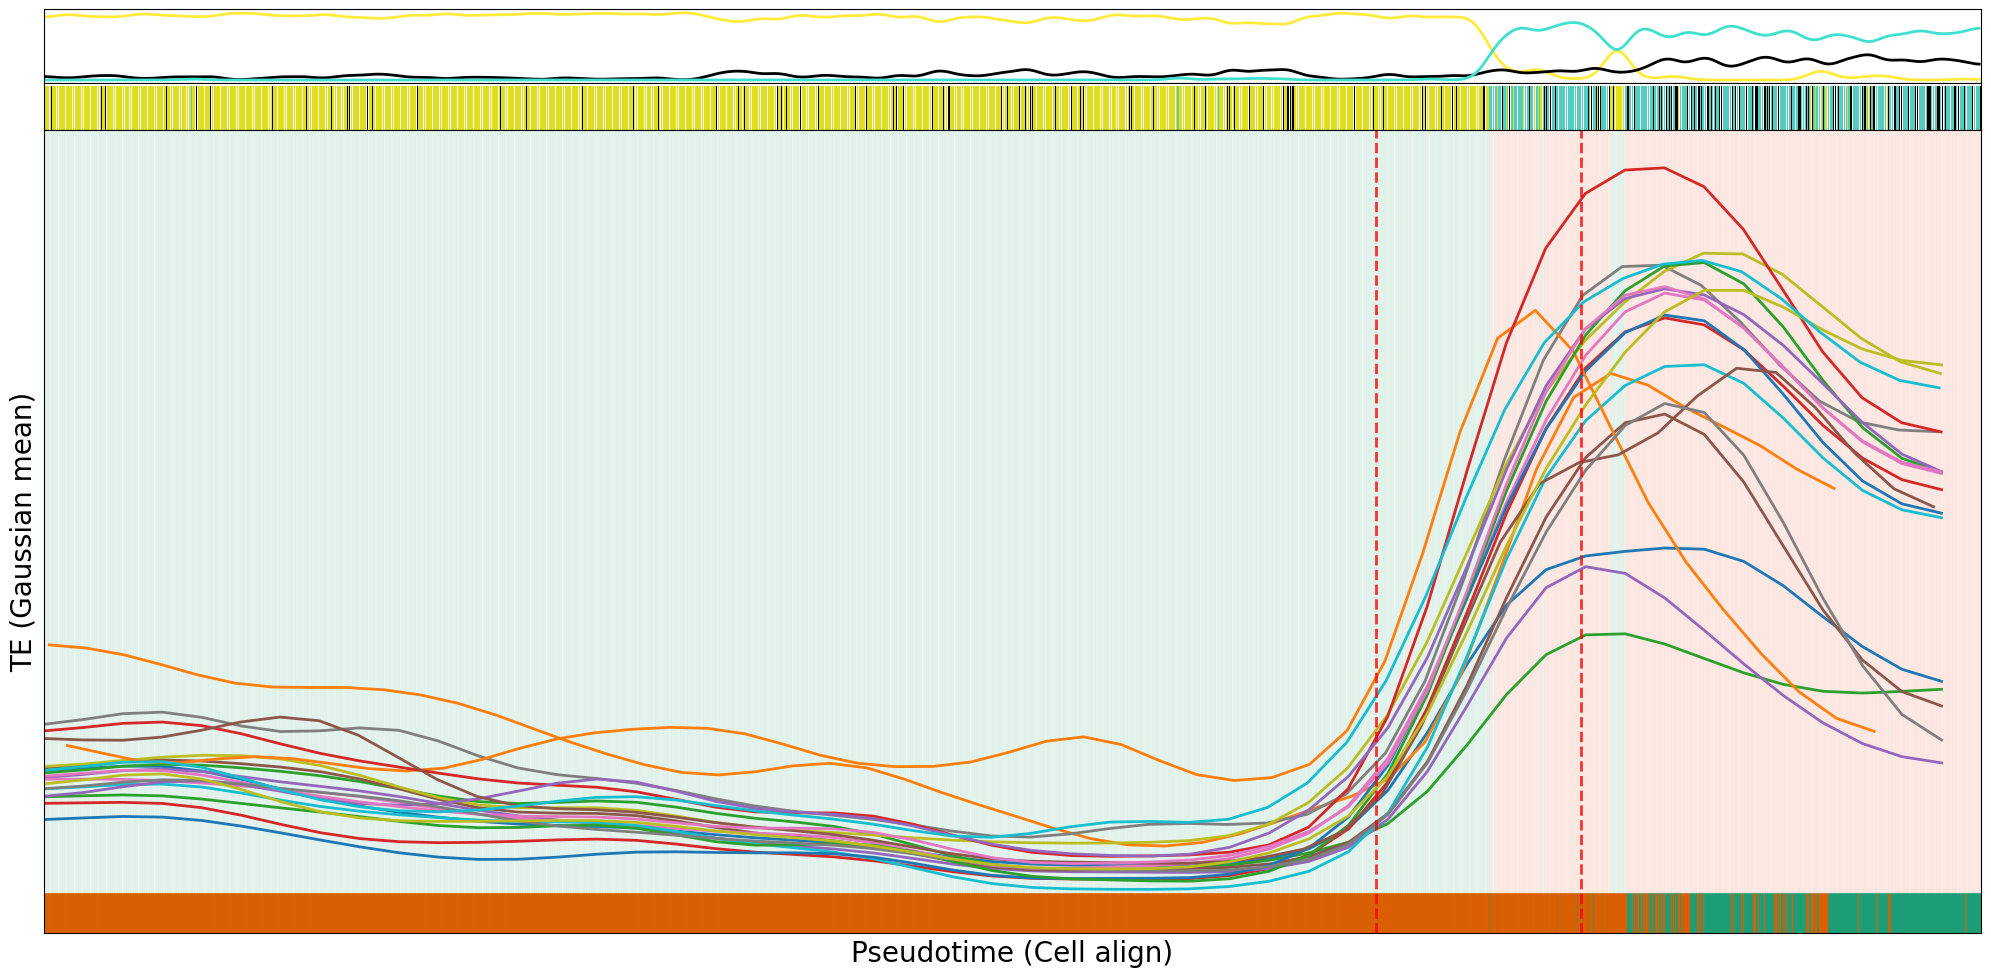

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.ndimage import gaussian_filter1d

top_sources_mean = pd.Series(
    data=[0]*20,
    index=result_list,
    name='TE'
)

line_color_dict = {'module1': 'black', 'module9': 'turquoise', 'module10': '#FFEB3B'}
bar_color_dict = {'module1': 'black', 'module9': 'turquoise', 'module10': 'yellow'}

fig = plt.figure(figsize=(25, 12))
gs = fig.add_gridspec(3, 1, height_ratios=[0.08, 0.05, 0.87], hspace=0.0)

# Line plot for modules
ax_line = fig.add_subplot(gs[0])
num_bins = 500
bins = np.linspace(unique_df['real_time'].min(), unique_df['real_time'].max(), num_bins + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2

for module in unique_df['predict_module'].unique():
    mask = (unique_df['predict_module'] == module).astype(int)
    unique_df['mask'] = mask.values
    binned_mean = unique_df.groupby(pd.cut(unique_df['real_time'], bins))['mask'].mean().fillna(0).values
    binned_counts = unique_df.groupby(pd.cut(unique_df['real_time'], bins))['mask'].count().values
    weight = np.minimum(binned_counts / 500, 1)
    weighted_mean = binned_mean * weight
    smooth = gaussian_filter1d(weighted_mean, sigma=3)
    ax_line.plot(bin_centers, smooth, linewidth=2, color=line_color_dict[module])

ax_line.set_yticks([])
ax_line.set_xticks([])
ax_line.set_xlabel('')

# Bar plot for modules
ax_bar = fig.add_subplot(gs[1], sharex=ax_line)
sns.barplot(
    data=unique_df.sort_values('real_time'),
    x='real_time',
    y=[1]*len(unique_df),
    hue='predict_module',
    dodge=False,
    palette=bar_color_dict,
    legend=False,
    ax=ax_bar
)
ax_bar.set_yticks([])
ax_bar.set_xticks([])
ax_bar.set_xlabel('')

# TE plot for top 10 sources
ax_te = fig.add_subplot(gs[2], sharex=ax_line)
top10_sources = top_sources_mean.copy().index
df_top10 = df[df["Source"].isin(top10_sources)]

if 'real_time' not in cell_info.columns:
    cell_info['real_time'] = cell_info['Time']

subtype_groups = sorted(cell_info['subtype'].dropna().unique())
subtype_colors = dict(zip(subtype_groups, sns.color_palette('Set2', n_colors=len(subtype_groups))))
subtype_alpha = 0.05

age_groups = sorted(cell_info['age_group'].dropna().unique())
age_colors = dict(zip(age_groups, sns.color_palette('Dark2', n_colors=len(age_groups))))

gene_palette = sns.color_palette("tab10", n_colors=len(top10_sources))

max_te = 0
for i, src in enumerate(top10_sources, start=1):
    sub = df_top10[df_top10["Source"] == src].sort_values("real_time")
    if sub.empty:
        continue

    x_min = sub['real_time'].min()
    x_max = sub['real_time'].max()
    bins_te = np.linspace(x_min, x_max, 50)
    digitized = np.digitize(sub["real_time"], bins_te)
    binned_mean = [sub["TE"][digitized == j].mean() for j in range(1, len(bins_te))]
    smooth = gaussian_filter1d(np.nan_to_num(binned_mean, nan=np.nanmean(binned_mean)), sigma=2)

    ax_te.plot(bins_te[:-1], smooth, lw=2, color=gene_palette[i-1], label=f"Top{i}: {src}")
    max_te = max(max_te, np.nanmax(smooth))

# Subtype shading
for age in subtype_groups:
    subset = cell_info[cell_info['subtype'] == age]
    for x in subset['real_time']:
        ax_te.axvspan(x, x, color=subtype_colors[age], alpha=subtype_alpha)

# Age group shading
y0, y1 = -0.05*max_te, 0
for age in age_groups:
    subset = cell_info[cell_info['age_group'] == age]
    for x in subset['real_time']:
        if x < df_top10['real_time'].min() or x > df_top10['real_time'].max():
            continue
        ax_te.axvspan(x, x, ymin=0, ymax=0.05, color=age_colors[age], alpha=0.8, transform=ax_te.get_xaxis_transform())

ax_te.set_xlabel("Pseudotime (Cell align)", fontsize=20)
ax_te.set_ylabel("TE (Gaussian mean)", fontsize=20)
ax_te.set_ylim(0, max_te*1.05)
ax_te.set_yticks([])
ax_te.set_xlim(df_top10['real_time'].min(), df_top10['real_time'].max())

start_time = 3250.0
end_time = 3750.0
ax_te.axvline(start_time, color='red', linestyle='--', linewidth=2, alpha=0.8)
ax_te.axvline(end_time, color='red', linestyle='--', linewidth=2, alpha=0.8)

print(f"Pseudotime range: {start_time:.2f} to {end_time:.2f}")
plt.show()


In [135]:
start_time = 3250.0
end_time = 3750.0

subset = unique_df[(unique_df['real_time'] >= start_time) & (unique_df['real_time'] <= end_time)]
module_counts = subset['predict_module'].value_counts()
module_proportion = module_counts / module_counts.sum()

print(module_proportion)

predict_module
module10    0.558882
module9     0.347305
module1     0.093812
Name: count, dtype: float64


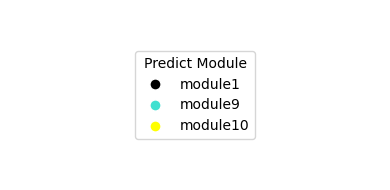

In [136]:
import matplotlib.pyplot as plt

color_dict = {'module1': 'black', 'module9': 'turquoise', 'module10': 'yellow'}
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=module)
           for module, color in color_dict.items()]

plt.figure(figsize=(4,2))  # 범례 크기 조절
plt.legend(handles=handles, title='Predict Module', loc='center')
plt.axis('off')  # 축 제거
plt.tight_layout()
plt.show()

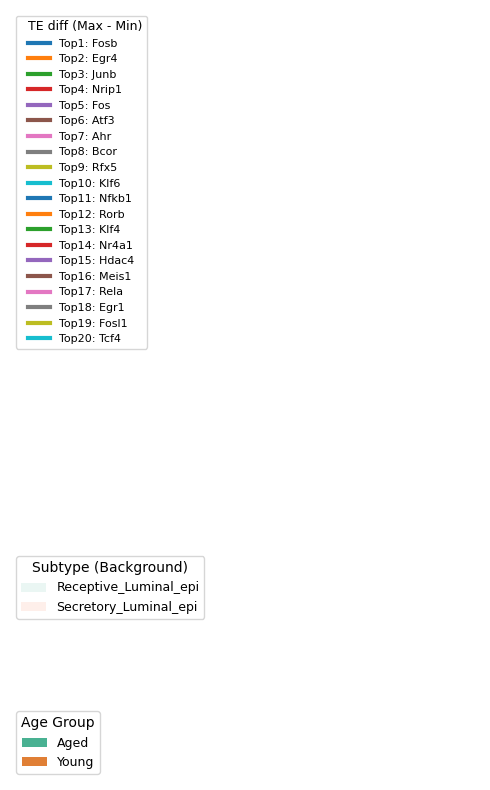

In [137]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns

subset = muc[(muc['real_time'] >= 3250.00) & (muc['real_time'] <= 3750.00)]
result = subset.groupby('Source')['TE'].apply(lambda x: x.max() - x.min()).sort_values(ascending=False).head(20)
result_list = result.index.tolist()

gene_palette = sns.color_palette("tab10", n_colors=len(result_list))

subtype_groups = sorted(cell_info['subtype'].dropna().unique())
subtype_colors = dict(zip(subtype_groups, sns.color_palette('Set2', n_colors=len(subtype_groups))))
subtype_alpha = 0.05

age_groups = sorted(cell_info['age_group'].dropna().unique())
age_colors = dict(zip(age_groups, sns.color_palette('Dark2', n_colors=len(age_groups))))

fig, ax = plt.subplots(figsize=(5, 8))
ax.axis('off')

gene_legend = [
    Line2D([0], [0], color=gene_palette[i], lw=3, label=f"Top{i+1}: {src}")
    for i, src in enumerate(result_list)
]
subtype_legend = [
    Patch(facecolor=subtype_colors[sub], alpha=subtype_alpha * 2.7, label=sub)
    for sub in subtype_groups
]
age_legend = [
    Patch(facecolor=age_colors[age], alpha=0.8, label=age)
    for age in age_groups
]

legend1 = ax.legend(
    handles=gene_legend,
    title='  TE diff (Max - Min)',
    title_fontsize=9,
    fontsize=8,
    loc='upper left',
    frameon=True
)
ax.add_artist(legend1)

legend2 = ax.legend(
    handles=subtype_legend,
    title='Subtype (Background)',
    title_fontsize=10,
    fontsize=9,
    loc='center left',
    bbox_to_anchor=(0, 0.25),
    frameon=True
)
ax.add_artist(legend2)

legend3 = ax.legend(
    handles=age_legend,
    title='Age Group',
    title_fontsize=10,
    fontsize=9,
    loc='lower left',
    frameon=True
)

plt.tight_layout()
plt.show()


In [138]:
##############################################
########## Calculate best Entrophy ###########
##############################################

/tmp/ipykernel_1444045/4272349850.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('Reds')
/tmp/ipykernel_1444045/4272349850.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


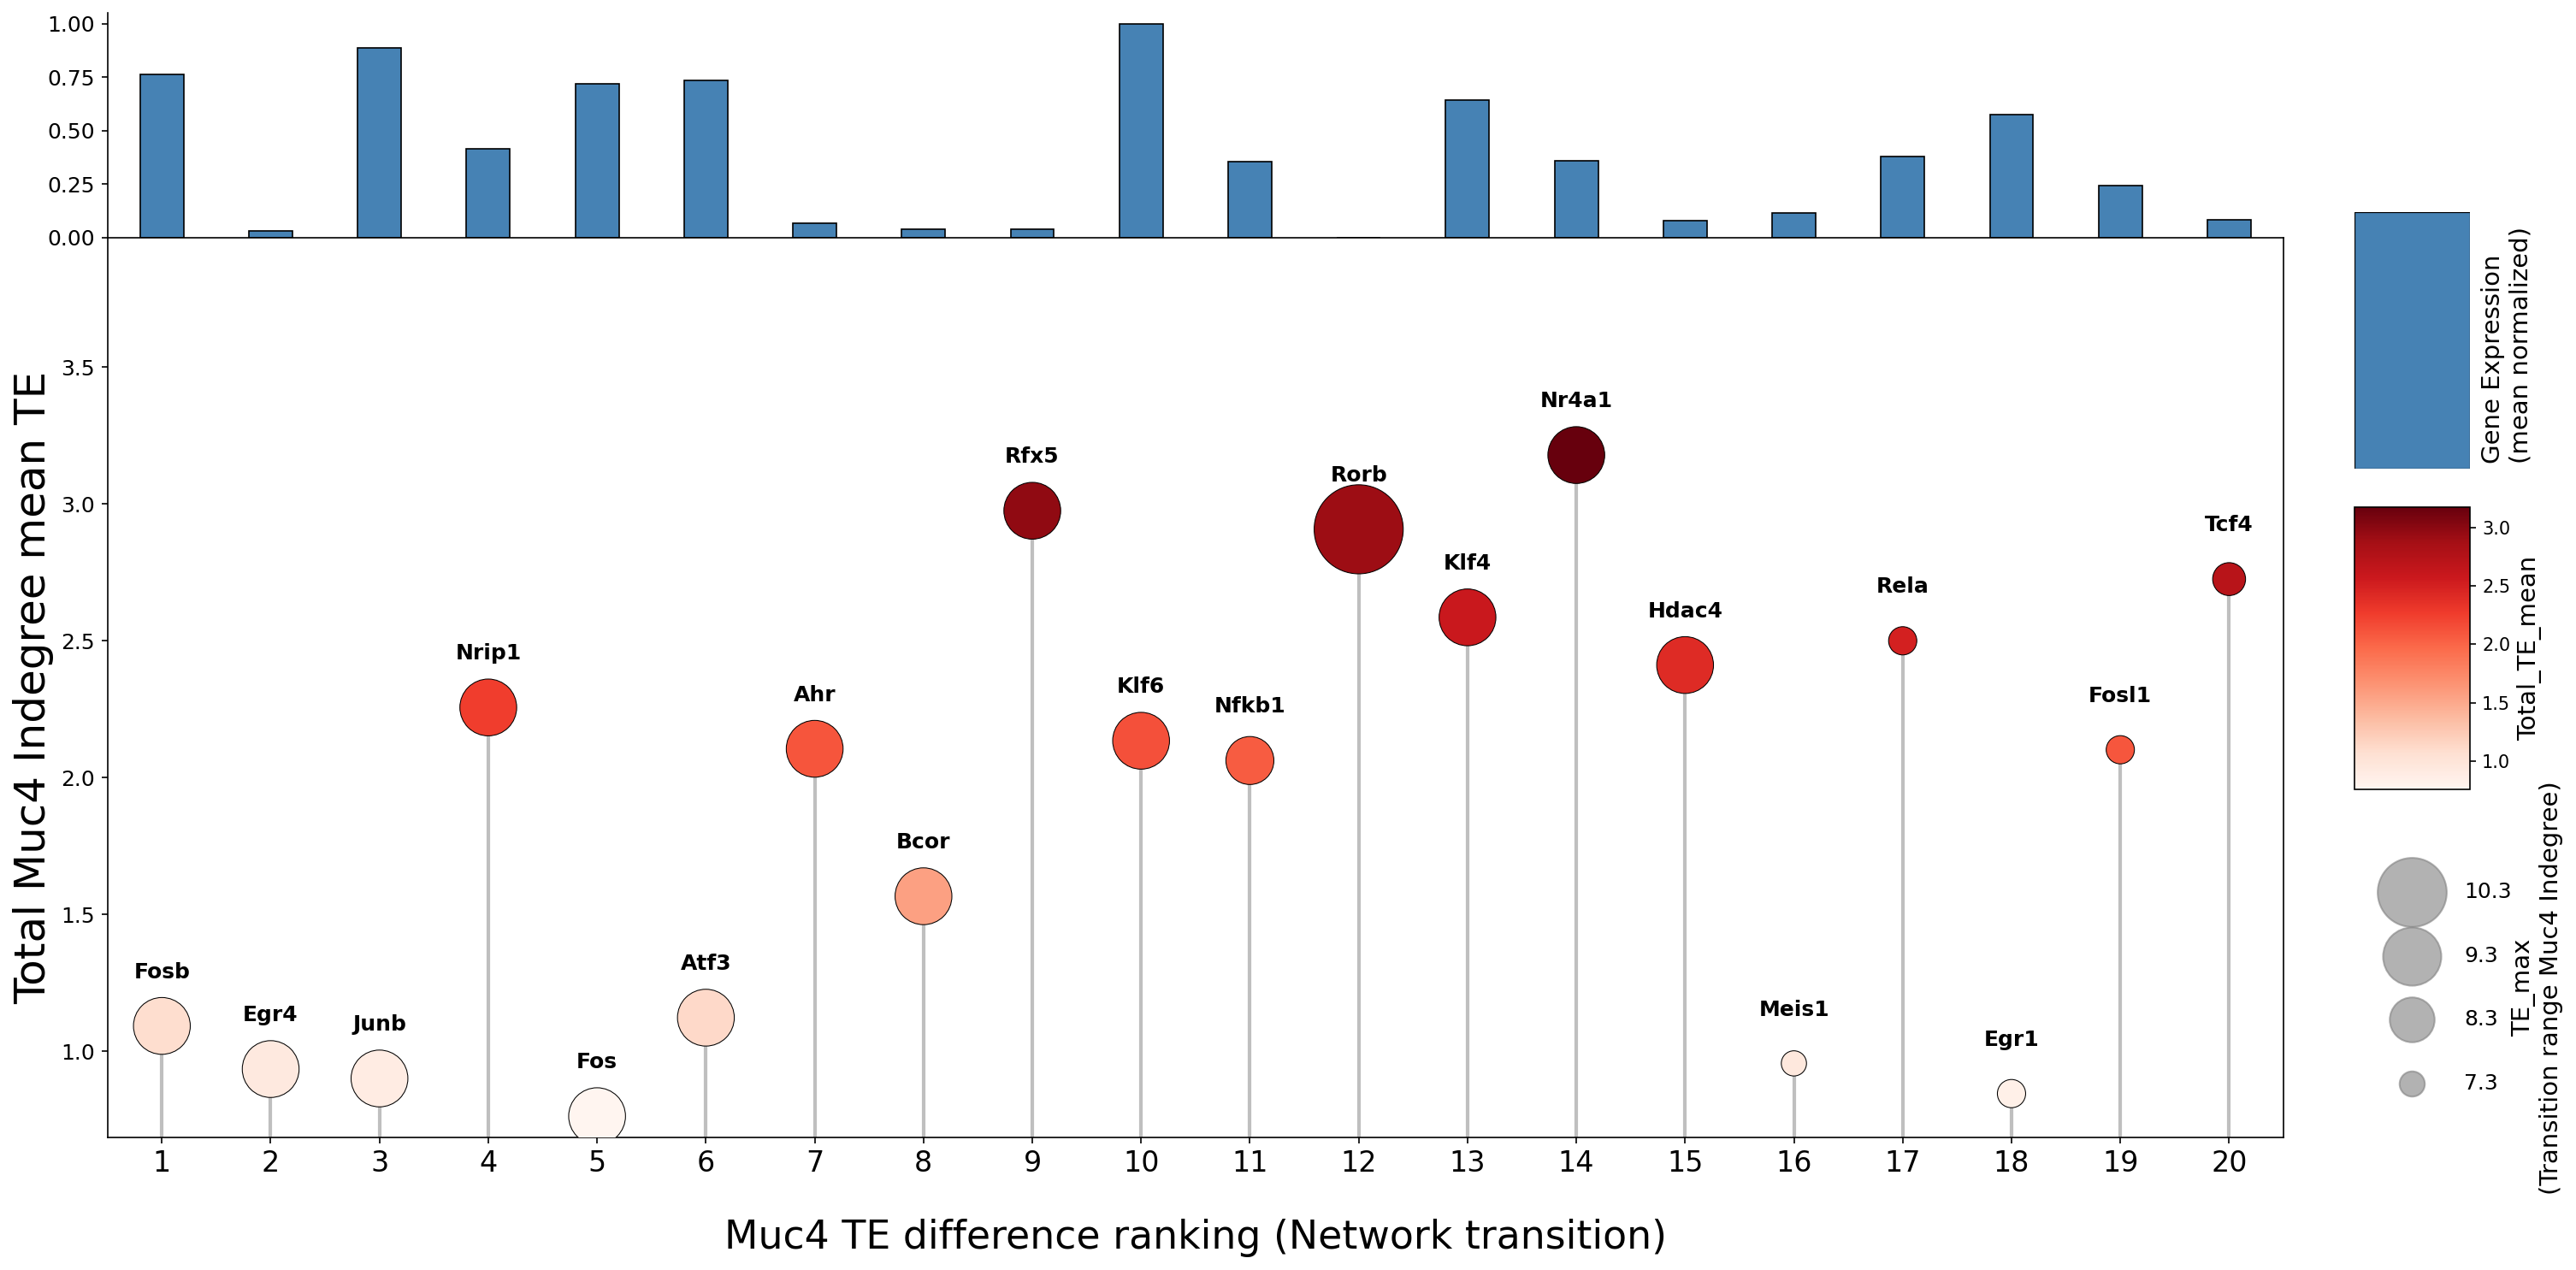

In [139]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap, ScalarMappable

subset = muc[(muc['real_time'] >= 3250.00) & (muc['real_time'] <= 3750.00)]
result = subset.groupby('Source')['TE'].apply(lambda x: x.max() - x.min()).sort_values(ascending=False).head(20)
result_list = result.index.tolist()

subset = muc[(muc['real_time'] >= 3250.00) & (muc['real_time'] <= 3750.00)]
max_min_dict = {}
for src in subset['Source'].unique():
    sub = subset[subset["Source"] == src]
    if sub.empty:
        continue
    max_min_dict[src] = {'TE_max': sub["TE"].max()}

max_min_df = pd.DataFrame.from_dict(max_min_dict, orient='index').reset_index()
max_min_df.rename(columns={'index': 'Source'}, inplace=True)

df_mean_te = muc.groupby('Source')['TE'].mean().reset_index()
df_mean_te.rename(columns={'TE': 'TE_mean'}, inplace=True)

merged_df = pd.merge(max_min_df, df_mean_te, on='Source', how='left')
merged_df = merged_df[merged_df['Source'].isin(result_list)]

plot_df = merged_df.set_index('Source').loc[result_list].reset_index()
plot_df['rank'] = range(1, len(plot_df) + 1)

genes = ['Fosb', 'Egr4', 'Junb', 'Nrip1', 'Fos', 'Atf3', 'Ahr', 'Bcor', 'Rfx5', 'Klf6', 'Nfkb1', 'Rorb', 'Klf4', 'Nr4a1', 'Hdac4', 'Meis1', 'Rela', 'Egr1', 'Fosl1', 'Tcf4']

expr = adata[:, genes].to_df()
gene_mean_expr = expr.mean(axis=0)
norm_mean = (gene_mean_expr - gene_mean_expr.min()) / (gene_mean_expr.max() - gene_mean_expr.min())

gene_expr_values = [norm_mean[source] if source in norm_mean.index else 0 for source in plot_df['Source']]
plot_df['gene_expr'] = gene_expr_values

fig = plt.figure(figsize=(20, 10), dpi=150)
gs = fig.add_gridspec(2, 1, height_ratios=[1, 4], hspace=0.00)

ax1 = fig.add_subplot(gs[0])
ax1.bar(plot_df['rank'], plot_df['gene_expr'], width=0.4, color='steelblue', edgecolor='black', linewidth=0.8)
ax1.set_xticks(plot_df['rank'])
ax1.set_xticklabels([])
ax1.tick_params(axis='y', labelsize=12)
ax1.set_xlim(0.5, 20.5)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.spines['bottom'].set_visible(False)

ax2 = fig.add_subplot(gs[1])

cmap = get_cmap('Reds')
norm_color = Normalize(vmin=plot_df['TE_mean'].min(), vmax=plot_df['TE_mean'].max())
sm = ScalarMappable(cmap=cmap, norm=norm_color)
sm.set_array([])

sizes = 200 + (plot_df['TE_max'] - plot_df['TE_max'].min()) / (plot_df['TE_max'].max() - plot_df['TE_max'].min()) * 2300

x = plot_df['rank']
y = plot_df['TE_mean']
colors = [cmap(norm_color(v)) for v in y]

ax2.vlines(x, ymin=0, ymax=y, color='gray', alpha=0.5, linewidth=2, zorder=2)
ax2.scatter(x, y, s=sizes, color=colors, edgecolor='black', linewidth=0.5, zorder=3, antialiased=True)

for i, row in plot_df.iterrows():
    ax2.text(row['rank'], row['TE_mean'] + 0.05 * y.max(), row['Source'], 
             ha='center', va='bottom', fontsize=12, color='black', fontweight='bold', zorder=4)

ax2.set_xlabel("Muc4 TE difference ranking (Network transition)", fontsize=22, labelpad=23)
ax2.set_ylabel("Total Muc4 Indegree mean TE", fontsize=24)
ax2.set_xticks(x)
ax2.set_xticklabels(range(1, 21), fontsize=16)
ax2.tick_params(axis='y', labelsize=12)
ax2.set_xlim(0.5, 20.5)
ax2.set_ylim(y.min() - 0.1 * abs(y.min()), y.max() + 0.25 * abs(y.max()))

legend_left = 0.92
legend_width = 0.045
legend_bottom = 0.1
gene_height = 0.20
cbar_height = 0.22
size_height = 0.25
gap = 0.03

gene_bottom = legend_bottom + size_height + gap + cbar_height + gap
gene_legend_ax = fig.add_axes([legend_left, gene_bottom, legend_width, gene_height])
gene_legend_ax.bar([0], [1], width=1.0, color='steelblue', edgecolor='black', linewidth=0.6)
gene_legend_ax.set_xlim(-0.5, 0.5)
gene_legend_ax.set_ylim(0, 1)
gene_legend_ax.axis('off')
gene_legend_ax.text(0.6, 0.48, 'Gene Expression\n(mean normalized)', rotation=90, fontsize=14, ha='left', va='center')

cbar_bottom = legend_bottom + size_height + gap
cbar_ax = fig.add_axes([legend_left, cbar_bottom, legend_width, cbar_height])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Total_TE_mean', fontsize=14)

size_legend_ax = fig.add_axes([legend_left, legend_bottom, legend_width, size_height])
example_sizes = np.linspace(plot_df['TE_max'].min(), plot_df['TE_max'].max(), 4)

for s in example_sizes:
    size = 200 + (s - plot_df['TE_max'].min()) / (plot_df['TE_max'].max() - plot_df['TE_max'].min()) * 1300
    size_legend_ax.scatter([0], [s], s=size, color='gray', alpha=0.6)
    size_legend_ax.text(0.05, s, f"{s:.1f}", va='center', fontsize=12)

size_legend_ax.set_ylim(plot_df['TE_max'].min() - 1, plot_df['TE_max'].max() + 1)
size_legend_ax.axis('off')
size_legend_ax.text(0.12, (plot_df['TE_max'].max() + plot_df['TE_max'].min()) / 2,
                    'TE_max\n(Transition range Muc4 Indegree)', rotation=90, fontsize=14, ha='center', va='center')

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

/tmp/ipykernel_1444045/1723606675.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_left = df_left.groupby(['sample_id', 'predict_module'])[genes].mean().reset_index()
/tmp/ipykernel_1444045/1723606675.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_right = df_right.groupby(['sample_id', 'subtype'])[genes].mean().reset_index()
/tmp/ipykernel_1444045/1723606675.py:31: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df_melt_left, y='Gene', x='Expression', hue='predict_module

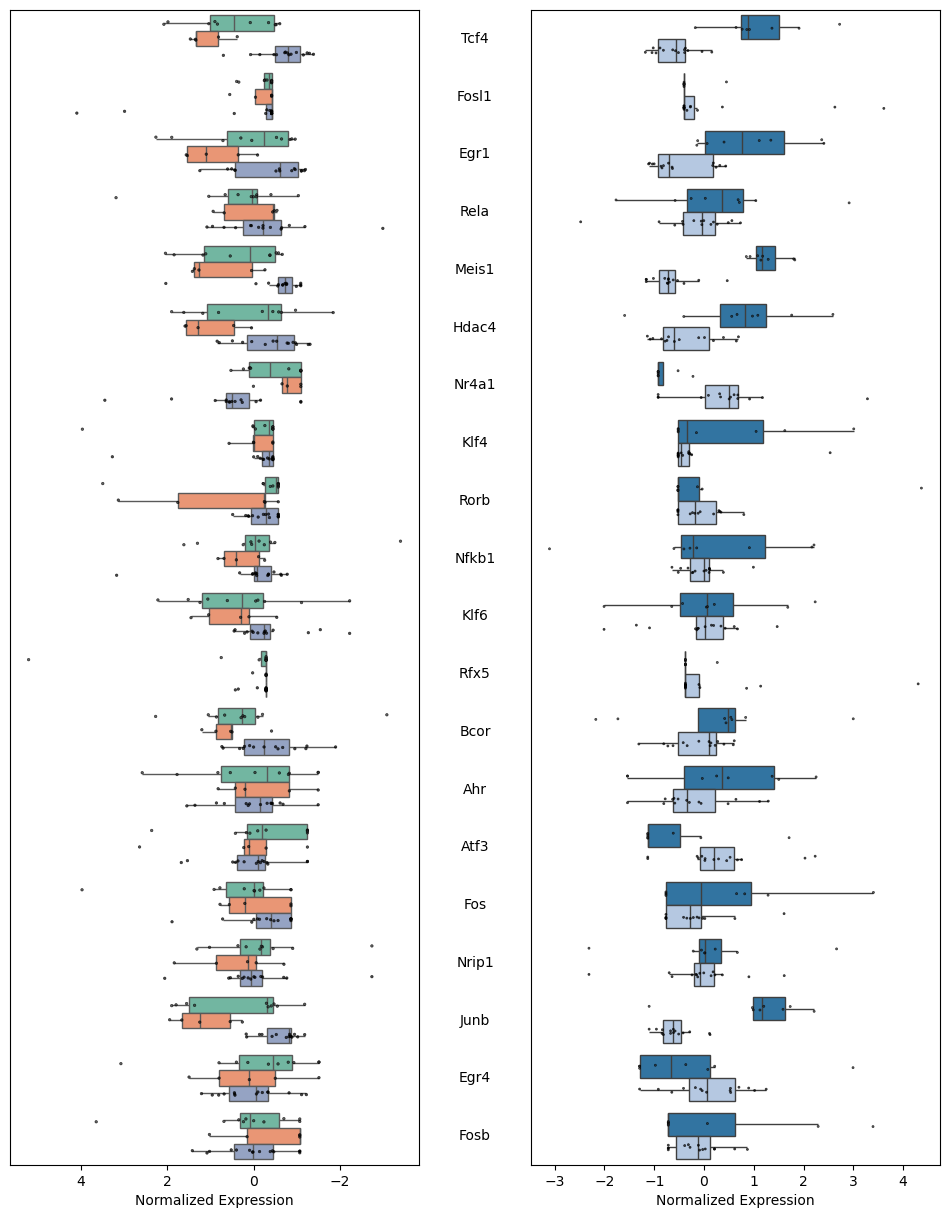

In [140]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import StandardScaler

df_left = adata.to_df()[genes].copy()
df_left['predict_module'] = adata.obs['predict_module'].values
df_left['sample_id'] = adata.obs['sample_id'].values
df_left = df_left.groupby(['sample_id', 'predict_module'])[genes].mean().reset_index()

df_right = adata.to_df()[genes].copy()
df_right['subtype'] = adata.obs['subtype'].values
df_right['sample_id'] = adata.obs['sample_id'].values
df_right = df_right.groupby(['sample_id', 'subtype'])[genes].mean().reset_index()

scaler = StandardScaler()
df_left[genes] = scaler.fit_transform(df_left[genes])
df_right[genes] = scaler.fit_transform(df_right[genes])

df_melt_left = df_left.melt(id_vars=['sample_id', 'predict_module'], value_vars=genes, var_name='Gene', value_name='Expression')
df_melt_right = df_right.melt(id_vars=['sample_id', 'subtype'], value_vars=genes, var_name='Gene', value_name='Expression')

fig = plt.figure(figsize=(12, len(genes)*0.75))
gs = GridSpec(1, 3, width_ratios=[1, 0.2, 1], wspace=0.05)
gene_order = genes

ax_left = fig.add_subplot(gs[0])
sns.boxplot(data=df_melt_left, y='Gene', x='Expression', hue='predict_module', showcaps=False, fliersize=0, orient='h',
            palette=sns.color_palette("Set2", len(df_left['predict_module'].unique())), ax=ax_left, order=gene_order)
sns.stripplot(data=df_melt_left, y='Gene', x='Expression', hue='predict_module', dodge=True, jitter=True, linewidth=0.5,
              orient='h', color='black', alpha=0.7, s=1.8, ax=ax_left, order=gene_order)
ax_left.get_legend().remove()
ax_left.set_ylabel('')
ax_left.set_xlabel('Normalized Expression')
ax_left.set_yticks([])
ax_left.invert_xaxis()

ax_mid = fig.add_subplot(gs[1])
ax_mid.set_xlim(0, 1)
ax_mid.set_ylim(0, len(genes))
ax_mid.axis('off')
for i, gene in enumerate(gene_order):
    y_coord = i + 0.5
    x_coord = 0.5
    ax_mid.text(x_coord, y_coord, gene, ha='center', va='center', fontsize=10)

ax_right = fig.add_subplot(gs[2])
subtype_groups = df_right['subtype'].unique()
sns.boxplot(data=df_melt_right, y='Gene', x='Expression', hue='subtype', showcaps=False, fliersize=0, orient='h',
            palette=sns.color_palette("tab20", len(subtype_groups)), ax=ax_right, order=gene_order)
sns.stripplot(data=df_melt_right, y='Gene', x='Expression', hue='subtype', dodge=True, jitter=True, linewidth=0.5,
              orient='h', color='black', alpha=0.7, s=1.5, ax=ax_right, order=gene_order)
ax_right.get_legend().remove()
ax_right.set_ylabel('')
ax_right.set_xlabel('Normalized Expression')
ax_right.set_yticks([])

plt.tight_layout()
plt.show()


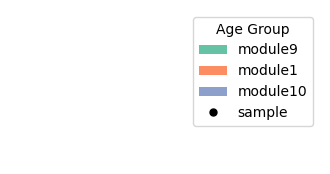

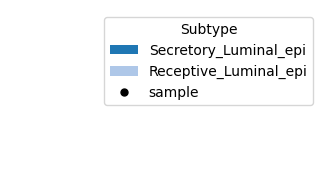

In [169]:
predict_module = adata.obs['predict_module'].unique()
age_palette = dict(zip(predict_module, sns.color_palette("Set2", len(predict_module))))

fig, ax = plt.subplots(figsize=(4, 2))
ax.axis('off')
age_legend = [
    Patch(facecolor=age_palette[ag], label=ag)
    for ag in predict_module
]
sample_dot = Line2D([0], [0], marker='o', color='black', linestyle='', label='sample', markersize=5)
ax.legend(handles=age_legend + [sample_dot], title='Age Group', frameon=True, fontsize=10)
plt.show()

subtype_groups = adata.obs['subtype'].unique()
subtype_palette = dict(zip(subtype_groups, sns.color_palette("tab20", len(subtype_groups))))

fig, ax = plt.subplots(figsize=(4, 2))
ax.axis('off')
subtype_legend = [
    Patch(facecolor=subtype_palette[st], label=st)
    for st in subtype_groups
]
sample_dot = Line2D([0], [0], marker='o', color='black', linestyle='', label='sample', markersize=5)
ax.legend(handles=subtype_legend + [sample_dot], title='Subtype', frameon=True, fontsize=10)
plt.show()